In [1]:
#==============================
# IMPORT LIBRARIES
#==============================

# Data Collection
#==============================
import yfinance as yf   #Download historical cryptocurrency data
import pandas as pd   #Data manipulation and analysis
import numpy as np   #Numerical computing
from datetime import date   #Handle dates
from tqdm import tqdm   #Progress bar for loops

# Data Scaling
#==============================
from sklearn.preprocessing import StandardScaler   #Standardize features by removing the mean and scaling to unit variance
from sklearn.preprocessing import MinMaxScaler   #Scale features to a fixed range

#Technical Indicators
#==============================
from ta.volatility import AverageTrueRange   #Average True Range (ATR) 
from ta.momentum import RSIIndicator   #Relative Strength Index (RSI) 
from ta.trend import MACD   #Moving Average Convergence Divergence (MACD) 

#Statistical Analysis
#==============================
from scipy import stats
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Data Visualization
#==============================
import matplotlib.pyplot as plt
import seaborn as sns

#Warning Settings
#==============================
import warnings
warnings.filterwarnings("ignore")

**DATA AND FEATURE PREPARATION**

In [2]:
#====================================================
# DATA AND FEATURE PREPARATION
#
# Objective:
# Predict 7-day-ahead 30-day rolling cryptocurrency correlations
#====================================================

# Global Parameters
#====================================================

N_COINS = 24

SEQUENCE_LENGTH = 30   #number of historical days fed into the model

FORECAST_HORIZON = 7

NORMALIZATION_WINDOW = 60   #feature normalization

BASE_CORR_WINDOW = 30   #historical correlation window used to construct baseline graph relationship


#====================================================
# Define 24 cryptocurrencies
#====================================================

GNN_TICKERS = [

    "BTC-USD",
    "ADA-USD",
    "DOGE-USD",
    "DASH-USD",
    "CRO-USD",
    "ETH-USD",
    "EOS-USD",
    "FIL-USD",
    "HT-USD",
    "LEO-USD",
    "ATOM-USD",
    "BNB-USD",
    "LTC-USD",
    "LINK-USD",
    "SNX-USD",
    "NEO-USD",
    "THETA-USD",
    "TRX-USD",
    "VET-USD",
    "XEM-USD",
    "XLM-USD",
    "XMR-USD",
    "XRP-USD",
    "XTZ-USD"

]


assert len(GNN_TICKERS) == N_COINS


print(
    "Number of GNN Cryptocurrencies:",
    len(GNN_TICKERS)
)

Number of GNN Cryptocurrencies: 24


In [3]:
#====================================================
# CREATE WORKING DATAFRAME
#====================================================

gnn_df = pd.read_csv(
    "lstm_full_before_imputer_scaler.csv"
)


# Date Format
#====================================================

gnn_df["Date"] = pd.to_datetime(
    gnn_df["Date"]
)


# Keep Only 24 Cryptocurrencies
#====================================================

gnn_df = (

    gnn_df[
        gnn_df["Ticker"].isin(
            GNN_TICKERS
        )
    ]

    .copy()

)



# Remove Duplicate Ticker-Date Observations
#====================================================

duplicate_count = (

    gnn_df

    .duplicated(
        subset=[
            "Ticker",
            "Date"
        ]
    )

    .sum()

)


print(
    "Duplicate Ticker-Date Rows:",
    duplicate_count
)


gnn_df = (

    gnn_df

    .drop_duplicates(
        subset=[
            "Ticker",
            "Date"
        ],
        keep="first"
    )

    .sort_values(
        [
            "Ticker",
            "Date"
        ]
    )

    .reset_index(drop=True)

)

Duplicate Ticker-Date Rows: 0


In [4]:
#====================================================
# CHECK AVAILABLE CRYPTOCURRENCIES
#====================================================

available_tickers = sorted(
    gnn_df["Ticker"].unique()
)


missing_tickers = sorted(

    set(GNN_TICKERS)

    -

    set(available_tickers)

)


print(
    "Available Cryptocurrencies:",
    len(available_tickers)
)


print(
    "Missing Cryptocurrencies:",
    missing_tickers
)


if missing_tickers:

    raise ValueError(

        "Missing cryptocurrencies: "
        f"{missing_tickers}"

    )

Available Cryptocurrencies: 24
Missing Cryptocurrencies: []


In [5]:
#====================================================
# DAILY CRYPTO MARKET RETURN
#====================================================

market_daily_df = (

    gnn_df

    .groupby(
        "Date",
        as_index=False
    )

    .agg(

        Market_Return_Sum=(
            "Log Return",
            "sum"
        ),

        Market_Return_Count=(
            "Log Return",
            "count"
        )

    )

)


gnn_df = (

    gnn_df

    .merge(

        market_daily_df,

        on="Date",

        how="left"

    )

)

In [6]:
#====================================================
# LEAVE-ONE-OUT MARKET RETURN
#====================================================

'''
Measure the return of the rest of the 24-coin market excluding the cryptocurrency itself.
'''

gnn_df[
    "Market_Log_Return_LOO"
] = (

    (
        gnn_df[
            "Market_Return_Sum"
        ]

        -

        gnn_df[
            "Log Return"
        ]
    )

    /

    (
        gnn_df[
            "Market_Return_Count"
        ]

        -

        1
    )

)

In [7]:
#====================================================
# EQUAL-WEIGHT DAILY MARKET LOG RETURN
#====================================================

gnn_df[
    "Market_Log_Return"
] = (

    gnn_df[
        "Market_Return_Sum"
    ]

    /

    gnn_df[
        "Market_Return_Count"
    ]

)

In [8]:
#====================================================
# ROLLING CORRELATION WITH
# LEAVE-ONE-OUT CRYPTO MARKET
#====================================================

MARKET_CORR_WINDOWS = [

    10,
    30,
    60

]


for window in MARKET_CORR_WINDOWS:


    feature_name = (

        f"Market_Corr_{window}"

    )


    gnn_df[
        feature_name
    ] = np.nan


    for ticker in GNN_TICKERS:


        mask = (

            gnn_df["Ticker"]
            ==
            ticker

        )


        coin = (

            gnn_df.loc[
                mask
            ]

            .sort_values(
                "Date"
            )

        )


        rolling_corr = (

            coin[
                "Log Return"
            ]

            .rolling(

                window=window,

                min_periods=window

            )

            .corr(

                coin[
                    "Market_Log_Return_LOO"
                ]

            )

        )


        gnn_df.loc[

            coin.index,

            feature_name

        ] = rolling_corr.to_numpy()

In [9]:
#====================================================
# CROSS-SECTIONAL RETURN DISPERSION
#====================================================

gnn_df[
    "Cross_Sectional_Return_Dispersion"
] = (

    gnn_df

    .groupby("Date")[
        "Log Return"
    ]

    .transform(
        "std"
    )

)

In [10]:
#====================================================
# REMOVE TEMPORARY COLUMNS
#====================================================

gnn_df = (

    gnn_df

    .drop(

        columns=[

            "Market_Return_Sum",
            "Market_Return_Count"

        ],

        errors="ignore"

    )

)

In [11]:
#====================================================
# CORE ASSET-SPECIFIC CONTINUOUS FEATURES
#====================================================

CORE_ASSET_CONTINUOUS_FEATURES = [

    "Return",
    "Log Return",

    "RV_7",
    "RV_30",
    "GARCH_Vol",
    
    "RSI(14)",
    "RSI(30)",
    "RSI(200)",
    "CCI(20)",
    "MACD_6_20",
    "MACD_6_20_Signal",
    "MACD_6_20_Hist",
    "ATR(14)",
    "OBV",
    "TEMA(14)",
    "TEMA(30)",
    "TEMA(200)",
    "SlowK_5_3_3",
    "SlowD_5_3_3",
    "PROC(14)",
    "MOM(10)",
    "MOM(30)",
    
    "SP500",
    "DowJones",
    "USD_Index",
    "VIX",
    
    "SP500_Return",
    "DowJones_Return",
    "USD_Index_Return",
    "VIX_Return",
    
    "Market_Corr_10",
    "Market_Corr_30",
    "Market_Corr_60"

]

In [12]:
#====================================================
# GLOBAL MARKET-LEVEL FEATURES
#====================================================

MARKET_LEVEL_CONTINUOUS_FEATURES = [

    "Market_Log_Return",

    "Cross_Sectional_Return_Dispersion"

]

In [13]:
#====================================================
# NON-FEATURE COLUMNS
#====================================================

NON_FEATURE_COLUMNS = [

    #================================================
    # IDENTIFIERS
    #================================================

    "Date",
    "Ticker",
    "Node_ID",


    #================================================
    # RAW OHLCV
    #================================================

    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume",


    #================================================
    # LONG-HORIZON VOLATILITY NOT USED
    #================================================

    "RV_60",
    "RV_180",
    "RV_365",


    #================================================
    # LSTM TARGET / OUTPUT VARIABLES
    #================================================

    "RV_30_Target",
    "RV_30_7D_Ahead",
    "Actual_RV30",
    "Predicted_RV30",


    #================================================
    # FUTURE GNN TARGET / OUTPUT VARIABLES
    #================================================

    "Future_Correlation",
    "Future_Corr_7D",
    "Target_Corr_30_t_plus_7",
    "Target_Z_30_t_plus_7",
    "Correlation_Target",
    "Fisher_Z_Target",
    "Delta_Z_Target",
    "Predicted_Correlation"

]

In [14]:
#====================================================
# IDENTIFY BINARY EVENT FEATURES
#====================================================

binary_features = []


for column in gnn_df.columns:


    if column in NON_FEATURE_COLUMNS:

        continue


    if column in CORE_ASSET_CONTINUOUS_FEATURES:

        continue


    if column in MARKET_LEVEL_CONTINUOUS_FEATURES:

        continue


    if not pd.api.types.is_numeric_dtype(
        gnn_df[column]
    ):

        continue


    unique_values = set(

        gnn_df[
            column
        ]

        .dropna()

        .unique()

    )


    if (

        len(unique_values) > 0

        and

        unique_values.issubset(
            {0, 1}
        )

    ):

        binary_features.append(
            column
        )

In [15]:
#====================================================
# REMOVE CONSTANT BINARY FEATURES
#====================================================

constant_binary_features = [

    feature

    for feature
    in binary_features

    if (

        gnn_df[
            feature
        ]

        .nunique(
            dropna=True
        )

        <= 1

    )

]


binary_features = [

    feature

    for feature
    in binary_features

    if feature
    not in constant_binary_features

]


print(
    "Constant Binary Features Removed:",
    len(
        constant_binary_features
    )
)


print(
    "Usable Binary Features:",
    len(
        binary_features
    )
)

print(constant_binary_features)

Constant Binary Features Removed: 0
Usable Binary Features: 186
[]


In [16]:
#====================================================
# VERIFY CORE FEATURES
#====================================================

required_continuous_features = (

    CORE_ASSET_CONTINUOUS_FEATURES

    +

    MARKET_LEVEL_CONTINUOUS_FEATURES

)


missing_features = [

    feature

    for feature
    in required_continuous_features

    if feature
    not in gnn_df.columns

]


if missing_features:

    raise ValueError(

        "Missing required GNN features: "
        f"{missing_features}"

    )

In [17]:
#====================================================
# REPLACE INFINITY
#====================================================

gnn_df[
    required_continuous_features
] = (

    gnn_df[
        required_continuous_features
    ]

    .replace(
        [
            np.inf,
            -np.inf
        ],
        np.nan
    )

)

In [18]:
#====================================================
# REMOVE STRUCTURAL FEATURE NAN
#====================================================

gnn_df = (

    gnn_df

    .dropna(

        subset=required_continuous_features

    )

    .copy()

)

In [19]:
#====================================================
# KEEP COMPLETE 24-NODE GRAPH DATES
#====================================================

coins_per_date = (

    gnn_df

    .groupby("Date")[
        "Ticker"
    ]

    .nunique()

)


complete_dates = (

    coins_per_date[
        coins_per_date == N_COINS
    ]

    .index

)


gnn_df = (

    gnn_df[
        gnn_df["Date"].isin(
            complete_dates
        )
    ]

    .copy()

)

In [20]:
#====================================================
# FIXED NODE MAPPING
#====================================================

ticker_to_node = {

    ticker: node_id

    for node_id, ticker
    in enumerate(
        GNN_TICKERS
    )

}


node_to_ticker = {

    node_id: ticker

    for ticker, node_id
    in ticker_to_node.items()

}


gnn_df[
    "Node_ID"
] = (

    gnn_df[
        "Ticker"
    ]

    .map(
        ticker_to_node
    )

)


node_mapping_df = pd.DataFrame({

    "Node_ID":
        range(
            N_COINS
        ),

    "Ticker":
        GNN_TICKERS

})

In [21]:
#====================================================
# FIX GRAPH ORDER
#====================================================

gnn_df = (

    gnn_df

    .sort_values(
        [
            "Date",
            "Node_ID"
        ]
    )

    .reset_index(drop=True)

)

In [22]:
#====================================================
# CAUSAL ROLLING 60-DAY Z-SCORE
# ASSET-SPECIFIC FEATURES
#====================================================

ASSET_FEATURES_Z = []


for feature in CORE_ASSET_CONTINUOUS_FEATURES:


    normalized_feature = (

        f"{feature}_Z"

    )


    rolling_mean = (

        gnn_df

        .groupby("Ticker")[
            feature
        ]

        .transform(

            lambda x:

            x.shift(1)

            .rolling(

                window=NORMALIZATION_WINDOW,

                min_periods=NORMALIZATION_WINDOW

            )

            .mean()

        )

    )


    rolling_std = (

        gnn_df

        .groupby("Ticker")[
            feature
        ]

        .transform(

            lambda x:

            x.shift(1)

            .rolling(

                window=NORMALIZATION_WINDOW,

                min_periods=NORMALIZATION_WINDOW

            )

            .std()

        )

    )


    gnn_df[
        normalized_feature
    ] = np.where(

        rolling_std > 1e-12,

        (
            gnn_df[feature]
            -
            rolling_mean
        )

        /

        rolling_std,

        0.0

    )


    ASSET_FEATURES_Z.append(
        normalized_feature
    )

In [23]:
#====================================================
# CREATE ONE-ROW-PER-DATE MARKET DATA
#====================================================

market_state_df = (

    gnn_df[
        [
            "Date"
        ]

        +

        MARKET_LEVEL_CONTINUOUS_FEATURES
    ]

    .drop_duplicates(
        subset="Date"
    )

    .sort_values(
        "Date"
    )

    .reset_index(drop=True)

)

In [24]:
#====================================================
# CAUSAL ROLLING NORMALIZATION
# MARKET-LEVEL FEATURES
#====================================================

MARKET_FEATURES_Z = []


for feature in MARKET_LEVEL_CONTINUOUS_FEATURES:


    normalized_feature = (

        f"{feature}_Z"

    )


    rolling_mean = (

        market_state_df[
            feature
        ]

        .shift(1)

        .rolling(

            window=NORMALIZATION_WINDOW,

            min_periods=NORMALIZATION_WINDOW

        )

        .mean()

    )


    rolling_std = (

        market_state_df[
            feature
        ]

        .shift(1)

        .rolling(

            window=NORMALIZATION_WINDOW,

            min_periods=NORMALIZATION_WINDOW

        )

        .std()

    )


    market_state_df[
        normalized_feature
    ] = np.where(

        rolling_std > 1e-12,

        (
            market_state_df[
                feature
            ]

            -
            rolling_mean
        )

        /

        rolling_std,

        0.0

    )


    MARKET_FEATURES_Z.append(
        normalized_feature
    )

In [25]:
#====================================================
# MERGE NORMALIZED MARKET FEATURES
#====================================================

gnn_df = (

    gnn_df

    .merge(

        market_state_df[
            [
                "Date"
            ]

            +

            MARKET_FEATURES_Z
        ],

        on="Date",

        how="left"

    )

)

In [26]:
#====================================================
# REMOVE NORMALIZATION WARM-UP
#====================================================

NORMALIZED_CONTINUOUS_FEATURES = (

    ASSET_FEATURES_Z

    +

    MARKET_FEATURES_Z

)


gnn_df = (

    gnn_df

    .dropna(

        subset=
        NORMALIZED_CONTINUOUS_FEATURES

    )

    .copy()

)

In [27]:
#====================================================
# KEEP COMPLETE 24-NODE DATES AGAIN
#====================================================

coins_per_date = (

    gnn_df

    .groupby("Date")[
        "Ticker"
    ]

    .nunique()

)


complete_dates = (

    coins_per_date[
        coins_per_date == N_COINS
    ]

    .index

)


gnn_df = (

    gnn_df[
        gnn_df["Date"].isin(
            complete_dates
        )
    ]

    .sort_values(
        [
            "Date",
            "Node_ID"
        ]
    )

    .reset_index(drop=True)

)

In [28]:
#====================================================
# FINAL GNN MODEL FEATURES
#====================================================

GNN_MODEL_FEATURES = (

    NORMALIZED_CONTINUOUS_FEATURES

    +

    binary_features

)


print("\n")

print("=" * 80)

print(
    "FINAL GNN FEATURE CONFIGURATION"
)

print("=" * 80)


print(
    "Asset Continuous Features:",
    len(
        ASSET_FEATURES_Z
    )
)


print(
    "Market-Level Continuous Features:",
    len(
        MARKET_FEATURES_Z
    )
)


print(
    "Binary Features:",
    len(
        binary_features
    )
)


print(
    "Total Model Features:",
    len(
        GNN_MODEL_FEATURES
    )
)



FINAL GNN FEATURE CONFIGURATION
Asset Continuous Features: 33
Market-Level Continuous Features: 2
Binary Features: 186
Total Model Features: 221


In [29]:
#====================================================
# PRINT CONTINUOUS FEATURE NAMES
#====================================================

print("\n")

print("=" * 80)

print(
    "NORMALIZED CONTINUOUS FEATURES"
)

print("=" * 80)


for i, feature in enumerate(

    NORMALIZED_CONTINUOUS_FEATURES,

    start=1

):

    print(
        f"{i:3d}. {feature}"
    )



NORMALIZED CONTINUOUS FEATURES
  1. Return_Z
  2. Log Return_Z
  3. RV_7_Z
  4. RV_30_Z
  5. GARCH_Vol_Z
  6. RSI(14)_Z
  7. RSI(30)_Z
  8. RSI(200)_Z
  9. CCI(20)_Z
 10. MACD_6_20_Z
 11. MACD_6_20_Signal_Z
 12. MACD_6_20_Hist_Z
 13. ATR(14)_Z
 14. OBV_Z
 15. TEMA(14)_Z
 16. TEMA(30)_Z
 17. TEMA(200)_Z
 18. SlowK_5_3_3_Z
 19. SlowD_5_3_3_Z
 20. PROC(14)_Z
 21. MOM(10)_Z
 22. MOM(30)_Z
 23. SP500_Z
 24. DowJones_Z
 25. USD_Index_Z
 26. VIX_Z
 27. SP500_Return_Z
 28. DowJones_Return_Z
 29. USD_Index_Return_Z
 30. VIX_Return_Z
 31. Market_Corr_10_Z
 32. Market_Corr_30_Z
 33. Market_Corr_60_Z
 34. Market_Log_Return_Z
 35. Cross_Sectional_Return_Dispersion_Z


In [30]:
#====================================================
# PRINT BINARY FEATURE NAMES
#====================================================

print("\n")

print("=" * 80)

print(
    "BINARY FEATURES"
)

print("=" * 80)


for i, feature in enumerate(

    binary_features,

    start=1

):

    print(
        f"{i:3d}. {feature}"
    )



BINARY FEATURES
  1. Bull_Regime
  2. Bear_Regime
  3. Bull_Regime_Lag1
  4. Bull_Regime_Lag4
  5. Bull_Regime_Lag7
  6. Bear_Regime_Lag1
  7. Bear_Regime_Lag4
  8. Bear_Regime_Lag7
  9. Weekend
 10. MonthEnd
 11. QuarterEnd
 12. MonthStart
 13. QuarterStart
 14. BTC_40K
 15. Tesla_Event
 16. NFT_DeFi_Boom
 17. BTC_61K
 18. Coinbase_IPO
 19. China_Ban
 20. NFT_Summer
 21. Poly_Hack
 22. El_Salvador
 23. First_BTC_ETF
 24. BTC_67K
 25. Meta_Rebrand
 26. BTC_69K
 27. Omicron_Covid
 28. Fed_Tapering
 29. Layer1_Boom
 30. Turkey_Libra
 31. India_Ban
 32. ETH_Payment
 33. THETA_Peak
 34. XRP_1_96
 35. BNB_690
 36. LINK_Peak
 37. ATOM_Osmosis
 38. ETH_EIP1559
 39. ADA_Peak
 40. ADA_Alonzo
 41. LTC_Walmart
 42. ATOM_Peak
 43. HT_Ban_China
 44. MoneyGram_USDC
 45. Staples_Rename
 46. BNB_BEP95
 47. EOS_Governance
 48. ETH_Layer2
 49. BNB_Regulatory_Scrutiny
 50. Wormhole_Hack
 51. Ronin_Hack
 52. LUNA_Surge
 53. UST_Depeg
 54. LUNA_Collapse
 55. LUNA_2
 56. Celsius_3AC_Crisis
 57. Tornado_Ca

In [31]:
#====================================================
# FINAL GNN PANEL
#====================================================

gnn_panel_df = (

    gnn_df[
        [
            "Date",
            "Ticker",
            "Node_ID",
            "Close",
            "Log Return"
        ]

        +

        GNN_MODEL_FEATURES
    ]

    .copy()

)

In [32]:
#====================================================
# SORT FINAL PANEL
#====================================================

gnn_panel_df = (

    gnn_panel_df

    .sort_values(
        [
            "Date",
            "Node_ID"
        ]
    )

    .reset_index(drop=True)

)

In [33]:
#====================================================
# CHECK MODEL INPUTS
#====================================================

nan_count = (

    gnn_panel_df[
        GNN_MODEL_FEATURES
    ]

    .isna()

    .sum()

    .sum()

)


inf_count = (

    np.isinf(

        gnn_panel_df[
            GNN_MODEL_FEATURES
        ]

        .to_numpy(
            dtype=np.float64
        )

    )

    .sum()

)


print(
    "NaN Values:",
    nan_count
)


print(
    "Infinite Values:",
    inf_count
)

NaN Values: 0
Infinite Values: 0


In [34]:
#====================================================
# CHECK GRAPH SIZE
#====================================================

nodes_per_date = (

    gnn_panel_df

    .groupby("Date")[
        "Node_ID"
    ]

    .nunique()

)


print(
    "Minimum Nodes:",
    nodes_per_date.min()
)


print(
    "Maximum Nodes:",
    nodes_per_date.max()
)


assert (

    nodes_per_date.eq(
        N_COINS
    )

    .all()

), "Some dates do not contain exactly 24 nodes."

Minimum Nodes: 24
Maximum Nodes: 24


In [35]:
#====================================================
# CHECK BINARY FEATURES
#====================================================

invalid_binary_features = []


for feature in binary_features:


    values = set(

        gnn_panel_df[
            feature
        ]

        .dropna()

        .unique()

    )


    if not values.issubset(
        {0, 1}
    ):

        invalid_binary_features.append(
            feature
        )


print(
    "Invalid Binary Features:",
    invalid_binary_features
)


assert (

    len(
        invalid_binary_features
    )

    == 0

)

Invalid Binary Features: []


In [36]:
#====================================================
# STRICT FINAL CHECKS
#====================================================

assert (

    gnn_panel_df[
        "Ticker"
    ]

    .nunique()

    == N_COINS

)


assert (

    gnn_panel_df[
        GNN_MODEL_FEATURES
    ]

    .isna()

    .sum()

    .sum()

    == 0

)


assert (

    np.isfinite(

        gnn_panel_df[
            GNN_MODEL_FEATURES
        ]

        .to_numpy(
            dtype=np.float64
        )

    )

    .all()

)


assert (

    gnn_panel_df

    .groupby("Date")[
        "Ticker"
    ]

    .nunique()

    .eq(
        N_COINS
    )

    .all()

)


print("\n")

print(
    "ALL GNN FEATURE PANEL CHECKS PASSED."
)



ALL GNN FEATURE PANEL CHECKS PASSED.


In [37]:
#====================================================
# FINAL SUMMARY
#====================================================

print("\n")

print("=" * 80)

print(
    "FINAL 24-CRYPTOCURRENCY GNN PANEL"
)

print("=" * 80)


print(
    "Shape:",
    gnn_panel_df.shape
)


print(
    "Cryptocurrencies:",
    gnn_panel_df[
        "Ticker"
    ].nunique()
)


print(
    "Dates:",
    gnn_panel_df[
        "Date"
    ].nunique()
)


print(
    "Start Date:",
    gnn_panel_df[
        "Date"
    ].min()
)


print(
    "End Date:",
    gnn_panel_df[
        "Date"
    ].max()
)


print(
    "Model Features:",
    len(
        GNN_MODEL_FEATURES
    )
)


print(
    "Continuous Features:",
    len(
        NORMALIZED_CONTINUOUS_FEATURES
    )
)


print(
    "Binary Features:",
    len(
        binary_features
    )
)



FINAL 24-CRYPTOCURRENCY GNN PANEL
Shape: (47856, 226)
Cryptocurrencies: 24
Dates: 1994
Start Date: 2021-02-22 00:00:00
End Date: 2026-08-08 00:00:00
Model Features: 221
Continuous Features: 35
Binary Features: 186


In [38]:
#====================================================
# SAVE GNN PANEL
#====================================================

gnn_panel_df.to_csv(

    "GNN_24_Coin_Feature_Panel.csv",

    index=False

)


#====================================================
# SAVE NODE MAPPING
#====================================================

node_mapping_df.to_csv(

    "GNN_Node_Mapping.csv",

    index=False

)


#====================================================
# SAVE FEATURE LIST
#====================================================

feature_type = (

    [
        "Continuous_Rolling_Z"
    ]

    *
    len(
        NORMALIZED_CONTINUOUS_FEATURES
    )

    +

    [
        "Binary_0_1"
    ]

    *
    len(
        binary_features
    )

)


gnn_feature_list_df = pd.DataFrame({

    "Feature":
        GNN_MODEL_FEATURES,

    "Feature_Type":
        feature_type

})


gnn_feature_list_df.to_csv(

    "GNN_Feature_List.csv",

    index=False

)


print("\n")

print(
    "Saved: GNN_24_Coin_Feature_Panel.csv"
)

print(
    "Saved: GNN_Node_Mapping.csv"
)

print(
    "Saved: GNN_Feature_List.csv"
)



Saved: GNN_24_Coin_Feature_Panel.csv
Saved: GNN_Node_Mapping.csv
Saved: GNN_Feature_List.csv


In [39]:
#====================================================
# GNN STAGE 2
# CONSTRUCT CORRELATION TARGETS
#====================================================

import numpy as np
import pandas as pd


#====================================================
# PARAMETERS
#====================================================

BASE_CORR_WINDOW = 30

FORECAST_HORIZON = 7

FISHER_EPS = 1e-6


#====================================================
# CREATE WIDE LOG-RETURN MATRIX
#
# Rows    = Date
# Columns = 24 cryptocurrencies
#====================================================

returns_wide = (

    gnn_panel_df

    .pivot(
        index="Date",
        columns="Ticker",
        values="Log Return"
    )

    .reindex(
        columns=GNN_TICKERS
    )

    .sort_index()

)


print(
    "Return Matrix Shape:",
    returns_wide.shape
)


print(
    "Date Range:",
    returns_wide.index.min(),
    "to",
    returns_wide.index.max()
)

Return Matrix Shape: (1994, 24)
Date Range: 2021-02-22 00:00:00 to 2026-08-08 00:00:00


In [40]:
#====================================================
# HISTORICAL 30-DAY BASELINE CORRELATIONS
#====================================================

baseline_corr_by_date = {}


#====================================================
# GET ORDERED DATES
#====================================================

dates = returns_wide.index


#====================================================
# LOOP THROUGH EACH FORECAST-ORIGIN DATE
#====================================================

for date_position in range(
    BASE_CORR_WINDOW - 1,
    len(dates)
):

    current_date = dates[
        date_position
    ]


    #================================================
    # ONLY INFORMATION AVAILABLE THROUGH DATE t
    #
    # For a 30-day window:
    #
    # t-29, t-28, ..., t
    #
    # No future information is included.
    #================================================

    historical_returns = (

        returns_wide

        .iloc[
            date_position
            -
            BASE_CORR_WINDOW
            +
            1
            :
            date_position
            +
            1
        ]

        .copy()

    )


    #================================================
    # REQUIRE EXACTLY 30 OBSERVATIONS
    #================================================

    if (
        len(historical_returns)
        !=
        BASE_CORR_WINDOW
    ):
        continue


    #================================================
    # REQUIRE 30 CONSECUTIVE CALENDAR DAYS
    #
    # Cryptocurrency markets trade every day.
    # Therefore, the 30 observations should
    # correspond to 30 consecutive calendar days.
    #================================================

    expected_dates = pd.date_range(
        start=historical_returns.index[0],
        periods=BASE_CORR_WINDOW,
        freq="D"
    )


    if not historical_returns.index.equals(
        expected_dates
    ):
        continue


    #================================================
    # CHECK FOR MISSING VALUES
    #================================================

    if historical_returns.isna().any().any():
        continue


    #================================================
    # CALCULATE 24 x 24
    # 30-DAY CORRELATION MATRIX
    #================================================

    corr_matrix = (

        historical_returns

        .corr()

        .reindex(
            index=GNN_TICKERS,
            columns=GNN_TICKERS
        )

    )


    #================================================
    # CHECK MATRIX IS COMPLETE
    #================================================

    if corr_matrix.isna().any().any():
        continue


    #================================================
    # CONVERT TO NUMPY ARRAY
    #================================================

    corr_matrix = corr_matrix.to_numpy(
        dtype=np.float32
    )


    #================================================
    # STORE BASELINE CORRELATION MATRIX
    #
    # Key:
    #     Forecast-origin date t
    #
    # Value:
    #     Corr_30(t)
    #================================================

    baseline_corr_by_date[
        current_date
    ] = corr_matrix


#====================================================
# SUMMARY
#====================================================

print(
    "Historical 30-Day Baseline "
    "Correlation Matrices:",
    len(baseline_corr_by_date)
)


if len(baseline_corr_by_date) > 0:

    first_date = min(
        baseline_corr_by_date.keys()
    )

    last_date = max(
        baseline_corr_by_date.keys()
    )

    print(
        "First Baseline Date:",
        first_date
    )

    print(
        "Last Baseline Date:",
        last_date
    )

    print(
        "Correlation Matrix Shape:",
        baseline_corr_by_date[
            first_date
        ].shape
    )

Historical 30-Day Baseline Correlation Matrices: 1965
First Baseline Date: 2021-03-23 00:00:00
Last Baseline Date: 2026-08-08 00:00:00
Correlation Matrix Shape: (24, 24)


In [41]:
#====================================================
# GNN UTILITY FUNCTIONS
#====================================================

def fisher_z(correlation):
    """Safely transform correlation from (-1, 1) to Fisher-Z space."""
    correlation = np.clip(
        correlation,
        -1 + FISHER_EPS,
        1 - FISHER_EPS
    )
    return np.arctanh(correlation)


def inverse_fisher(z):
    """Transform Fisher-Z values back to correlation space."""
    return np.tanh(z)


def is_consecutive_daily(date_index, expected_length=None):
    """Return True only when dates are consecutive calendar days."""
    date_index = pd.DatetimeIndex(date_index)
    if expected_length is not None and len(date_index) != expected_length:
        return False
    if len(date_index) <= 1:
        return True
    return (date_index.to_series().diff().dropna() == pd.Timedelta(days=1)).all()


def nearest_psd(matrix, epsilon=1e-8):
    """Project a symmetric matrix to a PSD correlation matrix."""
    matrix = np.asarray(matrix, dtype=float)
    matrix = (matrix + matrix.T) / 2.0
    np.fill_diagonal(matrix, 1.0)

    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    eigenvalues = np.maximum(eigenvalues, epsilon)

    matrix_psd = (
        eigenvectors
        @ np.diag(eigenvalues)
        @ eigenvectors.T
    )

    d = np.sqrt(np.maximum(np.diag(matrix_psd), epsilon))
    matrix_psd = matrix_psd / np.outer(d, d)
    matrix_psd = np.clip(matrix_psd, -1.0, 1.0)
    matrix_psd = (matrix_psd + matrix_psd.T) / 2.0
    np.fill_diagonal(matrix_psd, 1.0)

    return matrix_psd


def build_correlation_matrix(day_prediction, tickers, value_column="Predicted_Correlation"):
    """Build one symmetric PSD correlation matrix from pair predictions."""
    matrix = pd.DataFrame(
        np.eye(len(tickers), dtype=float),
        index=tickers,
        columns=tickers
    )

    expected_pairs = len(tickers) * (len(tickers) - 1) // 2
    if len(day_prediction) != expected_pairs:
        raise ValueError(
            f"Expected {expected_pairs} pair predictions, got {len(day_prediction)}."
        )

    for _, row in day_prediction.iterrows():
        coin1 = row["Ticker_1"]
        coin2 = row["Ticker_2"]
        value = float(row[value_column])
        matrix.loc[coin1, coin2] = value
        matrix.loc[coin2, coin1] = value

    matrix_psd = nearest_psd(matrix.to_numpy(dtype=float, copy=True))

    return pd.DataFrame(
        matrix_psd,
        index=tickers,
        columns=tickers
    )


In [42]:
#====================================================
# DEFINE ALL UNIQUE CRYPTOCURRENCY PAIRS
#====================================================

# Number of cryptocurrencies
#====================================================

N_COINS = len(
    GNN_TICKERS
)


#====================================================
# CREATE UNIQUE UNDIRECTED PAIRS
#
# Example:
# BTC-ADA
# BTC-DOGE
# BTC-DASH
# ...
#
# Only i < j is retained so that:
# BTC-ETH and ETH-BTC are not counted twice.
#====================================================

PAIR_LIST = []


for i in range(
    N_COINS
):


    for j in range(
        i + 1,
        N_COINS
    ):


        PAIR_LIST.append(

            (
                i,
                j
            )

        )


#====================================================
# NUMBER OF UNIQUE PAIRS
#====================================================

N_PAIRS = len(
    PAIR_LIST
)


print(
    "Number of Cryptocurrencies:",
    N_COINS
)


print(
    "Number of Unique Pairs:",
    N_PAIRS
)


#====================================================
# CHECK
#====================================================

expected_pairs = (

    N_COINS

    *

    (
        N_COINS - 1
    )

    //

    2

)


assert (

    N_PAIRS
    ==
    expected_pairs

), (

    f"Expected {expected_pairs} pairs, "
    f"but obtained {N_PAIRS}."

)


assert (

    N_PAIRS
    ==
    276

), (

    "For 24 cryptocurrencies, "
    "there must be exactly 276 unique pairs."

)


print(
    "PAIR_LIST successfully created."
)

Number of Cryptocurrencies: 24
Number of Unique Pairs: 276
PAIR_LIST successfully created.


In [43]:
#====================================================
# DISPLAY CRYPTOCURRENCY PAIRS
#====================================================

pair_mapping_df = pd.DataFrame(

    [

        {
            "Pair_ID":
                pair_id,

            "Node_i":
                i,

            "Node_j":
                j,

            "Ticker_i":
                GNN_TICKERS[i],

            "Ticker_j":
                GNN_TICKERS[j],

            "Pair":
                (
                    f"{GNN_TICKERS[i]}"
                    f"__"
                    f"{GNN_TICKERS[j]}"
                )

        }

        for pair_id, (i, j)

        in enumerate(
            PAIR_LIST
        )

    ]

)


print(

    pair_mapping_df

    .head(30)

    .to_string(
        index=False
    )

)

 Pair_ID  Node_i  Node_j Ticker_i  Ticker_j               Pair
       0       0       1  BTC-USD   ADA-USD   BTC-USD__ADA-USD
       1       0       2  BTC-USD  DOGE-USD  BTC-USD__DOGE-USD
       2       0       3  BTC-USD  DASH-USD  BTC-USD__DASH-USD
       3       0       4  BTC-USD   CRO-USD   BTC-USD__CRO-USD
       4       0       5  BTC-USD   ETH-USD   BTC-USD__ETH-USD
       5       0       6  BTC-USD   EOS-USD   BTC-USD__EOS-USD
       6       0       7  BTC-USD   FIL-USD   BTC-USD__FIL-USD
       7       0       8  BTC-USD    HT-USD    BTC-USD__HT-USD
       8       0       9  BTC-USD   LEO-USD   BTC-USD__LEO-USD
       9       0      10  BTC-USD  ATOM-USD  BTC-USD__ATOM-USD
      10       0      11  BTC-USD   BNB-USD   BTC-USD__BNB-USD
      11       0      12  BTC-USD   LTC-USD   BTC-USD__LTC-USD
      12       0      13  BTC-USD  LINK-USD  BTC-USD__LINK-USD
      13       0      14  BTC-USD   SNX-USD   BTC-USD__SNX-USD
      14       0      15  BTC-USD   NEO-USD   BTC-USD__

In [44]:
#====================================================
# CONSTRUCT 30-DAY BASELINE AND
# 7-DAY-AHEAD TARGET CORRELATIONS
#====================================================

baseline_corr_by_date = {}

future_corr_by_date = {}

target_date_by_date = {}


#====================================================
# PREPARE RETURNS MATRIX
#====================================================

returns_wide = returns_wide.copy()

returns_wide.index = pd.to_datetime(
    returns_wide.index
)

returns_wide = (
    returns_wide
    .sort_index()
    .reindex(
        columns=GNN_TICKERS
    )
)


#====================================================
# REMOVE DUPLICATED DATES
#====================================================

returns_wide = returns_wide[
    ~returns_wide.index.duplicated(
        keep="first"
    )
]


#====================================================
# DIAGNOSTICS
#====================================================

print(
    "Returns Matrix Shape:",
    returns_wide.shape
)

print(
    "Date Range:",
    returns_wide.index.min(),
    "to",
    returns_wide.index.max()
)

print(
    "Number of Missing Values:",
    returns_wide.isna().sum().sum()
)


#====================================================
# ORDERED DATES
#====================================================

dates = returns_wide.index


#====================================================
# DATE -> POSITION LOOKUP
#====================================================

date_to_position = {

    pd.Timestamp(date): position

    for position, date
    in enumerate(dates)

}


#====================================================
# LOOP THROUGH FORECAST-ORIGIN DATES
#====================================================

for date_position in range(
    BASE_CORR_WINDOW - 1,
    len(dates)
):


    #================================================
    # FORECAST ORIGIN t
    #================================================

    current_date = pd.Timestamp(
        dates[
            date_position
        ]
    )


    #================================================
    # EXACT TARGET DATE = t + 7 CALENDAR DAYS
    #================================================

    target_date = (

        current_date

        +

        pd.Timedelta(
            days=FORECAST_HORIZON
        )

    )


    #================================================
    # TARGET DATE MUST EXIST
    #================================================

    if target_date not in date_to_position:
        continue


    target_position = (
        date_to_position[
            target_date
        ]
    )


    #================================================
    # BOTH WINDOWS REQUIRE 30 OBSERVATIONS
    #================================================

    baseline_start = (
        date_position
        -
        BASE_CORR_WINDOW
        +
        1
    )


    target_start = (
        target_position
        -
        BASE_CORR_WINDOW
        +
        1
    )


    if baseline_start < 0:
        continue


    if target_start < 0:
        continue


    #================================================
    # BASELINE WINDOW
    #
    # 30 available daily observations ending at t
    #================================================

    baseline_returns = (

        returns_wide

        .iloc[
            baseline_start
            :
            date_position + 1
        ]

    )


    #================================================
    # TARGET WINDOW
    #
    # 30 available daily observations ending at t+7
    #================================================

    target_returns = (

        returns_wide

        .iloc[
            target_start
            :
            target_position + 1
        ]

    )


    #================================================
    # REQUIRE EXACTLY 30 OBSERVATIONS
    #================================================

    if (
        len(baseline_returns)
        != BASE_CORR_WINDOW
    ):
        continue


    if (
        len(target_returns)
        != BASE_CORR_WINDOW
    ):
        continue


    #================================================
    # REQUIRE COMPLETE 24-COIN RETURNS
    #================================================

    if baseline_returns.isna().any().any():
        continue


    if target_returns.isna().any().any():
        continue


    #================================================
    # BASELINE CORRELATION
    #
    # Corr_30(t)
    #================================================

    baseline_corr_df = (

        baseline_returns

        .corr()

        .reindex(
            index=GNN_TICKERS,
            columns=GNN_TICKERS
        )

    )


    #================================================
    # TARGET CORRELATION
    #
    # Corr_30(t+7)
    #================================================

    target_corr_df = (

        target_returns

        .corr()

        .reindex(
            index=GNN_TICKERS,
            columns=GNN_TICKERS
        )

    )


    #================================================
    # CHECK CORRELATION MATRICES
    #================================================

    if baseline_corr_df.isna().any().any():
        continue


    if target_corr_df.isna().any().any():
        continue


    #================================================
    # CONVERT TO NUMPY
    #================================================

    baseline_corr = (

        baseline_corr_df

        .to_numpy(
            dtype=np.float32
        )

    )


    target_corr = (

        target_corr_df

        .to_numpy(
            dtype=np.float32
        )

    )


    #================================================
    # CHECK FINITE
    #================================================

    if not np.isfinite(
        baseline_corr
    ).all():
        continue


    if not np.isfinite(
        target_corr
    ).all():
        continue


    #================================================
    # STORE USING SAME FORECAST-ORIGIN KEY t
    #================================================

    baseline_corr_by_date[
        current_date
    ] = baseline_corr


    future_corr_by_date[
        current_date
    ] = target_corr


    target_date_by_date[
        current_date
    ] = target_date


#====================================================
# FINAL CHECK
#====================================================

common_target_dates = sorted(

    set(
        baseline_corr_by_date.keys()
    )

    &

    set(
        future_corr_by_date.keys()
    )

    &

    set(
        target_date_by_date.keys()
    )

)


print(
    "\nBaseline Correlation Matrices:",
    len(baseline_corr_by_date)
)

print(
    "Future Correlation Matrices:",
    len(future_corr_by_date)
)

print(
    "Target-Date Mappings:",
    len(target_date_by_date)
)

print(
    "Common Forecast-Origin Dates:",
    len(common_target_dates)
)


#====================================================
# STOP IMMEDIATELY IF STILL EMPTY
#====================================================

if len(common_target_dates) == 0:

    raise ValueError(

        "No common correlation dates were created. "
        "Inspect returns_wide date coverage and "
        "missing values before proceeding."

    )


#====================================================
# EXAMPLE
#====================================================

first_origin = (
    common_target_dates[0]
)

first_target = (
    target_date_by_date[
        first_origin
    ]
)


print(
    "\nFirst Forecast Origin:",
    first_origin
)

print(
    "First Target Date:",
    first_target
)

print(
    "Forecast Horizon:",
    (
        first_target
        -
        first_origin
    ).days,
    "days"
)

print(
    "Baseline Matrix Shape:",
    baseline_corr_by_date[
        first_origin
    ].shape
)

print(
    "Target Matrix Shape:",
    future_corr_by_date[
        first_origin
    ].shape
)

Returns Matrix Shape: (1994, 24)
Date Range: 2021-02-22 00:00:00 to 2026-08-08 00:00:00
Number of Missing Values: 0

Baseline Correlation Matrices: 1958
Future Correlation Matrices: 1958
Target-Date Mappings: 1958
Common Forecast-Origin Dates: 1958

First Forecast Origin: 2021-03-23 00:00:00
First Target Date: 2021-03-30 00:00:00
Forecast Horizon: 7 days
Baseline Matrix Shape: (24, 24)
Target Matrix Shape: (24, 24)


In [45]:
#====================================================
# RELATION TYPE
#====================================================

NEGATIVE_THRESHOLD = -0.20

POSITIVE_THRESHOLD = 0.20


def get_relation_type(
    correlation
):


    if correlation < NEGATIVE_THRESHOLD:

        return 0


    elif correlation > POSITIVE_THRESHOLD:

        return 2


    else:

        return 1

In [46]:
#====================================================
# CREATE COMPLETE DIRECTED GRAPH
#
# 24 nodes
# 24 * 23 = 552 directed edges
#====================================================

edge_source = []

edge_target = []


for i, j in PAIR_LIST:


    edge_source.extend(
        [
            i,
            j
        ]
    )


    edge_target.extend(
        [
            j,
            i
        ]
    )


edge_index = np.asarray(

    [
        edge_source,
        edge_target
    ],

    dtype=np.int64

)


print(
    "Edge Index Shape:",
    edge_index.shape
)


assert edge_index.shape == (
    2,
    552
)

Edge Index Shape: (2, 552)


In [47]:
#====================================================
# CREATE EDGE ATTRIBUTES FOR DATE t
#====================================================
# Edge features deliberately expose signed correlation,
# magnitude and sign separately to the attention network.
# Relation-specific expert routing is derived directly from
# the baseline correlation inside CryptoTHGNN.forward().
#====================================================

def create_edge_attributes(correlation_matrix):
    edge_attributes = []

    for source, target in zip(edge_index[0], edge_index[1]):
        corr = float(correlation_matrix[source, target])
        abs_corr = abs(corr)
        sign_corr = 1.0 if corr > 0 else -1.0 if corr < 0 else 0.0

        edge_attributes.append([
            corr,
            abs_corr,
            sign_corr
        ])

    return np.asarray(edge_attributes, dtype=np.float32)


In [48]:
#====================================================
# CREATE FEATURE TENSOR BY DATE
#====================================================

feature_dates = (

    gnn_panel_df[
        "Date"
    ]

    .drop_duplicates()

    .sort_values()

    .tolist()

)


feature_tensor_by_date = {}


for date in feature_dates:


    day_df = (

        gnn_panel_df[
            gnn_panel_df["Date"]
            ==
            date
        ]

        .sort_values(
            "Node_ID"
        )

    )


    if len(day_df) != N_COINS:

        continue


    feature_tensor_by_date[
        pd.Timestamp(date)
    ] = (

        day_df[
            GNN_MODEL_FEATURES
        ]

        .to_numpy(
            dtype=np.float32
        )

    )

In [49]:
#====================================================
# CHECK CONSECUTIVE DAILY DATES
#====================================================

def is_consecutive_daily(
    date_index,
    expected_length=None
):

    #================================================
    # CONVERT TO DATETIME INDEX
    #================================================

    date_index = pd.DatetimeIndex(
        date_index
    )


    #================================================
    # CHECK EXPECTED NUMBER OF DATES
    #================================================

    if expected_length is not None:

        if len(date_index) != expected_length:

            return False


    #================================================
    # SINGLE / EMPTY SEQUENCE
    #================================================

    if len(date_index) <= 1:

        return True


    #================================================
    # CALCULATE DATE DIFFERENCES
    #================================================

    date_differences = (

        date_index

        .to_series()

        .diff()

        .dropna()

    )


    #================================================
    # REQUIRE EXACTLY ONE CALENDAR DAY
    # BETWEEN EVERY OBSERVATION
    #================================================

    return (

        date_differences

        ==

        pd.Timedelta(
            days=1
        )

    ).all()

In [50]:
#====================================================
# CREATE TEMPORAL GRAPH SAMPLES
#====================================================

gnn_samples = []


#====================================================
# ORDER AVAILABLE GRAPH DATES
#====================================================

ordered_dates = sorted(
    feature_tensor_by_date.keys()
)


#====================================================
# LOOP THROUGH FORECAST ORIGINS
#====================================================

for date_position in range(
    SEQUENCE_LENGTH - 1,
    len(ordered_dates)
):


    #================================================
    # FORECAST ORIGIN DATE
    #================================================

    current_date = pd.Timestamp(
        ordered_dates[
            date_position
        ]
    )


    #================================================
    # REQUIRE CORRELATION DATA
    #================================================

    if current_date not in baseline_corr_by_date:
        continue

    if current_date not in future_corr_by_date:
        continue

    if current_date not in target_date_by_date:
        continue


    #================================================
    # EXTRACT TEMPORAL SEQUENCE
    #================================================

    sequence_dates = ordered_dates[

        date_position
        -
        SEQUENCE_LENGTH
        +
        1

        :

        date_position
        +
        1

    ]


    #================================================
    # REQUIRE EXACT SEQUENCE LENGTH
    #================================================

    if len(sequence_dates) != SEQUENCE_LENGTH:
        continue


    #================================================
    # REQUIRE CONSECUTIVE CALENDAR DAYS
    #================================================

    if not is_consecutive_daily(

        sequence_dates,

        expected_length=SEQUENCE_LENGTH

    ):

        continue


    #================================================
    # VERIFY SEQUENCE ENDS AT FORECAST ORIGIN
    #================================================

    if (

        pd.Timestamp(
            sequence_dates[-1]
        )

        !=

        current_date

    ):

        continue


    #================================================
    # STACK NODE FEATURES
    #
    # Shape:
    # [24 nodes, 30 days, number of features]
    #================================================

    X_sequence = np.stack(

        [

            feature_tensor_by_date[
                date
            ]

            for date
            in sequence_dates

        ],

        axis=1

    )


    #================================================
    # BASELINE CORRELATION AT t
    #================================================

    baseline_corr = (

        baseline_corr_by_date[
            current_date
        ]

    )


    #================================================
    # TARGET CORRELATION AT t + 7
    #================================================

    target_corr = (

        future_corr_by_date[
            current_date
        ]

    )


    #================================================
    # TARGET DATE
    #================================================

    target_date = pd.Timestamp(

        target_date_by_date[
            current_date
        ]

    )


    #================================================
    # VERIFY EXACT 7-DAY FORECAST HORIZON
    #================================================

    if (

        target_date
        -
        current_date

    ) != pd.Timedelta(
        days=FORECAST_HORIZON
    ):

        continue


    #================================================
    # CREATE EDGE ATTRIBUTES
    #================================================

    edge_attr = create_edge_attributes(
        baseline_corr
    )


    #================================================
    # CREATE FISHER-Z TARGETS
    #================================================

    baseline_z = []

    delta_z_target = []


    for i, j in PAIR_LIST:


        #============================================
        # BASELINE CORRELATION
        #============================================

        baseline_pair_corr = (
            baseline_corr[i, j]
        )


        #============================================
        # FUTURE TARGET CORRELATION
        #============================================

        target_pair_corr = (
            target_corr[i, j]
        )


        #============================================
        # FISHER-Z TRANSFORMATION
        #============================================

        z_baseline = fisher_z(
            baseline_pair_corr
        )

        z_target = fisher_z(
            target_pair_corr
        )


        #============================================
        # SAVE BASELINE
        #============================================

        baseline_z.append(
            z_baseline
        )


        #============================================
        # TARGET = CHANGE IN FISHER-Z
        #============================================

        delta_z_target.append(

            z_target
            -
            z_baseline

        )


    #================================================
    # SAVE GRAPH SAMPLE
    #
    # IMPORTANT:
    # Use the same key names expected by
    # CryptoGraphDataset in Cell 57.
    #================================================

    gnn_samples.append(

        {

            "Date":
                current_date,

            "Target_Date":
                target_date,

            "Sequence_Dates":
                sequence_dates,

            "X":
                X_sequence.astype(
                    np.float32
                ),

            "Edge_Attr":
                edge_attr.astype(
                    np.float32
                ),

            "Baseline_Z":
                np.asarray(
                    baseline_z,
                    dtype=np.float32
                ),

            "Delta_Z":
                np.asarray(
                    delta_z_target,
                    dtype=np.float32
                ),

            #========================================
            # FULL ACTUAL TARGET MATRIX
            #
            # Required later by CryptoGraphDataset
            #========================================

            "Target_Corr_30":
                target_corr.astype(
                    np.float32
                )

        }

    )


#====================================================
# RESULTS
#====================================================

print(
    "Total Temporal Graph Samples:",
    len(
        gnn_samples
    )
)


if len(gnn_samples) > 0:


    print(
        "First Forecast Origin:",
        gnn_samples[0][
            "Date"
        ]
    )


    print(
        "First Sequence Start:",
        gnn_samples[0][
            "Sequence_Dates"
        ][0]
    )


    print(
        "First Sequence End:",
        gnn_samples[0][
            "Sequence_Dates"
        ][-1]
    )


    print(
        "First Target Date:",
        gnn_samples[0][
            "Target_Date"
        ]
    )


    print(
        "Node Sequence Shape:",
        gnn_samples[0][
            "X"
        ].shape
    )


    print(
        "Edge Attribute Shape:",
        gnn_samples[0][
            "Edge_Attr"
        ].shape
    )


    print(
        "Baseline Z Shape:",
        gnn_samples[0][
            "Baseline_Z"
        ].shape
    )


    print(
        "Delta Z Target Shape:",
        gnn_samples[0][
            "Delta_Z"
        ].shape
    )


    print(
        "Target Correlation Matrix Shape:",
        gnn_samples[0][
            "Target_Corr_30"
        ].shape
    )

Total Temporal Graph Samples: 1958
First Forecast Origin: 2021-03-23 00:00:00
First Sequence Start: 2021-02-22 00:00:00
First Sequence End: 2021-03-23 00:00:00
First Target Date: 2021-03-30 00:00:00
Node Sequence Shape: (24, 30, 221)
Edge Attribute Shape: (552, 3)
Baseline Z Shape: (276,)
Delta Z Target Shape: (276,)
Target Correlation Matrix Shape: (24, 24)


In [51]:
#====================================================
# SAMPLE CHECK
#====================================================

print(
    "Number of GNN Samples:",
    len(
        gnn_samples
    )
)


print(
    "Node Sequence Shape:",
    gnn_samples[0]["X"].shape
)


print(
    "Edge Attribute Shape:",
    gnn_samples[0]["Edge_Attr"].shape
)


print(
    "Target Shape:",
    gnn_samples[0]["Delta_Z"].shape
)

Number of GNN Samples: 1958
Node Sequence Shape: (24, 30, 221)
Edge Attribute Shape: (552, 3)
Target Shape: (276,)


In [52]:
#====================================================
# DEFINE TEMPORAL SPLITS
#====================================================
#
# IMPORTANT:
# Splits are applied to Target_Date, not forecast-origin Date.
# This ensures that realised targets used for training do not
# extend into the validation or test target periods. Historical
# input sequences may legitimately contain preceding-period data.
#====================================================

TRAIN_START = pd.Timestamp("2021-01-01")
TRAIN_END = pd.Timestamp("2025-12-31")

VALIDATION_START = pd.Timestamp("2026-01-01")
VALIDATION_END = pd.Timestamp("2026-03-31")

TEST_START = pd.Timestamp("2026-04-01")
TEST_END = pd.Timestamp("2026-06-30")


In [53]:
#====================================================
# SPLIT GNN SAMPLES USING TARGET DATE
#====================================================

train_samples = [
    sample
    for sample in gnn_samples
    if (
        sample["Target_Date"] >= TRAIN_START
        and
        sample["Target_Date"] <= TRAIN_END
    )
]

validation_samples = [
    sample
    for sample in gnn_samples
    if (
        sample["Target_Date"] >= VALIDATION_START
        and
        sample["Target_Date"] <= VALIDATION_END
    )
]

test_samples = [
    sample
    for sample in gnn_samples
    if (
        sample["Target_Date"] >= TEST_START
        and
        sample["Target_Date"] <= TEST_END
    )
]

print("Train Samples:", len(train_samples))
print("Validation Samples:", len(validation_samples))
print("Test Samples:", len(test_samples))

if train_samples:
    print(
        "Train Target Dates:",
        min(s["Target_Date"] for s in train_samples),
        "to",
        max(s["Target_Date"] for s in train_samples)
    )

if validation_samples:
    print(
        "Validation Target Dates:",
        min(s["Target_Date"] for s in validation_samples),
        "to",
        max(s["Target_Date"] for s in validation_samples)
    )

if test_samples:
    print(
        "Test Target Dates:",
        min(s["Target_Date"] for s in test_samples),
        "to",
        max(s["Target_Date"] for s in test_samples)
    )


Train Samples: 1738
Validation Samples: 90
Test Samples: 91
Train Target Dates: 2021-03-30 00:00:00 to 2025-12-31 00:00:00
Validation Target Dates: 2026-01-01 00:00:00 to 2026-03-31 00:00:00
Test Target Dates: 2026-04-01 00:00:00 to 2026-06-30 00:00:00


In [54]:
#====================================================
# VERIFY TARGET-DATE SPLITS DO NOT OVERLAP
#====================================================

train_target_dates = {
    sample["Target_Date"]
    for sample in train_samples
}

validation_target_dates = {
    sample["Target_Date"]
    for sample in validation_samples
}

test_target_dates = {
    sample["Target_Date"]
    for sample in test_samples
}

assert train_target_dates.isdisjoint(validation_target_dates)
assert train_target_dates.isdisjoint(test_target_dates)
assert validation_target_dates.isdisjoint(test_target_dates)

print("Target-date split overlap check passed.")


Target-date split overlap check passed.


Forecast Origin: 2026-06-30
Correlation Window: 2026-06-01 to 2026-06-30


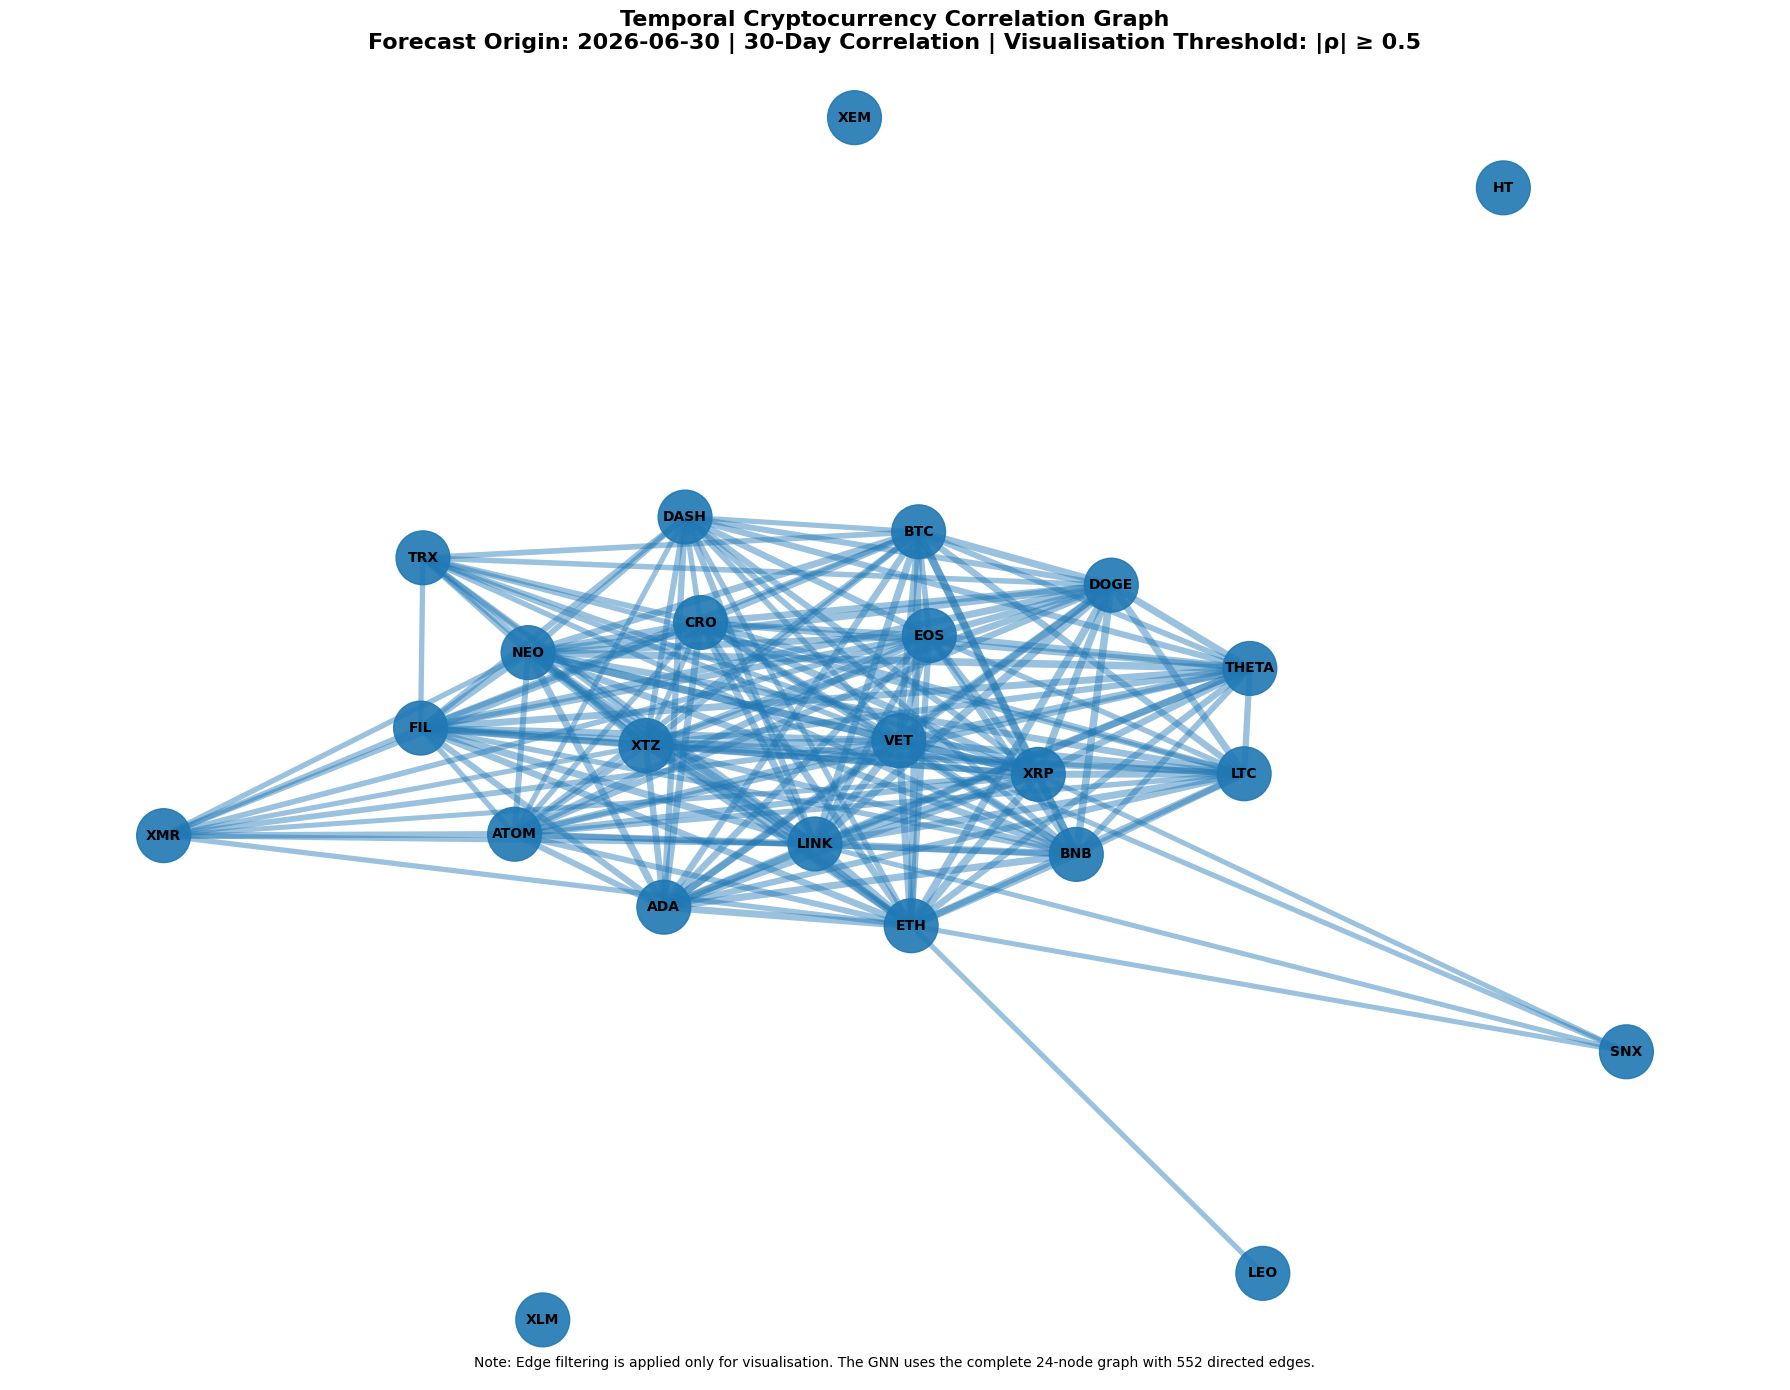


GRAPH SUMMARY
Nodes: 24
Displayed Edges: 162
Positive Edges: 162
Negative Edges: 0
Actual GNN Directed Edges: 552
Unique Cryptocurrency Pairs: 276


In [55]:
#====================================================
# VISUALIZE TEMPORAL CRYPTOCURRENCY GRAPH
#
# IMPORTANT:
# The GNN uses the COMPLETE directed graph with
# 552 directed edges.
#
# The threshold below is ONLY for visualization
# to prevent the figure becoming overcrowded.
#====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx


#====================================================
# PARAMETERS
#====================================================

VISUAL_CORR_THRESHOLD = 0.50

# Choose one forecast-origin date
VISUAL_DATE = pd.Timestamp("2026-06-30")


#====================================================
# CHECK DATE
#====================================================

if VISUAL_DATE not in returns_wide.index:

    raise ValueError(
        f"{VISUAL_DATE.date()} is not available "
        "in returns_wide."
    )


#====================================================
# CONSTRUCT 30-DAY CORRELATION MATRIX
# AT FORECAST ORIGIN
#====================================================

window_returns = returns_wide.loc[
    :VISUAL_DATE
].tail(BASE_CORR_WINDOW)


if len(window_returns) != BASE_CORR_WINDOW:

    raise ValueError(
        "Insufficient observations for "
        "30-day correlation matrix."
    )


corr_matrix = window_returns.corr()


print(
    "Forecast Origin:",
    VISUAL_DATE.date()
)

print(
    "Correlation Window:",
    window_returns.index.min().date(),
    "to",
    window_returns.index.max().date()
)


#====================================================
# CREATE UNDIRECTED GRAPH FOR VISUALIZATION
#
# NOTE:
# The model uses a directed complete graph.
# An undirected representation is used here because
# correlation is symmetric:
#
# rho(i,j) = rho(j,i)
#====================================================

G = nx.Graph()


#====================================================
# ADD 24 CRYPTOCURRENCY NODES
#====================================================

for ticker in GNN_TICKERS:

    G.add_node(ticker)


#====================================================
# ADD STRONG CORRELATION EDGES
#
# Visualization only.
# The actual GNN retains all pairwise relationships.
#====================================================

for i in range(len(GNN_TICKERS)):

    for j in range(i + 1, len(GNN_TICKERS)):

        ticker_i = GNN_TICKERS[i]

        ticker_j = GNN_TICKERS[j]

        corr = corr_matrix.loc[
            ticker_i,
            ticker_j
        ]

        if pd.isna(corr):
            continue

        if abs(corr) >= VISUAL_CORR_THRESHOLD:

            G.add_edge(
                ticker_i,
                ticker_j,
                correlation=float(corr),
                abs_correlation=float(abs(corr))
            )


#====================================================
# NODE POSITIONS
#
# Fixed seed ensures reproducibility.
#====================================================

pos = nx.spring_layout(
    G,
    seed=2021,
    k=1.2
)


#====================================================
# CLASSIFY EDGES
#====================================================

positive_edges = []

negative_edges = []


for u, v, data in G.edges(data=True):

    if data["correlation"] >= 0:

        positive_edges.append(
            (u, v)
        )

    else:

        negative_edges.append(
            (u, v)
        )


#====================================================
# EDGE WIDTH
#
# Stronger absolute correlation =
# thicker visual connection.
#====================================================

positive_widths = [

    1
    + 5
    * G[u][v]["abs_correlation"]

    for u, v in positive_edges

]


negative_widths = [

    1
    + 5
    * G[u][v]["abs_correlation"]

    for u, v in negative_edges

]


#====================================================
# NODE SIZE
#
# Use RV_30 at forecast origin if available.
# Otherwise use equal node sizes.
#====================================================

day_panel = (

    gnn_panel_df[
        gnn_panel_df["Date"] == VISUAL_DATE
    ]

    .set_index("Ticker")

)


if "RV_30" in day_panel.columns:

    node_rv = (

        day_panel["RV_30"]

        .reindex(GNN_TICKERS)

        .fillna(
            day_panel["RV_30"].median()
        )

    )

    # Scale for visualization
    rv_min = node_rv.min()
    rv_max = node_rv.max()

    if rv_max > rv_min:

        node_sizes = (

            900
            + 2200
            * (
                (node_rv - rv_min)
                /
                (rv_max - rv_min)
            )

        ).tolist()

    else:

        node_sizes = [1500] * len(GNN_TICKERS)

else:

    node_sizes = [1500] * len(GNN_TICKERS)


#====================================================
# CREATE FIGURE
#====================================================

plt.figure(
    figsize=(18, 14)
)


#====================================================
# DRAW NODES
#====================================================

nx.draw_networkx_nodes(

    G,

    pos,

    node_size=node_sizes,

    alpha=0.90

)


#====================================================
# DRAW POSITIVE CORRELATIONS
#====================================================

nx.draw_networkx_edges(

    G,

    pos,

    edgelist=positive_edges,

    width=positive_widths,

    alpha=0.45,

    edge_color="tab:blue"

)


#====================================================
# DRAW NEGATIVE CORRELATIONS
#====================================================

nx.draw_networkx_edges(

    G,

    pos,

    edgelist=negative_edges,

    width=negative_widths,

    alpha=0.65,

    edge_color="tab:red",

    style="dashed"

)


#====================================================
# NODE LABELS
#====================================================

labels = {

    ticker:
    ticker.replace("-USD", "")

    for ticker in GNN_TICKERS

}


nx.draw_networkx_labels(

    G,

    pos,

    labels=labels,

    font_size=10,

    font_weight="bold"

)


#====================================================
# TITLE
#====================================================

plt.title(

    "Temporal Cryptocurrency Correlation Graph\n"
    f"Forecast Origin: {VISUAL_DATE.date()} | "
    f"30-Day Correlation | "
    f"Visualisation Threshold: |ρ| ≥ "
    f"{VISUAL_CORR_THRESHOLD}",

    fontsize=16,

    fontweight="bold"

)


#====================================================
# FOOTNOTE
#====================================================

plt.figtext(

    0.5,

    0.02,

    "Note: Edge filtering is applied only for "
    "visualisation. The GNN uses the complete "
    "24-node graph with 552 directed edges.",

    ha="center",

    fontsize=10

)


plt.axis("off")

plt.tight_layout()

plt.show()


#====================================================
# SUMMARY
#====================================================

print("\nGRAPH SUMMARY")

print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Displayed Edges:",
    G.number_of_edges()
)

print(
    "Positive Edges:",
    len(positive_edges)
)

print(
    "Negative Edges:",
    len(negative_edges)
)

print(
    "Actual GNN Directed Edges:",
    len(GNN_TICKERS)
    *
    (len(GNN_TICKERS) - 1)
)

print(
    "Unique Cryptocurrency Pairs:",
    len(GNN_TICKERS)
    *
    (len(GNN_TICKERS) - 1)
    // 2
)

In [56]:
#====================================================
# PYTORCH DATA UTILITIES
#====================================================

import torch

from torch.utils.data import (
    Dataset,
    DataLoader
)

In [57]:
#====================================================
# PYTORCH DATASET
#====================================================

import torch

from torch.utils.data import (
    Dataset,
    DataLoader
)


class CryptoGraphDataset(
    Dataset
):


    def __init__(
        self,
        samples
    ):

        self.samples = samples


    def __len__(
        self
    ):

        return len(
            self.samples
        )


    def __getitem__(
        self,
        index
    ):


        sample = self.samples[
            index
        ]


        return {

            #================================================
            # NODE FEATURE SEQUENCES
            # Shape:
            # [24 nodes, 30 days, F features]
            #================================================

            "x":

                torch.tensor(

                    sample["X"],

                    dtype=torch.float32

                ),


            #================================================
            # GRAPH EDGE FEATURES
            #
            # 552 directed edges
            # [correlation, |correlation|, sign]
            #================================================

            "edge_attr":

                torch.tensor(

                    sample["Edge_Attr"],

                    dtype=torch.float32

                ),


            #================================================
            # FISHER-Z RESIDUAL TARGET
            #
            # 276 unique cryptocurrency pairs
            #================================================

            "delta_z":

                torch.tensor(

                    sample["Delta_Z"],

                    dtype=torch.float32

                ),


            #================================================
            # BASELINE FISHER-Z
            #================================================

            "baseline_z":

                torch.tensor(

                    sample["Baseline_Z"],

                    dtype=torch.float32

                ),


            #================================================
            # ACTUAL 7-DAY-AHEAD 30-DAY ROLLING CORRELATION
            #================================================

            "future_corr":

                torch.tensor(

                    sample["Target_Corr_30"],

                    dtype=torch.float32

                )

        }


#====================================================
# CREATE DATASETS
#====================================================

train_dataset = CryptoGraphDataset(
    train_samples
)


validation_dataset = CryptoGraphDataset(
    validation_samples
)


test_dataset = CryptoGraphDataset(
    test_samples
)


#====================================================
# CHECK DATASET SIZE
#====================================================

print(
    "Training Samples:",
    len(train_dataset)
)


print(
    "Validation Samples:",
    len(validation_dataset)
)


print(
    "Test Samples:",
    len(test_dataset)
)


#====================================================
# DATA LOADERS
#====================================================

BATCH_SIZE = 4


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    drop_last=False

)


validation_loader = DataLoader(

    validation_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    drop_last=False

)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    drop_last=False

)


print("\n")

print(
    "DataLoaders successfully created."
)

Training Samples: 1738
Validation Samples: 90
Test Samples: 91


DataLoaders successfully created.


In [58]:
#====================================================
# POSITIONAL ENCODING
#====================================================

import math

import torch.nn as nn


class PositionalEncoding(
    nn.Module
):


    def __init__(
        self,
        d_model,
        max_len=500
    ):


        super().__init__()


        pe = torch.zeros(

            max_len,

            d_model

        )


        position = (

            torch.arange(

                0,

                max_len,

                dtype=torch.float32

            )

            .unsqueeze(1)

        )


        div_term = torch.exp(

            torch.arange(

                0,

                d_model,

                2

            ).float()

            *

            (
                -math.log(
                    10000.0
                )

                /

                d_model
            )

        )


        pe[
            :,
            0::2
        ] = torch.sin(

            position
            *
            div_term

        )


        pe[
            :,
            1::2
        ] = torch.cos(

            position
            *
            div_term

        )


        self.register_buffer(

            "pe",

            pe.unsqueeze(0)

        )


    def forward(
        self,
        x
    ):


        return (

            x

            +

            self.pe[
                :,
                :x.size(1)
            ]

        )

In [59]:
#====================================================
# TEMPORAL TRANSFORMER ENCODER
#====================================================

class TemporalTransformer(
    nn.Module
):


    def __init__(
        self,
        input_dim,
        sequence_length=30,
        d_model=128,
        n_heads=8,
        n_layers=4,
        dropout=0.20,
        node_embedding_dim=512
    ):


        super().__init__()


        self.sequence_length = (

            sequence_length

        )


        self.d_model = (

            d_model

        )


        #================================================
        # FEATURE PROJECTION
        #================================================

        self.input_projection = nn.Linear(

            input_dim,

            d_model

        )


        self.position = PositionalEncoding(

            d_model=d_model,

            max_len=sequence_length

        )


        #================================================
        # PRE-NORM TRANSFORMER
        #================================================

        encoder_layer = (

            nn.TransformerEncoderLayer(

                d_model=d_model,

                nhead=n_heads,

                dim_feedforward=512,

                dropout=dropout,

                activation="gelu",

                batch_first=True,

                norm_first=True

            )

        )


        self.transformer = (

            nn.TransformerEncoder(

                encoder_layer,

                num_layers=n_layers

            )

        )


        #================================================
        # 30 x 128 -> 512
        #================================================

        flattened_dim = (

            sequence_length

            *

            d_model

        )


        self.node_mlp = nn.Sequential(

            nn.LayerNorm(
                flattened_dim
            ),

            nn.Linear(
                flattened_dim,
                1024
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                1024,
                node_embedding_dim
            ),

            nn.GELU()

        )


    def forward(
        self,
        x
    ):


        # x:
        # [batch, nodes, sequence, features]


        batch_size = x.shape[0]

        n_nodes = x.shape[1]


        #================================================
        # COMBINE BATCH AND NODE DIMENSIONS
        #================================================

        x = x.reshape(

            batch_size
            *
            n_nodes,

            self.sequence_length,

            -1

        )


        x = self.input_projection(
            x
        )


        x = self.position(
            x
        )


        x = self.transformer(
            x
        )


        #================================================
        # FLATTEN 30 x 128
        #================================================

        x = x.reshape(

            batch_size
            *
            n_nodes,

            -1

        )


        x = self.node_mlp(
            x
        )


        #================================================
        # [B, 24, 512]
        #================================================

        x = x.reshape(

            batch_size,

            n_nodes,

            -1

        )


        return x

In [60]:
#====================================================
# EDGE-AWARE MULTI-HEAD GRAPH ATTENTION
#
# COMPLETE CLASS:
# __init__ + forward MUST BE IN SAME CELL
#====================================================

class EdgeAwareGATLayer(nn.Module):


    def __init__(
        self,
        input_dim,
        output_dim,
        edge_dim=3,
        n_heads=4,
        dropout=0.20
    ):


        super().__init__()


        #================================================
        # CHECK OUTPUT DIMENSION
        #================================================

        assert (

            output_dim
            %
            n_heads
            ==
            0

        ), (

            "output_dim must be divisible "
            "by n_heads."

        )


        self.n_heads = n_heads


        self.head_dim = (

            output_dim
            //
            n_heads

        )


        self.output_dim = output_dim


        #================================================
        # QUERY / KEY / VALUE PROJECTIONS
        #================================================

        self.q_proj = nn.Linear(

            input_dim,

            output_dim

        )


        self.k_proj = nn.Linear(

            input_dim,

            output_dim

        )


        self.v_proj = nn.Linear(

            input_dim,

            output_dim

        )


        #================================================
        # EDGE ATTRIBUTE PROJECTION
        #
        # Edge attributes:
        #
        # 1. Historical correlation
        # 2. Absolute correlation
        # 3. Correlation sign
        #
        # Produces one edge bias per attention head
        #================================================

        self.edge_proj = nn.Linear(

            edge_dim,

            n_heads

        )


        #================================================
        # OUTPUT PROJECTION
        #================================================

        self.output_proj = nn.Linear(

            output_dim,

            output_dim

        )


        #================================================
        # REGULARIZATION
        #================================================

        self.dropout = nn.Dropout(

            dropout

        )


        #================================================
        # RESIDUAL PROJECTION
        #
        # Usually input_dim = output_dim = 512.
        # This also makes the layer robust if dimensions
        # differ in a future specification.
        #================================================

        if input_dim == output_dim:


            self.residual_projection = (

                nn.Identity()

            )


        else:


            self.residual_projection = (

                nn.Linear(

                    input_dim,

                    output_dim

                )

            )


        #================================================
        # LAYER NORMALIZATION
        #================================================

        self.norm = nn.LayerNorm(

            output_dim

        )


    #====================================================
    # FORWARD PASS
    #====================================================

    def forward(
        self,
        node_embeddings,
        edge_attributes
    ):


        #================================================
        # INPUT DIMENSIONS
        #
        # node_embeddings:
        #
        # [B, N, D]
        #
        # Example:
        # [4, 24, 512]
        #
        #
        # edge_attributes:
        #
        # [B, E, 3]
        #
        # Example:
        # [4, 552, 3]
        #================================================


        B = node_embeddings.shape[0]

        N = node_embeddings.shape[1]


        #================================================
        # SAVE RESIDUAL
        #================================================

        residual = (

            self.residual_projection(

                node_embeddings

            )

        )


        #================================================
        # QUERY
        #
        # [B,N,D]
        #
        # ->
        #
        # [B,H,N,Head_Dim]
        #================================================

        Q = (

            self.q_proj(

                node_embeddings

            )

            .reshape(

                B,

                N,

                self.n_heads,

                self.head_dim

            )

            .transpose(

                1,

                2

            )

        )


        #================================================
        # KEY
        #================================================

        K = (

            self.k_proj(

                node_embeddings

            )

            .reshape(

                B,

                N,

                self.n_heads,

                self.head_dim

            )

            .transpose(

                1,

                2

            )

        )


        #================================================
        # VALUE
        #================================================

        V = (

            self.v_proj(

                node_embeddings

            )

            .reshape(

                B,

                N,

                self.n_heads,

                self.head_dim

            )

            .transpose(

                1,

                2

            )

        )


        #================================================
        # SCALED DOT-PRODUCT ATTENTION
        #
        # Output:
        #
        # [B,H,N,N]
        #================================================

        attention_scores = (

            torch.matmul(

                Q,

                K.transpose(

                    -2,

                    -1

                )

            )

            /

            math.sqrt(

                self.head_dim

            )

        )


        #================================================
        # PROJECT EDGE ATTRIBUTES
        #
        # [B,552,3]
        #
        # ->
        #
        # [B,552,H]
        #================================================

        edge_bias = (

            self.edge_proj(

                edge_attributes

            )

        )


        #================================================
        # CREATE DENSE EDGE-BIAS MATRIX
        #
        # [B,H,N,N]
        #================================================

        bias_matrix = torch.zeros(

            B,

            self.n_heads,

            N,

            N,

            dtype=
                node_embeddings.dtype,

            device=
                node_embeddings.device

        )


        #================================================
        # DIRECTED EDGE INDICES
        #
        # edge_index:
        #
        # [2,552]
        #================================================

        src = torch.as_tensor(

            edge_index[0],

            dtype=torch.long,

            device=
                node_embeddings.device

        )


        dst = torch.as_tensor(

            edge_index[1],

            dtype=torch.long,

            device=
                node_embeddings.device

        )


        #================================================
        # INSERT EDGE BIASES
        #
        # edge_bias:
        #
        # [B,E,H]
        #
        # ->
        #
        # [B,H,E]
        #================================================

        edge_bias = (

            edge_bias

            .permute(

                0,

                2,

                1

            )

        )


        bias_matrix[

            :,

            :,

            src,

            dst

        ] = edge_bias


        #================================================
        # ADD EDGE INFORMATION TO ATTENTION
        #================================================

        attention_scores = (

            attention_scores

            +

            bias_matrix

        )


        #================================================
        # SOFTMAX
        #
        # Attention weights sum to 1 across
        # neighbouring/destination nodes.
        #================================================

        attention_weights = (

            torch.softmax(

                attention_scores,

                dim=-1

            )

        )


        attention_weights = (

            self.dropout(

                attention_weights

            )

        )


        #================================================
        # AGGREGATE VALUE VECTORS
        #
        # [B,H,N,N]
        #
        # x
        #
        # [B,H,N,Head_Dim]
        #
        # ->
        #
        # [B,H,N,Head_Dim]
        #================================================

        output = torch.matmul(

            attention_weights,

            V

        )


        #================================================
        # CONCATENATE ATTENTION HEADS
        #
        # ->
        #
        # [B,N,D]
        #================================================

        output = (

            output

            .transpose(

                1,

                2

            )

            .contiguous()

            .reshape(

                B,

                N,

                self.output_dim

            )

        )


        #================================================
        # OUTPUT PROJECTION
        #================================================

        output = (

            self.output_proj(

                output

            )

        )


        output = (

            self.dropout(

                output

            )

        )


        #================================================
        # RESIDUAL CONNECTION + NORMALIZATION
        #================================================

        output = (

            self.norm(

                residual

                +

                output

            )

        )


        #================================================
        # RETURN
        #================================================

        return (

            output,

            attention_weights

        )

In [61]:
#====================================================
# RELATIONAL GAT
#====================================================

class RelationalGAT(nn.Module):


    def __init__(
        self,
        embedding_dim=512,
        edge_dim=3,
        n_heads=4,
        n_layers=3,
        dropout=0.20
    ):


        super().__init__()


        self.layers = nn.ModuleList(

            [

                EdgeAwareGATLayer(

                    input_dim=
                        embedding_dim,

                    output_dim=
                        embedding_dim,

                    edge_dim=
                        edge_dim,

                    n_heads=
                        n_heads,

                    dropout=
                        dropout

                )

                for _ in range(
                    n_layers
                )

            ]

        )


    def forward(
        self,
        x,
        edge_attr
    ):


        attentions = []


        for layer in self.layers:


            x, attention = layer(

                x,

                edge_attr

            )


            attentions.append(

                attention

            )


        return (

            x,

            attentions

        )

In [62]:
#====================================================
# PAIR EXPERT
#====================================================

class PairExpert(
    nn.Module
):


    def __init__(
        self,
        input_dim,
        dropout=0.20
    ):


        super().__init__()


        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                512
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                512,
                128
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                128,
                1
            )

        )


    def forward(
        self,
        x
    ):


        return (

            self.network(
                x
            )

            .squeeze(
                -1
            )

        )

In [63]:
#====================================================
# COMPLETE CRYPTO TRANSFORMER-GAT MODEL
#
# IMPORTANT:
# __init__ AND forward() MUST BE IN THE SAME CLASS
#====================================================

class CryptoTHGNN(nn.Module):


    def __init__(
        self,
        input_dim,
        sequence_length=30,
        d_model=128,
        transformer_heads=8,
        transformer_layers=4,
        node_embedding_dim=512,
        gat_heads=4,
        gat_layers=3,
        edge_dim=3,
        dropout=0.20
    ):


        super().__init__()


        #================================================
        # 1. TEMPORAL TRANSFORMER ENCODER
        #================================================

        self.temporal_encoder = TemporalTransformer(

            input_dim=input_dim,

            sequence_length=sequence_length,

            d_model=d_model,

            n_heads=transformer_heads,

            n_layers=transformer_layers,

            dropout=dropout,

            node_embedding_dim=node_embedding_dim

        )


        #================================================
        # 2. GRAPH ATTENTION ENCODER
        #================================================

        self.graph_encoder = RelationalGAT(

            embedding_dim=node_embedding_dim,

            edge_dim=edge_dim,

            n_heads=gat_heads,

            n_layers=gat_layers,

            dropout=dropout

        )


        #================================================
        # 3. PAIR REPRESENTATION DIMENSION
        #
        # For each pair (i,j), concatenate:
        #
        # h_i
        # h_j
        # |h_i - h_j|
        # h_i * h_j
        # edge attributes
        #
        # Therefore:
        #
        # 4 * node_embedding_dim + edge_dim
        #================================================

        pair_dim = (

            node_embedding_dim
            *
            4

            +

            edge_dim

        )


        #================================================
        # 4. RELATION-SPECIFIC EXPERTS
        #================================================

        self.negative_expert = PairExpert(

            input_dim=pair_dim,

            dropout=dropout

        )


        self.middle_expert = PairExpert(

            input_dim=pair_dim,

            dropout=dropout

        )


        self.positive_expert = PairExpert(

            input_dim=pair_dim,

            dropout=dropout

        )


    #====================================================
    # FORWARD PASS
    #====================================================

    def forward(
        self,
        x,
        edge_attr
    ):


        #================================================
        # INPUT:
        #
        # x
        # [B, 24, 30, F]
        #
        # edge_attr
        # [B, 552, 3]
        #================================================


        #================================================
        # 1. TEMPORAL TRANSFORMER
        #
        # [B, 24, 30, F]
        #       ↓
        # [B, 24, 512]
        #================================================

        node_embeddings = self.temporal_encoder(

            x

        )


        #================================================
        # 2. GRAPH ATTENTION NETWORK
        #
        # Incorporates relationships between
        # cryptocurrencies
        #================================================

        (
            node_embeddings,
            attentions

        ) = self.graph_encoder(

            node_embeddings,

            edge_attr

        )


        #================================================
        # 3. CREATE PAIR PREDICTIONS
        #
        # One prediction for each of the
        # 276 unique cryptocurrency pairs
        #================================================

        pair_predictions = []


        for pair_position, (
            i,
            j

        ) in enumerate(
            PAIR_LIST
        ):


            #================================================
            # NODE i EMBEDDING
            #================================================

            h_i = node_embeddings[

                :,
                i,
                :

            ]


            #================================================
            # NODE j EMBEDDING
            #================================================

            h_j = node_embeddings[

                :,
                j,
                :

            ]


            #================================================
            # FIND EDGE ATTRIBUTES
            #
            # Each unique pair created two directed edges:
            #
            # i -> j
            # j -> i
            #
            # Therefore first directed edge:
            #
            # pair_position * 2
            #================================================

            directed_edge_position = (

                pair_position
                *
                2

            )


            pair_edge_attr = edge_attr[

                :,
                directed_edge_position,
                :

            ]


            #================================================
            # PAIR REPRESENTATION
            #
            # [h_i,
            #  h_j,
            #  |h_i-h_j|,
            #  h_i*h_j,
            #  edge attributes]
            #================================================

            pair_representation = torch.cat(

                [

                    h_i,

                    h_j,

                    torch.abs(
                        h_i - h_j
                    ),

                    h_i * h_j,

                    pair_edge_attr

                ],

                dim=-1

            )


            #================================================
            # HISTORICAL 30-DAY CORRELATION
            #
            # First edge attribute = correlation
            #================================================

            baseline_corr = pair_edge_attr[

                :,
                0

            ]


            #================================================
            # 4. RELATION-SPECIFIC EXPERTS
            #================================================

            negative_prediction = (

                self.negative_expert(

                    pair_representation

                )

            )


            middle_prediction = (

                self.middle_expert(

                    pair_representation

                )

            )


            positive_prediction = (

                self.positive_expert(

                    pair_representation

                )

            )


            #================================================
            # 5. ROUTE ACCORDING TO CURRENT RELATIONSHIP
            #
            # Negative:
            # rho < -0.20
            #
            # Middle:
            # -0.20 <= rho <= 0.20
            #
            # Positive:
            # rho > 0.20
            #================================================

            prediction = torch.where(

                baseline_corr
                <
                NEGATIVE_THRESHOLD,

                negative_prediction,


                torch.where(

                    baseline_corr
                    >
                    POSITIVE_THRESHOLD,

                    positive_prediction,

                    middle_prediction

                )

            )


            pair_predictions.append(

                prediction

            )


        #================================================
        # 6. STACK ALL PAIR PREDICTIONS
        #
        # [B, 276]
        #
        # Each value is predicted:
        #
        # Delta Fisher-Z
        #================================================

        delta_z_prediction = torch.stack(

            pair_predictions,

            dim=1

        )


        return (

            delta_z_prediction,

            attentions

        )

In [64]:
#====================================================
# NOTE
#====================================================
# The complete CryptoTHGNN.forward() method is defined
# inside the CryptoTHGNN class in the previous cell.
#
# A duplicated standalone forward() block was removed
# because it was redundant and could cause indentation /
# execution errors.
#====================================================


In [65]:
#====================================================
# DEVICE
#====================================================

SEED = 2021


np.random.seed(
    SEED
)


torch.manual_seed(
    SEED
)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)


print(
    "Device:",
    device
)

Device: cpu


In [66]:
#====================================================
# INITIALIZE MODEL
#====================================================

INPUT_DIM = len(
    GNN_MODEL_FEATURES
)


model = CryptoTHGNN(

    input_dim=
        INPUT_DIM,

    sequence_length=
        SEQUENCE_LENGTH,

    d_model=128,

    transformer_heads=8,

    transformer_layers=4,

    node_embedding_dim=512,

    gat_heads=4,

    gat_layers=3,

    edge_dim=3,

    dropout=0.20

).to(device)


print(
    model
)

CryptoTHGNN(
  (temporal_encoder): TemporalTransformer(
    (input_projection): Linear(in_features=221, out_features=128, bias=True)
    (position): PositionalEncoding()
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
          (dropout1): Dropout(p=0.2, inplace=False)
          (dropout2): Dropout(p=0.2, inplace=False)
        )
      )
    )
    (node_mlp): Sequential(
      (0): LayerNorm((3840,), eps=1e-05

In [67]:
#====================================================
# LOSS
#====================================================

criterion = nn.MSELoss()


#====================================================
# OPTIMIZER
#====================================================

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 75


optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY

)


#====================================================
# COSINE LEARNING-RATE SCHEDULER
#====================================================

scheduler = (

    torch.optim.lr_scheduler.CosineAnnealingLR(

        optimizer,

        T_max=
            MAX_EPOCHS

    )

)

In [68]:
#====================================================
# FINAL GNN DIMENSION CHECK BEFORE TRAINING
#====================================================

#====================================================
# DEFINE NUMBER OF NODE FEATURES
#====================================================

NUM_NODE_FEATURES = len(
    GNN_MODEL_FEATURES
)


#====================================================
# CHECK REQUIRED OBJECTS EXIST
#====================================================

if len(gnn_samples) == 0:

    raise ValueError(
        "gnn_samples is empty. "
        "Run the temporal graph sample construction "
        "before training the GNN."
    )


if len(feature_tensor_by_date) == 0:

    raise ValueError(
        "feature_tensor_by_date is empty. "
        "Run the GNN feature tensor construction first."
    )


#====================================================
# NUMBER OF EXPECTED UNIQUE PAIRS
#====================================================

EXPECTED_NUM_PAIRS = (

    N_COINS
    *
    (
        N_COINS - 1
    )
    //
    2

)


#====================================================
# SAMPLE FEATURE DIMENSION
#====================================================

sample_x_shape = (

    gnn_samples[0][
        "X"
    ].shape

)


sample_feature_dimension = (
    sample_x_shape[-1]
)


#====================================================
# FEATURE TENSOR DIMENSION
#====================================================

first_feature_date = sorted(
    feature_tensor_by_date.keys()
)[0]


feature_tensor_shape = (

    feature_tensor_by_date[
        first_feature_date
    ].shape

)


tensor_feature_dimension = (
    feature_tensor_shape[-1]
)


#====================================================
# CHECK MODEL FEATURE LIST
#====================================================

assert (

    NUM_NODE_FEATURES
    ==
    len(
        GNN_MODEL_FEATURES
    )

), (
    "NUM_NODE_FEATURES does not match "
    "GNN_MODEL_FEATURES."
)


#====================================================
# CHECK GNN SAMPLE DIMENSION
#====================================================

assert (

    sample_feature_dimension
    ==
    NUM_NODE_FEATURES

), (
    "GNN sample feature dimension mismatch. "
    f"GNN sample contains {sample_feature_dimension} "
    f"features, but GNN_MODEL_FEATURES contains "
    f"{NUM_NODE_FEATURES} features."
)


#====================================================
# CHECK FEATURE TENSOR DIMENSION
#====================================================

assert (

    tensor_feature_dimension
    ==
    NUM_NODE_FEATURES

), (
    "feature_tensor_by_date dimension mismatch. "
    f"Tensor contains {tensor_feature_dimension} "
    f"features, but GNN_MODEL_FEATURES contains "
    f"{NUM_NODE_FEATURES} features."
)


#====================================================
# CHECK NUMBER OF NODES
#====================================================

assert (

    sample_x_shape[0]
    ==
    N_COINS

), (
    "Number of nodes in GNN sample does not "
    "match N_COINS."
)


#====================================================
# CHECK SEQUENCE LENGTH
#====================================================

assert (

    sample_x_shape[1]
    ==
    SEQUENCE_LENGTH

), (
    "Sequence length in GNN sample does not "
    "match SEQUENCE_LENGTH."
)


#====================================================
# CHECK PAIR COUNT
#====================================================

assert (

    len(
        PAIR_LIST
    )
    ==
    EXPECTED_NUM_PAIRS

), (
    "PAIR_LIST does not contain the expected "
    "number of unique cryptocurrency pairs."
)


#====================================================
# CHECK TARGET DIMENSION
#====================================================

assert (

    gnn_samples[0][
        "Delta_Z"
    ].shape[0]
    ==
    EXPECTED_NUM_PAIRS

), (
    "Delta_Z target dimension does not match "
    "the expected number of cryptocurrency pairs."
)


#====================================================
# CHECK BASELINE DIMENSION
#====================================================

assert (

    gnn_samples[0][
        "Baseline_Z"
    ].shape[0]
    ==
    EXPECTED_NUM_PAIRS

), (
    "Baseline_Z dimension does not match "
    "the expected number of cryptocurrency pairs."
)


#====================================================
# CHECK TARGET CORRELATION MATRIX
#====================================================

assert (

    gnn_samples[0][
        "Target_Corr_30"
    ].shape
    ==
    (
        N_COINS,
        N_COINS
    )

), (
    "Target correlation matrix has "
    "incorrect dimensions."
)


#====================================================
# CHECK MODEL INPUT DIMENSION
#====================================================

assert (

    INPUT_DIM
    ==
    NUM_NODE_FEATURES

), (
    "INPUT_DIM used to initialize CryptoTHGNN "
    "does not match GNN_MODEL_FEATURES."
)


#====================================================
# PRINT FINAL CONFIGURATION
#====================================================

print(
    "\n========================================"
)

print(
    "GNN INPUT DIMENSION CHECK"
)

print(
    "========================================"
)


print(
    "Cryptocurrencies:",
    N_COINS
)


print(
    "Sequence Length:",
    SEQUENCE_LENGTH
)


print(
    "Node Features:",
    NUM_NODE_FEATURES
)


print(
    "Continuous Features:",
    len(
        NORMALIZED_CONTINUOUS_FEATURES
    )
)


print(
    "Binary Features:",
    len(
        binary_features
    )
)


print(
    "Unique Pairs:",
    len(
        PAIR_LIST
    )
)


print(
    "Sample X Shape:",
    sample_x_shape
)


print(
    "Feature Tensor Shape:",
    feature_tensor_shape
)


print(
    "Delta Z Shape:",
    gnn_samples[0][
        "Delta_Z"
    ].shape
)


print(
    "Baseline Z Shape:",
    gnn_samples[0][
        "Baseline_Z"
    ].shape
)


print(
    "Target Correlation Shape:",
    gnn_samples[0][
        "Target_Corr_30"
    ].shape
)


print(
    "\nDimension Check: PASSED"
)


GNN INPUT DIMENSION CHECK
Cryptocurrencies: 24
Sequence Length: 30
Node Features: 221
Continuous Features: 35
Binary Features: 186
Unique Pairs: 276
Sample X Shape: (24, 30, 221)
Feature Tensor Shape: (24, 221)
Delta Z Shape: (276,)
Baseline Z Shape: (276,)
Target Correlation Shape: (24, 24)

Dimension Check: PASSED


In [69]:
#====================================================
# TRAIN GNN
# SAVE BEST MODEL PERMANENTLY
#====================================================
'''
import os
import numpy as np
import pandas as pd
import torch


#====================================================
# TRAINING CONFIGURATION
#====================================================

PATIENCE = 12

GRAD_CLIP = 1.0


#====================================================
# NUMBER OF NODE FEATURES
#====================================================

NUM_NODE_FEATURES = len(
    GNN_MODEL_FEATURES
)


#====================================================
# SAFETY CHECK BEFORE TRAINING
#====================================================

assert (

    INPUT_DIM
    ==
    NUM_NODE_FEATURES

), (
    "Model INPUT_DIM does not match "
    "GNN_MODEL_FEATURES."
)


assert (

    gnn_samples[0]["X"].shape[-1]
    ==
    NUM_NODE_FEATURES

), (
    "GNN sample feature dimension does not "
    "match GNN_MODEL_FEATURES."
)


#====================================================
# CREATE CHECKPOINT DIRECTORY
#====================================================

CHECKPOINT_DIR = (
    "GNN_Checkpoints"
)


os.makedirs(

    CHECKPOINT_DIR,

    exist_ok=True

)


#====================================================
# BEST MODEL PATH
#====================================================

BEST_MODEL_PATH = os.path.join(

    CHECKPOINT_DIR,

    "best_gnn_model.pt"

)


#====================================================
# TRAINING HISTORY PATH
#====================================================

TRAINING_HISTORY_PATH = os.path.join(

    CHECKPOINT_DIR,

    "gnn_training_history.csv"

)


#====================================================
# INITIALIZE TRAINING TRACKING
#====================================================

best_validation_loss = np.inf

best_epoch = 0

patience_counter = 0


train_history = []

validation_history = []


print(
    "\n========================================"
)

print(
    "STARTING GNN TRAINING"
)

print(
    "========================================"
)


print(
    "Node Features:",
    NUM_NODE_FEATURES
)


print(
    "Training Samples:",
    len(
        train_dataset
    )
)


print(
    "Validation Samples:",
    len(
        validation_dataset
    )
)


print(
    "Maximum Epochs:",
    MAX_EPOCHS
)


print(
    "Early-Stopping Patience:",
    PATIENCE
)


print(
    "Best GNN checkpoint will be saved to:"
)


print(
    BEST_MODEL_PATH
)


#====================================================
# TRAINING LOOP
#====================================================

for epoch in range(

    1,

    MAX_EPOCHS + 1

):


    #================================================
    # TRAINING MODE
    #================================================

    model.train()


    total_train_loss = 0.0

    train_observations = 0


    #================================================
    # LOOP THROUGH TRAINING BATCHES
    #================================================

    for batch in train_loader:


        #============================================
        # MOVE DATA TO DEVICE
        #============================================

        x = batch[
            "x"
        ].to(
            device
        )


        edge_attr = batch[
            "edge_attr"
        ].to(
            device
        )


        target = batch[
            "delta_z"
        ].to(
            device
        )


        #============================================
        # RESET GRADIENTS
        #============================================

        optimizer.zero_grad()


        #============================================
        # FORWARD PASS
        #============================================

        prediction, _ = model(

            x,

            edge_attr

        )


        #============================================
        # CALCULATE TRAINING LOSS
        #============================================

        loss = criterion(

            prediction,

            target

        )


        #============================================
        # BACKPROPAGATION
        #============================================

        loss.backward()


        #============================================
        # GRADIENT CLIPPING
        #============================================

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=GRAD_CLIP

        )


        #============================================
        # UPDATE MODEL PARAMETERS
        #============================================

        optimizer.step()


        #============================================
        # ACCUMULATE LOSS
        #============================================

        batch_size = (
            x.size(0)
        )


        total_train_loss += (

            loss.item()

            *

            batch_size

        )


        train_observations += (
            batch_size
        )


    #================================================
    # CHECK TRAINING LOADER
    #================================================

    if train_observations == 0:

        raise ValueError(
            "No training observations were processed."
        )


    #================================================
    # AVERAGE TRAINING LOSS
    #================================================

    train_loss = (

        total_train_loss

        /

        train_observations

    )


    #================================================
    # VALIDATION MODE
    #================================================

    model.eval()


    total_validation_loss = 0.0

    validation_observations = 0


    #================================================
    # VALIDATION
    #================================================

    with torch.no_grad():


        for batch in validation_loader:


            #========================================
            # MOVE DATA TO DEVICE
            #========================================

            x = batch[
                "x"
            ].to(
                device
            )


            edge_attr = batch[
                "edge_attr"
            ].to(
                device
            )


            target = batch[
                "delta_z"
            ].to(
                device
            )


            #========================================
            # FORWARD PASS
            #========================================

            prediction, _ = model(

                x,

                edge_attr

            )


            #========================================
            # VALIDATION LOSS
            #========================================

            loss = criterion(

                prediction,

                target

            )


            #========================================
            # ACCUMULATE VALIDATION LOSS
            #========================================

            batch_size = (
                x.size(0)
            )


            total_validation_loss += (

                loss.item()

                *

                batch_size

            )


            validation_observations += (
                batch_size
            )


    #================================================
    # CHECK VALIDATION LOADER
    #================================================

    if validation_observations == 0:

        raise ValueError(
            "No validation observations were processed."
        )


    #================================================
    # AVERAGE VALIDATION LOSS
    #================================================

    validation_loss = (

        total_validation_loss

        /

        validation_observations

    )


    #================================================
    # STORE TRAINING HISTORY
    #================================================

    train_history.append(
        train_loss
    )


    validation_history.append(
        validation_loss
    )


    #================================================
    # UPDATE LEARNING-RATE SCHEDULER
    #================================================

    scheduler.step()


    #================================================
    # CHECK FOR NEW BEST MODEL
    #================================================

    if (

        validation_loss

        <

        best_validation_loss

    ):


        #============================================
        # UPDATE BEST PERFORMANCE
        #============================================

        best_validation_loss = (
            validation_loss
        )


        best_epoch = (
            epoch
        )


        patience_counter = 0


        #============================================
        # CREATE COMPLETE CHECKPOINT
        #============================================

        checkpoint = {


            #========================================
            # BEST EPOCH
            #========================================

            "epoch":
                epoch,


            #========================================
            # MODEL PARAMETERS
            #========================================

            "model_state_dict":
                model.state_dict(),


            #========================================
            # OPTIMIZER STATE
            #========================================

            "optimizer_state_dict":
                optimizer.state_dict(),


            #========================================
            # SCHEDULER STATE
            #========================================

            "scheduler_state_dict":
                scheduler.state_dict(),


            #========================================
            # PERFORMANCE
            #========================================

            "best_validation_loss":
                best_validation_loss,

            "train_loss":
                train_loss,

            "validation_loss":
                validation_loss,


            #========================================
            # LOSS HISTORY
            #========================================

            "train_history":
                train_history.copy(),

            "validation_history":
                validation_history.copy(),


            #========================================
            # GNN DATA CONFIGURATION
            #========================================

            "n_coins":
                N_COINS,

            "tickers":
                GNN_TICKERS.copy(),

            "sequence_length":
                SEQUENCE_LENGTH,

            "forecast_horizon":
                FORECAST_HORIZON,

            "base_corr_window":
                BASE_CORR_WINDOW,

            "num_node_features":
                NUM_NODE_FEATURES,

            "num_pairs":
                len(
                    PAIR_LIST
                ),


            #========================================
            # FEATURE DEFINITIONS
            #========================================

            "node_features":
                GNN_MODEL_FEATURES.copy(),

            "continuous_features":
                NORMALIZED_CONTINUOUS_FEATURES.copy(),

            "binary_features":
                binary_features.copy(),


            #========================================
            # MODEL CONFIGURATION
            #========================================

            "input_dim":
                INPUT_DIM,

            "d_model":
                128,

            "transformer_heads":
                8,

            "transformer_layers":
                4,

            "node_embedding_dim":
                512,

            "gat_heads":
                4,

            "gat_layers":
                3,

            "edge_dim":
                3,

            "dropout":
                0.20,


            #========================================
            # TRAINING CONFIGURATION
            #========================================

            "max_epochs":
                MAX_EPOCHS,

            "patience":
                PATIENCE,

            "grad_clip":
                GRAD_CLIP

        }


        #============================================
        # SAVE BEST MODEL PERMANENTLY
        #============================================

        torch.save(

            checkpoint,

            BEST_MODEL_PATH

        )


        print(
            "\n>>> NEW BEST MODEL SAVED"
        )


        print(
            f"    Epoch: {epoch}"
        )


        print(

            "    Validation MSE: "
            f"{validation_loss:.8f}"

        )


        print(

            "    File: "
            f"{BEST_MODEL_PATH}"

        )


    else:


        #============================================
        # INCREASE EARLY-STOPPING COUNTER
        #============================================

        patience_counter += 1


    #================================================
    # PRINT EPOCH RESULTS
    #================================================

    print(

        f"Epoch {epoch:03d} | "

        f"Train MSE: "
        f"{train_loss:.8f} | "

        f"Validation MSE: "
        f"{validation_loss:.8f} | "

        f"LR: "
        f"{scheduler.get_last_lr()[0]:.8f} | "

        f"Patience: "
        f"{patience_counter}/{PATIENCE}"

    )


    #================================================
    # EARLY STOPPING
    #================================================

    if patience_counter >= PATIENCE:


        print(

            "\nEarly stopping at "
            f"epoch {epoch}."

        )


        break


#====================================================
# CHECK THAT BEST MODEL WAS SAVED
#====================================================

if not os.path.exists(
    BEST_MODEL_PATH
):

    raise FileNotFoundError(
        "Training completed but no best-model "
        "checkpoint was saved."
    )


#====================================================
# SAVE COMPLETE TRAINING HISTORY
#====================================================

training_summary = pd.DataFrame({

    "Epoch":

        np.arange(
            1,
            len(train_history) + 1
        ),

    "Train_MSE":

        train_history,

    "Validation_MSE":

        validation_history

})


training_summary.to_csv(

    TRAINING_HISTORY_PATH,

    index=False

)


#====================================================
# TRAINING COMPLETE
#====================================================

print(
    "\n========================================"
)

print(
    "GNN TRAINING COMPLETE"
)

print(
    "========================================"
)


print(
    "Best Epoch:",
    best_epoch
)


print(
    "Best Validation MSE:",
    f"{best_validation_loss:.8f}"
)


print(
    "Best Model Saved To:",
    BEST_MODEL_PATH
)


print(
    "Training History Saved To:",
    TRAINING_HISTORY_PATH
)
'''

'\nimport os\nimport numpy as np\nimport pandas as pd\nimport torch\n\n\n#====================================================\n# TRAINING CONFIGURATION\n#====================================================\n\nPATIENCE = 12\n\nGRAD_CLIP = 1.0\n\n\n#====================================================\n# NUMBER OF NODE FEATURES\n#====================================================\n\nNUM_NODE_FEATURES = len(\n    GNN_MODEL_FEATURES\n)\n\n\n#====================================================\n# SAFETY CHECK BEFORE TRAINING\n#====================================================\n\nassert (\n\n    INPUT_DIM\n    ==\n    NUM_NODE_FEATURES\n\n), (\n    "Model INPUT_DIM does not match "\n    "GNN_MODEL_FEATURES."\n)\n\n\nassert (\n\n    gnn_samples[0]["X"].shape[-1]\n    ==\n    NUM_NODE_FEATURES\n\n), (\n    "GNN sample feature dimension does not "\n    "match GNN_MODEL_FEATURES."\n)\n\n\n#====================================================\n# CREATE CHECKPOINT DIRECTORY\n#=============

In [70]:
#====================================================
# LOAD BEST SAVED GNN MODEL
# WITHOUT RETRAINING
#====================================================

import os
import torch


#====================================================
# CHECKPOINT PATH
#====================================================

CHECKPOINT_DIR = "GNN_Checkpoints"

BEST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_gnn_model.pt"
)


#====================================================
# CHECK CHECKPOINT EXISTS
#====================================================

if not os.path.exists(BEST_MODEL_PATH):

    raise FileNotFoundError(
        "\nBest GNN checkpoint was not found.\n"
        f"Expected location:\n{BEST_MODEL_PATH}\n\n"
        "Make sure best_gnn_model.pt is inside "
        "the GNN_Checkpoints folder."
    )


#====================================================
# DEVICE
#====================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Device:",
    device
)


#====================================================
# LOAD SAVED CHECKPOINT FIRST
#====================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)


print(
    "\nCheckpoint found:"
)

print(
    BEST_MODEL_PATH
)


#====================================================
# DISPLAY SAVED MODEL INFORMATION
#====================================================

print(
    "\n========================================"
)

print(
    "SAVED GNN CHECKPOINT"
)

print(
    "========================================"
)

print(
    "Best Epoch:",
    checkpoint["epoch"]
)

print(
    "Best Validation MSE:",
    f"{checkpoint['best_validation_loss']:.8f}"
)

print(
    "Cryptocurrencies:",
    checkpoint["n_coins"]
)

print(
    "Node Features:",
    checkpoint["num_node_features"]
)

print(
    "Unique Pairs:",
    checkpoint["num_pairs"]
)

print(
    "Sequence Length:",
    checkpoint["sequence_length"]
)

print(
    "Forecast Horizon:",
    checkpoint["forecast_horizon"]
)

print(
    "Correlation Window:",
    checkpoint["base_corr_window"]
)


#====================================================
# CURRENT MODEL DIMENSIONS
#====================================================

INPUT_DIM = len(
    GNN_MODEL_FEATURES
)

NUM_NODE_FEATURES = INPUT_DIM


#====================================================
# SAFETY CHECK:
# NUMBER OF CRYPTOCURRENCIES
#====================================================

assert (
    checkpoint["n_coins"]
    ==
    N_COINS
), (
    "ERROR: Number of cryptocurrencies "
    "does not match saved model."
)


#====================================================
# SAFETY CHECK:
# CRYPTOCURRENCY ORDER
#====================================================

assert (
    checkpoint["tickers"]
    ==
    GNN_TICKERS
), (
    "ERROR: Cryptocurrency ticker order "
    "does not match saved model."
)


#====================================================
# SAFETY CHECK:
# SEQUENCE LENGTH
#====================================================

assert (
    checkpoint["sequence_length"]
    ==
    SEQUENCE_LENGTH
), (
    "ERROR: Sequence length does not "
    "match saved model."
)


#====================================================
# SAFETY CHECK:
# FORECAST HORIZON
#====================================================

assert (
    checkpoint["forecast_horizon"]
    ==
    FORECAST_HORIZON
), (
    "ERROR: Forecast horizon does not "
    "match saved model."
)


#====================================================
# SAFETY CHECK:
# CORRELATION WINDOW
#====================================================

assert (
    checkpoint["base_corr_window"]
    ==
    BASE_CORR_WINDOW
), (
    "ERROR: Correlation window does not "
    "match saved model."
)


#====================================================
# SAFETY CHECK:
# NUMBER OF NODE FEATURES
#====================================================

assert (
    checkpoint["num_node_features"]
    ==
    NUM_NODE_FEATURES
), (
    "ERROR: Number of GNN features differs.\n"
    f"Saved: {checkpoint['num_node_features']}\n"
    f"Current: {NUM_NODE_FEATURES}"
)


#====================================================
# SAFETY CHECK:
# EXACT FEATURE LIST AND ORDER
#====================================================

assert (
    checkpoint["node_features"]
    ==
    GNN_MODEL_FEATURES
), (
    "ERROR: Current GNN feature list/order "
    "does not match the trained model."
)


#====================================================
# SAFETY CHECK:
# CONTINUOUS FEATURES
#====================================================

assert (
    checkpoint["continuous_features"]
    ==
    NORMALIZED_CONTINUOUS_FEATURES
), (
    "ERROR: Continuous feature configuration "
    "does not match saved model."
)


#====================================================
# SAFETY CHECK:
# BINARY FEATURES
#====================================================

assert (
    checkpoint["binary_features"]
    ==
    binary_features
), (
    "ERROR: Binary feature configuration "
    "does not match saved model."
)


#====================================================
# SAFETY CHECK:
# NUMBER OF PAIRS
#====================================================

assert (
    checkpoint["num_pairs"]
    ==
    len(PAIR_LIST)
), (
    "ERROR: Number of cryptocurrency pairs "
    "does not match saved model."
)


#====================================================
# CREATE SAME GNN ARCHITECTURE
#
# IMPORTANT:
# Architecture MUST be identical to the model
# used during training.
#====================================================

model = CryptoTHGNN(

    input_dim=INPUT_DIM,

    sequence_length=SEQUENCE_LENGTH,

    d_model=128,

    transformer_heads=8,

    transformer_layers=4,

    node_embedding_dim=512,

    gat_heads=4,

    gat_layers=3,

    edge_dim=3,

    dropout=0.20

).to(device)


#====================================================
# LOAD BEST TRAINED PARAMETERS
#====================================================

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


#====================================================
# SET MODEL TO EVALUATION MODE
#
# IMPORTANT:
# Disables dropout during prediction.
#====================================================

model.eval()


#====================================================
# RESTORE TRAINING INFORMATION
#====================================================

best_epoch = checkpoint[
    "epoch"
]

best_validation_loss = checkpoint[
    "best_validation_loss"
]

train_history = checkpoint[
    "train_history"
]

validation_history = checkpoint[
    "validation_history"
]


#====================================================
# FINAL CHECK
#====================================================

print(
    "\n========================================"
)

print(
    "BEST GNN MODEL LOADED SUCCESSFULLY"
)

print(
    "NO RETRAINING WAS PERFORMED"
)

print(
    "========================================"
)

print(
    "Best Epoch:",
    best_epoch
)

print(
    "Best Validation MSE:",
    f"{best_validation_loss:.8f}"
)

print(
    "Input Features:",
    INPUT_DIM
)

print(
    "Cryptocurrencies:",
    N_COINS
)

print(
    "Unique Pairs:",
    len(PAIR_LIST)
)

print(
    "Device:",
    next(
        model.parameters()
    ).device
)

print(
    "Model Training Mode:",
    model.training
)

print(
    "\nmodel.training = False "
    "means the model is correctly in evaluation mode."
)

Device: cpu

Checkpoint found:
GNN_Checkpoints\best_gnn_model.pt

SAVED GNN CHECKPOINT
Best Epoch: 5
Best Validation MSE: 0.03527586
Cryptocurrencies: 24
Node Features: 221
Unique Pairs: 276
Sequence Length: 30
Forecast Horizon: 7
Correlation Window: 30

BEST GNN MODEL LOADED SUCCESSFULLY
NO RETRAINING WAS PERFORMED
Best Epoch: 5
Best Validation MSE: 0.03527586
Input Features: 221
Cryptocurrencies: 24
Unique Pairs: 276
Device: cpu
Model Training Mode: False

model.training = False means the model is correctly in evaluation mode.


### Training and validation loss of the saved best checkpoint


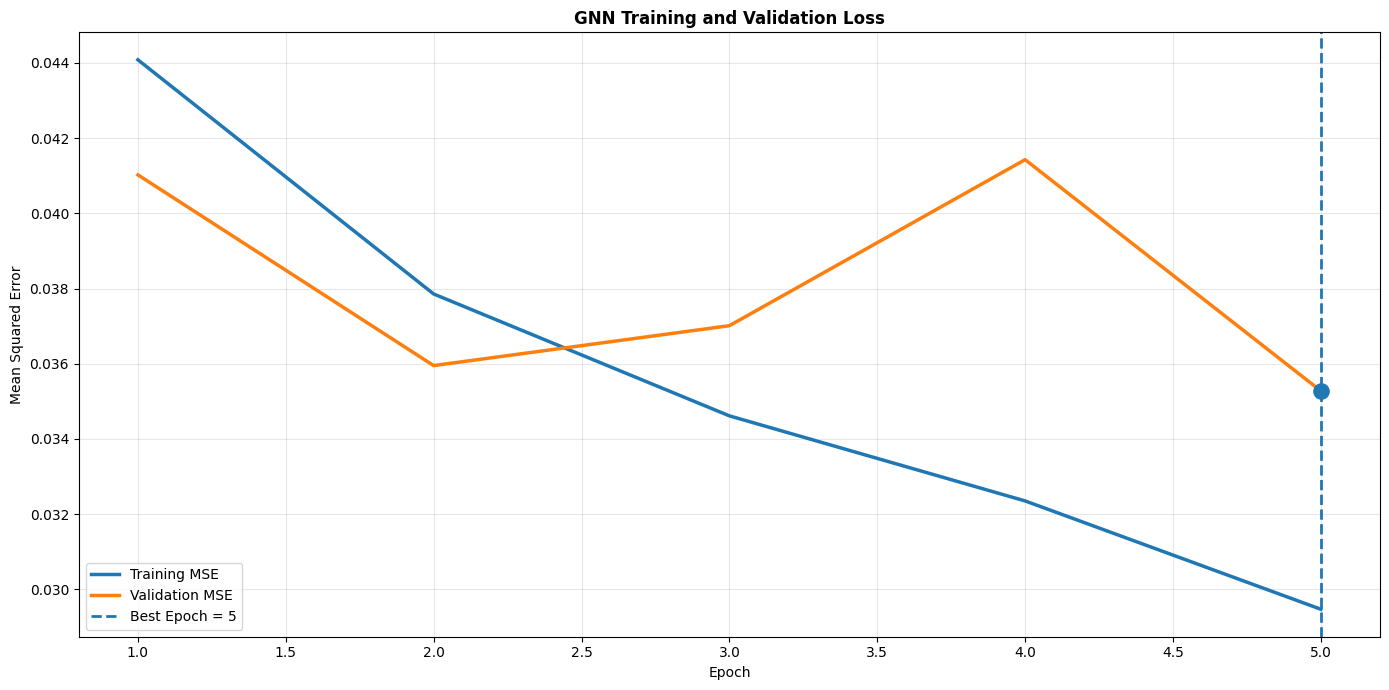

In [71]:
#====================================================
# VISUALIZE GNN TRAINING AND VALIDATION LOSS
#====================================================

import matplotlib.pyplot as plt
import numpy as np


#====================================================
# CREATE EPOCH AXIS
#====================================================

epochs = np.arange(
    1,
    len(train_history) + 1
)


#====================================================
# IDENTIFY BEST VALIDATION EPOCH
#====================================================

best_epoch_plot = (

    np.argmin(
        validation_history
    )
    +
    1

)

best_validation_plot = np.min(
    validation_history
)


#====================================================
# CREATE FIGURE
#====================================================

plt.figure(
    figsize=(14,7)
)


#====================================================
# TRAINING LOSS
#====================================================

plt.plot(

    epochs,

    train_history,

    linewidth=2.5,

    label="Training MSE"

)


#====================================================
# VALIDATION LOSS
#====================================================

plt.plot(

    epochs,

    validation_history,

    linewidth=2.5,

    label="Validation MSE"

)


#====================================================
# BEST EPOCH
#====================================================

plt.axvline(

    x=best_epoch_plot,

    linestyle="--",

    linewidth=2,

    label=(
        f"Best Epoch = "
        f"{best_epoch_plot}"
    )

)


#====================================================
# BEST VALIDATION POINT
#====================================================

plt.scatter(

    best_epoch_plot,

    best_validation_plot,

    s=120,

    zorder=5

)


#====================================================
# LABELS
#====================================================

plt.title(

    "GNN Training and Validation Loss",

    fontweight="bold"

)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Mean Squared Error"
)

plt.grid(
    alpha=0.30
)

plt.legend()

plt.tight_layout()

plt.show()

In [72]:
#====================================================
# GENERATE TEST PREDICTIONS
# FROM SAVED BEST GNN MODEL
#
# NO MODEL TRAINING IS PERFORMED
#====================================================

import numpy as np
import pandas as pd
import torch


#====================================================
# SET MODEL TO EVALUATION MODE
#====================================================

model.eval()


#====================================================
# STORAGE
#====================================================

prediction_results = []

sample_index = 0


#====================================================
# GENERATE TEST PREDICTIONS
#====================================================

with torch.no_grad():

    for batch in test_loader:

        #============================================
        # MOVE INPUTS TO DEVICE
        #
        # IMPORTANT:
        # Your Dataset uses lowercase "x"
        #============================================

        x = batch[
            "x"
        ].to(device)


        edge_attr = batch[
            "edge_attr"
        ].to(device)


        #============================================
        # GNN FORWARD PASS
        #
        # Your CryptoTHGNN returns:
        #
        # predicted_delta_z
        # auxiliary output
        #============================================

        predicted_delta_z, _ = model(

            x,

            edge_attr

        )


        #============================================
        # MOVE PREDICTIONS TO CPU
        #============================================

        predicted_delta_z = (

            predicted_delta_z

            .detach()

            .cpu()

            .numpy()

        )


        #============================================
        # BASELINE FISHER-Z
        #============================================

        baseline_z = (

            batch[
                "baseline_z"
            ]

            .detach()

            .cpu()

            .numpy()

        )


        #============================================
        # ACTUAL FISHER-Z CHANGE
        #
        # IMPORTANT:
        # Your Dataset uses "delta_z"
        # NOT "y"
        #============================================

        actual_delta_z = (

            batch[
                "delta_z"
            ]

            .detach()

            .cpu()

            .numpy()

        )


        #============================================
        # RECONSTRUCT PREDICTED FISHER-Z
        #
        # z_hat(t+7)
        # =
        # z(t) + Delta-z_hat(t+7)
        #============================================

        predicted_z = (

            baseline_z

            +

            predicted_delta_z

        )


        #============================================
        # RECONSTRUCT ACTUAL FISHER-Z
        #============================================

        actual_z = (

            baseline_z

            +

            actual_delta_z

        )


        #============================================
        # CONVERT FISHER-Z BACK TO CORRELATION
        #
        # rho = tanh(z)
        #
        # inverse_fisher() is already defined
        # in your notebook
        #============================================

        predicted_corr = inverse_fisher(

            predicted_z

        )


        actual_corr = inverse_fisher(

            actual_z

        )


        baseline_corr = inverse_fisher(

            baseline_z

        )


        #============================================
        # NUMBER OF GRAPH SAMPLES IN BATCH
        #============================================

        batch_size = (

            predicted_delta_z.shape[0]

        )


        #============================================
        # PROCESS EACH GRAPH SAMPLE
        #============================================

        for b in range(batch_size):


            #========================================
            # GET CORRESPONDING TEST SAMPLE
            #
            # test_loader uses shuffle=False,
            # therefore sequential indexing is valid
            #========================================

            sample = test_samples[
                sample_index
            ]


            sample_index += 1


            #========================================
            # FORECAST ORIGIN
            #========================================

            forecast_origin = pd.to_datetime(

                sample[
                    "Date"
                ]

            )


            #========================================
            # TARGET DATE
            #========================================

            target_date = pd.to_datetime(

                sample[
                    "Target_Date"
                ]

            )


            #========================================
            # STORE ALL 276 UNIQUE PAIRS
            #========================================

            for pair_id, (
                i,
                j
            ) in enumerate(
                PAIR_LIST
            ):


                prediction_results.append({

                    #================================
                    # FORECAST ORIGIN
                    #================================

                    "Date":

                        forecast_origin,


                    #================================
                    # 7-DAY-AHEAD TARGET DATE
                    #================================

                    "Target_Date":

                        target_date,


                    #================================
                    # CRYPTOCURRENCY PAIR
                    #================================

                    "Ticker_1":

                        GNN_TICKERS[i],


                    "Ticker_2":

                        GNN_TICKERS[j],


                    #================================
                    # BASELINE FISHER-Z
                    #================================

                    "Baseline_Z":

                        float(

                            baseline_z[
                                b,
                                pair_id
                            ]

                        ),


                    #================================
                    # GNN PREDICTED CHANGE
                    #================================

                    "Predicted_Delta_Z":

                        float(

                            predicted_delta_z[
                                b,
                                pair_id
                            ]

                        ),


                    #================================
                    # ACTUAL CHANGE
                    #================================

                    "Actual_Delta_Z":

                        float(

                            actual_delta_z[
                                b,
                                pair_id
                            ]

                        ),


                    #================================
                    # PERSISTENCE CORRELATION
                    #================================

                    "Baseline_Correlation":

                        float(

                            baseline_corr[
                                b,
                                pair_id
                            ]

                        ),


                    #================================
                    # RAW GNN PREDICTION
                    #================================

                    "Predicted_Correlation":

                        float(

                            predicted_corr[
                                b,
                                pair_id
                            ]

                        ),


                    #================================
                    # ACTUAL CORRELATION
                    #================================

                    "Actual_Correlation":

                        float(

                            actual_corr[
                                b,
                                pair_id
                            ]

                        )

                })


#====================================================
# CHECK ALL TEST SAMPLES WERE PROCESSED
#====================================================

assert (

    sample_index
    ==
    len(test_samples)

), (

    f"ERROR: Only {sample_index} of "
    f"{len(test_samples)} test samples processed."

)


#====================================================
# CREATE TEST PREDICTION DATAFRAME
#====================================================

prediction_df = pd.DataFrame(

    prediction_results

)


#====================================================
# DATE TYPES
#====================================================

prediction_df[
    "Date"
] = pd.to_datetime(

    prediction_df[
        "Date"
    ]

)


prediction_df[
    "Target_Date"
] = pd.to_datetime(

    prediction_df[
        "Target_Date"
    ]

)


#====================================================
# SORT RESULTS
#====================================================

prediction_df = (

    prediction_df

    .sort_values(

        [

            "Target_Date",

            "Ticker_1",

            "Ticker_2"

        ]

    )

    .reset_index(
        drop=True
    )

)


#====================================================
# TEST PERIOD CHECK
#====================================================

TEST_START = pd.Timestamp(
    "2026-04-01"
)

TEST_END = pd.Timestamp(
    "2026-06-30"
)


assert (

    prediction_df[
        "Target_Date"
    ].min()

    >= TEST_START

), (

    "ERROR: Test predictions start "
    "before 1 April 2026."

)


assert (

    prediction_df[
        "Target_Date"
    ].max()

    <= TEST_END

), (

    "ERROR: Test predictions extend "
    "beyond 30 June 2026."

)


#====================================================
# EXPECTED NUMBER OF PAIRS
#====================================================

EXPECTED_PAIRS = (

    len(GNN_TICKERS)

    *

    (
        len(GNN_TICKERS) - 1
    )

    //

    2

)


#====================================================
# EXPECTED TOTAL FORECASTS
#====================================================

EXPECTED_FORECASTS = (

    len(test_samples)

    *

    EXPECTED_PAIRS

)


assert (

    len(prediction_df)

    ==
    EXPECTED_FORECASTS

), (

    f"ERROR: Expected {EXPECTED_FORECASTS} "
    f"pair forecasts but obtained "
    f"{len(prediction_df)}."

)


#====================================================
# CHECK FINITE VALUES
#====================================================

columns_to_check = [

    "Baseline_Z",

    "Predicted_Delta_Z",

    "Actual_Delta_Z",

    "Baseline_Correlation",

    "Predicted_Correlation",

    "Actual_Correlation"

]


for column in columns_to_check:

    assert np.isfinite(

        prediction_df[
            column
        ].to_numpy()

    ).all(), (

        f"ERROR: Non-finite values "
        f"detected in {column}."

    )


#====================================================
# CHECK CORRELATION BOUNDS
#====================================================

for column in [

    "Baseline_Correlation",

    "Predicted_Correlation",

    "Actual_Correlation"

]:

    assert (

        prediction_df[
            column
        ]

        .between(
            -1.0,
            1.0
        )

        .all()

    ), (

        f"ERROR: {column} contains "
        f"values outside [-1, 1]."

    )


#====================================================
# DISPLAY SUMMARY
#====================================================

print(
    "=" * 70
)

print(
    "GNN TEST PREDICTIONS GENERATED SUCCESSFULLY"
)

print(
    "=" * 70
)


print(
    "Forecast Origin Start :",
    prediction_df[
        "Date"
    ].min()
)


print(
    "Forecast Origin End   :",
    prediction_df[
        "Date"
    ].max()
)


print(
    "Target Start          :",
    prediction_df[
        "Target_Date"
    ].min()
)


print(
    "Target End            :",
    prediction_df[
        "Target_Date"
    ].max()
)


print(
    "Number of Test Dates  :",
    prediction_df[
        "Target_Date"
    ].nunique()
)


print(
    "Unique Pairs          :",
    prediction_df[
        [
            "Ticker_1",
            "Ticker_2"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


print(
    "Total Pair Forecasts  :",
    len(prediction_df)
)


print(
    "Expected Forecasts    :",
    EXPECTED_FORECASTS
)


print(
    "\nColumns:"
)

print(
    prediction_df.columns.tolist()
)


print(
    "\nFirst 5 predictions:"
)

display(
    prediction_df.head()
)

GNN TEST PREDICTIONS GENERATED SUCCESSFULLY
Forecast Origin Start : 2026-03-25 00:00:00
Forecast Origin End   : 2026-06-23 00:00:00
Target Start          : 2026-04-01 00:00:00
Target End            : 2026-06-30 00:00:00
Number of Test Dates  : 91
Unique Pairs          : 276
Total Pair Forecasts  : 25116
Expected Forecasts    : 25116

Columns:
['Date', 'Target_Date', 'Ticker_1', 'Ticker_2', 'Baseline_Z', 'Predicted_Delta_Z', 'Actual_Delta_Z', 'Baseline_Correlation', 'Predicted_Correlation', 'Actual_Correlation']

First 5 predictions:


,Date,Target_Date,Ticker_1,Ticker_2,Baseline_Z,Predicted_Delta_Z,Actual_Delta_Z,Baseline_Correlation,Predicted_Correlation,Actual_Correlation
0,2026-03-25,2026-04-01,ADA-USD,ATOM-USD,0.502633,0.136145,0.506142,0.464186,0.564067,0.765255
1,2026-03-25,2026-04-01,ADA-USD,BNB-USD,1.248041,0.043946,-0.241506,0.847733,0.859646,0.764325
2,2026-03-25,2026-04-01,ADA-USD,CRO-USD,1.358373,0.032489,-0.275756,0.876015,0.883360,0.794168
3,2026-03-25,2026-04-01,ADA-USD,DASH-USD,0.930101,0.131759,-0.002044,0.730641,0.786375,0.729687
4,2026-03-25,2026-04-01,ADA-USD,DOGE-USD,1.515707,0.050607,-0.212208,0.907947,0.916437,0.862621


In [73]:
#====================================================
# APPLY PSD ADJUSTMENT TO GNN TEST PREDICTIONS
#
# INPUT:
# prediction_df["Predicted_Correlation"]
#
# OUTPUT:
# prediction_df["PSD_Predicted_Correlation"]
#====================================================

import os
import numpy as np
import pandas as pd


#====================================================
# CHECK REQUIRED DATA
#====================================================

if "prediction_df" not in globals():

    raise NameError(
        "prediction_df does not exist. "
        "Run the GNN test prediction cell first."
    )


required_columns = [

    "Target_Date",
    "Ticker_1",
    "Ticker_2",
    "Predicted_Correlation"

]


missing_columns = [

    column

    for column in required_columns

    if column not in prediction_df.columns

]


if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


#====================================================
# CHECK PSD FUNCTION EXISTS
#====================================================

if "build_correlation_matrix" not in globals():

    raise NameError(
        "build_correlation_matrix() is not defined. "
        "Run the correlation-matrix/PSD function cell first."
    )


#====================================================
# DATE TYPE
#====================================================

prediction_df[
    "Target_Date"
] = pd.to_datetime(

    prediction_df[
        "Target_Date"
    ]

)


#====================================================
# REMOVE OLD PSD COLUMN IF CELL IS RERUN
#====================================================

if (
    "PSD_Predicted_Correlation"
    in prediction_df.columns
):

    prediction_df = (
        prediction_df
        .drop(
            columns=[
                "PSD_Predicted_Correlation"
            ]
        )
    )


#====================================================
# OUTPUT FOLDER
#====================================================

TEST_MATRIX_FOLDER = (
    "Predicted_Correlation_Matrices"
)


os.makedirs(
    TEST_MATRIX_FOLDER,
    exist_ok=True
)


#====================================================
# STORAGE
#====================================================

predicted_correlation_matrices = {}

psd_pair_records = []


#====================================================
# LOOP THROUGH EACH TEST TARGET DATE
#====================================================

target_dates = sorted(

    prediction_df[
        "Target_Date"
    ].unique()

)


for target_date in target_dates:

    target_date = pd.Timestamp(
        target_date
    )


    #================================================
    # GET 276 PAIR PREDICTIONS FOR THIS DATE
    #================================================

    day_prediction = (

        prediction_df[

            prediction_df[
                "Target_Date"
            ]
            ==
            target_date

        ]

        .copy()

    )


    #================================================
    # CHECK NUMBER OF PAIRS
    #================================================

    expected_pairs = (

        len(GNN_TICKERS)

        *

        (
            len(GNN_TICKERS) - 1
        )

        //

        2

    )


    if len(day_prediction) != expected_pairs:

        raise ValueError(

            f"{target_date.date()}: "
            f"expected {expected_pairs} pairs, "
            f"but found {len(day_prediction)}."

        )


    #================================================
    # BUILD PSD-ADJUSTED CORRELATION MATRIX
    #
    # Your existing function:
    #
    # 1. reconstructs symmetric matrix
    # 2. applies PSD correction
    # 3. restores unit diagonal
    #================================================

    matrix = build_correlation_matrix(

        day_prediction=
            day_prediction,

        tickers=
            GNN_TICKERS,

        value_column=
            "Predicted_Correlation"

    )


    #================================================
    # ENSURE DATAFRAME
    #================================================

    if not isinstance(
        matrix,
        pd.DataFrame
    ):

        matrix = pd.DataFrame(

            matrix,

            index=
                GNN_TICKERS,

            columns=
                GNN_TICKERS

        )


    #================================================
    # STORE MATRIX
    #================================================

    predicted_correlation_matrices[
        target_date
    ] = matrix


    #================================================
    # EXTRACT PSD-ADJUSTED PAIR VALUES
    #================================================

    for _, row in day_prediction.iterrows():

        ticker_1 = row[
            "Ticker_1"
        ]

        ticker_2 = row[
            "Ticker_2"
        ]


        psd_pair_records.append({

            "Target_Date":
                target_date,

            "Ticker_1":
                ticker_1,

            "Ticker_2":
                ticker_2,

            "PSD_Predicted_Correlation":

                float(

                    matrix.loc[
                        ticker_1,
                        ticker_2
                    ]

                )

        })


    #================================================
    # SAVE PSD MATRIX
    #================================================

    matrix.to_csv(

        os.path.join(

            TEST_MATRIX_FOLDER,

            f"{target_date:%Y-%m-%d}.csv"

        )

    )


#====================================================
# CREATE PAIR-LEVEL PSD DATAFRAME
#====================================================

psd_pair_df = pd.DataFrame(

    psd_pair_records

)


#====================================================
# MERGE PSD VALUES BACK INTO prediction_df
#====================================================

prediction_df = (

    prediction_df

    .merge(

        psd_pair_df,

        on=[

            "Target_Date",

            "Ticker_1",

            "Ticker_2"

        ],

        how="left",

        validate="one_to_one"

    )

)


#====================================================
# CHECK FOR MISSING PSD VALUES
#====================================================

missing_psd = (

    prediction_df[
        "PSD_Predicted_Correlation"
    ]

    .isna()

    .sum()

)


assert (
    missing_psd == 0
), (

    f"ERROR: {missing_psd} PSD predictions "
    "are missing."

)


#====================================================
# CHECK FINITE VALUES
#====================================================

assert np.isfinite(

    prediction_df[
        "PSD_Predicted_Correlation"
    ]

).all(), (

    "ERROR: Non-finite PSD correlations detected."

)


#====================================================
# CHECK CORRELATION BOUNDS
#====================================================

assert (

    prediction_df[
        "PSD_Predicted_Correlation"
    ]

    .between(
        -1.0,
        1.0
    )

    .all()

), (

    "ERROR: PSD-adjusted correlations "
    "outside [-1, 1]."

)


#====================================================
# FINAL SUMMARY
#====================================================

print(
    "=" * 70
)

print(
    "PSD ADJUSTMENT COMPLETED SUCCESSFULLY"
)

print(
    "=" * 70
)


print(
    "PSD Matrices:",
    len(
        predicted_correlation_matrices
    )
)


print(
    "Pair Predictions:",
    len(
        prediction_df
    )
)


print(
    "Missing PSD Values:",
    missing_psd
)


print(
    "\nPrediction DataFrame Columns:"
)

print(
    prediction_df.columns.tolist()
)


#====================================================
# DISPLAY RESULTS
#====================================================

display(

    prediction_df[

        [
            "Target_Date",
            "Ticker_1",
            "Ticker_2",
            "Actual_Correlation",
            "Predicted_Correlation",
            "PSD_Predicted_Correlation"
        ]

    ]

    .head(10)

)

PSD ADJUSTMENT COMPLETED SUCCESSFULLY
PSD Matrices: 91
Pair Predictions: 25116
Missing PSD Values: 0

Prediction DataFrame Columns:
['Date', 'Target_Date', 'Ticker_1', 'Ticker_2', 'Baseline_Z', 'Predicted_Delta_Z', 'Actual_Delta_Z', 'Baseline_Correlation', 'Predicted_Correlation', 'Actual_Correlation', 'PSD_Predicted_Correlation']


,Target_Date,Ticker_1,Ticker_2,Actual_Correlation,Predicted_Correlation,PSD_Predicted_Correlation
0,2026-04-01,ADA-USD,ATOM-USD,0.765255,0.564067,0.559744
1,2026-04-01,ADA-USD,BNB-USD,0.764325,0.859646,0.851932
2,2026-04-01,ADA-USD,CRO-USD,0.794168,0.883360,0.876222
3,2026-04-01,ADA-USD,DASH-USD,0.729687,0.786375,0.786240
4,2026-04-01,ADA-USD,DOGE-USD,0.862621,0.916437,0.905907
5,2026-04-01,ADA-USD,EOS-USD,0.739135,0.762428,0.762968
6,2026-04-01,ADA-USD,ETH-USD,0.921184,0.946409,0.946324
7,2026-04-01,ADA-USD,FIL-USD,0.645212,0.817641,0.801242
8,2026-04-01,ADA-USD,HT-USD,-0.268647,0.050636,0.048017
9,2026-04-01,ADA-USD,LEO-USD,-0.189712,0.111135,0.105412


In [74]:
#====================================================
# CREATE FINAL GNN TEST RESULTS
#====================================================

TEST_START = pd.Timestamp(
    "2026-04-01"
)

TEST_END = pd.Timestamp(
    "2026-06-30"
)


gnn_test_results = (

    prediction_df[

        prediction_df[
            "Target_Date"
        ].between(
            TEST_START,
            TEST_END
        )

    ]

    .copy()

    .reset_index(
        drop=True
    )

)


print(
    "Test Dates:",
    gnn_test_results[
        "Target_Date"
    ].nunique()
)

print(
    "Total Forecasts:",
    len(
        gnn_test_results
    )
)

print(
    "PSD column exists:",
    "PSD_Predicted_Correlation"
    in gnn_test_results.columns
)

Test Dates: 91
Total Forecasts: 25116
PSD column exists: True


In [75]:
#====================================================
# FINAL GNN CORRELATION FORECAST EVALUATION
#
# HELD-OUT TEST PERIOD:
# 01 APRIL 2026 - 30 JUNE 2026
#
# MODELS:
# 1. Persistence Baseline
# 2. Raw GNN
# 3. PSD-Adjusted GNN
#
# MAIN METRICS:
# MAE
# RMSE
# Bias
# R²
# Pearson
# Spearman
# Correlation Sign Accuracy
#====================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score
)

from scipy.stats import (
    pearsonr,
    spearmanr
)


#====================================================
# DEFINE FINAL TEST PERIOD
#====================================================

TEST_START = pd.Timestamp(
    "2026-04-01"
)

TEST_END = pd.Timestamp(
    "2026-06-30"
)


#====================================================
# CHECK PREDICTION DATA EXISTS
#====================================================

if "prediction_df" not in globals():

    raise NameError(
        "prediction_df does not exist. "
        "Generate GNN test predictions first."
    )


#====================================================
# CHECK REQUIRED COLUMNS
#====================================================

required_columns = [

    "Target_Date",

    "Ticker_1",

    "Ticker_2",

    "Actual_Correlation",

    "Baseline_Correlation",

    "Predicted_Correlation",

    "PSD_Predicted_Correlation"

]


missing_columns = [

    column

    for column in required_columns

    if column not in prediction_df.columns

]


if missing_columns:

    raise ValueError(

        "Missing required columns: "
        f"{missing_columns}"

    )


#====================================================
# CREATE FINAL TEST DATA
#====================================================

gnn_test_results = (
    prediction_df
    .copy()
)


#====================================================
# CONVERT TARGET DATE
#====================================================

gnn_test_results[
    "Target_Date"
] = pd.to_datetime(

    gnn_test_results[
        "Target_Date"
    ]

)


#====================================================
# STRICTLY FILTER TEST PERIOD
#
# IMPORTANT:
# Evaluation is based on TARGET DATE,
# not forecast-origin date.
#====================================================

gnn_test_results = (

    gnn_test_results[

        gnn_test_results[
            "Target_Date"
        ].between(

            TEST_START,

            TEST_END

        )

    ]

    .copy()

    .reset_index(
        drop=True
    )

)


#====================================================
# SORT RESULTS
#====================================================

gnn_test_results = (

    gnn_test_results

    .sort_values(

        [
            "Target_Date",
            "Ticker_1",
            "Ticker_2"
        ]

    )

    .reset_index(
        drop=True
    )

)


#====================================================
# TEST SAMPLE VALIDATION
#====================================================

number_test_dates = (

    gnn_test_results[
        "Target_Date"
    ]

    .nunique()

)


number_pairs = (

    gnn_test_results[
        [
            "Ticker_1",
            "Ticker_2"
        ]
    ]

    .drop_duplicates()

    .shape[0]

)


number_forecasts = len(
    gnn_test_results
)


expected_pairs = (

    len(GNN_TICKERS)

    *

    (
        len(GNN_TICKERS) - 1
    )

    //

    2

)


expected_forecasts = (

    number_test_dates

    *

    expected_pairs

)


print(
    "=" * 75
)

print(
    "FINAL GNN TEST SAMPLE"
)

print(
    "=" * 75
)


print(
    "Test Start:",
    gnn_test_results[
        "Target_Date"
    ].min()
)


print(
    "Test End:",
    gnn_test_results[
        "Target_Date"
    ].max()
)


print(
    "Number of Test Dates:",
    number_test_dates
)


print(
    "Number of Unique Pairs:",
    number_pairs
)


print(
    "Total Pairwise Forecasts:",
    number_forecasts
)


print(
    "Expected Pairwise Forecasts:",
    expected_forecasts
)


#====================================================
# VALIDATION CHECKS
#====================================================

assert number_pairs == expected_pairs, (

    f"Expected {expected_pairs} unique pairs, "
    f"but found {number_pairs}."

)


assert number_forecasts == expected_forecasts, (

    "Test forecast count does not equal "
    "number of dates × number of pairs."

)


#====================================================
# EXTRACT ACTUAL CORRELATIONS
#====================================================

actual = (

    gnn_test_results[
        "Actual_Correlation"
    ]

    .to_numpy()

)


#====================================================
# PERSISTENCE FORECAST
#
# Persistence assumption:
#
# rho_hat(t+7) = rho(t)
#====================================================

persistence_predicted = (

    gnn_test_results[
        "Baseline_Correlation"
    ]

    .to_numpy()

)


#====================================================
# RAW GNN FORECAST
#====================================================

raw_predicted = (

    gnn_test_results[
        "Predicted_Correlation"
    ]

    .to_numpy()

)


#====================================================
# PSD-ADJUSTED GNN FORECAST
#====================================================

psd_predicted = (

    gnn_test_results[
        "PSD_Predicted_Correlation"
    ]

    .to_numpy()

)


#====================================================
# CHECK FINITE VALUES
#====================================================

for name, values in {

    "Actual":
        actual,

    "Persistence":
        persistence_predicted,

    "GNN Raw":
        raw_predicted,

    "GNN PSD":
        psd_predicted

}.items():

    if not np.isfinite(values).all():

        raise ValueError(
            f"{name} contains NaN or infinite values."
        )


#====================================================
# EVALUATION FUNCTION
#====================================================

def calculate_gnn_metrics(
    actual_values,
    predicted_values
):


    #================================================
    # FORECAST ERROR
    #
    # Bias convention:
    # Predicted - Actual
    #
    # Positive Bias:
    # systematic over-prediction
    #
    # Negative Bias:
    # systematic under-prediction
    #================================================

    forecast_error = (

        predicted_values

        -

        actual_values

    )


    #================================================
    # MAE
    #================================================

    mae = mean_absolute_error(

        actual_values,

        predicted_values

    )


    #================================================
    # RMSE
    #================================================

    rmse = np.sqrt(

        mean_squared_error(

            actual_values,

            predicted_values

        )

    )


    #================================================
    # BIAS
    #================================================

    bias = np.mean(
        forecast_error
    )


    #================================================
    # R-SQUARED
    #================================================

    r2 = r2_score(

        actual_values,

        predicted_values

    )


    #================================================
    # PEARSON CORRELATION
    #================================================

    pearson = pearsonr(

        actual_values,

        predicted_values

    )[0]


    #================================================
    # SPEARMAN CORRELATION
    #================================================

    spearman = spearmanr(

        actual_values,

        predicted_values

    )[0]


    #================================================
    # CORRELATION SIGN ACCURACY
    #
    # 1 = positive correlation
    # 0 = zero / negative correlation
    #================================================

    actual_sign = (

        actual_values > 0

    ).astype(int)


    predicted_sign = (

        predicted_values > 0

    ).astype(int)


    sign_accuracy = accuracy_score(

        actual_sign,

        predicted_sign

    )


    return {

        "MAE":
            mae,

        "RMSE":
            rmse,

        "Bias":
            bias,

        "R2":
            r2,

        "Pearson":
            pearson,

        "Spearman":
            spearman,

        "Correlation_Sign_Accuracy":
            sign_accuracy

    }


#====================================================
# CALCULATE PERSISTENCE METRICS
#====================================================

persistence_metrics = calculate_gnn_metrics(

    actual,

    persistence_predicted

)


#====================================================
# CALCULATE RAW GNN METRICS
#====================================================

raw_metrics = calculate_gnn_metrics(

    actual,

    raw_predicted

)


#====================================================
# CALCULATE PSD GNN METRICS
#====================================================

psd_metrics = calculate_gnn_metrics(

    actual,

    psd_predicted

)


#====================================================
# CREATE FINAL PERFORMANCE TABLE
#====================================================

gnn_performance = pd.DataFrame({

    "Persistence":
        persistence_metrics,

    "GNN_Raw":
        raw_metrics,

    "GNN_PSD":
        psd_metrics

}).T


#====================================================
# RMSE IMPROVEMENT VS PERSISTENCE
#====================================================

gnn_performance[
    "RMSE_Improvement_vs_Persistence_%"
] = (

    (

        persistence_metrics[
            "RMSE"
        ]

        -

        gnn_performance[
            "RMSE"
        ]

    )

    /

    persistence_metrics[
        "RMSE"
    ]

) * 100


#====================================================
# MAE IMPROVEMENT VS PERSISTENCE
#====================================================

gnn_performance[
    "MAE_Improvement_vs_Persistence_%"
] = (

    (

        persistence_metrics[
            "MAE"
        ]

        -

        gnn_performance[
            "MAE"
        ]

    )

    /

    persistence_metrics[
        "MAE"
    ]

) * 100


#====================================================
# REORDER COLUMNS
#====================================================

gnn_performance = gnn_performance[

    [

        "MAE",

        "RMSE",

        "Bias",

        "R2",

        "Pearson",

        "Spearman",

        "Correlation_Sign_Accuracy",

        "MAE_Improvement_vs_Persistence_%",

        "RMSE_Improvement_vs_Persistence_%"

    ]

]


#====================================================
# PRINT FINAL PERFORMANCE TABLE
#====================================================

print(
    "\n"
    +
    "=" * 100
)

print(
    "FINAL GNN CORRELATION FORECAST PERFORMANCE"
)

print(
    "TEST PERIOD: 01 APRIL 2026 - 30 JUNE 2026"
)

print(
    "=" * 100
)


display(

    gnn_performance.round(6)

)


#====================================================
# PRINT INTERPRETABLE SUMMARY
#====================================================

print(
    "\n"
    +
    "=" * 75
)

print(
    "GNN PSD VS PERSISTENCE"
)

print(
    "=" * 75
)


print(

    "Persistence RMSE:",

    round(
        persistence_metrics["RMSE"],
        6
    )

)


print(

    "GNN PSD RMSE:",

    round(
        psd_metrics["RMSE"],
        6
    )

)


print(

    "RMSE Improvement:",

    round(

        gnn_performance.loc[
            "GNN_PSD",
            "RMSE_Improvement_vs_Persistence_%"
        ],

        2

    ),

    "%"

)


print(

    "\nPersistence MAE:",

    round(
        persistence_metrics["MAE"],
        6
    )

)


print(

    "GNN PSD MAE:",

    round(
        psd_metrics["MAE"],
        6
    )

)


print(

    "MAE Improvement:",

    round(

        gnn_performance.loc[
            "GNN_PSD",
            "MAE_Improvement_vs_Persistence_%"
        ],

        2

    ),

    "%"

)


print(

    "\nGNN PSD R²:",

    round(
        psd_metrics["R2"],
        6
    )

)


print(

    "GNN PSD Pearson:",

    round(
        psd_metrics["Pearson"],
        6
    )

)


print(

    "GNN PSD Spearman:",

    round(
        psd_metrics["Spearman"],
        6
    )

)


print(

    "GNN PSD Bias:",

    round(
        psd_metrics["Bias"],
        6
    )

)


print(

    "GNN PSD Correlation Sign Accuracy:",

    round(

        psd_metrics[
            "Correlation_Sign_Accuracy"
        ]

        * 100,

        2

    ),

    "%"

)


#====================================================
# SAVE FINAL PERFORMANCE TABLE
#====================================================

gnn_performance.to_csv(

    "GNN_Final_Test_Evaluation_"
    "2026-04-01_to_2026-06-30.csv"

)


#====================================================
# SAVE TEST PREDICTIONS
#====================================================

gnn_test_results.to_csv(

    "GNN_Final_Test_Predictions_"
    "2026-04-01_to_2026-06-30.csv",

    index=False

)


print(
    "\n"
    +
    "=" * 75
)

print(
    "GNN TEST EVALUATION COMPLETE"
)

print(
    "=" * 75
)

print(
    "Evaluation period:",
    TEST_START.date(),
    "to",
    TEST_END.date()
)

print(
    "OOS period 01 July 2026 - 15 August 2026 "
    "is excluded from these accuracy metrics."
)

FINAL GNN TEST SAMPLE
Test Start: 2026-04-01 00:00:00
Test End: 2026-06-30 00:00:00
Number of Test Dates: 91
Number of Unique Pairs: 276
Total Pairwise Forecasts: 25116
Expected Pairwise Forecasts: 25116

FINAL GNN CORRELATION FORECAST PERFORMANCE
TEST PERIOD: 01 APRIL 2026 - 30 JUNE 2026


,MAE,RMSE,Bias,R2,Pearson,Spearman,Correlation_Sign_Accuracy,MAE_Improvement_vs_Persistence_%,RMSE_Improvement_vs_Persistence_%
Persistence,0.080062,0.117571,0.000827,0.877074,0.939425,0.935449,0.931518,0.000000,0.000000
GNN_Raw,0.081099,0.118396,0.032003,0.875343,0.940530,0.939028,0.928173,-1.295408,-0.701760
GNN_PSD,0.080543,0.117856,0.030714,0.876477,0.940712,0.939328,0.928213,-0.600620,-0.242616



GNN PSD VS PERSISTENCE
Persistence RMSE: 0.117571
GNN PSD RMSE: 0.117856
RMSE Improvement: -0.24 %

Persistence MAE: 0.080062
GNN PSD MAE: 0.080543
MAE Improvement: -0.6 %

GNN PSD R²: 0.876477
GNN PSD Pearson: 0.940712
GNN PSD Spearman: 0.939328
GNN PSD Bias: 0.030714
GNN PSD Correlation Sign Accuracy: 92.82 %

GNN TEST EVALUATION COMPLETE
Evaluation period: 2026-04-01 to 2026-06-30
OOS period 01 July 2026 - 15 August 2026 is excluded from these accuracy metrics.


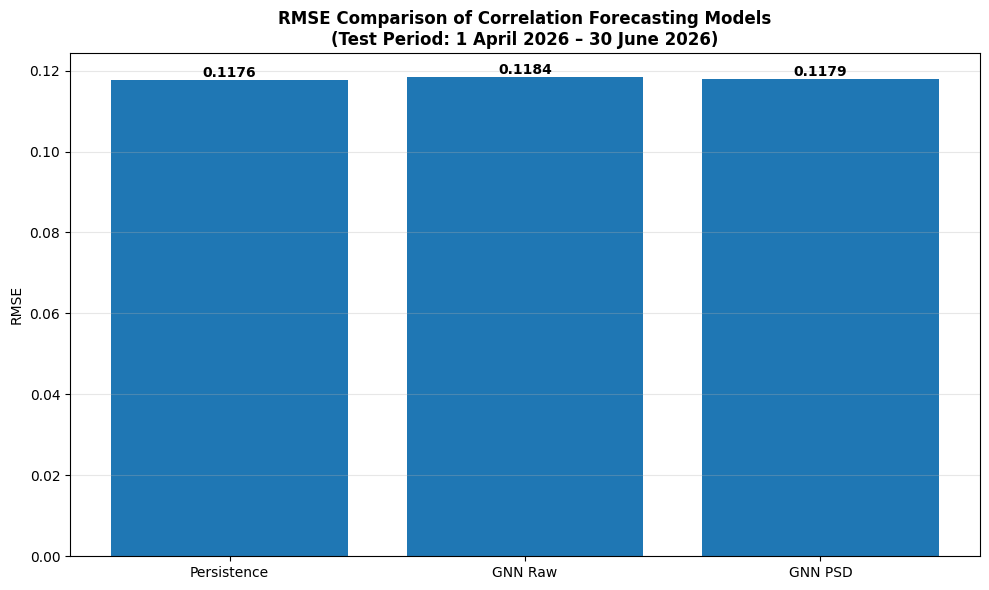

In [76]:
#====================================================
# FIGURE 1
# RMSE COMPARISON
#
# TEST PERIOD:
# 01 APRIL 2026 - 30 JUNE 2026
#====================================================

import matplotlib.pyplot as plt
import numpy as np


#====================================================
# DEFINE MODELS
#====================================================

models = [

    "Persistence",

    "GNN Raw",

    "GNN PSD"

]


#====================================================
# EXTRACT RMSE VALUES
#====================================================

rmse_values = [

    persistence_metrics[
        "RMSE"
    ],

    raw_metrics[
        "RMSE"
    ],

    psd_metrics[
        "RMSE"
    ]

]


#====================================================
# CREATE FIGURE
#====================================================

plt.figure(
    figsize=(10,6)
)


bars = plt.bar(

    models,

    rmse_values

)


#====================================================
# ADD VALUES ABOVE BARS
#====================================================

for bar, value in zip(
    bars,
    rmse_values
):

    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height(),

        f"{value:.4f}",

        ha="center",

        va="bottom",

        fontweight="bold"

    )


#====================================================
# TITLE AND LABELS
#====================================================

plt.title(

    "RMSE Comparison of Correlation Forecasting Models\n"
    "(Test Period: 1 April 2026 – 30 June 2026)",

    fontweight="bold"

)


plt.ylabel(
    "RMSE"
)


plt.grid(

    axis="y",

    alpha=0.30

)


plt.tight_layout()

plt.show()

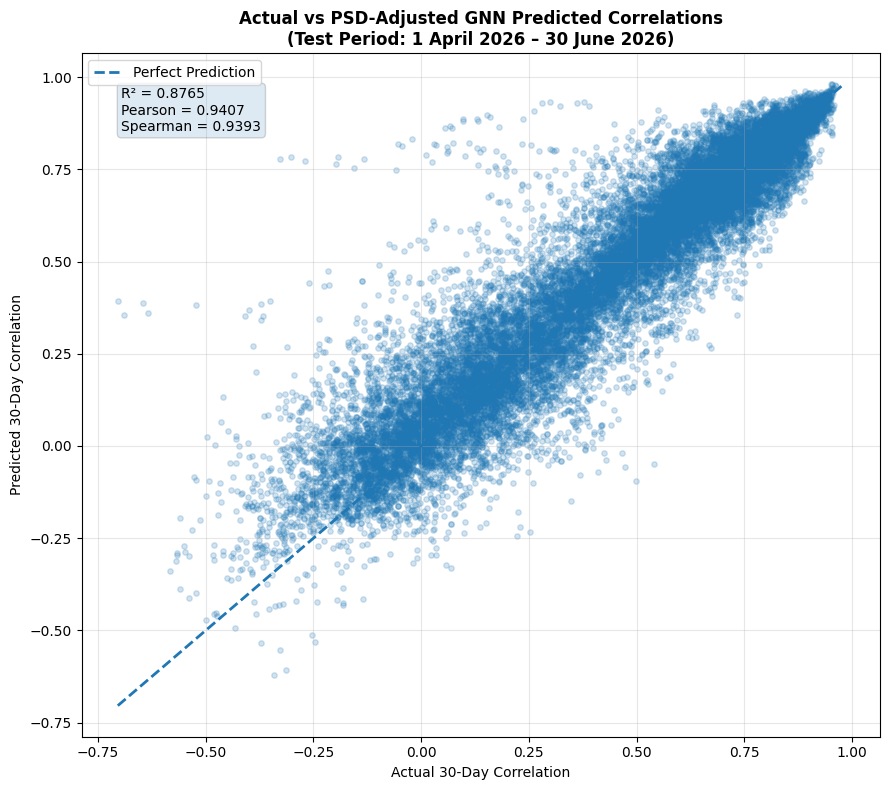

In [77]:
#====================================================
# FIGURE 2
# ACTUAL VS PSD-ADJUSTED GNN
# PREDICTED CORRELATIONS
#
# TEST PERIOD:
# 01 APRIL 2026 - 30 JUNE 2026
#====================================================

import matplotlib.pyplot as plt
import numpy as np


#====================================================
# EXTRACT VALUES
#====================================================

actual_values = (

    gnn_test_results[
        "Actual_Correlation"
    ]

    .to_numpy()

)


predicted_values = (

    gnn_test_results[
        "PSD_Predicted_Correlation"
    ]

    .to_numpy()

)


#====================================================
# CREATE FIGURE
#====================================================

plt.figure(
    figsize=(9,8)
)


#====================================================
# SCATTER PLOT
#====================================================

plt.scatter(

    actual_values,

    predicted_values,

    alpha=0.20,

    s=15

)


#====================================================
# PERFECT-PREDICTION LINE
#
# y = x
#====================================================

lower_bound = min(

    actual_values.min(),

    predicted_values.min()

)


upper_bound = max(

    actual_values.max(),

    predicted_values.max()

)


plt.plot(

    [
        lower_bound,
        upper_bound
    ],

    [
        lower_bound,
        upper_bound
    ],

    linestyle="--",

    linewidth=2,

    label="Perfect Prediction"

)


#====================================================
# ADD PERFORMANCE INFORMATION
#====================================================

metric_text = (

    f"R² = {psd_metrics['R2']:.4f}\n"

    f"Pearson = {psd_metrics['Pearson']:.4f}\n"

    f"Spearman = {psd_metrics['Spearman']:.4f}"

)


plt.text(

    0.05,

    0.95,

    metric_text,

    transform=plt.gca().transAxes,

    verticalalignment="top",

    bbox=dict(
        boxstyle="round",
        alpha=0.15
    )

)


#====================================================
# TITLE AND LABELS
#====================================================

plt.title(

    "Actual vs PSD-Adjusted GNN Predicted Correlations\n"
    "(Test Period: 1 April 2026 – 30 June 2026)",

    fontweight="bold"

)


plt.xlabel(
    "Actual 30-Day Correlation"
)


plt.ylabel(
    "Predicted 30-Day Correlation"
)


plt.legend()

plt.grid(
    alpha=0.30
)


plt.tight_layout()

plt.show()

Number of Test Dates: 91

Pairs per Date:
Number_of_Pairs
276    91
Name: count, dtype: int64


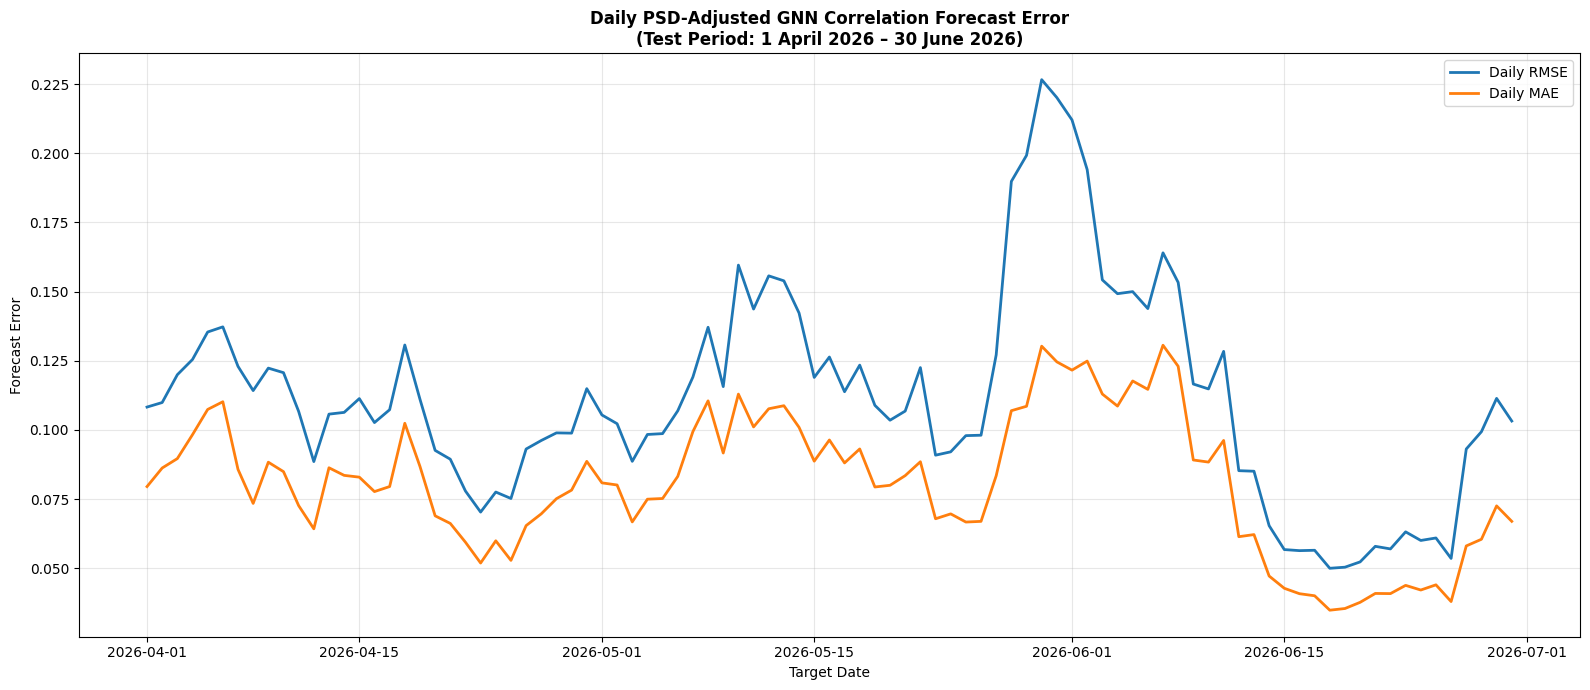

In [78]:
#====================================================
# FIGURE 3
# DAILY GNN FORECAST ERROR
#
# PSD-ADJUSTED GNN
#
# TEST PERIOD:
# 01 APRIL 2026 - 30 JUNE 2026
#====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#====================================================
# COPY TEST RESULTS
#====================================================

daily_error_df = (

    gnn_test_results
    .copy()

)


#====================================================
# CALCULATE FORECAST ERROR
#
# Error = Predicted - Actual
#====================================================

daily_error_df[
    "Forecast_Error"
] = (

    daily_error_df[
        "PSD_Predicted_Correlation"
    ]

    -

    daily_error_df[
        "Actual_Correlation"
    ]

)


#====================================================
# ABSOLUTE ERROR
#====================================================

daily_error_df[
    "Absolute_Error"
] = (

    daily_error_df[
        "Forecast_Error"
    ]

    .abs()

)


#====================================================
# SQUARED ERROR
#====================================================

daily_error_df[
    "Squared_Error"
] = (

    daily_error_df[
        "Forecast_Error"
    ]

    ** 2

)


#====================================================
# AGGREGATE BY TARGET DATE
#====================================================

daily_metrics = (

    daily_error_df

    .groupby(
        "Target_Date"
    )

    .agg(

        MAE=(
            "Absolute_Error",
            "mean"
        ),

        MSE=(
            "Squared_Error",
            "mean"
        ),

        Bias=(
            "Forecast_Error",
            "mean"
        ),

        Number_of_Pairs=(
            "Actual_Correlation",
            "count"
        )

    )

    .reset_index()

)


#====================================================
# CALCULATE DAILY RMSE
#====================================================

daily_metrics[
    "RMSE"
] = np.sqrt(

    daily_metrics[
        "MSE"
    ]

)


#====================================================
# SORT BY DATE
#====================================================

daily_metrics = (

    daily_metrics

    .sort_values(
        "Target_Date"
    )

    .reset_index(
        drop=True
    )

)


#====================================================
# VALIDATION
#====================================================

print(
    "Number of Test Dates:",
    len(daily_metrics)
)


print(
    "\nPairs per Date:"
)


print(

    daily_metrics[
        "Number_of_Pairs"
    ]

    .value_counts()

)


#====================================================
# CREATE FIGURE
#====================================================

plt.figure(
    figsize=(16,7)
)


#====================================================
# DAILY RMSE
#====================================================

plt.plot(

    daily_metrics[
        "Target_Date"
    ],

    daily_metrics[
        "RMSE"
    ],

    linewidth=2,

    label="Daily RMSE"

)


#====================================================
# DAILY MAE
#====================================================

plt.plot(

    daily_metrics[
        "Target_Date"
    ],

    daily_metrics[
        "MAE"
    ],

    linewidth=2,

    label="Daily MAE"

)


#====================================================
# TITLE AND LABELS
#====================================================

plt.title(

    "Daily PSD-Adjusted GNN Correlation Forecast Error\n"
    "(Test Period: 1 April 2026 – 30 June 2026)",

    fontweight="bold"

)


plt.xlabel(
    "Target Date"
)


plt.ylabel(
    "Forecast Error"
)


plt.legend()


plt.grid(
    alpha=0.30
)


plt.tight_layout()

plt.show()

Number of Test Dates: 91
Days GNN Outperformed Persistence: 36
Percentage of Days GNN Outperformed Persistence: 39.56 %


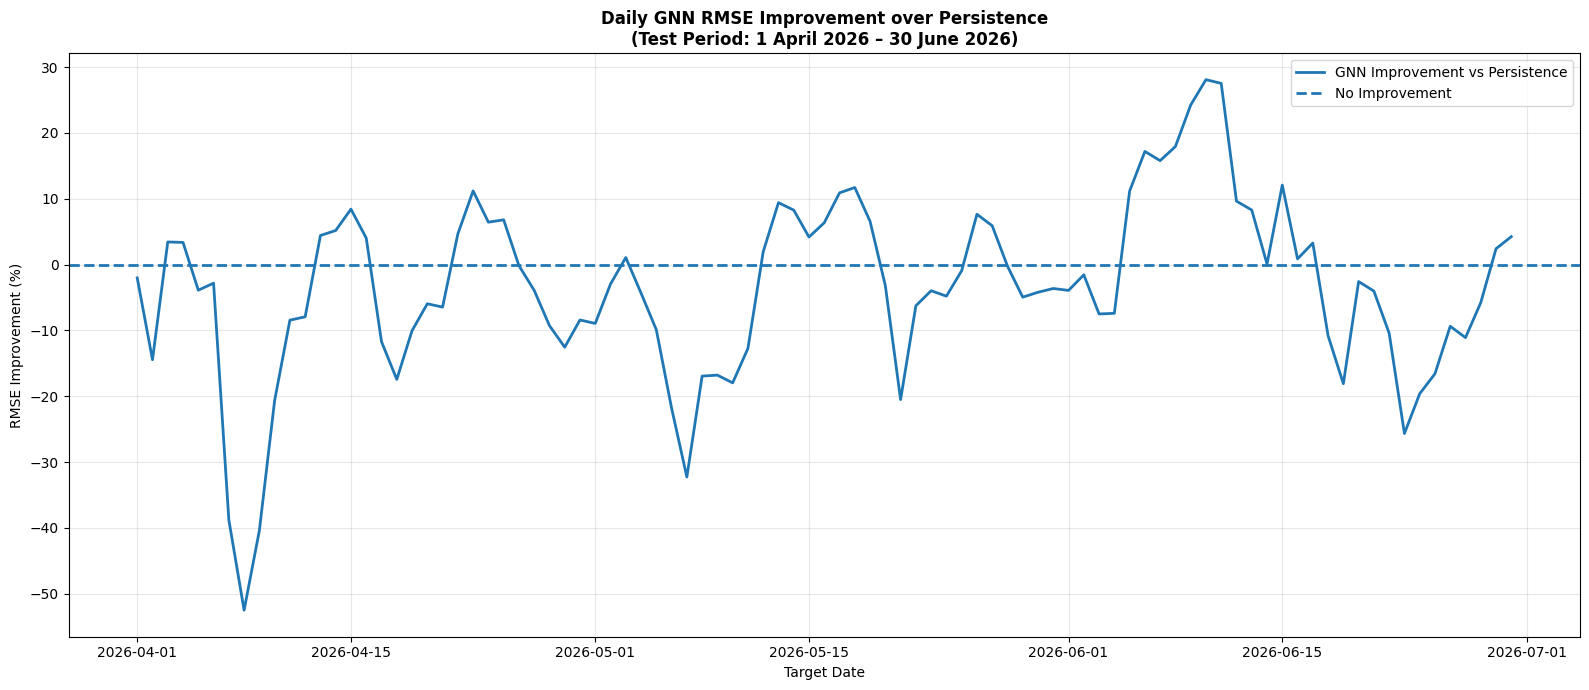

In [79]:
#====================================================
# FIGURE 4
# DAILY GNN RMSE IMPROVEMENT
# OVER PERSISTENCE
#
# TEST PERIOD:
# 01 APRIL 2026 - 30 JUNE 2026
#====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#====================================================
# COPY TEST RESULTS
#====================================================

daily_comparison_df = (

    gnn_test_results
    .copy()

)


#====================================================
# GNN SQUARED ERROR
#====================================================

daily_comparison_df[
    "GNN_Squared_Error"
] = (

    daily_comparison_df[
        "PSD_Predicted_Correlation"
    ]

    -

    daily_comparison_df[
        "Actual_Correlation"
    ]

) ** 2


#====================================================
# PERSISTENCE SQUARED ERROR
#
# Persistence:
#
# rho_hat(t+7) = rho(t)
#====================================================

daily_comparison_df[
    "Persistence_Squared_Error"
] = (

    daily_comparison_df[
        "Baseline_Correlation"
    ]

    -

    daily_comparison_df[
        "Actual_Correlation"
    ]

) ** 2


#====================================================
# DAILY AGGREGATION
#====================================================

daily_comparison = (

    daily_comparison_df

    .groupby(
        "Target_Date"
    )

    .agg(

        GNN_MSE=(
            "GNN_Squared_Error",
            "mean"
        ),

        Persistence_MSE=(
            "Persistence_Squared_Error",
            "mean"
        ),

        Number_of_Pairs=(
            "Actual_Correlation",
            "count"
        )

    )

    .reset_index()

)


#====================================================
# RMSE
#====================================================

daily_comparison[
    "GNN_RMSE"
] = np.sqrt(

    daily_comparison[
        "GNN_MSE"
    ]

)


daily_comparison[
    "Persistence_RMSE"
] = np.sqrt(

    daily_comparison[
        "Persistence_MSE"
    ]

)


#====================================================
# RMSE IMPROVEMENT (%)
#
# Positive:
# GNN outperforms persistence
#
# Negative:
# Persistence outperforms GNN
#====================================================

daily_comparison[
    "RMSE_Improvement_%"
] = (

    (

        daily_comparison[
            "Persistence_RMSE"
        ]

        -

        daily_comparison[
            "GNN_RMSE"
        ]

    )

    /

    daily_comparison[
        "Persistence_RMSE"
    ]

) * 100


#====================================================
# SORT
#====================================================

daily_comparison = (

    daily_comparison

    .sort_values(
        "Target_Date"
    )

    .reset_index(
        drop=True
    )

)


#====================================================
# SUMMARY
#====================================================

gnn_better_days = (

    daily_comparison[
        "RMSE_Improvement_%"
    ]

    > 0

).sum()


print(
    "Number of Test Dates:",
    len(daily_comparison)
)


print(
    "Days GNN Outperformed Persistence:",
    gnn_better_days
)


print(

    "Percentage of Days GNN Outperformed Persistence:",

    round(

        100
        *
        gnn_better_days
        /
        len(daily_comparison),

        2

    ),

    "%"

)


#====================================================
# CREATE FIGURE
#====================================================

plt.figure(
    figsize=(16,7)
)


plt.plot(

    daily_comparison[
        "Target_Date"
    ],

    daily_comparison[
        "RMSE_Improvement_%"
    ],

    linewidth=2,

    label="GNN Improvement vs Persistence"

)


#====================================================
# ZERO BOUNDARY
#====================================================

plt.axhline(

    y=0,

    linestyle="--",

    linewidth=2,

    label="No Improvement"

)


#====================================================
# TITLE AND LABELS
#====================================================

plt.title(

    "Daily GNN RMSE Improvement over Persistence\n"
    "(Test Period: 1 April 2026 – 30 June 2026)",

    fontweight="bold"

)


plt.xlabel(
    "Target Date"
)


plt.ylabel(
    "RMSE Improvement (%)"
)


plt.legend()


plt.grid(
    alpha=0.30
)


plt.tight_layout()

plt.show()

In [80]:
#====================================================
# PAIR-LEVEL GNN FORECAST DIAGNOSTICS
#
# TEST PERIOD:
# 01 APRIL 2026 - 30 JUNE 2026
#====================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import (
    pearsonr,
    spearmanr
)


#====================================================
# STORAGE
#====================================================

pair_results = []


#====================================================
# LOOP THROUGH EACH CRYPTOCURRENCY PAIR
#====================================================

for (
    ticker_1,
    ticker_2
), pair_df in (

    gnn_test_results

    .groupby(
        [
            "Ticker_1",
            "Ticker_2"
        ]
    )

):


    pair_df = (

        pair_df

        .sort_values(
            "Target_Date"
        )

        .copy()

    )


    #================================================
    # VALUES
    #================================================

    actual_pair = (

        pair_df[
            "Actual_Correlation"
        ]

        .to_numpy()

    )


    predicted_pair = (

        pair_df[
            "PSD_Predicted_Correlation"
        ]

        .to_numpy()

    )


    persistence_pair = (

        pair_df[
            "Baseline_Correlation"
        ]

        .to_numpy()

    )


    #================================================
    # GNN MAE
    #================================================

    gnn_mae = mean_absolute_error(

        actual_pair,

        predicted_pair

    )


    #================================================
    # GNN RMSE
    #================================================

    gnn_rmse = np.sqrt(

        mean_squared_error(

            actual_pair,

            predicted_pair

        )

    )


    #================================================
    # GNN BIAS
    #================================================

    gnn_bias = np.mean(

        predicted_pair

        -

        actual_pair

    )


    #================================================
    # GNN R-SQUARED
    #================================================

    if len(actual_pair) > 1:

        gnn_r2 = r2_score(

            actual_pair,

            predicted_pair

        )

    else:

        gnn_r2 = np.nan


    #================================================
    # PEARSON
    #================================================

    if (

        len(actual_pair) > 1

        and

        np.std(actual_pair) > 0

        and

        np.std(predicted_pair) > 0

    ):

        gnn_pearson = pearsonr(

            actual_pair,

            predicted_pair

        )[0]

    else:

        gnn_pearson = np.nan


    #================================================
    # SPEARMAN
    #================================================

    if (

        len(actual_pair) > 1

        and

        np.std(actual_pair) > 0

        and

        np.std(predicted_pair) > 0

    ):

        gnn_spearman = spearmanr(

            actual_pair,

            predicted_pair

        )[0]

    else:

        gnn_spearman = np.nan


    #================================================
    # CORRELATION SIGN ACCURACY
    #================================================

    sign_accuracy = np.mean(

        (
            actual_pair > 0
        )

        ==

        (
            predicted_pair > 0
        )

    )


    #================================================
    # PERSISTENCE MAE
    #================================================

    persistence_mae = mean_absolute_error(

        actual_pair,

        persistence_pair

    )


    #================================================
    # PERSISTENCE RMSE
    #================================================

    persistence_rmse = np.sqrt(

        mean_squared_error(

            actual_pair,

            persistence_pair

        )

    )


    #================================================
    # RMSE IMPROVEMENT
    #================================================

    if persistence_rmse > 0:

        rmse_improvement = (

            (

                persistence_rmse

                -

                gnn_rmse

            )

            /

            persistence_rmse

        ) * 100

    else:

        rmse_improvement = np.nan


    #================================================
    # MAE IMPROVEMENT
    #================================================

    if persistence_mae > 0:

        mae_improvement = (

            (

                persistence_mae

                -

                gnn_mae

            )

            /

            persistence_mae

        ) * 100

    else:

        mae_improvement = np.nan


    #================================================
    # STORE RESULTS
    #================================================

    pair_results.append({

        "Ticker_1":
            ticker_1,

        "Ticker_2":
            ticker_2,

        "Observations":
            len(pair_df),

        "GNN_MAE":
            gnn_mae,

        "GNN_RMSE":
            gnn_rmse,

        "GNN_Bias":
            gnn_bias,

        "GNN_R2":
            gnn_r2,

        "GNN_Pearson":
            gnn_pearson,

        "GNN_Spearman":
            gnn_spearman,

        "Sign_Accuracy":
            sign_accuracy,

        "Persistence_MAE":
            persistence_mae,

        "Persistence_RMSE":
            persistence_rmse,

        "MAE_Improvement_%":
            mae_improvement,

        "RMSE_Improvement_%":
            rmse_improvement

    })


#====================================================
# CREATE PAIR METRICS DATAFRAME
#====================================================

pair_metrics = pd.DataFrame(

    pair_results

)


#====================================================
# SORT BY RMSE IMPROVEMENT
#====================================================

pair_metrics = (

    pair_metrics

    .sort_values(

        "RMSE_Improvement_%",

        ascending=False

    )

    .reset_index(
        drop=True
    )

)


#====================================================
# SUMMARY
#====================================================

print(
    "=" * 80
)

print(
    "PAIR-LEVEL GNN PERFORMANCE"
)

print(
    "=" * 80
)


print(
    "Number of Cryptocurrency Pairs:",
    len(pair_metrics)
)


pairs_beating_persistence = (

    pair_metrics[
        "RMSE_Improvement_%"
    ]

    > 0

).sum()


print(
    "Pairs Beating Persistence:",
    pairs_beating_persistence
)


print(

    "Percentage Beating Persistence:",

    round(

        100
        *
        pairs_beating_persistence
        /
        len(pair_metrics),

        2

    ),

    "%"

)


print(
    "\nAverage Pair-Level RMSE:"
)

print(

    pair_metrics[
        "GNN_RMSE"
    ].mean()

)


print(
    "\nMedian RMSE Improvement:"
)

print(

    pair_metrics[
        "RMSE_Improvement_%"
    ].median()

)


#====================================================
# DISPLAY RESULTS
#====================================================

display(

    pair_metrics.head(20)

)


#====================================================
# SAVE
#====================================================

pair_metrics.to_csv(

    "GNN_Pair_Level_Evaluation_"
    "2026-04-01_to_2026-06-30.csv",

    index=False

)

PAIR-LEVEL GNN PERFORMANCE
Number of Cryptocurrency Pairs: 276
Pairs Beating Persistence: 154
Percentage Beating Persistence: 55.8 %

Average Pair-Level RMSE:
0.10962783213721865

Median RMSE Improvement:
2.0352785712384946


,Ticker_1,Ticker_2,Observations,GNN_MAE,GNN_RMSE,GNN_Bias,GNN_R2,GNN_Pearson,GNN_Spearman,Sign_Accuracy,Persistence_MAE,Persistence_RMSE,MAE_Improvement_%,RMSE_Improvement_%
0,FIL-USD,NEO-USD,91,0.052684,0.074042,-0.002462,0.619259,0.808145,0.756203,1.000000,0.069179,0.102670,23.843343,27.883244
1,ETH-USD,LINK-USD,91,0.028975,0.041963,0.007428,0.771879,0.890972,0.903950,1.000000,0.042223,0.057199,31.375646,26.637159
2,DASH-USD,TRX-USD,91,0.063696,0.081264,0.019899,0.882739,0.943325,0.864548,0.857143,0.075246,0.108722,15.349611,25.255723
3,FIL-USD,LINK-USD,91,0.044578,0.062104,0.006642,0.612913,0.787043,0.752110,1.000000,0.059975,0.083057,25.672311,25.227222
4,DOGE-USD,LEO-USD,91,0.096152,0.117413,0.033538,0.418341,0.719687,0.560025,0.846154,0.109872,0.156222,12.487932,24.842072
5,ETH-USD,THETA-USD,91,0.050592,0.066917,0.030955,0.694944,0.885313,0.873021,1.000000,0.067000,0.088887,24.490041,24.716666
6,CRO-USD,ETH-USD,91,0.045303,0.069439,0.023589,0.669434,0.847303,0.827966,1.000000,0.065770,0.091929,31.119337,24.464036
7,FIL-USD,THETA-USD,91,0.052189,0.068051,0.011720,0.532191,0.759852,0.730419,1.000000,0.069836,0.087794,25.270144,22.487612
8,BTC-USD,CRO-USD,91,0.034804,0.057812,0.017582,0.617140,0.816340,0.847030,1.000000,0.050071,0.073278,30.491018,21.106527
9,LINK-USD,NEO-USD,91,0.036561,0.051643,-0.003655,0.451227,0.712441,0.718984,1.000000,0.047569,0.065255,23.141454,20.859179


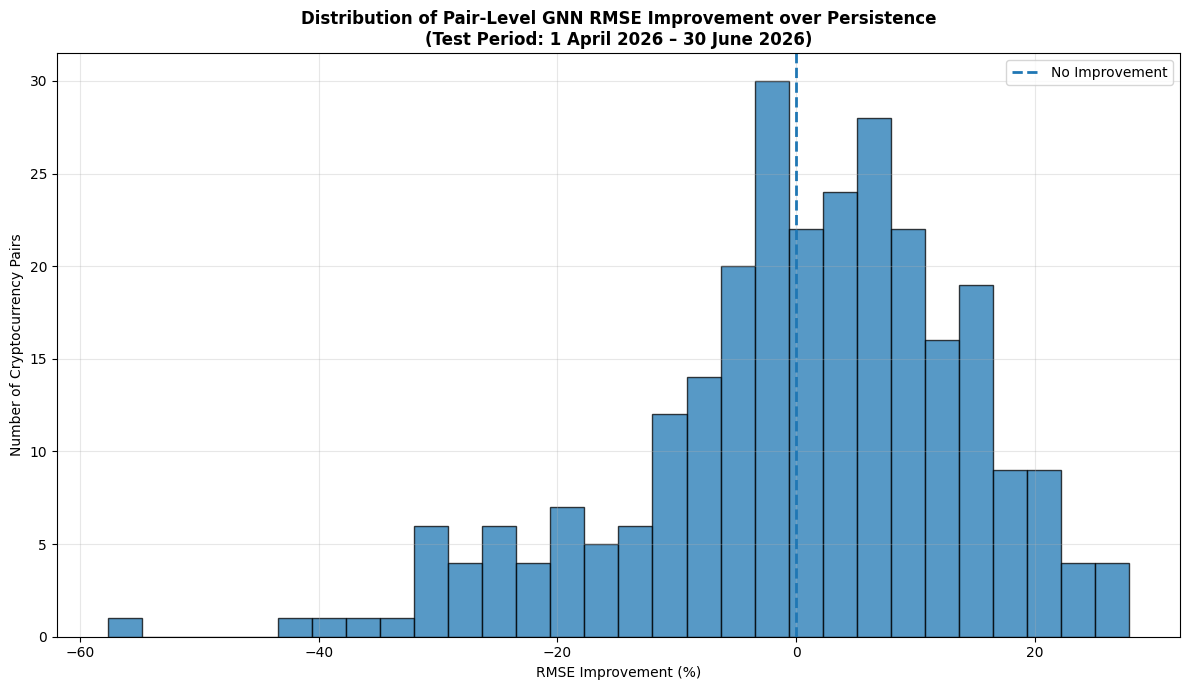

In [81]:
#====================================================
# FIGURE 5
# DISTRIBUTION OF PAIR-LEVEL
# RMSE IMPROVEMENT
#====================================================

plt.figure(
    figsize=(12,7)
)


plt.hist(

    pair_metrics[
        "RMSE_Improvement_%"
    ]

    .dropna(),

    bins=30,

    edgecolor="black",

    alpha=0.75

)


#====================================================
# ZERO BOUNDARY
#====================================================

plt.axvline(

    x=0,

    linestyle="--",

    linewidth=2,

    label="No Improvement"

)


#====================================================
# TITLE
#====================================================

plt.title(

    "Distribution of Pair-Level GNN RMSE Improvement over Persistence\n"
    "(Test Period: 1 April 2026 – 30 June 2026)",

    fontweight="bold"

)


plt.xlabel(
    "RMSE Improvement (%)"
)


plt.ylabel(
    "Number of Cryptocurrency Pairs"
)


plt.legend()


plt.grid(
    alpha=0.30
)


plt.tight_layout()

plt.show()

PAIR-LEVEL RMSE MATRIX
Matrix Shape: (24, 24)
Number of Cryptocurrencies: 24
Expected Unique Pairs: 276
Pair Metrics: 276
Matrix Symmetric: True
Minimum Pair RMSE: 0.0281966552442231
Maximum Pair RMSE: 0.29514177525127444
Average Pair RMSE: 0.10962783213721863


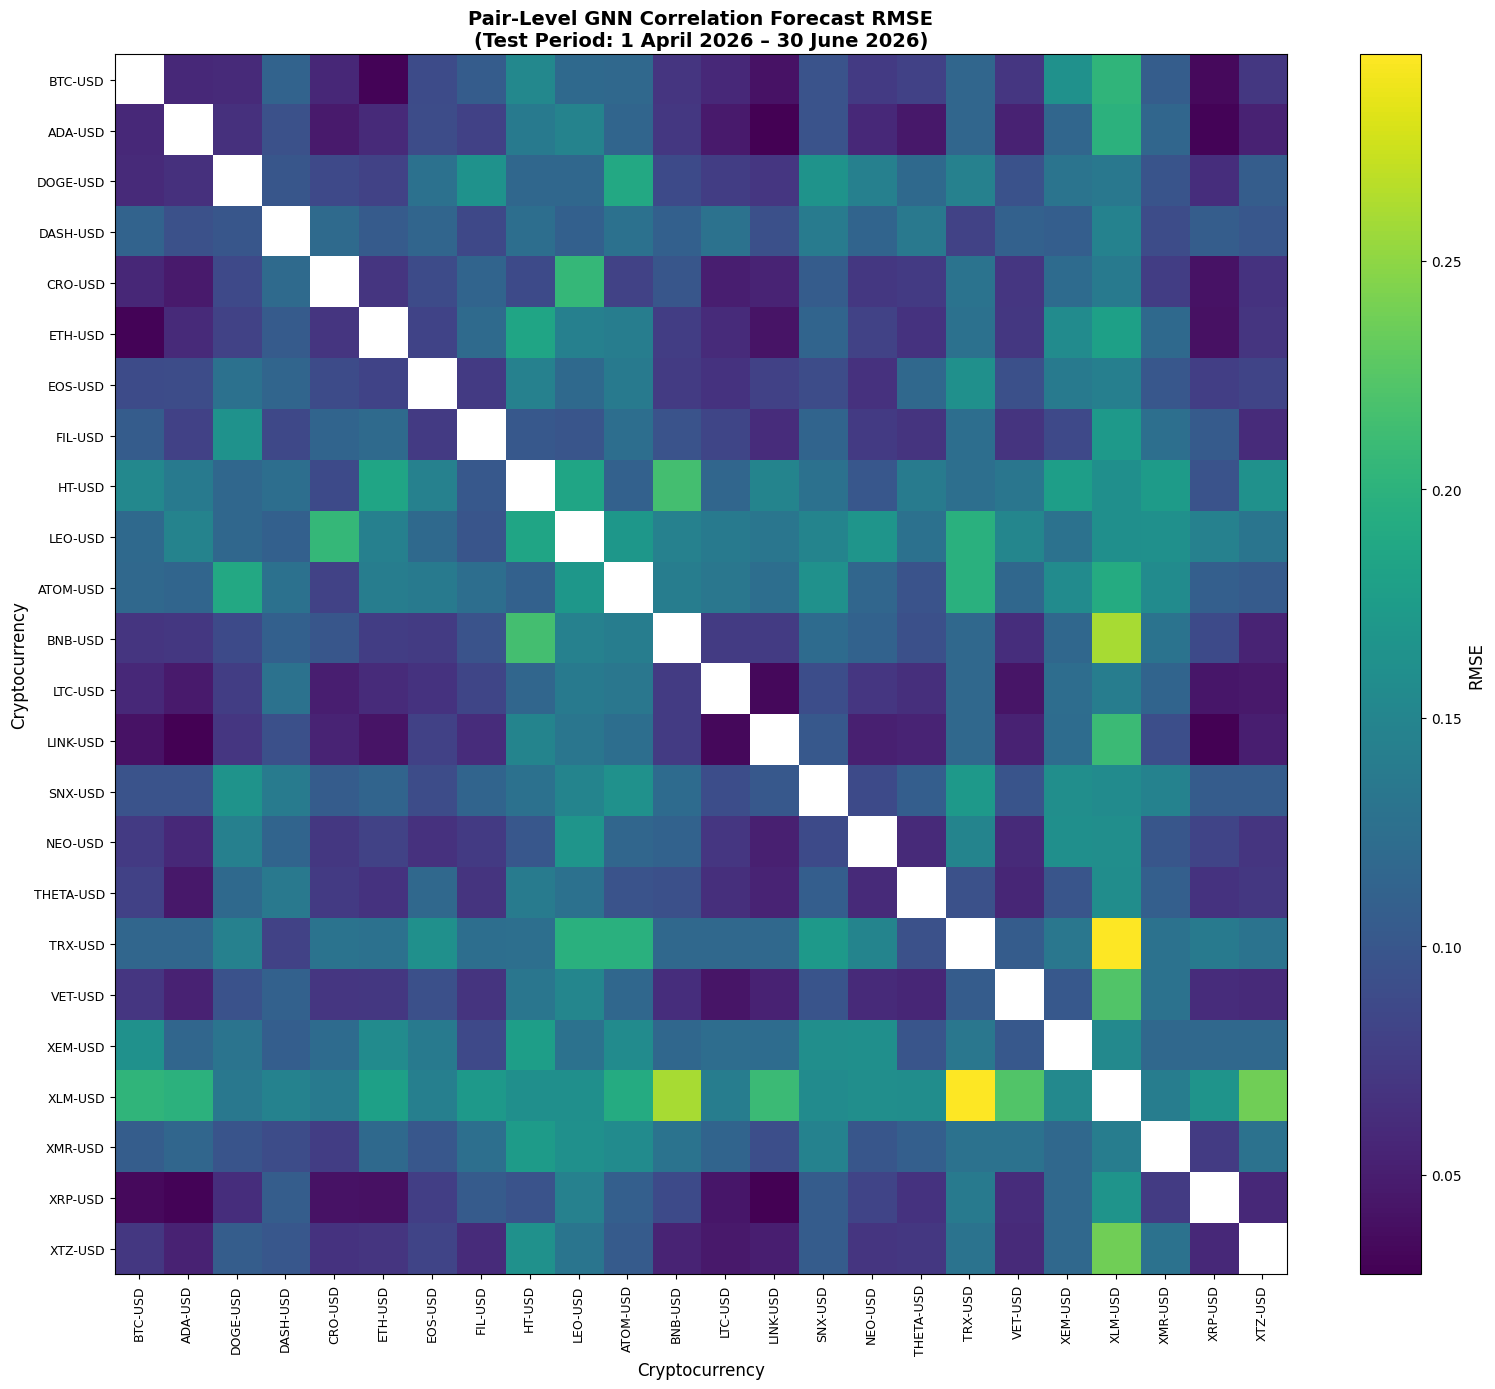

In [82]:
#====================================================
# FIGURE 6
# PAIR-LEVEL GNN RMSE HEATMAP
#
# TEST PERIOD:
# 01 APRIL 2026 - 30 JUNE 2026
#
# DIAGONAL:
# NaN because self-correlations are not
# forecast by the GNN
#====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#====================================================
# CHECK PAIR METRICS
#====================================================

if "pair_metrics" not in globals():

    raise NameError(

        "pair_metrics does not exist. "
        "Run the pair-level GNN evaluation first."

    )


#====================================================
# CREATE EMPTY RMSE MATRIX
#
# 24 × 24
#====================================================

rmse_matrix = pd.DataFrame(

    np.full(

        (
            len(GNN_TICKERS),
            len(GNN_TICKERS)
        ),

        np.nan,

        dtype=float

    ),

    index=GNN_TICKERS,

    columns=GNN_TICKERS

)


#====================================================
# FILL OFF-DIAGONAL VALUES
#
# RMSE(i,j) = RMSE(j,i)
#====================================================

for _, row in pair_metrics.iterrows():

    ticker_1 = row[
        "Ticker_1"
    ]

    ticker_2 = row[
        "Ticker_2"
    ]

    pair_rmse = row[
        "GNN_RMSE"
    ]


    #================================================
    # UPPER TRIANGLE
    #================================================

    rmse_matrix.loc[

        ticker_1,

        ticker_2

    ] = pair_rmse


    #================================================
    # LOWER TRIANGLE
    #================================================

    rmse_matrix.loc[

        ticker_2,

        ticker_1

    ] = pair_rmse


#====================================================
# IMPORTANT:
#
# DO NOT use np.fill_diagonal(rmse_matrix.values, 0)
#
# The diagonal is intentionally left as NaN
# because self-correlations are not GNN forecasts.
#====================================================


#====================================================
# VALIDATION
#====================================================

print(
    "=" * 70
)

print(
    "PAIR-LEVEL RMSE MATRIX"
)

print(
    "=" * 70
)


print(
    "Matrix Shape:",
    rmse_matrix.shape
)


print(
    "Number of Cryptocurrencies:",
    len(GNN_TICKERS)
)


print(
    "Expected Unique Pairs:",
    (
        len(GNN_TICKERS)
        *
        (
            len(GNN_TICKERS) - 1
        )
        //
        2
    )
)


print(
    "Pair Metrics:",
    len(pair_metrics)
)


#====================================================
# CHECK SYMMETRY
#
# Ignore diagonal NaN values
#====================================================

rmse_array = rmse_matrix.to_numpy(
    copy=True
)


symmetry_check = np.allclose(

    rmse_array,

    rmse_array.T,

    equal_nan=True

)


print(
    "Matrix Symmetric:",
    symmetry_check
)


#====================================================
# CALCULATE RANGE
#====================================================

print(

    "Minimum Pair RMSE:",

    np.nanmin(
        rmse_array
    )

)


print(

    "Maximum Pair RMSE:",

    np.nanmax(
        rmse_array
    )

)


print(

    "Average Pair RMSE:",

    np.nanmean(
        rmse_array
    )

)


#====================================================
# CREATE MASKED ARRAY
#
# NaN diagonal will appear blank
#====================================================

plot_matrix = np.ma.masked_invalid(

    rmse_array

)


#====================================================
# CREATE FIGURE
#====================================================

plt.figure(
    figsize=(16,14)
)


image = plt.imshow(

    plot_matrix,

    aspect="auto",

    interpolation="nearest"

)


#====================================================
# COLOR BAR
#====================================================

colorbar = plt.colorbar(
    image
)


colorbar.set_label(

    "RMSE",

    fontsize=12

)


#====================================================
# X-AXIS
#====================================================

plt.xticks(

    ticks=np.arange(
        len(GNN_TICKERS)
    ),

    labels=GNN_TICKERS,

    rotation=90,

    fontsize=9

)


#====================================================
# Y-AXIS
#====================================================

plt.yticks(

    ticks=np.arange(
        len(GNN_TICKERS)
    ),

    labels=GNN_TICKERS,

    fontsize=9

)


#====================================================
# TITLE
#====================================================

plt.title(

    "Pair-Level GNN Correlation Forecast RMSE\n"
    "(Test Period: 1 April 2026 – 30 June 2026)",

    fontweight="bold",

    fontsize=14

)


#====================================================
# AXIS LABELS
#====================================================

plt.xlabel(

    "Cryptocurrency",

    fontsize=12

)


plt.ylabel(

    "Cryptocurrency",

    fontsize=12

)


#====================================================
# LAYOUT
#====================================================

plt.tight_layout()


#====================================================
# SHOW
#====================================================

plt.show()

Matrix Date: 2026-06-30
Number of Pair Predictions: 276


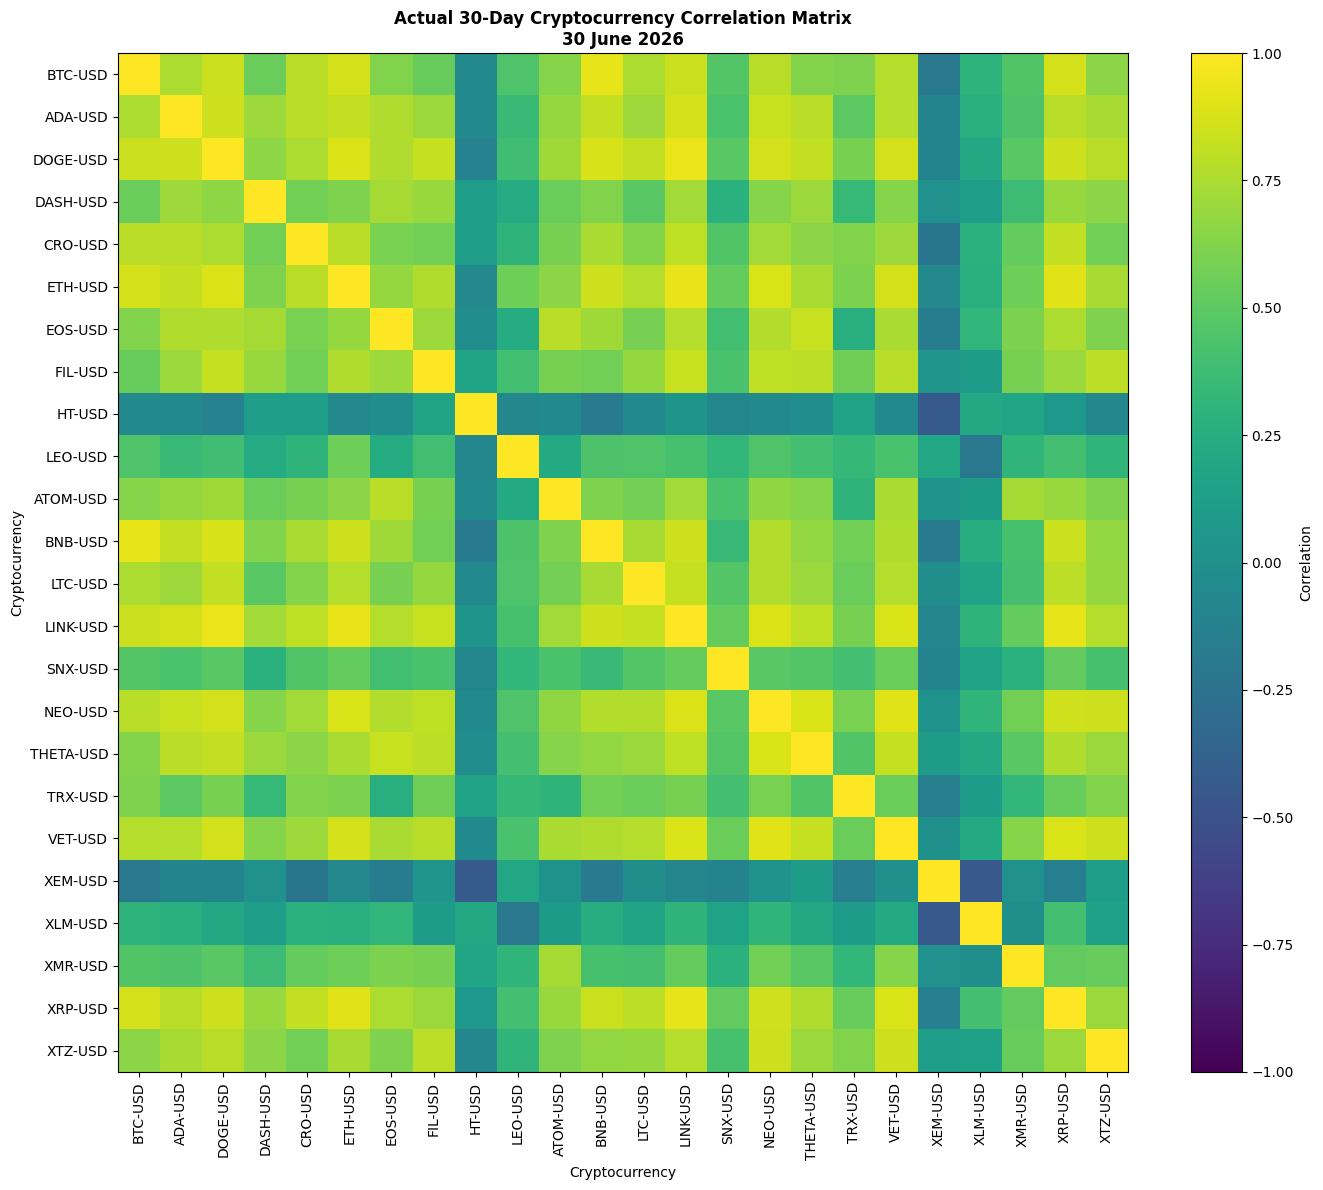

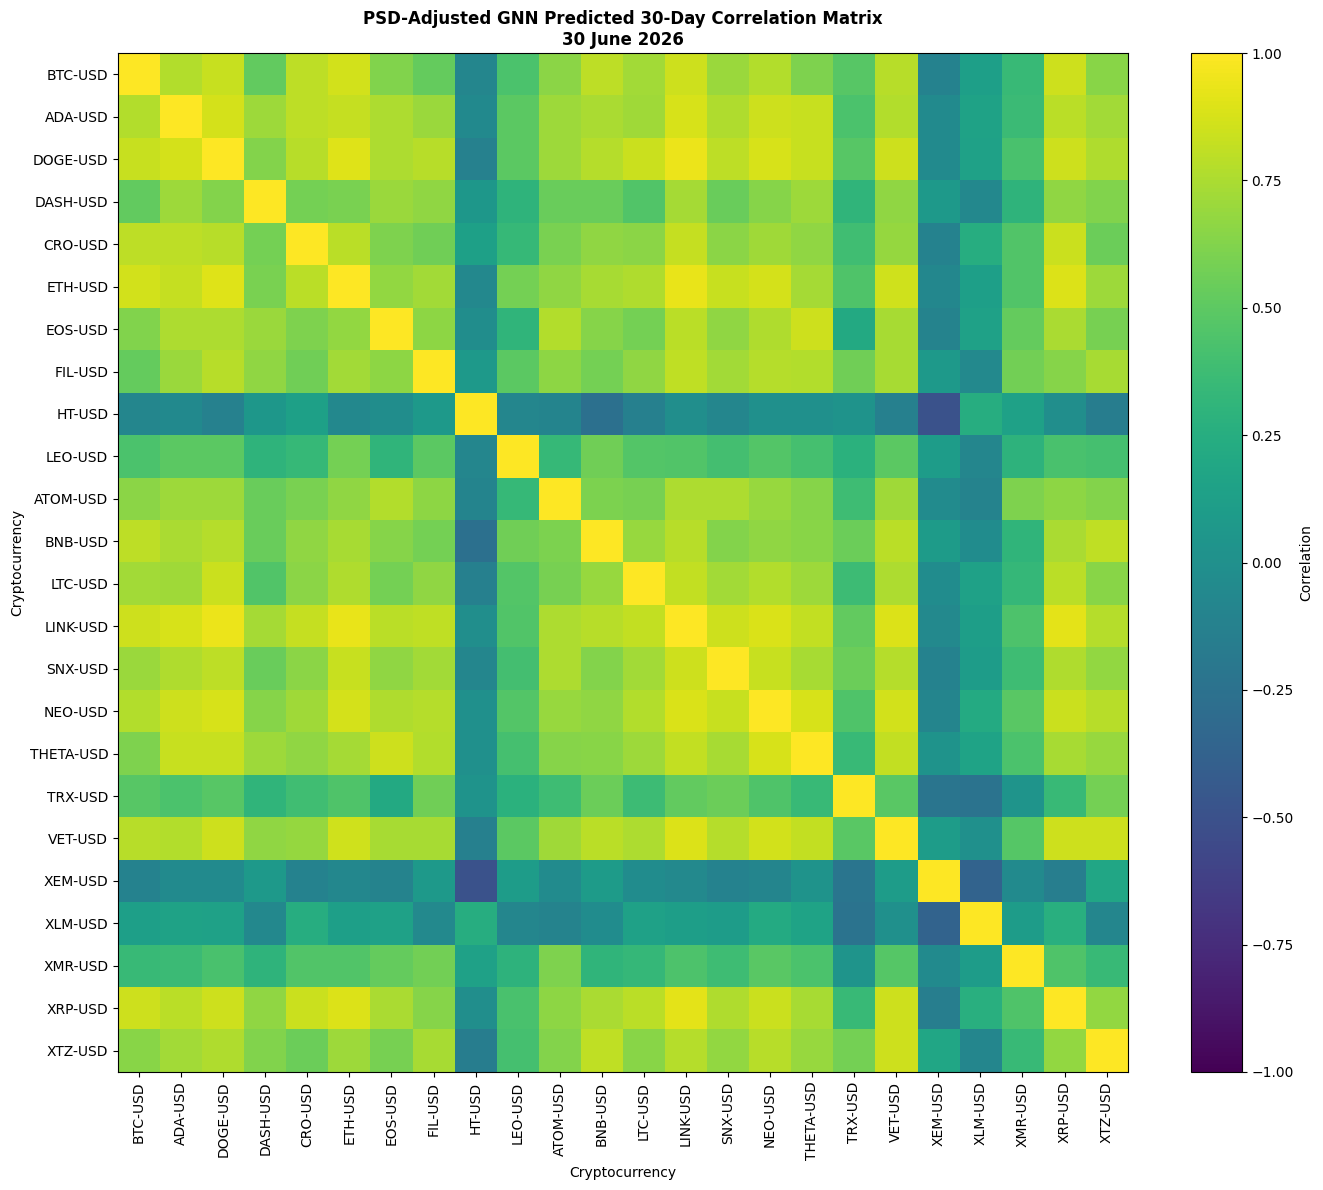

In [83]:
#====================================================
# FIGURE 7
# ACTUAL VS GNN PREDICTED
# CORRELATION MATRICES
#
# FINAL TEST DATE:
# 30 JUNE 2026
#====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#====================================================
# SELECT FINAL TEST DATE
#====================================================

MATRIX_DATE = pd.Timestamp(
    "2026-06-30"
)


matrix_day = (

    gnn_test_results[

        gnn_test_results[
            "Target_Date"
        ]

        == MATRIX_DATE

    ]

    .copy()

)


#====================================================
# CHECK DATA EXISTS
#====================================================

if matrix_day.empty:

    raise ValueError(

        f"No GNN test predictions found "
        f"for {MATRIX_DATE.date()}."

    )


print(
    "Matrix Date:",
    MATRIX_DATE.date()
)


print(
    "Number of Pair Predictions:",
    len(matrix_day)
)


#====================================================
# EMPTY MATRICES
#====================================================

actual_matrix = pd.DataFrame(

    np.eye(
        len(GNN_TICKERS)
    ),

    index=GNN_TICKERS,

    columns=GNN_TICKERS

)


predicted_matrix = pd.DataFrame(

    np.eye(
        len(GNN_TICKERS)
    ),

    index=GNN_TICKERS,

    columns=GNN_TICKERS

)


#====================================================
# BUILD MATRICES
#====================================================

for _, row in matrix_day.iterrows():

    ticker_1 = row[
        "Ticker_1"
    ]

    ticker_2 = row[
        "Ticker_2"
    ]


    actual_corr = row[
        "Actual_Correlation"
    ]


    predicted_corr = row[
        "PSD_Predicted_Correlation"
    ]


    #================================================
    # ACTUAL
    #================================================

    actual_matrix.loc[
        ticker_1,
        ticker_2
    ] = actual_corr


    actual_matrix.loc[
        ticker_2,
        ticker_1
    ] = actual_corr


    #================================================
    # PREDICTED
    #================================================

    predicted_matrix.loc[
        ticker_1,
        ticker_2
    ] = predicted_corr


    predicted_matrix.loc[
        ticker_2,
        ticker_1
    ] = predicted_corr


#====================================================
# FIGURE 7A
# ACTUAL MATRIX
#====================================================

plt.figure(
    figsize=(14,12)
)


image = plt.imshow(

    actual_matrix.values,

    vmin=-1,

    vmax=1,

    aspect="auto"

)


plt.colorbar(

    image,

    label="Correlation"

)


plt.xticks(

    range(
        len(GNN_TICKERS)
    ),

    GNN_TICKERS,

    rotation=90

)


plt.yticks(

    range(
        len(GNN_TICKERS)
    ),

    GNN_TICKERS

)


plt.title(

    "Actual 30-Day Cryptocurrency Correlation Matrix\n"
    "30 June 2026",

    fontweight="bold"

)


plt.xlabel(
    "Cryptocurrency"
)


plt.ylabel(
    "Cryptocurrency"
)


plt.tight_layout()

plt.show()


#====================================================
# FIGURE 7B
# GNN PREDICTED MATRIX
#====================================================

plt.figure(
    figsize=(14,12)
)


image = plt.imshow(

    predicted_matrix.values,

    vmin=-1,

    vmax=1,

    aspect="auto"

)


plt.colorbar(

    image,

    label="Correlation"

)


plt.xticks(

    range(
        len(GNN_TICKERS)
    ),

    GNN_TICKERS,

    rotation=90

)


plt.yticks(

    range(
        len(GNN_TICKERS)
    ),

    GNN_TICKERS

)


plt.title(

    "PSD-Adjusted GNN Predicted 30-Day Correlation Matrix\n"
    "30 June 2026",

    fontweight="bold"

)


plt.xlabel(
    "Cryptocurrency"
)


plt.ylabel(
    "Cryptocurrency"
)


plt.tight_layout()

plt.show()

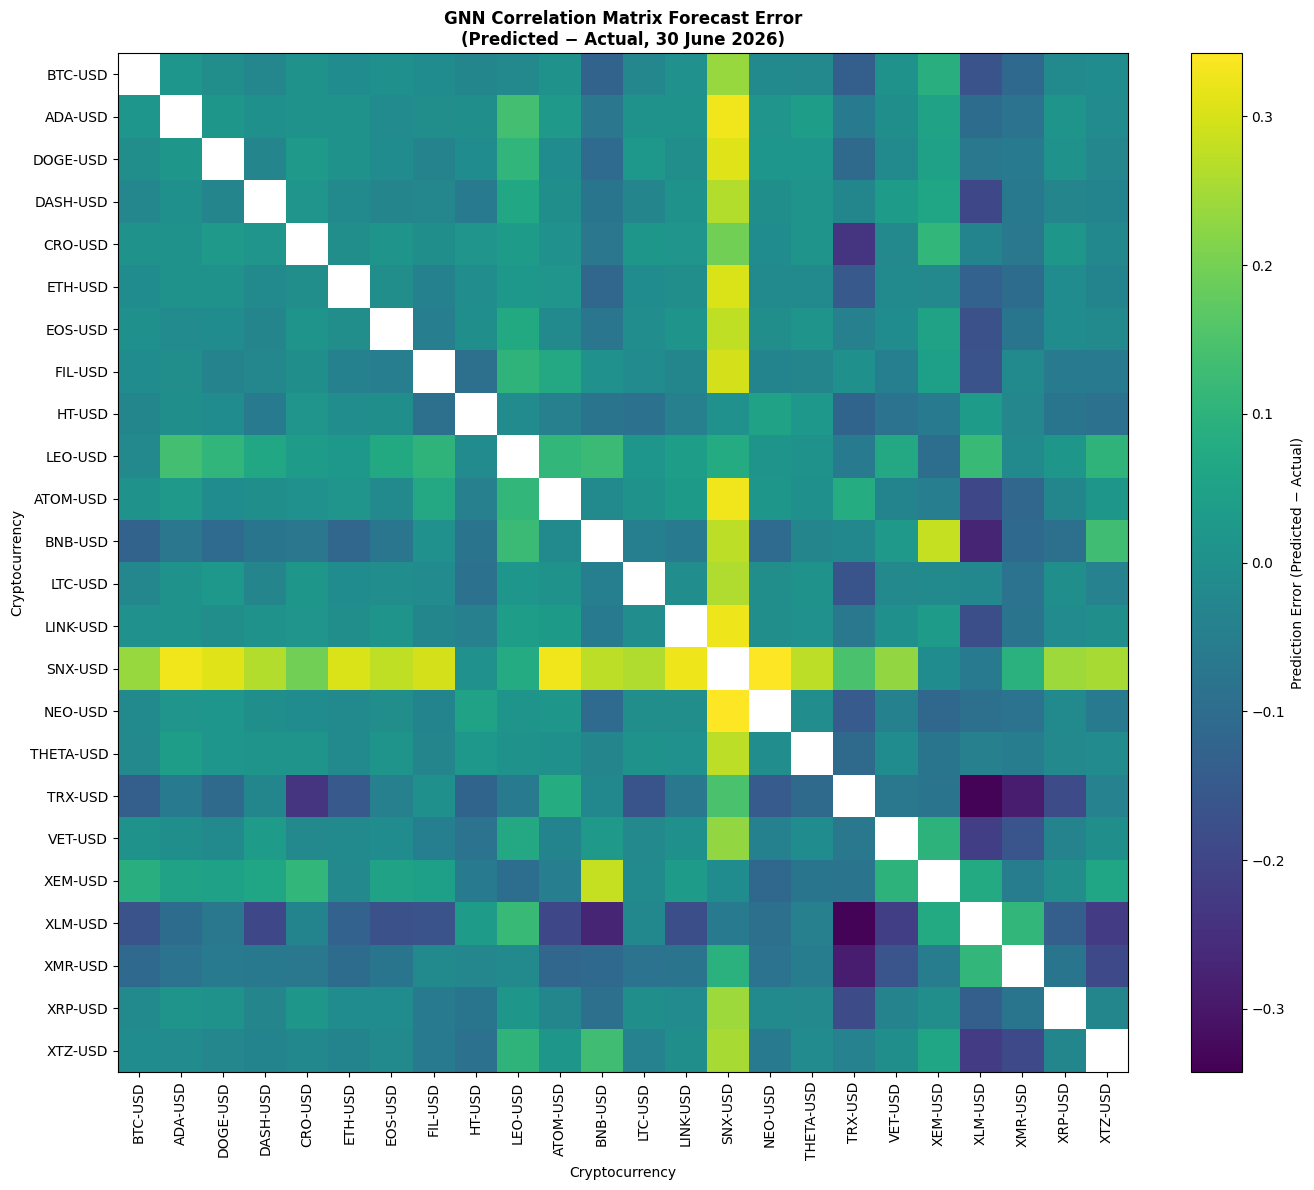

In [84]:
#====================================================
# FIGURE 8
# CORRELATION MATRIX FORECAST ERROR
#
# ERROR:
# PREDICTED - ACTUAL
#
# FINAL TEST DATE:
# 30 JUNE 2026
#====================================================


#====================================================
# CALCULATE ERROR MATRIX
#====================================================

error_matrix = (

    predicted_matrix

    -

    actual_matrix

)


#====================================================
# CREATE WRITABLE NUMPY COPY
#====================================================

error_array = (

    error_matrix

    .to_numpy(
        copy=True
    )

)


#====================================================
# DIAGONAL IS NOT A FORECAST
#
# Set to NaN so self-correlations
# are excluded from the diagnostic.
#====================================================

np.fill_diagonal(

    error_array,

    np.nan

)


#====================================================
# MAXIMUM ABSOLUTE OFF-DIAGONAL ERROR
#====================================================

max_absolute_error = np.nanmax(

    np.abs(
        error_array
    )

)


#====================================================
# MASK DIAGONAL
#====================================================

plot_error_matrix = np.ma.masked_invalid(

    error_array

)


#====================================================
# CREATE FIGURE
#====================================================

plt.figure(
    figsize=(14,12)
)


image = plt.imshow(

    plot_error_matrix,

    vmin=-max_absolute_error,

    vmax=max_absolute_error,

    aspect="auto",

    interpolation="nearest"

)


#====================================================
# COLOR BAR
#====================================================

colorbar = plt.colorbar(
    image
)


colorbar.set_label(

    "Prediction Error "
    "(Predicted − Actual)"

)


#====================================================
# TICKS
#====================================================

plt.xticks(

    range(
        len(GNN_TICKERS)
    ),

    GNN_TICKERS,

    rotation=90

)


plt.yticks(

    range(
        len(GNN_TICKERS)
    ),

    GNN_TICKERS

)


#====================================================
# TITLE
#====================================================

plt.title(

    "GNN Correlation Matrix Forecast Error\n"
    "(Predicted − Actual, 30 June 2026)",

    fontweight="bold"

)


plt.xlabel(
    "Cryptocurrency"
)


plt.ylabel(
    "Cryptocurrency"
)


plt.tight_layout()

plt.show()

## F.1 SHAP Feature Importance — Held-Out Test Period

This section explains the **saved best GNN model** using only held-out test samples whose `Target_Date` lies between **01 April 2026 and 30 June 2026**. It is deliberately placed before the out-of-sample forecasting section so that no July–August 2026 information enters the interpretation stage.

Because the GNN produces 276 pairwise Fisher-Z change forecasts simultaneously, the SHAP wrapper explains a single global model output: the **mean absolute predicted Fisher-Z correlation change across all 276 pairs** for each graph sample. The resulting node-feature SHAP importance therefore measures how strongly each input feature contributes to the model's overall predicted correlation-change magnitude. Edge attributes are reported separately and are not mixed with node-feature importance.


In [85]:
#====================================================
# SHAP SETUP FOR THE SAVED BEST GNN MODEL
# HELD-OUT TEST PERIOD: 01 APRIL - 30 JUNE 2026
#====================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "SHAP is not installed. Install it with: pip install shap"
    ) from exc


#====================================================
# 1. DEFINE SHAP EVALUATION PERIOD
#====================================================

SHAP_START = pd.Timestamp("2026-04-01")
SHAP_END = pd.Timestamp("2026-06-30")


#====================================================
# 2. CHECK REQUIRED OBJECTS
#====================================================

required_objects = [
    "model",
    "test_samples",
    "CryptoGraphDataset",
    "GNN_MODEL_FEATURES",
    "GNN_TICKERS",
    "PAIR_LIST"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Missing required objects before SHAP: "
        + ", ".join(missing_objects)
    )


#====================================================
# 3. STRICTLY RETAIN HELD-OUT TEST SAMPLES ONLY
#    BASED ON TARGET DATE
#====================================================

shap_test_samples = [
    sample
    for sample in test_samples
    if SHAP_START <= pd.Timestamp(sample["Target_Date"]) <= SHAP_END
]

if len(shap_test_samples) == 0:
    raise ValueError(
        "No held-out test samples are available for SHAP."
    )

print("=" * 80)
print("SHAP HELD-OUT TEST SAMPLE")
print("=" * 80)
print("SHAP Start:", min(pd.Timestamp(s["Target_Date"]) for s in shap_test_samples))
print("SHAP End:", max(pd.Timestamp(s["Target_Date"]) for s in shap_test_samples))
print("Graph Samples:", len(shap_test_samples))
print("Node Features:", len(GNN_MODEL_FEATURES))
print("Cryptocurrencies:", len(GNN_TICKERS))
print("Pair Outputs per Graph:", len(PAIR_LIST))


#====================================================
# 4. REPRODUCIBLE SUBSAMPLE
#
# Gradient SHAP can be computationally expensive for
# [24 nodes x 30 days x F features].
# These settings can be increased if desired.
#====================================================

SHAP_BACKGROUND_SIZE = min(12, len(shap_test_samples))
SHAP_EXPLAIN_SIZE = min(24, len(shap_test_samples))
SHAP_NSAMPLES = 100
SHAP_RANDOM_SEED = 2021

rng = np.random.default_rng(SHAP_RANDOM_SEED)
all_indices = np.arange(len(shap_test_samples))

background_indices = np.sort(
    rng.choice(
        all_indices,
        size=SHAP_BACKGROUND_SIZE,
        replace=False
    )
)

explain_indices = np.sort(
    rng.choice(
        all_indices,
        size=SHAP_EXPLAIN_SIZE,
        replace=False
    )
)


#====================================================
# 5. BUILD TENSORS
#====================================================

def stack_shap_samples(samples, indices):
    x = np.stack(
        [samples[i]["X"] for i in indices],
        axis=0
    ).astype(np.float32)

    edge_attr = np.stack(
        [samples[i]["Edge_Attr"] for i in indices],
        axis=0
    ).astype(np.float32)

    return (
        torch.tensor(x, dtype=torch.float32, device=device),
        torch.tensor(edge_attr, dtype=torch.float32, device=device)
    )


background_x, background_edge = stack_shap_samples(
    shap_test_samples,
    background_indices
)

explain_x, explain_edge = stack_shap_samples(
    shap_test_samples,
    explain_indices
)


#====================================================
# 6. SHAP WRAPPER
#
# Original GNN output:
# [B, 276] predicted Delta Fisher-Z values.
#
# For global feature importance, explain:
# mean(|predicted Delta-Z|) across all 276 pairs.
#
# This avoids cancellation between positive and
# negative pairwise correlation changes.
#====================================================

class GNNGlobalSHAPWrapper(torch.nn.Module):

    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x, edge_attr):
        predicted_delta_z, _ = self.base_model(
            x,
            edge_attr
        )

        global_change_magnitude = torch.mean(
            torch.abs(predicted_delta_z),
            dim=1,
            keepdim=True
        )

        return global_change_magnitude


shap_model = GNNGlobalSHAPWrapper(model).to(device)
shap_model.eval()

print("\nSHAP Background Graphs:", SHAP_BACKGROUND_SIZE)
print("SHAP Explained Graphs:", SHAP_EXPLAIN_SIZE)
print("SHAP Integration Samples:", SHAP_NSAMPLES)
print("SHAP Device:", device)


SHAP HELD-OUT TEST SAMPLE
SHAP Start: 2026-04-01 00:00:00
SHAP End: 2026-06-30 00:00:00
Graph Samples: 91
Node Features: 221
Cryptocurrencies: 24
Pair Outputs per Graph: 276

SHAP Background Graphs: 12
SHAP Explained Graphs: 24
SHAP Integration Samples: 100
SHAP Device: cpu


In [86]:
#====================================================
# CALCULATE GRADIENT SHAP VALUES
# NODE FEATURES + EDGE ATTRIBUTES
#====================================================

#====================================================
# 1. CREATE GRADIENT EXPLAINER
#====================================================

explainer = shap.GradientExplainer(
    shap_model,
    [background_x, background_edge]
)


#====================================================
# 2. CALCULATE SHAP VALUES
#====================================================

shap_values = explainer.shap_values(
    [explain_x, explain_edge],
    nsamples=SHAP_NSAMPLES
)


#====================================================
# 3. NORMALIZE SHAP RETURN FORMAT
#
# For a two-input, one-output PyTorch model, SHAP
# normally returns one array per input. Some SHAP
# versions retain a final singleton output dimension.
#====================================================

if not isinstance(shap_values, (list, tuple)):
    raise TypeError(
        "Unexpected SHAP output format. Expected a list/tuple "
        "containing node-feature and edge-feature SHAP values."
    )

if len(shap_values) != 2:
    raise ValueError(
        f"Expected SHAP values for 2 model inputs, found {len(shap_values)}."
    )

node_shap = np.asarray(shap_values[0])
edge_shap = np.asarray(shap_values[1])

# Remove final singleton output dimension if present.
if node_shap.ndim == 5 and node_shap.shape[-1] == 1:
    node_shap = node_shap[..., 0]

if edge_shap.ndim == 4 and edge_shap.shape[-1] == 1:
    edge_shap = edge_shap[..., 0]

expected_node_shape = (
    SHAP_EXPLAIN_SIZE,
    len(GNN_TICKERS),
    SEQUENCE_LENGTH,
    len(GNN_MODEL_FEATURES)
)

if node_shap.shape != expected_node_shape:
    raise ValueError(
        "Unexpected node SHAP shape. "
        f"Expected {expected_node_shape}, found {node_shap.shape}."
    )

print("=" * 80)
print("SHAP CALCULATION COMPLETE")
print("=" * 80)
print("Node SHAP Shape:", node_shap.shape)
print("Edge SHAP Shape:", edge_shap.shape)


#====================================================
# 4. GLOBAL NODE-FEATURE IMPORTANCE
#
# Aggregate absolute SHAP magnitude across:
# explained graph samples, 24 nodes, and 30 time steps.
#====================================================

feature_importance = np.mean(
    np.abs(node_shap),
    axis=(0, 1, 2)
)

shap_feature_importance = pd.DataFrame({
    "Feature": GNN_MODEL_FEATURES,
    "Mean_Absolute_SHAP": feature_importance
})

shap_feature_importance = (
    shap_feature_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_total = shap_feature_importance[
    "Mean_Absolute_SHAP"
].sum()

if importance_total > 0:
    shap_feature_importance[
        "Importance_Percentage"
    ] = (
        100
        * shap_feature_importance["Mean_Absolute_SHAP"]
        / importance_total
    )
else:
    shap_feature_importance[
        "Importance_Percentage"
    ] = 0.0


#====================================================
# 5. EDGE-ATTRIBUTE IMPORTANCE
#====================================================

EDGE_FEATURE_NAMES = [
    "Baseline_Correlation",
    "Absolute_Baseline_Correlation",
    "Correlation_Sign"
]

edge_importance = np.mean(
    np.abs(edge_shap),
    axis=(0, 1)
)

shap_edge_importance = pd.DataFrame({
    "Edge_Feature": EDGE_FEATURE_NAMES,
    "Mean_Absolute_SHAP": edge_importance
})

shap_edge_importance = (
    shap_edge_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


#====================================================
# 6. CRYPTOCURRENCY-LEVEL SHAP IMPORTANCE
#
# Aggregate over samples, time and node features.
#====================================================

crypto_importance = np.mean(
    np.abs(node_shap),
    axis=(0, 2, 3)
)

shap_crypto_importance = pd.DataFrame({
    "Ticker": GNN_TICKERS,
    "Mean_Absolute_SHAP": crypto_importance
})

shap_crypto_importance = (
    shap_crypto_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


#====================================================
# 7. SAVE SHAP TABLES
#====================================================

shap_feature_importance.to_csv(
    "GNN_SHAP_Feature_Importance_Test_to_20260630.csv",
    index=False
)

shap_edge_importance.to_csv(
    "GNN_SHAP_Edge_Importance_Test_to_20260630.csv",
    index=False
)

shap_crypto_importance.to_csv(
    "GNN_SHAP_Cryptocurrency_Importance_Test_to_20260630.csv",
    index=False
)

print("\nTop 20 Node Features:")
print(
    shap_feature_importance
    .head(20)
    .round(6)
    .to_string(index=False)
)

print("\nEdge Attribute Importance:")
print(
    shap_edge_importance
    .round(6)
    .to_string(index=False)
)

print("\nTop Cryptocurrencies by Mean |SHAP|:")
print(
    shap_crypto_importance
    .head(10)
    .round(6)
    .to_string(index=False)
)


SHAP CALCULATION COMPLETE
Node SHAP Shape: (24, 24, 30, 221)
Edge SHAP Shape: (24, 552, 3)

Top 20 Node Features:
                            Feature  Mean_Absolute_SHAP  Importance_Percentage
                   Market_Corr_10_Z            0.000112              22.393988
                   Market_Corr_30_Z            0.000029               5.719123
                             RV_7_Z            0.000023               4.647495
                            SP500_Z            0.000023               4.510864
                        GARCH_Vol_Z            0.000022               4.366371
                   Market_Corr_60_Z            0.000018               3.511618
                   MACD_6_20_Hist_Z            0.000016               3.199039
                           Return_Z            0.000015               2.995418
                          MOM(10)_Z            0.000013               2.692131
                            RV_30_Z            0.000012               2.352369
                 

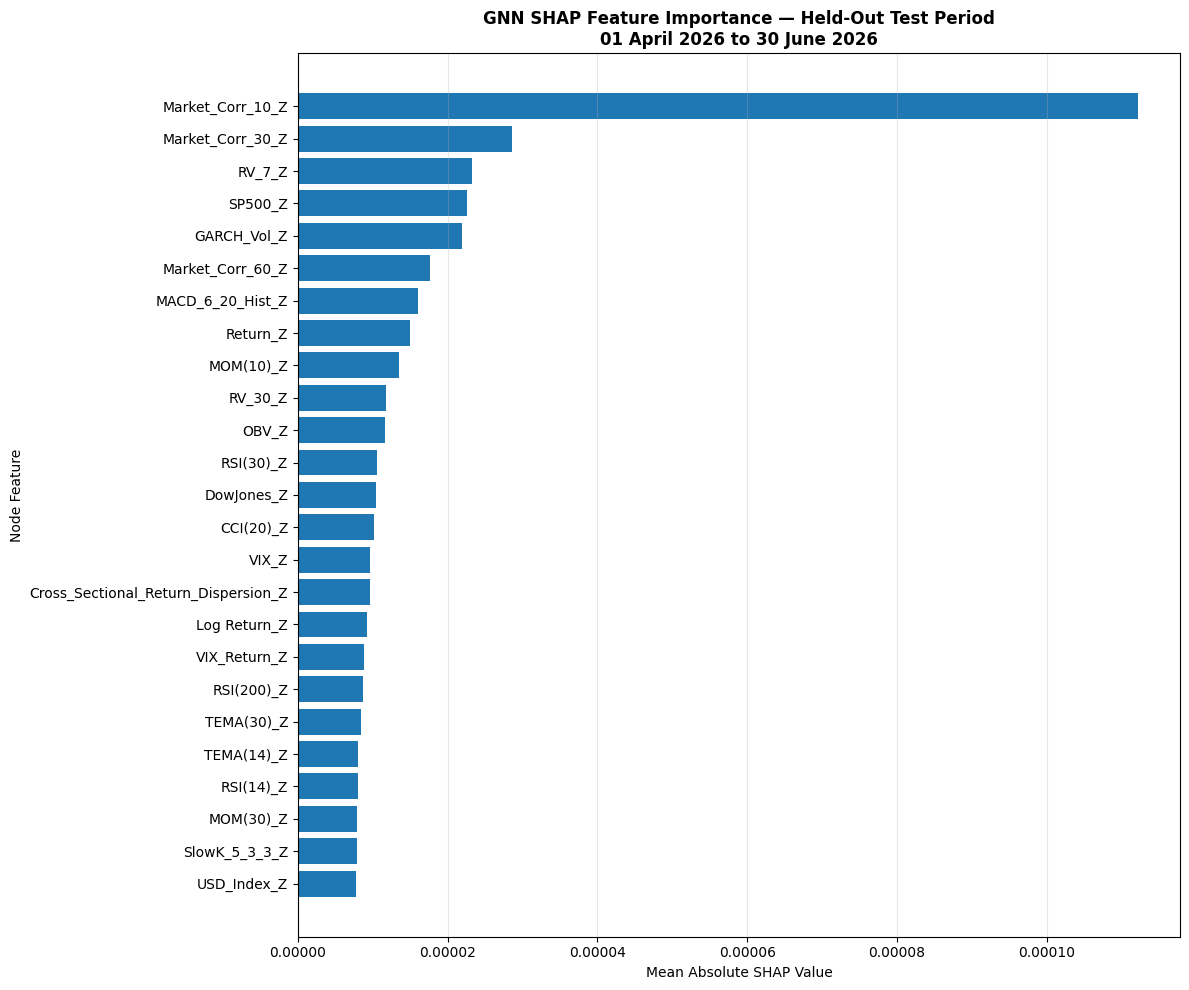

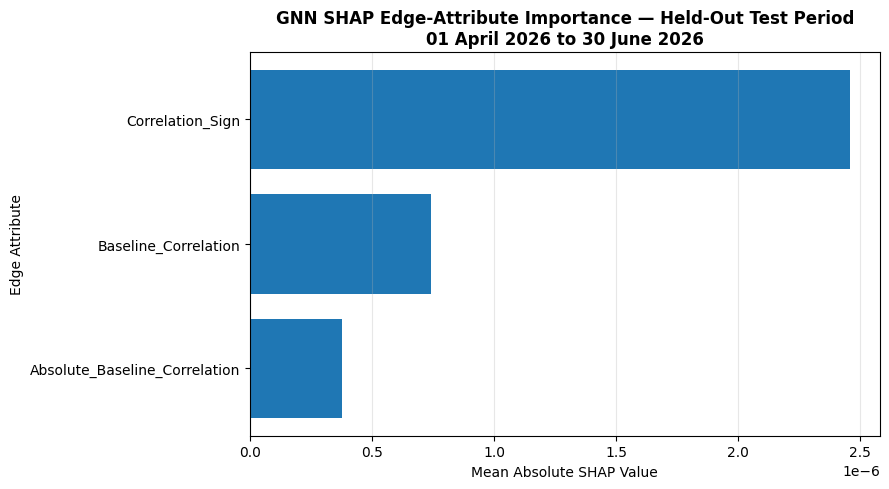

SHAP INTERPRETATION
These SHAP values explain the saved GNN model's mean absolute predicted Fisher-Z correlation-change magnitude across all 276 pairs.
They measure model feature influence, not causal economic effects.
Only held-out test Target_Dates from 01 April 2026 through 30 June 2026 are explained; OOS July-August data are excluded.


In [87]:
#====================================================
# VISUALIZE GNN SHAP FEATURE IMPORTANCE
# HELD-OUT TEST PERIOD TO 30 JUNE 2026
#====================================================

TOP_N_SHAP_FEATURES = min(
    25,
    len(shap_feature_importance)
)

shap_top_features = (
    shap_feature_importance
    .head(TOP_N_SHAP_FEATURES)
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=True
    )
)

plt.figure(
    figsize=(12, 10)
)

plt.barh(
    shap_top_features["Feature"],
    shap_top_features["Mean_Absolute_SHAP"]
)

plt.title(
    "GNN SHAP Feature Importance — Held-Out Test Period\n"
    "01 April 2026 to 30 June 2026",
    fontweight="bold"
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Node Feature"
)

plt.grid(
    axis="x",
    alpha=0.30
)

plt.tight_layout()
plt.show()


#====================================================
# EDGE ATTRIBUTE SHAP IMPORTANCE
#====================================================

edge_plot = (
    shap_edge_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=True
    )
)

plt.figure(
    figsize=(9, 5)
)

plt.barh(
    edge_plot["Edge_Feature"],
    edge_plot["Mean_Absolute_SHAP"]
)

plt.title(
    "GNN SHAP Edge-Attribute Importance — Held-Out Test Period\n"
    "01 April 2026 to 30 June 2026",
    fontweight="bold"
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Edge Attribute"
)

plt.grid(
    axis="x",
    alpha=0.30
)

plt.tight_layout()
plt.show()


#====================================================
# PRINT INTERPRETATION BOUNDARY
#====================================================

print("=" * 80)
print("SHAP INTERPRETATION")
print("=" * 80)
print(
    "These SHAP values explain the saved GNN model's mean absolute "
    "predicted Fisher-Z correlation-change magnitude across all 276 pairs."
)
print(
    "They measure model feature influence, not causal economic effects."
)
print(
    "Only held-out test Target_Dates from 01 April 2026 through "
    "30 June 2026 are explained; OOS July-August data are excluded."
)


---
## Hard boundary: held-out test evaluation ends here


## G. Out-of-Sample Forecasting (01 July 2026–15 August 2026)


In [88]:
#====================================================
# FINAL OUT-OF-SAMPLE GNN FORECASTING PIPELINE
#
# OOS TARGET PERIOD:
# 01 JULY 2026 - 15 AUGUST 2026
#
# FORECAST HORIZON:
# 7 CALENDAR DAYS
#
# INPUT SEQUENCE:
# 30 CALENDAR DAYS ENDING AT FORECAST ORIGIN t
#
# BASELINE CORRELATION:
# 30-DAY ROLLING CORRELATION ENDING AT t
#
# OUTPUT:
# 30-DAY CORRELATION FORECAST AT t+7
#
# IMPORTANT:
# NO REALISED t+7 CORRELATION IS USED.
# THIS IS GENUINE OUT-OF-SAMPLE INFERENCE.
#====================================================

import os
import shutil
import numpy as np
import pandas as pd
import torch

from torch.utils.data import (
    Dataset,
    DataLoader
)


#====================================================
# 1. OOS SETTINGS
#====================================================

OOS_START = pd.Timestamp(
    "2026-07-01"
)

OOS_END = pd.Timestamp(
    "2026-08-15"
)

SEQUENCE_LENGTH = 30

FORECAST_HORIZON = 7

BASE_CORR_WINDOW = 30

N_COINS = len(
    GNN_TICKERS
)

EXPECTED_PAIRS = (
    N_COINS
    *
    (N_COINS - 1)
    //
    2
)

EXPECTED_DIRECTED_EDGES = (
    N_COINS
    *
    (N_COINS - 1)
)


#====================================================
# STRICT CONFIGURATION CHECKS
#====================================================

assert N_COINS == 24

assert EXPECTED_PAIRS == 276

assert EXPECTED_DIRECTED_EDGES == 552

assert len(PAIR_LIST) == EXPECTED_PAIRS

assert edge_index.shape[1] == EXPECTED_DIRECTED_EDGES


#====================================================
# 2. CREATE OOS TARGET / ORIGIN SCHEDULE
#
# Target = Forecast Origin + 7 days
#====================================================

oos_target_dates = pd.date_range(

    start=OOS_START,

    end=OOS_END,

    freq="D"

)


oos_forecast_origins = (

    oos_target_dates

    -

    pd.Timedelta(
        days=FORECAST_HORIZON
    )

)


oos_schedule = pd.DataFrame({

    "Forecast_Origin":
        oos_forecast_origins,

    "Target_Date":
        oos_target_dates

})


#====================================================
# TEMPORAL INFORMATION CHECK
#====================================================

oos_schedule[
    "Horizon_Days"
] = (

    oos_schedule[
        "Target_Date"
    ]

    -

    oos_schedule[
        "Forecast_Origin"
    ]

).dt.days


assert (

    oos_schedule[
        "Horizon_Days"
    ]

    == FORECAST_HORIZON

).all()


#====================================================
# EXPECTED OOS COUNTS
#====================================================

EXPECTED_OOS_DAYS = len(
    oos_schedule
)

EXPECTED_PAIR_FORECASTS = (

    EXPECTED_OOS_DAYS

    *

    EXPECTED_PAIRS

)


print(
    "=" * 80
)

print(
    "FINAL GNN OUT-OF-SAMPLE FORECASTING"
)

print(
    "=" * 80
)


print(
    "OOS Target Period     :",
    OOS_START.date(),
    "to",
    OOS_END.date()
)


print(
    "First Forecast Origin :",
    oos_schedule[
        "Forecast_Origin"
    ].min().date()
)


print(
    "Last Forecast Origin  :",
    oos_schedule[
        "Forecast_Origin"
    ].max().date()
)


print(
    "Forecast Horizon      :",
    FORECAST_HORIZON,
    "days"
)


print(
    "Sequence Length       :",
    SEQUENCE_LENGTH,
    "days"
)


print(
    "Correlation Window    :",
    BASE_CORR_WINDOW,
    "days"
)


print(
    "OOS Target Dates      :",
    EXPECTED_OOS_DAYS
)


print(
    "Cryptocurrencies      :",
    N_COINS
)


print(
    "Unique Pairs          :",
    EXPECTED_PAIRS
)


print(
    "Expected Forecasts    :",
    EXPECTED_PAIR_FORECASTS
)


display(
    oos_schedule.head()
)


#====================================================
# 3. CHECK REQUIRED OBJECTS
#====================================================

required_objects = [

    "feature_tensor_by_date",

    "returns_wide",

    "GNN_TICKERS",

    "PAIR_LIST",

    "edge_index",

    "model",

    "device"

]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()

]


if missing_objects:

    raise NameError(

        "Missing required objects:\n"

        +

        "\n".join(
            missing_objects
        )

    )


#====================================================
# CHECK REQUIRED FUNCTIONS
#====================================================

required_functions = [

    "create_edge_attributes",

    "fisher_z",

    "inverse_fisher",

    "build_correlation_matrix"

]


missing_functions = [

    name

    for name in required_functions

    if name not in globals()

]


if missing_functions:

    raise NameError(

        "Missing required functions:\n"

        +

        "\n".join(
            missing_functions
        )

    )


#====================================================
# 4. STANDARDISE FEATURE DATES
#====================================================

feature_tensor_by_date = {

    pd.Timestamp(date):

        np.asarray(
            values,
            dtype=np.float32
        )

    for date, values
    in feature_tensor_by_date.items()

}


available_feature_dates = sorted(

    feature_tensor_by_date.keys()

)


#====================================================
# FEATURE COVERAGE
#====================================================

required_last_origin = (

    oos_schedule[
        "Forecast_Origin"
    ]

    .max()

)


if (

    available_feature_dates[-1]

    <

    required_last_origin

):

    raise ValueError(

        "GNN features do not extend through "
        "the final OOS forecast origin.\n"

        f"Required: {required_last_origin.date()}\n"

        f"Available: "
        f"{available_feature_dates[-1].date()}"

    )


print(
    "\nFeature coverage:"
)

print(
    available_feature_dates[0].date(),
    "to",
    available_feature_dates[-1].date()
)


#====================================================
# 5. PREPARE RETURNS MATRIX
#====================================================

returns_wide = (

    returns_wide

    .copy()

)


returns_wide.index = pd.to_datetime(

    returns_wide.index

)


returns_wide = (

    returns_wide

    .sort_index()

)


#====================================================
# REMOVE DUPLICATED DATES
#====================================================

returns_wide = returns_wide[

    ~returns_wide.index.duplicated(
        keep="last"
    )

]


#====================================================
# FORCE MODEL TICKER ORDER
#====================================================

missing_tickers = [

    ticker

    for ticker in GNN_TICKERS

    if ticker not in returns_wide.columns

]


if missing_tickers:

    raise ValueError(

        "Missing cryptocurrencies in returns_wide:\n"

        +

        "\n".join(
            missing_tickers
        )

    )


returns_wide = returns_wide.reindex(

    columns=GNN_TICKERS

)


#====================================================
# RETURNS COVERAGE
#====================================================

if (

    returns_wide.index.max()

    <

    required_last_origin

):

    raise ValueError(

        "returns_wide does not extend through "
        "the final OOS forecast origin.\n"

        f"Required: {required_last_origin.date()}\n"

        f"Available: "
        f"{returns_wide.index.max().date()}"

    )


print(
    "\nReturns coverage:"
)

print(
    returns_wide.index.min().date(),
    "to",
    returns_wide.index.max().date()
)


#====================================================
# 6. BUILD HISTORICAL CORRELATION AT EACH
# FORECAST ORIGIN
#
# IMPORTANT:
#
# Only information available through t is used.
#
# rho(t) becomes the persistence baseline and
# the starting point for Delta-Z prediction.
#====================================================

oos_baseline_corr_by_origin = {}


for forecast_origin in (

    oos_schedule[
        "Forecast_Origin"
    ]

):


    forecast_origin = pd.Timestamp(
        forecast_origin
    )


    #================================================
    # EXACT 30-CALENDAR-DAY WINDOW
    #
    # t-29 ... t
    #================================================

    corr_start = (

        forecast_origin

        -

        pd.Timedelta(
            days=BASE_CORR_WINDOW - 1
        )

    )


    corr_dates = pd.date_range(

        start=corr_start,

        end=forecast_origin,

        freq="D"

    )


    #================================================
    # REQUIRE COMPLETE WINDOW
    #================================================

    if not corr_dates.isin(

        returns_wide.index

    ).all():

        raise ValueError(

            f"{forecast_origin.date()}: "
            "missing dates in baseline "
            "correlation window."

        )


    historical_returns = (

        returns_wide

        .reindex(
            corr_dates
        )

    )


    if (

        historical_returns
        .isna()
        .any()
        .any()

    ):

        raise ValueError(

            f"{forecast_origin.date()}: "
            "NaN detected in baseline "
            "correlation window."

        )


    #================================================
    # HISTORICAL CORRELATION
    #================================================

    corr_df = (

        historical_returns

        .corr()

        .reindex(

            index=GNN_TICKERS,

            columns=GNN_TICKERS

        )

    )


    #================================================
    # WRITABLE NUMPY COPY
    #================================================

    corr_array = corr_df.to_numpy(

        dtype=np.float64,

        copy=True

    )


    corr_array = np.array(

        corr_array,

        dtype=np.float64,

        copy=True

    )


    #================================================
    # SYMMETRY
    #================================================

    corr_array = (

        corr_array

        +

        corr_array.T

    ) / 2.0


    #================================================
    # DIAGONAL
    #================================================

    np.fill_diagonal(

        corr_array,

        1.0

    )


    #================================================
    # NUMERICAL BOUNDS
    #================================================

    corr_array = np.clip(

        corr_array,

        -1.0,

        1.0

    )


    #================================================
    # VALIDATION
    #================================================

    if not np.isfinite(
        corr_array
    ).all():

        raise ValueError(

            f"{forecast_origin.date()}: "
            "non-finite baseline correlation."

        )


    assert np.allclose(

        corr_array,

        corr_array.T,

        atol=1e-10

    )


    assert np.allclose(

        np.diag(
            corr_array
        ),

        1.0

    )


    #================================================
    # STORE
    #================================================

    oos_baseline_corr_by_origin[

        forecast_origin

    ] = corr_array.astype(

        np.float32

    )


#====================================================
# CHECK BASELINE COUNT
#====================================================

assert (

    len(
        oos_baseline_corr_by_origin
    )

    ==

    EXPECTED_OOS_DAYS

)


print(

    "\nBaseline correlation matrices created:",

    len(
        oos_baseline_corr_by_origin
    )

)


#====================================================
# 7. CREATE OOS GNN SAMPLES
#
# IMPORTANT:
#
# X:
# t-29 ... t
#
# Baseline correlation:
# t-29 ... t
#
# Target:
# t+7
#
# No t+1 ... t+7 information is used.
#====================================================

oos_samples = []


for _, schedule_row in (

    oos_schedule.iterrows()

):


    forecast_origin = pd.Timestamp(

        schedule_row[
            "Forecast_Origin"
        ]

    )


    target_date = pd.Timestamp(

        schedule_row[
            "Target_Date"
        ]

    )


    #================================================
    # TEMPORAL SEQUENCE
    #================================================

    sequence_start = (

        forecast_origin

        -

        pd.Timedelta(
            days=SEQUENCE_LENGTH - 1
        )

    )


    sequence_dates = pd.date_range(

        start=sequence_start,

        end=forecast_origin,

        freq="D"

    )


    assert (

        len(
            sequence_dates
        )

        ==

        SEQUENCE_LENGTH

    )


    #================================================
    # CHECK FEATURE AVAILABILITY
    #================================================

    missing_dates = [

        date

        for date in sequence_dates

        if date not in feature_tensor_by_date

    ]


    if missing_dates:

        raise ValueError(

            f"{forecast_origin.date()}: "
            "missing feature dates:\n"

            +

            "\n".join(

                str(
                    date.date()
                )

                for date in missing_dates

            )

        )


    #================================================
    # STACK NODE FEATURES
    #
    # Shape:
    # [24, 30, F]
    #================================================

    X_sequence = np.stack(

        [

            feature_tensor_by_date[
                pd.Timestamp(date)
            ]

            for date in sequence_dates

        ],

        axis=1

    ).astype(

        np.float32

    )


    #================================================
    # STRICT SHAPE CHECK
    #================================================

    assert X_sequence.shape[0] == N_COINS

    assert X_sequence.shape[1] == SEQUENCE_LENGTH


    if not np.isfinite(

        X_sequence

    ).all():

        raise ValueError(

            f"{forecast_origin.date()}: "
            "non-finite node features."

        )


    #================================================
    # HISTORICAL BASELINE CORRELATION
    #================================================

    baseline_corr = np.array(

        oos_baseline_corr_by_origin[
            forecast_origin
        ],

        dtype=np.float32,

        copy=True

    )


    #================================================
    # EDGE ATTRIBUTES
    #================================================

    edge_attr = np.asarray(

        create_edge_attributes(
            baseline_corr
        ),

        dtype=np.float32

    )


    assert (

        edge_attr.shape[0]

        ==

        EXPECTED_DIRECTED_EDGES

    )


    #================================================
    # BASELINE FISHER-Z
    #================================================

    baseline_z = np.asarray(

        [

            fisher_z(

                float(
                    baseline_corr[i, j]
                )

            )

            for i, j in PAIR_LIST

        ],

        dtype=np.float32

    )


    assert baseline_z.shape == (

        EXPECTED_PAIRS,

    )


    #================================================
    # STORE SAMPLE
    #================================================

    oos_samples.append({

        "Forecast_Origin":

            forecast_origin,

        "Target_Date":

            target_date,

        "Sequence_Start":

            sequence_dates[0],

        "Sequence_End":

            sequence_dates[-1],

        "X":

            X_sequence,

        "Edge_Attr":

            edge_attr,

        "Baseline_Z":

            baseline_z,

        "Baseline_Corr":

            baseline_corr

    })


#====================================================
# SAMPLE COUNT
#====================================================

assert len(
    oos_samples
) == EXPECTED_OOS_DAYS


print(

    "\nOOS GNN samples created:",

    len(
        oos_samples
    )

)


#====================================================
# 8. TEMPORAL AUDIT
#====================================================

oos_temporal_audit = pd.DataFrame(

    [

        {

            "Sequence_Start":

                sample[
                    "Sequence_Start"
                ],

            "Sequence_End":

                sample[
                    "Sequence_End"
                ],

            "Forecast_Origin":

                sample[
                    "Forecast_Origin"
                ],

            "Target_Date":

                sample[
                    "Target_Date"
                ],

            "Sequence_Length":

                (

                    sample[
                        "Sequence_End"
                    ]

                    -

                    sample[
                        "Sequence_Start"
                    ]

                ).days + 1,

            "Forecast_Horizon_Days":

                (

                    sample[
                        "Target_Date"
                    ]

                    -

                    sample[
                        "Forecast_Origin"
                    ]

                ).days

        }

        for sample in oos_samples

    ]

)


#====================================================
# VALIDATE SEQUENCE LENGTH
#====================================================

assert (

    oos_temporal_audit[
        "Sequence_Length"
    ]

    ==

    SEQUENCE_LENGTH

).all()


#====================================================
# VALIDATE FORECAST HORIZON
#====================================================

assert (

    oos_temporal_audit[
        "Forecast_Horizon_Days"
    ]

    ==

    FORECAST_HORIZON

).all()


#====================================================
# CRITICAL LEAKAGE CHECK
#
# Sequence must end exactly at forecast origin.
#====================================================

assert (

    oos_temporal_audit[
        "Sequence_End"
    ]

    ==

    oos_temporal_audit[
        "Forecast_Origin"
    ]

).all()


print(
    "\nOOS TEMPORAL AUDIT"
)

display(
    oos_temporal_audit
)


#====================================================
# 9. OOS DATASET
#
# NO TARGET VARIABLES
#====================================================

class OOSCryptoGraphDataset(
    Dataset
):


    def __init__(
        self,
        samples
    ):

        self.samples = samples


    def __len__(
        self
    ):

        return len(
            self.samples
        )


    def __getitem__(
        self,
        index
    ):


        sample = self.samples[
            index
        ]


        return {

            "x":

                torch.tensor(

                    sample[
                        "X"
                    ],

                    dtype=torch.float32

                ),


            "edge_attr":

                torch.tensor(

                    sample[
                        "Edge_Attr"
                    ],

                    dtype=torch.float32

                ),


            "baseline_z":

                torch.tensor(

                    sample[
                        "Baseline_Z"
                    ],

                    dtype=torch.float32

                )

        }


#====================================================
# CREATE DATASET
#====================================================

oos_dataset = OOSCryptoGraphDataset(

    oos_samples

)


#====================================================
# CREATE LOADER
#====================================================

OOS_BATCH_SIZE = 4


oos_loader = DataLoader(

    oos_dataset,

    batch_size=OOS_BATCH_SIZE,

    shuffle=False,

    drop_last=False

)


print(
    "\nOOS Dataset Samples:",
    len(oos_dataset)
)


print(
    "OOS DataLoader Batches:",
    len(oos_loader)
)


#====================================================
# 10. LOAD / USE FINAL MODEL
#
# IMPORTANT:
# model should already contain the best
# validation checkpoint loaded earlier.
#====================================================

model = model.to(
    device
)

model.eval()


#====================================================
# 11. GENERATE OOS FORECASTS
#====================================================

oos_prediction_records = []

sample_index = 0


with torch.no_grad():


    for batch in oos_loader:


        #================================================
        # INPUT
        #================================================

        x = batch[
            "x"
        ].to(
            device
        )


        edge_attr = batch[
            "edge_attr"
        ].to(
            device
        )


        baseline_z = (

            batch[
                "baseline_z"
            ]

            .cpu()

            .numpy()

        )


        #================================================
        # MODEL PREDICTION
        #================================================

        model_output = model(

            x,

            edge_attr

        )


        #================================================
        # HANDLE MODEL RETURN
        #================================================

        if isinstance(

            model_output,

            (tuple, list)

        ):

            predicted_delta_z = (

                model_output[0]

            )

        else:

            predicted_delta_z = (

                model_output

            )


        predicted_delta_z = (

            predicted_delta_z

            .detach()

            .cpu()

            .numpy()

        )


        #================================================
        # SHAPE VALIDATION
        #================================================

        if (

            predicted_delta_z.shape

            !=

            baseline_z.shape

        ):

            raise ValueError(

                "Prediction shape does not match "
                "baseline Fisher-Z shape.\n"

                f"Prediction: "
                f"{predicted_delta_z.shape}\n"

                f"Baseline: "
                f"{baseline_z.shape}"

            )


        #================================================
        # RECONSTRUCT FUTURE FISHER-Z
        #
        # z_hat(t+7)
        # =
        # z(t) + Delta-z-hat(t+7)
        #================================================

        predicted_z = (

            baseline_z

            +

            predicted_delta_z

        )


        #================================================
        # RETURN TO CORRELATION SPACE
        #================================================

        predicted_corr = np.asarray(

            inverse_fisher(
                predicted_z
            ),

            dtype=np.float64

        )


        predicted_corr = np.clip(

            predicted_corr,

            -1.0,

            1.0

        )


        #================================================
        # STORE PAIR FORECASTS
        #================================================

        batch_size_actual = (

            predicted_corr.shape[0]

        )


        for batch_index in range(

            batch_size_actual

        ):


            sample = oos_samples[

                sample_index

            ]


            sample_index += 1


            for pair_id, (i, j) in enumerate(

                PAIR_LIST

            ):


                oos_prediction_records.append({

                    "Forecast_Origin":

                        sample[
                            "Forecast_Origin"
                        ],

                    "Target_Date":

                        sample[
                            "Target_Date"
                        ],

                    "Ticker_1":

                        GNN_TICKERS[i],

                    "Ticker_2":

                        GNN_TICKERS[j],

                    "Baseline_Z":

                        float(

                            baseline_z[
                                batch_index,
                                pair_id
                            ]

                        ),

                    "Predicted_Delta_Z":

                        float(

                            predicted_delta_z[
                                batch_index,
                                pair_id
                            ]

                        ),

                    "Baseline_Correlation":

                        float(

                            np.tanh(

                                baseline_z[
                                    batch_index,
                                    pair_id
                                ]

                            )

                        ),

                    "Predicted_Correlation":

                        float(

                            predicted_corr[
                                batch_index,
                                pair_id
                            ]

                        )

                })


#====================================================
# CHECK ALL SAMPLES PROCESSED
#====================================================

assert sample_index == EXPECTED_OOS_DAYS


#====================================================
# CREATE DATAFRAME
#====================================================

oos_prediction_df = pd.DataFrame(

    oos_prediction_records

)


#====================================================
# SORT
#====================================================

oos_prediction_df = (

    oos_prediction_df

    .sort_values(

        [
            "Target_Date",
            "Ticker_1",
            "Ticker_2"
        ]

    )

    .reset_index(
        drop=True
    )

)


#====================================================
# 12. STRICT OOS PREDICTION VALIDATION
#====================================================

assert (

    len(
        oos_prediction_df
    )

    ==

    EXPECTED_PAIR_FORECASTS

), (

    f"Expected {EXPECTED_PAIR_FORECASTS} "
    f"pair forecasts, found "
    f"{len(oos_prediction_df)}."

)


#====================================================
# 276 PAIRS PER TARGET DATE
#====================================================

pairs_per_date = (

    oos_prediction_df

    .groupby(
        "Target_Date"
    )

    .size()

)


assert (

    pairs_per_date

    ==

    EXPECTED_PAIRS

).all()


#====================================================
# 46 TARGET DATES
#====================================================

assert (

    oos_prediction_df[
        "Target_Date"
    ]

    .nunique()

    ==

    EXPECTED_OOS_DAYS

)


#====================================================
# EXACT TARGET PERIOD
#====================================================

assert (

    oos_prediction_df[
        "Target_Date"
    ]

    .min()

    ==

    OOS_START

)


assert (

    oos_prediction_df[
        "Target_Date"
    ]

    .max()

    ==

    OOS_END

)


#====================================================
# EXACT 7-DAY HORIZON
#====================================================

horizon_check = (

    oos_prediction_df[
        "Target_Date"
    ]

    -

    oos_prediction_df[
        "Forecast_Origin"
    ]

).dt.days


assert (

    horizon_check

    ==

    FORECAST_HORIZON

).all()


#====================================================
# NO DUPLICATE PAIR FORECASTS
#====================================================

duplicate_forecasts = (

    oos_prediction_df

    .duplicated(

        subset=[

            "Target_Date",

            "Ticker_1",

            "Ticker_2"

        ]

    )

    .sum()

)


assert duplicate_forecasts == 0


#====================================================
# FINITE CHECK
#====================================================

numeric_columns = [

    "Baseline_Z",

    "Predicted_Delta_Z",

    "Baseline_Correlation",

    "Predicted_Correlation"

]


assert np.isfinite(

    oos_prediction_df[
        numeric_columns
    ].to_numpy()

).all()


#====================================================
# CORRELATION BOUNDS
#====================================================

assert (

    oos_prediction_df[
        "Predicted_Correlation"
    ]

    .between(
        -1.0,
        1.0
    )

    .all()

)


print(
    "\n"
    +
    "=" * 80
)

print(
    "OOS PAIR FORECAST VALIDATION PASSED"
)

print(
    "=" * 80
)


print(
    "Target Dates      :",
    oos_prediction_df[
        "Target_Date"
    ].nunique()
)


print(
    "Pairs per Date    :",
    pairs_per_date.unique()
)


print(
    "Total Forecasts   :",
    len(oos_prediction_df)
)


#====================================================
# 13. SAVE RAW PAIR FORECASTS
#====================================================

OOS_PAIR_FILE = (

    "GNN_OOS_Pair_Predictions_"
    "2026-07-01_to_2026-08-15.csv"

)


oos_prediction_df.to_csv(

    OOS_PAIR_FILE,

    index=False

)


#====================================================
# SAVE TEMPORAL AUDIT
#====================================================

OOS_AUDIT_FILE = (

    "GNN_OOS_Temporal_Audit_"
    "2026-07-01_to_2026-08-15.csv"

)


oos_temporal_audit.to_csv(

    OOS_AUDIT_FILE,

    index=False

)


#====================================================
# 14. CREATE PSD-ADJUSTED OOS MATRICES
#====================================================

OOS_MATRIX_FOLDER = (

    "Predicted_Correlation_Matrices_Future"

)


os.makedirs(

    OOS_MATRIX_FOLDER,

    exist_ok=True

)


#====================================================
# REMOVE OLD OOS MATRICES ONLY
#====================================================

for filename in os.listdir(

    OOS_MATRIX_FOLDER

):


    if filename.lower().endswith(
        ".csv"
    ):

        os.remove(

            os.path.join(

                OOS_MATRIX_FOLDER,

                filename

            )

        )


#====================================================
# STORAGE
#====================================================

oos_correlation_matrices = {}

oos_psd_pair_records = []


#====================================================
# LOOP THROUGH OOS TARGET DATES
#====================================================

for target_date in oos_target_dates:


    target_date = pd.Timestamp(
        target_date
    )


    day_prediction = (

        oos_prediction_df[

            oos_prediction_df[
                "Target_Date"
            ]

            ==

            target_date

        ]

        .copy()

    )


    #================================================
    # STRICT PAIR COUNT
    #====================================================

    assert (

        len(
            day_prediction
        )

        ==

        EXPECTED_PAIRS

    )


    #================================================
    # BUILD PSD CORRELATION MATRIX
    #
    # Uses the SAME authoritative function
    # used for the held-out test period.
    #====================================================

    psd_matrix = build_correlation_matrix(

        day_prediction=

            day_prediction,

        tickers=

            GNN_TICKERS,

        value_column=

            "Predicted_Correlation"

    )


    #================================================
    # ENSURE DATAFRAME
    #====================================================

    if not isinstance(

        psd_matrix,

        pd.DataFrame

    ):

        psd_matrix = pd.DataFrame(

            psd_matrix,

            index=GNN_TICKERS,

            columns=GNN_TICKERS

        )


    #================================================
    # FORCE TICKER ORDER
    #====================================================

    psd_matrix = psd_matrix.reindex(

        index=GNN_TICKERS,

        columns=GNN_TICKERS

    )


    #================================================
    # CREATE WRITABLE COPY
    #====================================================

    psd_array = psd_matrix.to_numpy(

        dtype=np.float64,

        copy=True

    )


    psd_array = np.array(

        psd_array,

        dtype=np.float64,

        copy=True

    )


    #================================================
    # FORCE SYMMETRY
    #====================================================

    psd_array = (

        psd_array

        +

        psd_array.T

    ) / 2.0


    #================================================
    # DIAGONAL = 1
    #====================================================

    np.fill_diagonal(

        psd_array,

        1.0

    )


    #================================================
    # VALIDATION
    #====================================================

    if not np.isfinite(
        psd_array
    ).all():

        raise ValueError(

            f"{target_date.date()}: "
            "PSD matrix contains NaN/Inf."

        )


    assert np.allclose(

        psd_array,

        psd_array.T,

        atol=1e-8

    )


    assert np.allclose(

        np.diag(
            psd_array
        ),

        1.0,

        atol=1e-8

    )


    #================================================
    # PSD CHECK
    #====================================================

    eigenvalues = np.linalg.eigvalsh(

        psd_array

    )


    min_eigenvalue = float(

        eigenvalues.min()

    )


    if min_eigenvalue < -1e-8:

        raise ValueError(

            f"{target_date.date()}: "
            "matrix is not PSD. "
            f"Minimum eigenvalue = "
            f"{min_eigenvalue:.10f}"

        )


    #================================================
    # REBUILD DATAFRAME
    #====================================================

    psd_matrix = pd.DataFrame(

        psd_array,

        index=GNN_TICKERS,

        columns=GNN_TICKERS

    )


    #================================================
    # STORE
    #====================================================

    oos_correlation_matrices[

        target_date

    ] = psd_matrix


    #================================================
    # ADD PSD PAIR VALUES TO TABLE
    #====================================================

    for i, j in PAIR_LIST:


        oos_psd_pair_records.append({

            "Target_Date":

                target_date,

            "Ticker_1":

                GNN_TICKERS[i],

            "Ticker_2":

                GNN_TICKERS[j],

            "PSD_Predicted_Correlation":

                float(
                    psd_array[i, j]
                )

        })


    #================================================
    # SAVE MATRIX
    #
    # IMPORTANT:
    # Filename = TARGET DATE
    #
    # HRP therefore retrieves the matrix corresponding
    # to the portfolio effective date.
    #====================================================

    matrix_file = os.path.join(

        OOS_MATRIX_FOLDER,

        target_date.strftime(
            "%Y-%m-%d"
        )
        +
        ".csv"

    )


    psd_matrix.to_csv(

        matrix_file

    )


#====================================================
# 15. MERGE PSD VALUES BACK TO PAIR FORECAST TABLE
#====================================================

oos_psd_pair_df = pd.DataFrame(

    oos_psd_pair_records

)


oos_prediction_df = (

    oos_prediction_df

    .merge(

        oos_psd_pair_df,

        on=[

            "Target_Date",

            "Ticker_1",

            "Ticker_2"

        ],

        how="left",

        validate="one_to_one"

    )

)


#====================================================
# CHECK PSD VALUES
#====================================================

assert (

    oos_prediction_df[
        "PSD_Predicted_Correlation"
    ]

    .notna()

    .all()

)


assert (

    oos_prediction_df[
        "PSD_Predicted_Correlation"
    ]

    .between(
        -1.0,
        1.0
    )

    .all()

)


#====================================================
# SAVE UPDATED PAIR TABLE
#====================================================

oos_prediction_df.to_csv(

    OOS_PAIR_FILE,

    index=False

)


#====================================================
# 16. FINAL MATRIX VALIDATION
#====================================================

assert (

    len(
        oos_correlation_matrices
    )

    ==

    EXPECTED_OOS_DAYS

)


saved_matrix_files = [

    filename

    for filename in os.listdir(

        OOS_MATRIX_FOLDER

    )

    if filename.lower().endswith(
        ".csv"
    )

]


assert (

    len(
        saved_matrix_files
    )

    ==

    EXPECTED_OOS_DAYS

)


print(
    "\n"
    +
    "=" * 80
)

print(
    "OOS PSD MATRIX VALIDATION PASSED"
)

print(
    "=" * 80
)


print(
    "PSD Matrices:",
    len(
        oos_correlation_matrices
    )
)


print(
    "First Matrix:",
    min(
        oos_correlation_matrices
    ).date()
)


print(
    "Last Matrix:",
    max(
        oos_correlation_matrices
    ).date()
)


#====================================================
# 17. CREATE HRP MATRIX FOLDER
#
# Merge:
#
# TEST PSD matrices
# +
# OOS PSD matrices
#
# into the folder used by HRP.
#====================================================

TEST_MATRIX_FOLDER = (

    "Predicted_Correlation_Matrices"

)


HRP_MATRIX_FOLDER = (

    "Predicted_Correlation_Matrices_Updated"

)


#====================================================
# TEST MATRIX FOLDER MUST EXIST
#====================================================

if not os.path.exists(

    TEST_MATRIX_FOLDER

):

    raise FileNotFoundError(

        "Test PSD matrix folder not found:\n"

        f"{TEST_MATRIX_FOLDER}"

    )


#====================================================
# RESET HRP FOLDER
#====================================================

if os.path.exists(

    HRP_MATRIX_FOLDER

):

    shutil.rmtree(

        HRP_MATRIX_FOLDER

    )


os.makedirs(

    HRP_MATRIX_FOLDER,

    exist_ok=True

)


#====================================================
# COPY TEST + OOS MATRICES
#====================================================

for source_folder in [

    TEST_MATRIX_FOLDER,

    OOS_MATRIX_FOLDER

]:


    for filename in sorted(

        os.listdir(
            source_folder
        )

    ):


        if not filename.lower().endswith(
            ".csv"
        ):

            continue


        source_file = os.path.join(

            source_folder,

            filename

        )


        destination_file = os.path.join(

            HRP_MATRIX_FOLDER,

            filename

        )


        #================================================
        # PREVENT ACCIDENTAL OVERWRITE
        #====================================================

        if os.path.exists(

            destination_file

        ):

            raise ValueError(

                "Duplicate matrix file detected:\n"

                f"{filename}"

            )


        shutil.copy2(

            source_file,

            destination_file

        )


#====================================================
# 18. VERIFY HRP-REQUIRED TARGET DATES
#
# HRP rebalances every 7 days.
#====================================================

HRP_TARGET_DATES = pd.date_range(

    start=OOS_START,

    end=OOS_END,

    freq="7D"

)


missing_hrp_matrices = []


for target_date in HRP_TARGET_DATES:


    expected_file = os.path.join(

        HRP_MATRIX_FOLDER,

        target_date.strftime(
            "%Y-%m-%d"
        )
        +
        ".csv"

    )


    if not os.path.exists(

        expected_file

    ):

        missing_hrp_matrices.append(

            target_date

        )


if missing_hrp_matrices:

    raise FileNotFoundError(

        "Missing GNN matrices required by HRP:\n"

        +

        "\n".join(

            str(
                date.date()
            )

            for date in missing_hrp_matrices

        )

    )


#====================================================
# 19. PRINT HRP MATRIX SCHEDULE
#====================================================

hrp_gnn_schedule = pd.DataFrame({

    "Forecast_Origin":

        HRP_TARGET_DATES

        -

        pd.Timedelta(
            days=FORECAST_HORIZON
        ),

    "Target_Date":

        HRP_TARGET_DATES

})


print(
    "\n"
    +
    "=" * 80
)

print(
    "GNN MATRICES AVAILABLE FOR HRP"
)

print(
    "=" * 80
)


display(
    hrp_gnn_schedule
)


#====================================================
# 20. FINAL OOS SUMMARY
#====================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "FINAL GNN OOS PIPELINE COMPLETE"
)

print(
    "=" * 80
)


print(
    "Target Period          :",
    OOS_START.date(),
    "to",
    OOS_END.date()
)


print(
    "Forecast Origins       :",
    oos_schedule[
        "Forecast_Origin"
    ].min().date(),
    "to",
    oos_schedule[
        "Forecast_Origin"
    ].max().date()
)


print(
    "OOS Target Dates       :",
    EXPECTED_OOS_DAYS
)


print(
    "Temporal Samples       :",
    len(
        oos_samples
    )
)


print(
    "Unique Pairs / Date    :",
    EXPECTED_PAIRS
)


print(
    "Total Pair Forecasts   :",
    len(
        oos_prediction_df
    )
)


print(
    "PSD Matrices           :",
    len(
        oos_correlation_matrices
    )
)


print(
    "HRP Required Matrices  :",
    len(
        HRP_TARGET_DATES
    )
)


print(
    "\nFiles:"
)


print(
    "Pair Forecasts:",
    OOS_PAIR_FILE
)


print(
    "Temporal Audit:",
    OOS_AUDIT_FILE
)


print(
    "OOS Matrices:",
    OOS_MATRIX_FOLDER
)


print(
    "HRP Matrix Folder:",
    HRP_MATRIX_FOLDER
)

FINAL GNN OUT-OF-SAMPLE FORECASTING
OOS Target Period     : 2026-07-01 to 2026-08-15
First Forecast Origin : 2026-06-24
Last Forecast Origin  : 2026-08-08
Forecast Horizon      : 7 days
Sequence Length       : 30 days
Correlation Window    : 30 days
OOS Target Dates      : 46
Cryptocurrencies      : 24
Unique Pairs          : 276
Expected Forecasts    : 12696


,Forecast_Origin,Target_Date,Horizon_Days
0,2026-06-24,2026-07-01,7
1,2026-06-25,2026-07-02,7
2,2026-06-26,2026-07-03,7
3,2026-06-27,2026-07-04,7
4,2026-06-28,2026-07-05,7



Feature coverage:
2021-02-22 to 2026-08-08

Returns coverage:
2021-02-22 to 2026-08-08

Baseline correlation matrices created: 46

OOS GNN samples created: 46

OOS TEMPORAL AUDIT


,Sequence_Start,Sequence_End,Forecast_Origin,Target_Date,Sequence_Length,Forecast_Horizon_Days
0,2026-05-26,2026-06-24,2026-06-24,2026-07-01,30,7
1,2026-05-27,2026-06-25,2026-06-25,2026-07-02,30,7
2,2026-05-28,2026-06-26,2026-06-26,2026-07-03,30,7
3,2026-05-29,2026-06-27,2026-06-27,2026-07-04,30,7
4,2026-05-30,2026-06-28,2026-06-28,2026-07-05,30,7
5,2026-05-31,2026-06-29,2026-06-29,2026-07-06,30,7
6,2026-06-01,2026-06-30,2026-06-30,2026-07-07,30,7
7,2026-06-02,2026-07-01,2026-07-01,2026-07-08,30,7
8,2026-06-03,2026-07-02,2026-07-02,2026-07-09,30,7
9,2026-06-04,2026-07-03,2026-07-03,2026-07-10,30,7



OOS Dataset Samples: 46
OOS DataLoader Batches: 12

OOS PAIR FORECAST VALIDATION PASSED
Target Dates      : 46
Pairs per Date    : [276]
Total Forecasts   : 12696

OOS PSD MATRIX VALIDATION PASSED
PSD Matrices: 46
First Matrix: 2026-07-01
Last Matrix: 2026-08-15

GNN MATRICES AVAILABLE FOR HRP


,Forecast_Origin,Target_Date
0,2026-06-24,2026-07-01
1,2026-07-01,2026-07-08
2,2026-07-08,2026-07-15
3,2026-07-15,2026-07-22
4,2026-07-22,2026-07-29
5,2026-07-29,2026-08-05
6,2026-08-05,2026-08-12



FINAL GNN OOS PIPELINE COMPLETE
Target Period          : 2026-07-01 to 2026-08-15
Forecast Origins       : 2026-06-24 to 2026-08-08
OOS Target Dates       : 46
Temporal Samples       : 46
Unique Pairs / Date    : 276
Total Pair Forecasts   : 12696
PSD Matrices           : 46
HRP Required Matrices  : 7

Files:
Pair Forecasts: GNN_OOS_Pair_Predictions_2026-07-01_to_2026-08-15.csv
Temporal Audit: GNN_OOS_Temporal_Audit_2026-07-01_to_2026-08-15.csv
OOS Matrices: Predicted_Correlation_Matrices_Future
HRP Matrix Folder: Predicted_Correlation_Matrices_Updated


## H. Ex-Post OOS Forecast Evaluation
Realised correlations below are used only to evaluate forecasts after the fact; they are not inputs to GNN inference or HRP.


In [89]:
#====================================================
# OOS EX-POST EVALUATION PERIOD
#
# GNN FORECAST PERIOD:
# 01 JULY 2026 - 15 AUGUST 2026
#
# EX-POST EVALUATION PERIOD:
# Limited by availability of realised returns.
#
# IMPORTANT:
# This does NOT change the OOS forecasting period.
#====================================================

import numpy as np
import pandas as pd


#====================================================
# REQUESTED OOS FORECAST PERIOD
#====================================================

OOS_FORECAST_START = pd.Timestamp(
    "2026-07-01"
)

OOS_FORECAST_END = pd.Timestamp(
    "2026-08-15"
)


#====================================================
# PREPARE REALISED RETURNS
#====================================================

if "returns_wide" not in globals():

    raise NameError(
        "returns_wide does not exist."
    )


oos_returns = (
    returns_wide
    .copy()
)


#====================================================
# STANDARDISE DATE INDEX
#====================================================

oos_returns.index = pd.to_datetime(
    oos_returns.index
)


oos_returns = (
    oos_returns
    .sort_index()
)


#====================================================
# REMOVE DUPLICATED DATES
#====================================================

oos_returns = oos_returns[

    ~oos_returns.index.duplicated(
        keep="last"
    )

]


#====================================================
# FORCE GNN TICKER ORDER
#====================================================

missing_tickers = [

    ticker

    for ticker in GNN_TICKERS

    if ticker not in oos_returns.columns

]


if missing_tickers:

    raise ValueError(

        "Missing cryptocurrencies "
        "in returns_wide:\n"

        +

        "\n".join(
            missing_tickers
        )

    )


oos_returns = oos_returns.reindex(
    columns=GNN_TICKERS
)


#====================================================
# FIND LAST AVAILABLE REALISED DATE
#====================================================

LAST_REALISED_DATE = pd.Timestamp(

    oos_returns.index.max()

)


#====================================================
# DEFINE EX-POST EVALUATION END
#
# Cannot evaluate beyond available realised data.
#====================================================

OOS_EVAL_START = OOS_FORECAST_START


OOS_EVAL_END = min(

    OOS_FORECAST_END,

    LAST_REALISED_DATE

)


#====================================================
# VALIDATION
#====================================================

if OOS_EVAL_END < OOS_EVAL_START:

    raise ValueError(

        "No realised return observations are "
        "available during the OOS evaluation period."

    )


#====================================================
# PRINT PERIOD INFORMATION
#====================================================

print(
    "=" * 80
)

print(
    "OOS FORECAST AND EX-POST EVALUATION PERIODS"
)

print(
    "=" * 80
)


print(
    "GNN Forecast Period:"
)

print(
    OOS_FORECAST_START.date(),
    "to",
    OOS_FORECAST_END.date()
)


print(
    "\nAvailable Realised Returns:"
)

print(
    oos_returns.index.min().date(),
    "to",
    LAST_REALISED_DATE.date()
)


print(
    "\nEx-Post Evaluation Period:"
)

print(
    OOS_EVAL_START.date(),
    "to",
    OOS_EVAL_END.date()
)


#====================================================
# WARNING IF EVALUATION PERIOD IS SHORTER
#====================================================

if OOS_EVAL_END < OOS_FORECAST_END:

    print(
        "\nWARNING:"
    )

    print(
        "GNN forecasts continue through "
        f"{OOS_FORECAST_END.date()},"
    )

    print(
        "but realised correlation forecast "
        "accuracy can currently only be "
        "evaluated through "
        f"{OOS_EVAL_END.date()}."
    )


#====================================================
# EXPECTED EVALUATION COUNTS
#====================================================

EXPECTED_EVAL_DAYS = (

    OOS_EVAL_END

    -

    OOS_EVAL_START

).days + 1


EXPECTED_PAIRS = (

    len(GNN_TICKERS)

    *

    (
        len(GNN_TICKERS) - 1
    )

    //

    2

)


EXPECTED_EVAL_FORECASTS = (

    EXPECTED_EVAL_DAYS

    *

    EXPECTED_PAIRS

)


print(
    "\nExpected Evaluation Days:",
    EXPECTED_EVAL_DAYS
)


print(
    "Pairs per Day:",
    EXPECTED_PAIRS
)


print(
    "Expected Pair Evaluations:",
    EXPECTED_EVAL_FORECASTS
)

OOS FORECAST AND EX-POST EVALUATION PERIODS
GNN Forecast Period:
2026-07-01 to 2026-08-15

Available Realised Returns:
2021-02-22 to 2026-08-08

Ex-Post Evaluation Period:
2026-07-01 to 2026-08-08

GNN forecasts continue through 2026-08-15,
but realised correlation forecast accuracy can currently only be evaluated through 2026-08-08.

Expected Evaluation Days: 39
Pairs per Day: 276
Expected Pair Evaluations: 10764


In [90]:
#====================================================
# FILTER OOS FORECASTS TO THE PERIOD
# FOR WHICH ACTUAL CORRELATIONS ARE AVAILABLE
#====================================================

oos_evaluation = (

    oos_prediction_df[

        (
            oos_prediction_df[
                "Target_Date"
            ]
            >=
            OOS_EVAL_START
        )

        &

        (
            oos_prediction_df[
                "Target_Date"
            ]
            <=
            OOS_EVAL_END
        )

    ]

    .copy()

)


#====================================================
# SORT
#====================================================

oos_evaluation = (

    oos_evaluation

    .sort_values(

        [
            "Target_Date",
            "Ticker_1",
            "Ticker_2"
        ]

    )

    .reset_index(
        drop=True
    )

)


#====================================================
# VALIDATION
#====================================================

print(
    "=" * 80
)

print(
    "OOS FORECASTS AVAILABLE FOR EX-POST EVALUATION"
)

print(
    "=" * 80
)


print(
    "First Target Date:",
    oos_evaluation[
        "Target_Date"
    ].min().date()
)


print(
    "Last Target Date:",
    oos_evaluation[
        "Target_Date"
    ].max().date()
)


print(
    "Number of Target Dates:",
    oos_evaluation[
        "Target_Date"
    ].nunique()
)


print(
    "Number of Pair Forecasts:",
    len(oos_evaluation)
)


#====================================================
# EXPECTED COUNTS
#====================================================

assert (

    oos_evaluation[
        "Target_Date"
    ].nunique()

    ==

    EXPECTED_EVAL_DAYS

)


assert (

    len(oos_evaluation)

    ==

    EXPECTED_EVAL_FORECASTS

)


pairs_per_date = (

    oos_evaluation

    .groupby(
        "Target_Date"
    )

    .size()

)


assert (

    pairs_per_date

    ==

    EXPECTED_PAIRS

).all()


print(
    "\nValidation passed."
)

OOS FORECASTS AVAILABLE FOR EX-POST EVALUATION
First Target Date: 2026-07-01
Last Target Date: 2026-08-08
Number of Target Dates: 39
Number of Pair Forecasts: 10764

Validation passed.


In [91]:
#====================================================
# CREATE ACTUAL OOS 30-DAY CORRELATIONS
# FOR EX-POST GNN EVALUATION
#
# IMPORTANT:
# These realised correlations are used ONLY
# for forecast evaluation.
#
# They are NOT used to generate the GNN forecasts
# or construct the OOS HRP portfolio.
#====================================================

import numpy as np
import pandas as pd


#====================================================
# 1. SETTINGS
#====================================================

OOS_FORECAST_START = pd.Timestamp(
    "2026-07-01"
)

OOS_FORECAST_END = pd.Timestamp(
    "2026-08-15"
)

BASE_CORR_WINDOW = 30

N_COINS = len(
    GNN_TICKERS
)

EXPECTED_PAIRS = (

    N_COINS
    *
    (N_COINS - 1)
    //
    2

)


#====================================================
# 2. CHECK REQUIRED OBJECTS
#====================================================

if "oos_prediction_df" not in globals():

    raise NameError(

        "oos_prediction_df does not exist. "
        "Run the OOS GNN forecasting pipeline first."

    )


if "returns_wide" not in globals():

    raise NameError(

        "returns_wide does not exist."

    )


#====================================================
# 3. PREPARE REALISED RETURNS
#====================================================

oos_returns = (

    returns_wide

    .copy()

)


oos_returns.index = pd.to_datetime(

    oos_returns.index

)


oos_returns = (

    oos_returns

    .sort_index()

)


#====================================================
# REMOVE DUPLICATED DATES
#====================================================

oos_returns = oos_returns[

    ~oos_returns.index.duplicated(
        keep="last"
    )

]


#====================================================
# FORCE GNN TICKER ORDER
#====================================================

missing_tickers = [

    ticker

    for ticker in GNN_TICKERS

    if ticker not in oos_returns.columns

]


if missing_tickers:

    raise ValueError(

        "Missing cryptocurrencies in "
        "returns_wide:\n"

        +

        "\n".join(
            missing_tickers
        )

    )


oos_returns = oos_returns.reindex(

    columns=GNN_TICKERS

)


#====================================================
# 4. DETERMINE AVAILABLE EX-POST
# EVALUATION PERIOD
#====================================================

LAST_REALISED_DATE = pd.Timestamp(

    oos_returns.index.max()

)


OOS_EVAL_START = OOS_FORECAST_START


OOS_EVAL_END = min(

    OOS_FORECAST_END,

    LAST_REALISED_DATE

)


if OOS_EVAL_END < OOS_EVAL_START:

    raise ValueError(

        "No realised return data are available "
        "during the OOS evaluation period."

    )


#====================================================
# PRINT PERIOD
#====================================================

print(
    "=" * 80
)

print(
    "OOS EX-POST CORRELATION EVALUATION"
)

print(
    "=" * 80
)


print(
    "GNN Forecast Period :",
    OOS_FORECAST_START.date(),
    "to",
    OOS_FORECAST_END.date()
)


print(
    "Realised Data Ends  :",
    LAST_REALISED_DATE.date()
)


print(
    "Evaluation Period   :",
    OOS_EVAL_START.date(),
    "to",
    OOS_EVAL_END.date()
)


#====================================================
# 5. FILTER OOS GNN FORECASTS
# TO EVALUATION PERIOD
#====================================================

oos_evaluation = (

    oos_prediction_df

    .copy()

)


#====================================================
# DATE FORMAT
#====================================================

oos_evaluation[
    "Forecast_Origin"
] = pd.to_datetime(

    oos_evaluation[
        "Forecast_Origin"
    ]

)


oos_evaluation[
    "Target_Date"
] = pd.to_datetime(

    oos_evaluation[
        "Target_Date"
    ]

)


#====================================================
# FILTER
#====================================================

oos_evaluation = (

    oos_evaluation[

        (
            oos_evaluation[
                "Target_Date"
            ]
            >=
            OOS_EVAL_START
        )

        &

        (
            oos_evaluation[
                "Target_Date"
            ]
            <=
            OOS_EVAL_END
        )

    ]

    .copy()

)


#====================================================
# IMPORTANT:
# REMOVE OLD Actual_Correlation IF THIS CELL
# IS RE-RUN
#====================================================

if "Actual_Correlation" in oos_evaluation.columns:

    oos_evaluation = (

        oos_evaluation

        .drop(
            columns=[
                "Actual_Correlation"
            ]
        )

    )


#====================================================
# 6. CREATE REALISED 30-DAY
# CORRELATION TARGETS
#
# Target correlation at date T:
#
# Corr(Returns from T-29 through T)
#====================================================

actual_records = []


evaluation_dates = pd.date_range(

    start=OOS_EVAL_START,

    end=OOS_EVAL_END,

    freq="D"

)


for target_date in evaluation_dates:


    target_date = pd.Timestamp(
        target_date
    )


    #================================================
    # 30-DAY WINDOW
    #================================================

    window_start = (

        target_date

        -

        pd.Timedelta(
            days=BASE_CORR_WINDOW - 1
        )

    )


    required_dates = pd.date_range(

        start=window_start,

        end=target_date,

        freq="D"

    )


    #================================================
    # CHECK DATE AVAILABILITY
    #================================================

    missing_dates = required_dates[

        ~required_dates.isin(
            oos_returns.index
        )

    ]


    if len(missing_dates) > 0:

        raise ValueError(

            f"{target_date.date()}: "
            "missing dates in the realised "
            "30-day correlation window.\n"

            f"First missing date: "
            f"{missing_dates[0].date()}"

        )


    #================================================
    # EXTRACT RETURNS
    #================================================

    target_returns = (

        oos_returns

        .reindex(
            required_dates
        )

        .reindex(
            columns=GNN_TICKERS
        )

    )


    #================================================
    # CHECK MISSING RETURNS
    #================================================

    if (

        target_returns

        .isna()

        .any()

        .any()

    ):

        missing_count = int(

            target_returns

            .isna()

            .sum()

            .sum()

        )


        raise ValueError(

            f"{target_date.date()}: "
            f"{missing_count} missing return "
            "observations in the realised "
            "correlation window."

        )


    #================================================
    # CALCULATE ACTUAL 30-DAY CORRELATION
    #================================================

    actual_corr = (

        target_returns

        .corr()

        .reindex(

            index=GNN_TICKERS,

            columns=GNN_TICKERS

        )

    )


    #================================================
    # WRITABLE NUMPY COPY
    #================================================

    actual_array = (

        actual_corr

        .to_numpy(
            dtype=float,
            copy=True
        )

    )


    #================================================
    # VALIDATION
    #================================================

    if not np.isfinite(

        actual_array

    ).all():

        raise ValueError(

            f"{target_date.date()}: "
            "Actual correlation matrix contains "
            "NaN or infinite values."

        )


    if not np.allclose(

        actual_array,

        actual_array.T,

        atol=1e-10

    ):

        raise ValueError(

            f"{target_date.date()}: "
            "Actual correlation matrix "
            "is not symmetric."

        )


    #================================================
    # EXTRACT 276 UNIQUE PAIRS
    #================================================

    for i, j in PAIR_LIST:


        actual_records.append({

            "Target_Date":

                target_date,

            "Ticker_1":

                GNN_TICKERS[i],

            "Ticker_2":

                GNN_TICKERS[j],

            "Actual_Correlation":

                float(
                    actual_array[i, j]
                )

        })


#====================================================
# 7. CREATE ACTUAL OOS DATAFRAME
#====================================================

actual_oos_df = pd.DataFrame(

    actual_records

)


#====================================================
# SORT
#====================================================

actual_oos_df = (

    actual_oos_df

    .sort_values(

        [
            "Target_Date",
            "Ticker_1",
            "Ticker_2"
        ]

    )

    .reset_index(
        drop=True
    )

)


#====================================================
# 8. VALIDATE ACTUAL OOS TARGETS
#====================================================

EXPECTED_EVAL_DAYS = len(

    evaluation_dates

)


EXPECTED_EVAL_OBSERVATIONS = (

    EXPECTED_EVAL_DAYS

    *

    EXPECTED_PAIRS

)


assert (

    actual_oos_df[
        "Target_Date"
    ]

    .nunique()

    ==

    EXPECTED_EVAL_DAYS

)


assert (

    len(
        actual_oos_df
    )

    ==

    EXPECTED_EVAL_OBSERVATIONS

)


actual_pairs_per_date = (

    actual_oos_df

    .groupby(
        "Target_Date"
    )

    .size()

)


assert (

    actual_pairs_per_date

    ==

    EXPECTED_PAIRS

).all()


#====================================================
# 9. MERGE ACTUAL CORRELATIONS WITH
# OOS GNN FORECASTS
#====================================================

oos_evaluation = (

    oos_evaluation

    .merge(

        actual_oos_df,

        on=[

            "Target_Date",

            "Ticker_1",

            "Ticker_2"

        ],

        how="left",

        validate="one_to_one"

    )

)


#====================================================
# 10. CHECK MERGE
#====================================================

missing_actual = (

    oos_evaluation[
        "Actual_Correlation"
    ]

    .isna()

    .sum()

)


if missing_actual > 0:

    raise ValueError(

        f"{missing_actual} OOS forecasts "
        "could not be matched with an "
        "actual correlation."

    )


#====================================================
# 11. STRICT FINAL VALIDATION
#====================================================

assert (

    oos_evaluation[
        "Target_Date"
    ]

    .nunique()

    ==

    EXPECTED_EVAL_DAYS

)


assert (

    len(
        oos_evaluation
    )

    ==

    EXPECTED_EVAL_OBSERVATIONS

)


pairs_per_date = (

    oos_evaluation

    .groupby(
        "Target_Date"
    )

    .size()

)


assert (

    pairs_per_date

    ==

    EXPECTED_PAIRS

).all()


#====================================================
# 12. CHECK REQUIRED FORECAST COLUMNS
#====================================================

required_columns = [

    "Actual_Correlation",

    "Baseline_Correlation",

    "Predicted_Correlation",

    "PSD_Predicted_Correlation"

]


missing_columns = [

    column

    for column in required_columns

    if column not in oos_evaluation.columns

]


if missing_columns:

    raise ValueError(

        "Missing columns after merge:\n"

        +

        "\n".join(
            missing_columns
        )

    )


#====================================================
# 13. PRINT FINAL RESULT
#====================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "OOS ACTUAL CORRELATIONS SUCCESSFULLY CREATED"
)

print(
    "=" * 80
)


print(
    "Evaluation Period :",
    oos_evaluation[
        "Target_Date"
    ].min().date(),
    "to",
    oos_evaluation[
        "Target_Date"
    ].max().date()
)


print(
    "Target Dates      :",
    oos_evaluation[
        "Target_Date"
    ].nunique()
)


print(
    "Pairs per Date    :",
    pairs_per_date.unique()
)


print(
    "Total Observations:",
    len(
        oos_evaluation
    )
)


print(
    "\nColumns available:"
)


print(

    oos_evaluation[
        [
            "Actual_Correlation",
            "Baseline_Correlation",
            "Predicted_Correlation",
            "PSD_Predicted_Correlation"
        ]
    ]

    .columns

    .tolist()

)


#====================================================
# PREVIEW
#====================================================

display(

    oos_evaluation[

        [
            "Forecast_Origin",
            "Target_Date",
            "Ticker_1",
            "Ticker_2",
            "Actual_Correlation",
            "Baseline_Correlation",
            "Predicted_Correlation",
            "PSD_Predicted_Correlation"
        ]

    ]

    .head(10)

)

OOS EX-POST CORRELATION EVALUATION
GNN Forecast Period : 2026-07-01 to 2026-08-15
Realised Data Ends  : 2026-08-08
Evaluation Period   : 2026-07-01 to 2026-08-08

OOS ACTUAL CORRELATIONS SUCCESSFULLY CREATED
Evaluation Period : 2026-07-01 to 2026-08-08
Target Dates      : 39
Pairs per Date    : [276]
Total Observations: 10764

Columns available:
['Actual_Correlation', 'Baseline_Correlation', 'Predicted_Correlation', 'PSD_Predicted_Correlation']


,Forecast_Origin,Target_Date,Ticker_1,Ticker_2,Actual_Correlation,Baseline_Correlation,Predicted_Correlation,PSD_Predicted_Correlation
0,2026-06-24,2026-07-01,ADA-USD,ATOM-USD,0.679921,0.668207,0.692432,0.691970
1,2026-06-24,2026-07-01,ADA-USD,BNB-USD,0.812625,0.672654,0.755297,0.749294
2,2026-06-24,2026-07-01,ADA-USD,CRO-USD,0.825185,0.794461,0.794641,0.793699
3,2026-06-24,2026-07-01,ADA-USD,DASH-USD,0.693315,0.693285,0.700459,0.700521
4,2026-06-24,2026-07-01,ADA-USD,DOGE-USD,0.837821,0.854684,0.862632,0.862375
5,2026-06-24,2026-07-01,ADA-USD,EOS-USD,0.751455,0.749499,0.744330,0.742876
6,2026-06-24,2026-07-01,ADA-USD,ETH-USD,0.818355,0.818020,0.818051,0.818128
7,2026-06-24,2026-07-01,ADA-USD,FIL-USD,0.710585,0.651697,0.700418,0.686936
8,2026-06-24,2026-07-01,ADA-USD,HT-USD,-0.067618,-0.067387,-0.038419,-0.037322
9,2026-06-24,2026-07-01,ADA-USD,LEO-USD,0.343161,0.438860,0.491044,0.491359


In [92]:
#====================================================
# OVERALL OOS CORRELATION FORECAST PERFORMANCE
# GNN VS PERSISTENCE BENCHMARK
#
# OOS FORECAST PERIOD:
# 01 JULY 2026 - 15 AUGUST 2026
#
# EX-POST EVALUATION PERIOD:
# Restricted to dates for which realised
# correlations are available.
#====================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from scipy.stats import (
    pearsonr,
    spearmanr
)


#====================================================
# 1. CHECK OOS EVALUATION DATA
#====================================================

if "oos_evaluation" not in globals():

    raise NameError(

        "oos_evaluation does not exist. "
        "Run the OOS actual-correlation "
        "evaluation cell first."

    )


#====================================================
# 2. REQUIRED COLUMNS
#====================================================

required_columns = [

    "Target_Date",

    "Actual_Correlation",

    "Baseline_Correlation",

    "Predicted_Correlation",

    "PSD_Predicted_Correlation"

]


missing_columns = [

    column

    for column in required_columns

    if column not in oos_evaluation.columns

]


if missing_columns:

    raise ValueError(

        "Missing required columns in "
        "oos_evaluation:\n"

        +

        "\n".join(
            missing_columns
        )

    )


#====================================================
# 3. COPY OOS EVALUATION DATA
#====================================================

oos_performance_df = (

    oos_evaluation

    .copy()

)


#====================================================
# DATE FORMAT
#====================================================

oos_performance_df[
    "Target_Date"
] = pd.to_datetime(

    oos_performance_df[
        "Target_Date"
    ]

)


#====================================================
# 4. REMOVE INVALID OBSERVATIONS
#====================================================

oos_performance_df = (

    oos_performance_df

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .dropna(

        subset=[

            "Actual_Correlation",

            "Baseline_Correlation",

            "Predicted_Correlation",

            "PSD_Predicted_Correlation"

        ]

    )

    .copy()

)


if oos_performance_df.empty:

    raise ValueError(

        "No valid OOS observations are "
        "available for evaluation."

    )


#====================================================
# 5. OOS PERIOD INFORMATION
#====================================================

oos_start_date = (

    oos_performance_df[
        "Target_Date"
    ]

    .min()

)


oos_end_date = (

    oos_performance_df[
        "Target_Date"
    ]

    .max()

)


number_of_dates = (

    oos_performance_df[
        "Target_Date"
    ]

    .nunique()

)


#====================================================
# EXPECTED NUMBER OF PAIRS
#====================================================

expected_pairs = (

    len(GNN_TICKERS)

    *

    (
        len(GNN_TICKERS) - 1
    )

    //

    2

)


#====================================================
# CHECK PAIRS PER DATE
#====================================================

pairs_per_date = (

    oos_performance_df

    .groupby(
        "Target_Date"
    )

    .size()

)


if not (

    pairs_per_date

    ==

    expected_pairs

).all():

    raise ValueError(

        "At least one OOS evaluation date "
        f"does not contain exactly "
        f"{expected_pairs} pairs."

    )


#====================================================
# 6. EXTRACT CORRELATION SERIES
#====================================================

actual = (

    oos_performance_df[
        "Actual_Correlation"
    ]

    .to_numpy(
        dtype=float
    )

)


persistence_predicted = (

    oos_performance_df[
        "Baseline_Correlation"
    ]

    .to_numpy(
        dtype=float
    )

)


raw_predicted = (

    oos_performance_df[
        "Predicted_Correlation"
    ]

    .to_numpy(
        dtype=float
    )

)


psd_predicted = (

    oos_performance_df[
        "PSD_Predicted_Correlation"
    ]

    .to_numpy(
        dtype=float
    )

)


#====================================================
# 7. REGRESSION METRICS FUNCTION
#
# Bias = Predicted - Actual
#
# Positive Bias:
# Average overprediction
#
# Negative Bias:
# Average underprediction
#====================================================

def regression_metrics(

    actual_values,

    predicted_values

):


    actual_values = np.asarray(

        actual_values,

        dtype=float

    )


    predicted_values = np.asarray(

        predicted_values,

        dtype=float

    )


    #================================================
    # FORECAST ERROR
    #================================================

    error = (

        predicted_values

        -

        actual_values

    )


    #================================================
    # MSE
    #================================================

    mse_value = mean_squared_error(

        actual_values,

        predicted_values

    )


    #================================================
    # RETURN METRICS
    #================================================

    return {

        "MSE":

            mse_value,

        "RMSE":

            np.sqrt(
                mse_value
            ),

        "MAE":

            mean_absolute_error(

                actual_values,

                predicted_values

            ),

        "Bias":

            np.mean(
                error
            ),

        "R2":

            r2_score(

                actual_values,

                predicted_values

            ),

        "Pearson":

            pearsonr(

                actual_values,

                predicted_values

            )[0],

        "Spearman":

            spearmanr(

                actual_values,

                predicted_values

            )[0]

    }


#====================================================
# 8. PERSISTENCE PERFORMANCE
#====================================================

oos_persistence_metrics = (

    regression_metrics(

        actual,

        persistence_predicted

    )

)


#====================================================
# 9. RAW GNN PERFORMANCE
#====================================================

oos_raw_gnn_metrics = (

    regression_metrics(

        actual,

        raw_predicted

    )

)


#====================================================
# 10. PSD-ADJUSTED GNN PERFORMANCE
#====================================================

oos_psd_gnn_metrics = (

    regression_metrics(

        actual,

        psd_predicted

    )

)


#====================================================
# 11. CREATE OOS PERFORMANCE TABLE
#====================================================

oos_performance_table = pd.DataFrame([

    {

        "Model":

            "Persistence Corr_30(t)",

        **oos_persistence_metrics

    },

    {

        "Model":

            "GNN Raw",

        **oos_raw_gnn_metrics

    },

    {

        "Model":

            "GNN PSD-Adjusted",

        **oos_psd_gnn_metrics

    }

])


#====================================================
# 12. RMSE IMPROVEMENT VS PERSISTENCE
#====================================================

oos_persistence_rmse = (

    oos_persistence_metrics[
        "RMSE"
    ]

)


oos_raw_rmse_improvement = (

    100

    *

    (

        oos_persistence_rmse

        -

        oos_raw_gnn_metrics[
            "RMSE"
        ]

    )

    /

    oos_persistence_rmse

)


oos_psd_rmse_improvement = (

    100

    *

    (

        oos_persistence_rmse

        -

        oos_psd_gnn_metrics[
            "RMSE"
        ]

    )

    /

    oos_persistence_rmse

)


#====================================================
# 13. MAE IMPROVEMENT VS PERSISTENCE
#====================================================

oos_persistence_mae = (

    oos_persistence_metrics[
        "MAE"
    ]

)


oos_raw_mae_improvement = (

    100

    *

    (

        oos_persistence_mae

        -

        oos_raw_gnn_metrics[
            "MAE"
        ]

    )

    /

    oos_persistence_mae

)


oos_psd_mae_improvement = (

    100

    *

    (

        oos_persistence_mae

        -

        oos_psd_gnn_metrics[
            "MAE"
        ]

    )

    /

    oos_persistence_mae

)


#====================================================
# 14. PRINT OOS PERIOD INFORMATION
#====================================================

print(
    "=" * 80
)

print(
    "GNN OUT-OF-SAMPLE CORRELATION FORECAST PERFORMANCE"
)

print(
    "=" * 80
)


print(

    "\nEx-Post Evaluation Period:",

    oos_start_date.date(),

    "to",

    oos_end_date.date()

)


print(

    "Number of Evaluation Dates:",

    number_of_dates

)


print(

    "Pairs per Date:",

    expected_pairs

)


print(

    "Total Pair Observations:",

    len(
        oos_performance_df
    )

)


#====================================================
# 15. PRINT PERFORMANCE TABLE
#====================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "OVERALL OOS FORECAST PERFORMANCE"
)

print(
    "=" * 80
)


print(

    oos_performance_table

    .round(6)

    .to_string(
        index=False
    )

)


#====================================================
# 16. PRINT RMSE IMPROVEMENT
#====================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "RMSE IMPROVEMENT RELATIVE TO PERSISTENCE"
)

print(
    "=" * 80
)


print(

    f"Raw GNN RMSE improvement vs persistence: "
    f"{oos_raw_rmse_improvement:.2f}%"

)


print(

    f"PSD GNN RMSE improvement vs persistence: "
    f"{oos_psd_rmse_improvement:.2f}%"

)


#====================================================
# 17. PRINT MAE IMPROVEMENT
#====================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "MAE IMPROVEMENT RELATIVE TO PERSISTENCE"
)

print(
    "=" * 80
)


print(

    f"Raw GNN MAE improvement vs persistence: "
    f"{oos_raw_mae_improvement:.2f}%"

)


print(

    f"PSD GNN MAE improvement vs persistence: "
    f"{oos_psd_mae_improvement:.2f}%"

)


#====================================================
# 18. SAVE OOS PERFORMANCE TABLE
#====================================================

oos_performance_table.to_csv(

    "GNN_OOS_Regression_Performance.csv",

    index=False

)


print(
    "\nSaved:"
)

print(
    "GNN_OOS_Regression_Performance.csv"
)

GNN OUT-OF-SAMPLE CORRELATION FORECAST PERFORMANCE

Ex-Post Evaluation Period: 2026-07-01 to 2026-08-08
Number of Evaluation Dates: 39
Pairs per Date: 276
Total Pair Observations: 10764

OVERALL OOS FORECAST PERFORMANCE
                 Model      MSE     RMSE      MAE     Bias       R2  Pearson  Spearman
Persistence Corr_30(t) 0.015082 0.122808 0.091272 0.027815 0.838123 0.924924  0.916528
               GNN Raw 0.013175 0.114782 0.085753 0.036531 0.858590 0.934548  0.929459
      GNN PSD-Adjusted 0.012992 0.113980 0.085192 0.034914 0.860558 0.934824  0.929501

RMSE IMPROVEMENT RELATIVE TO PERSISTENCE
Raw GNN RMSE improvement vs persistence: 6.54%
PSD GNN RMSE improvement vs persistence: 7.19%

MAE IMPROVEMENT RELATIVE TO PERSISTENCE
Raw GNN MAE improvement vs persistence: 6.05%
PSD GNN MAE improvement vs persistence: 6.66%

Saved:
GNN_OOS_Regression_Performance.csv


In [93]:
#====================================================
# OOS CORRELATION SIGN AND
# CHANGE-DIRECTION ACCURACY
#
# EX-POST OOS EVALUATION
#====================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


#====================================================
# 1. CHECK OOS EVALUATION DATA
#====================================================

if "oos_evaluation" not in globals():

    raise NameError(

        "oos_evaluation does not exist. "
        "Run the OOS actual-correlation "
        "evaluation cell first."

    )


#====================================================
# 2. REQUIRED COLUMNS
#====================================================

required_columns = [

    "Actual_Correlation",

    "PSD_Predicted_Correlation",

    "Predicted_Delta_Z"

]


missing_columns = [

    column

    for column in required_columns

    if column not in oos_evaluation.columns

]


if missing_columns:

    raise ValueError(

        "Missing required columns in "
        "oos_evaluation:\n"

        +

        "\n".join(
            missing_columns
        )

    )


#====================================================
# 3. COPY OOS EVALUATION DATA
#====================================================

oos_direction_df = (

    oos_evaluation

    .copy()

)


#====================================================
# 4. CREATE ACTUAL DELTA-Z
#
# GNN TARGET:
#
# Delta_Z(t+7)
# =
# Fisher_Z(Corr_30(t+7))
# -
# Fisher_Z(Corr_30(t))
#
# Baseline_Z represents Fisher-Z correlation
# at the forecast origin.
#====================================================

if "Actual_Delta_Z" not in oos_direction_df.columns:


    #================================================
    # USE BASELINE_Z IF AVAILABLE
    #================================================

    if "Baseline_Z" in oos_direction_df.columns:


        actual_correlation_clipped = np.clip(

            oos_direction_df[
                "Actual_Correlation"
            ].to_numpy(
                dtype=float
            ),

            -0.999999,

            0.999999

        )


        actual_z = np.arctanh(

            actual_correlation_clipped

        )


        oos_direction_df[

            "Actual_Delta_Z"

        ] = (

            actual_z

            -

            oos_direction_df[
                "Baseline_Z"
            ].to_numpy(
                dtype=float
            )

        )


    #================================================
    # OTHERWISE RECONSTRUCT BASELINE Z
    # FROM BASELINE CORRELATION
    #================================================

    elif "Baseline_Correlation" in oos_direction_df.columns:


        actual_correlation_clipped = np.clip(

            oos_direction_df[
                "Actual_Correlation"
            ].to_numpy(
                dtype=float
            ),

            -0.999999,

            0.999999

        )


        baseline_correlation_clipped = np.clip(

            oos_direction_df[
                "Baseline_Correlation"
            ].to_numpy(
                dtype=float
            ),

            -0.999999,

            0.999999

        )


        actual_z = np.arctanh(

            actual_correlation_clipped

        )


        baseline_z = np.arctanh(

            baseline_correlation_clipped

        )


        oos_direction_df[

            "Actual_Delta_Z"

        ] = (

            actual_z

            -

            baseline_z

        )


    else:

        raise ValueError(

            "Cannot calculate Actual_Delta_Z. "
            "oos_evaluation must contain either "
            "Baseline_Z or Baseline_Correlation."

        )


#====================================================
# 5. REMOVE INVALID OBSERVATIONS
#====================================================

oos_direction_df = (

    oos_direction_df

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .dropna(

        subset=[

            "Actual_Correlation",

            "PSD_Predicted_Correlation",

            "Actual_Delta_Z",

            "Predicted_Delta_Z"

        ]

    )

    .copy()

)


if oos_direction_df.empty:

    raise ValueError(

        "No valid OOS observations remain "
        "for sign/direction evaluation."

    )


#====================================================
# 6. CORRELATION SIGN ACCURACY
#
# 1 = Positive correlation
# 0 = Zero or negative correlation
#====================================================

actual_sign = (

    oos_direction_df[
        "Actual_Correlation"
    ]

    > 0

).astype(int)


predicted_sign = (

    oos_direction_df[
        "PSD_Predicted_Correlation"
    ]

    > 0

).astype(int)


#====================================================
# 7. SIGN CLASSIFICATION METRICS
#====================================================

oos_sign_accuracy = accuracy_score(

    actual_sign,

    predicted_sign

)


oos_sign_precision = precision_score(

    actual_sign,

    predicted_sign,

    zero_division=0

)


oos_sign_recall = recall_score(

    actual_sign,

    predicted_sign,

    zero_division=0

)


oos_sign_f1 = f1_score(

    actual_sign,

    predicted_sign,

    zero_division=0

)


oos_sign_confusion_matrix = confusion_matrix(

    actual_sign,

    predicted_sign,

    labels=[0, 1]

)


#====================================================
# 8. FISHER-Z CHANGE DIRECTION
#
# +1 = Correlation increased
#  0 = No change
# -1 = Correlation decreased
#====================================================

actual_change_direction = np.sign(

    oos_direction_df[
        "Actual_Delta_Z"
    ].to_numpy(
        dtype=float
    )

)


predicted_change_direction = np.sign(

    oos_direction_df[
        "Predicted_Delta_Z"
    ].to_numpy(
        dtype=float
    )

)


#====================================================
# 9. CHANGE-DIRECTION ACCURACY
#====================================================

oos_change_direction_accuracy = np.mean(

    actual_change_direction

    ==

    predicted_change_direction

)


#====================================================
# 10. EVALUATION PERIOD
#====================================================

if "Target_Date" in oos_direction_df.columns:


    oos_direction_df[
        "Target_Date"
    ] = pd.to_datetime(

        oos_direction_df[
            "Target_Date"
        ]

    )


    evaluation_start = (

        oos_direction_df[
            "Target_Date"
        ].min()

    )


    evaluation_end = (

        oos_direction_df[
            "Target_Date"
        ].max()

    )


#====================================================
# 11. PRINT RESULTS
#====================================================

print(
    "=" * 70
)

print(
    "OOS CORRELATION SIGN ACCURACY"
)

print(
    "=" * 70
)


if "Target_Date" in oos_direction_df.columns:

    print(

        "\nEvaluation Period:",

        evaluation_start.date(),

        "to",

        evaluation_end.date()

    )


print(

    "Number of Pair Forecasts:",

    len(
        oos_direction_df
    )

)


print(
    f"\nAccuracy  : "
    f"{oos_sign_accuracy:.4f}"
)


print(
    f"Precision : "
    f"{oos_sign_precision:.4f}"
)


print(
    f"Recall    : "
    f"{oos_sign_recall:.4f}"
)


print(
    f"F1 Score  : "
    f"{oos_sign_f1:.4f}"
)


#====================================================
# CONFUSION MATRIX
#====================================================

print(
    "\nConfusion Matrix"
)


print(

    oos_sign_confusion_matrix

)


print(
    "\nRows    = Actual [Non-Positive, Positive]"
)

print(
    "Columns = Predicted [Non-Positive, Positive]"
)


#====================================================
# FISHER-Z DIRECTION RESULTS
#====================================================

print(
    "\n"
    +
    "=" * 70
)

print(
    "OOS FISHER-Z CHANGE-DIRECTION ACCURACY"
)

print(
    "=" * 70
)


print(

    f"Accuracy  : "
    f"{oos_change_direction_accuracy:.4f}"

)


#====================================================
# 12. DIRECTION COUNTS
#====================================================

print(
    "\nActual Change Direction Counts:"
)


print(

    pd.Series(

        actual_change_direction

    )

    .value_counts()

    .sort_index()

    .rename(

        index={

            -1.0: "Decrease",

             0.0: "No Change",

             1.0: "Increase"

        }

    )

)


print(
    "\nPredicted Change Direction Counts:"
)


print(

    pd.Series(

        predicted_change_direction

    )

    .value_counts()

    .sort_index()

    .rename(

        index={

            -1.0: "Decrease",

             0.0: "No Change",

             1.0: "Increase"

        }

    )

)

OOS CORRELATION SIGN ACCURACY

Evaluation Period: 2026-07-01 to 2026-08-08
Number of Pair Forecasts: 10764

Accuracy  : 0.9493
Precision : 0.9596
Recall    : 0.9833
F1 Score  : 0.9713

Confusion Matrix
[[ 973  389]
 [ 157 9245]]

Rows    = Actual [Non-Positive, Positive]
Columns = Predicted [Non-Positive, Positive]

OOS FISHER-Z CHANGE-DIRECTION ACCURACY
Accuracy  : 0.6106

Actual Change Direction Counts:
Decrease    6536
Increase    4228
Name: count, dtype: int64

Predicted Change Direction Counts:
Decrease    4858
Increase    5906
Name: count, dtype: int64


In [94]:
#====================================================
# OOS PERFORMANCE BY CRYPTOCURRENCY PAIR
#
# GNN PSD VS PERSISTENCE
#
# EX-POST OOS EVALUATION
#====================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from scipy.stats import (
    pearsonr,
    spearmanr
)


#====================================================
# 1. CHECK OOS EVALUATION DATA
#====================================================

if "oos_evaluation" not in globals():

    raise NameError(

        "oos_evaluation does not exist. "
        "Run the OOS actual-correlation "
        "evaluation cell first."

    )


#====================================================
# 2. REQUIRED COLUMNS
#====================================================

required_columns = [

    "Ticker_1",

    "Ticker_2",

    "Target_Date",

    "Actual_Correlation",

    "PSD_Predicted_Correlation",

    "Baseline_Correlation"

]


missing_columns = [

    column

    for column in required_columns

    if column not in oos_evaluation.columns

]


if missing_columns:

    raise ValueError(

        "Missing required columns in "
        "oos_evaluation:\n"

        +

        "\n".join(
            missing_columns
        )

    )


#====================================================
# 3. COPY OOS EVALUATION DATA
#====================================================

oos_pair_df = (

    oos_evaluation

    .copy()

)


#====================================================
# DATE FORMAT
#====================================================

oos_pair_df[
    "Target_Date"
] = pd.to_datetime(

    oos_pair_df[
        "Target_Date"
    ]

)


#====================================================
# 4. REMOVE INVALID VALUES
#====================================================

oos_pair_df = (

    oos_pair_df

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .dropna(

        subset=[

            "Actual_Correlation",

            "PSD_Predicted_Correlation",

            "Baseline_Correlation"

        ]

    )

    .copy()

)


if oos_pair_df.empty:

    raise ValueError(

        "No valid OOS observations remain "
        "for pair-level evaluation."

    )


#====================================================
# 5. CREATE EVALUATION LIST
#====================================================

oos_pair_evaluation = []


#====================================================
# 6. LOOP THROUGH EACH UNIQUE
# CRYPTOCURRENCY PAIR
#====================================================

for (

    coin1,

    coin2

), pair in oos_pair_df.groupby(

    [
        "Ticker_1",
        "Ticker_2"
    ]

):


    #================================================
    # ACTUAL CORRELATION
    #================================================

    actual_pair = (

        pair[
            "Actual_Correlation"
        ]

        .to_numpy(
            dtype=float
        )

    )


    #================================================
    # GNN PSD PREDICTION
    #================================================

    gnn_pair = (

        pair[
            "PSD_Predicted_Correlation"
        ]

        .to_numpy(
            dtype=float
        )

    )


    #================================================
    # PERSISTENCE PREDICTION
    #================================================

    persistence_pair = (

        pair[
            "Baseline_Correlation"
        ]

        .to_numpy(
            dtype=float
        )

    )


    #================================================
    # GNN ERROR
    #
    # Error = Predicted - Actual
    #================================================

    gnn_error = (

        gnn_pair

        -

        actual_pair

    )


    #================================================
    # GNN MSE
    #================================================

    gnn_mse = mean_squared_error(

        actual_pair,

        gnn_pair

    )


    #================================================
    # PERSISTENCE MSE
    #================================================

    persistence_mse = mean_squared_error(

        actual_pair,

        persistence_pair

    )


    #================================================
    # GNN RMSE
    #================================================

    gnn_rmse = np.sqrt(

        gnn_mse

    )


    #================================================
    # PERSISTENCE RMSE
    #================================================

    persistence_rmse = np.sqrt(

        persistence_mse

    )


    #================================================
    # GNN MAE
    #================================================

    gnn_mae = mean_absolute_error(

        actual_pair,

        gnn_pair

    )


    #================================================
    # PERSISTENCE MAE
    #================================================

    persistence_mae = mean_absolute_error(

        actual_pair,

        persistence_pair

    )


    #================================================
    # GNN BIAS
    #
    # Positive = Overprediction
    # Negative = Underprediction
    #================================================

    gnn_bias = np.mean(

        gnn_error

    )


    #================================================
    # GNN R2
    #================================================

    gnn_r2 = r2_score(

        actual_pair,

        gnn_pair

    )


    #================================================
    # GNN PEARSON CORRELATION
    #================================================

    if (

        np.std(actual_pair) > 0

        and

        np.std(gnn_pair) > 0

    ):

        gnn_pearson = pearsonr(

            actual_pair,

            gnn_pair

        )[0]

    else:

        gnn_pearson = np.nan


    #================================================
    # GNN SPEARMAN CORRELATION
    #================================================

    if (

        len(np.unique(actual_pair)) > 1

        and

        len(np.unique(gnn_pair)) > 1

    ):

        gnn_spearman = spearmanr(

            actual_pair,

            gnn_pair

        )[0]

    else:

        gnn_spearman = np.nan


    #================================================
    # CORRELATION SIGN ACCURACY
    #
    # True if predicted and actual correlations
    # have the same positive/non-positive class
    #================================================

    actual_sign = (

        actual_pair > 0

    )


    predicted_sign = (

        gnn_pair > 0

    )


    sign_accuracy = np.mean(

        actual_sign

        ==

        predicted_sign

    )


    #================================================
    # RMSE IMPROVEMENT VS PERSISTENCE
    #================================================

    if persistence_rmse > 0:

        rmse_improvement = (

            100

            *

            (

                persistence_rmse

                -

                gnn_rmse

            )

            /

            persistence_rmse

        )

    else:

        rmse_improvement = np.nan


    #================================================
    # MAE IMPROVEMENT VS PERSISTENCE
    #================================================

    if persistence_mae > 0:

        mae_improvement = (

            100

            *

            (

                persistence_mae

                -

                gnn_mae

            )

            /

            persistence_mae

        )

    else:

        mae_improvement = np.nan


    #================================================
    # SAVE PAIR RESULTS
    #================================================

    oos_pair_evaluation.append({

        "Ticker_1":

            coin1,

        "Ticker_2":

            coin2,

        "Observations":

            len(
                pair
            ),

        "GNN_RMSE":

            gnn_rmse,

        "GNN_MAE":

            gnn_mae,

        "GNN_Bias":

            gnn_bias,

        "GNN_R2":

            gnn_r2,

        "GNN_Pearson":

            gnn_pearson,

        "GNN_Spearman":

            gnn_spearman,

        "GNN_Sign_Accuracy":

            sign_accuracy,

        "Persistence_RMSE":

            persistence_rmse,

        "Persistence_MAE":

            persistence_mae,

        "RMSE_Improvement_vs_Persistence_%":

            rmse_improvement,

        "MAE_Improvement_vs_Persistence_%":

            mae_improvement

    })


#====================================================
# 7. CREATE OOS PAIR METRICS DATAFRAME
#====================================================

oos_pair_metrics = pd.DataFrame(

    oos_pair_evaluation

)


#====================================================
# 8. SORT BY GNN RMSE
#
# Lower RMSE = better forecast accuracy
#====================================================

oos_pair_metrics = (

    oos_pair_metrics

    .sort_values(

        "GNN_RMSE",

        ascending=True

    )

    .reset_index(
        drop=True
    )

)


#====================================================
# 9. VALIDATE NUMBER OF PAIRS
#====================================================

expected_pairs = (

    len(GNN_TICKERS)

    *

    (
        len(GNN_TICKERS) - 1
    )

    //

    2

)


if len(oos_pair_metrics) != expected_pairs:

    raise ValueError(

        f"Expected {expected_pairs} unique "
        "cryptocurrency pairs, but found "
        f"{len(oos_pair_metrics)}."

    )


#====================================================
# 10. OOS PERIOD
#====================================================

oos_pair_start = (

    oos_pair_df[
        "Target_Date"
    ]

    .min()

)


oos_pair_end = (

    oos_pair_df[
        "Target_Date"
    ]

    .max()

)


#====================================================
# 11. PRINT SUMMARY
#====================================================

print(
    "=" * 90
)

print(
    "OOS PERFORMANCE BY CRYPTOCURRENCY PAIR"
)

print(
    "=" * 90
)


print(

    "\nEvaluation Period:",

    oos_pair_start.date(),

    "to",

    oos_pair_end.date()

)


print(

    "Number of Unique Pairs:",

    len(
        oos_pair_metrics
    )

)


print(

    "Observations per Pair:",

    oos_pair_metrics[
        "Observations"
    ].unique()

)


#====================================================
# 12. PRINT FULL TABLE
#====================================================

print(
    "\n"
    +
    "=" * 90
)

print(
    "PAIR-LEVEL PERFORMANCE"
)

print(
    "=" * 90
)


print(

    oos_pair_metrics

    .round(6)

    .to_string(
        index=False
    )

)


#====================================================
# 13. SUMMARY OF GNN VS PERSISTENCE
#====================================================

pairs_gnn_better = (

    oos_pair_metrics[

        "RMSE_Improvement_vs_Persistence_%"

    ]

    > 0

).sum()


pairs_persistence_better = (

    oos_pair_metrics[

        "RMSE_Improvement_vs_Persistence_%"

    ]

    < 0

).sum()


print(
    "\n"
    +
    "=" * 90
)

print(
    "GNN VS PERSISTENCE SUMMARY"
)

print(
    "=" * 90
)


print(

    "Pairs where GNN has lower RMSE:",

    pairs_gnn_better

)


print(

    "Pairs where persistence has lower RMSE:",

    pairs_persistence_better

)


print(

    "Percentage of pairs where GNN has lower RMSE:",

    f"{100 * pairs_gnn_better / len(oos_pair_metrics):.2f}%"

)


#====================================================
# 14. SAVE OOS PAIR RESULTS
#====================================================

oos_pair_metrics.to_csv(

    "GNN_OOS_Pair_Evaluation.csv",

    index=False

)


print(
    "\nSaved:"
)

print(
    "GNN_OOS_Pair_Evaluation.csv"
)

OOS PERFORMANCE BY CRYPTOCURRENCY PAIR

Evaluation Period: 2026-07-01 to 2026-08-08
Number of Unique Pairs: 276
Observations per Pair: [39]

PAIR-LEVEL PERFORMANCE
 Ticker_1  Ticker_2  Observations  GNN_RMSE  GNN_MAE  GNN_Bias     GNN_R2  GNN_Pearson  GNN_Spearman  GNN_Sign_Accuracy  Persistence_RMSE  Persistence_MAE  RMSE_Improvement_vs_Persistence_%  MAE_Improvement_vs_Persistence_%
  ETH-USD  LINK-USD            39  0.021774 0.016841 -0.006927  -1.794158     0.172880      0.074696           1.000000          0.017764         0.014479                         -22.572007                        -16.306944
  BTC-USD   XRP-USD            39  0.027311 0.021608 -0.009293  -1.664845    -0.141083     -0.120040           1.000000          0.023521         0.019289                         -16.115525                        -12.023882
  ETH-USD   XRP-USD            39  0.029365 0.022431  0.003119   0.052854     0.285423      0.192105           1.000000          0.023615         0.018307          

In [95]:
#====================================================
# FINAL GNN OOS EVALUATION SUMMARY
#
# OUT-OF-SAMPLE CORRELATION FORECAST EVALUATION
#====================================================

import pandas as pd
import numpy as np


#====================================================
# 1. CHECK REQUIRED OOS RESULTS
#====================================================

required_objects = [

    "oos_persistence_metrics",

    "oos_raw_gnn_metrics",

    "oos_psd_gnn_metrics",

    "oos_raw_rmse_improvement",

    "oos_psd_rmse_improvement",

    "oos_sign_accuracy",

    "oos_sign_precision",

    "oos_sign_recall",

    "oos_sign_f1",

    "oos_change_direction_accuracy"

]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()

]


if missing_objects:

    raise NameError(

        "The following OOS evaluation objects "
        "have not been created:\n\n"

        +

        "\n".join(
            missing_objects
        )

        +

        "\n\nRun the OOS overall performance "
        "and OOS sign/change-direction "
        "evaluation cells first."

    )


#====================================================
# 2. CREATE FINAL OOS SUMMARY
#====================================================

oos_summary = pd.DataFrame({

    "Metric": [

        "Persistence_RMSE",

        "Raw_GNN_RMSE",

        "PSD_GNN_RMSE",

        "Raw_RMSE_Improvement_vs_Persistence_%",

        "PSD_RMSE_Improvement_vs_Persistence_%",

        "PSD_GNN_MAE",

        "PSD_GNN_Bias",

        "PSD_GNN_R2",

        "PSD_GNN_Pearson",

        "PSD_GNN_Spearman",

        "Correlation_Sign_Accuracy",

        "Correlation_Sign_Precision",

        "Correlation_Sign_Recall",

        "Correlation_Sign_F1",

        "Fisher_Z_Change_Direction_Accuracy"

    ],


    "Value": [

        oos_persistence_metrics[
            "RMSE"
        ],

        oos_raw_gnn_metrics[
            "RMSE"
        ],

        oos_psd_gnn_metrics[
            "RMSE"
        ],

        oos_raw_rmse_improvement,

        oos_psd_rmse_improvement,

        oos_psd_gnn_metrics[
            "MAE"
        ],

        oos_psd_gnn_metrics[
            "Bias"
        ],

        oos_psd_gnn_metrics[
            "R2"
        ],

        oos_psd_gnn_metrics[
            "Pearson"
        ],

        oos_psd_gnn_metrics[
            "Spearman"
        ],

        oos_sign_accuracy,

        oos_sign_precision,

        oos_sign_recall,

        oos_sign_f1,

        oos_change_direction_accuracy

    ]

})


#====================================================
# 3. ADD INTERPRETATION
#====================================================

oos_summary[
    "Interpretation"
] = [

    "Persistence benchmark RMSE",

    "Raw GNN forecast RMSE",

    "PSD-adjusted GNN forecast RMSE",

    "Raw GNN RMSE improvement relative to persistence",

    "PSD-adjusted GNN RMSE improvement relative to persistence",

    "PSD-adjusted GNN mean absolute error",

    "PSD-adjusted GNN mean forecast bias (Predicted - Actual)",

    "PSD-adjusted GNN coefficient of determination",

    "Pearson correlation between actual and PSD GNN forecasts",

    "Spearman rank correlation between actual and PSD GNN forecasts",

    "Accuracy of positive/non-positive correlation sign prediction",

    "Precision of positive correlation prediction",

    "Recall of positive correlation prediction",

    "F1 score of positive correlation prediction",

    "Accuracy of predicted Fisher-Z correlation change direction"

]


#====================================================
# 4. GET OOS EVALUATION PERIOD
#====================================================

if "oos_evaluation" in globals():

    oos_evaluation[
        "Target_Date"
    ] = pd.to_datetime(

        oos_evaluation[
            "Target_Date"
        ]

    )


    oos_summary_start = (

        oos_evaluation[
            "Target_Date"
        ]

        .min()

    )


    oos_summary_end = (

        oos_evaluation[
            "Target_Date"
        ]

        .max()

    )


    oos_summary_dates = (

        oos_evaluation[
            "Target_Date"
        ]

        .nunique()

    )


    oos_summary_observations = (

        len(
            oos_evaluation
        )

    )


#====================================================
# 5. PRINT HEADER
#====================================================

print(
    "=" * 90
)

print(
    "FINAL GNN OUT-OF-SAMPLE EVALUATION SUMMARY"
)

print(
    "=" * 90
)


#====================================================
# 6. PRINT EVALUATION PERIOD
#====================================================

if "oos_evaluation" in globals():

    print(

        "\nEvaluation Period:",

        oos_summary_start.date(),

        "to",

        oos_summary_end.date()

    )


    print(

        "Number of Evaluation Dates:",

        oos_summary_dates

    )


    print(

        "Total Pair Forecasts:",

        oos_summary_observations

    )


#====================================================
# 7. PRINT SUMMARY
#====================================================

print(
    "\n"
    +
    "=" * 90
)

print(
    "OOS PERFORMANCE METRICS"
)

print(
    "=" * 90
)


print(

    oos_summary

    .round({
        "Value": 6
    })

    .to_string(
        index=False
    )

)


#====================================================
# 8. PRINT KEY BENCHMARK COMPARISON
#====================================================

print(
    "\n"
    +
    "=" * 90
)

print(
    "GNN VS PERSISTENCE"
)

print(
    "=" * 90
)


print(

    f"Persistence RMSE : "
    f"{oos_persistence_metrics['RMSE']:.6f}"

)


print(

    f"Raw GNN RMSE     : "
    f"{oos_raw_gnn_metrics['RMSE']:.6f}"

)


print(

    f"PSD GNN RMSE     : "
    f"{oos_psd_gnn_metrics['RMSE']:.6f}"

)


print(

    f"\nRaw GNN RMSE improvement vs persistence: "
    f"{oos_raw_rmse_improvement:.2f}%"

)


print(

    f"PSD GNN RMSE improvement vs persistence: "
    f"{oos_psd_rmse_improvement:.2f}%"

)


#====================================================
# 9. SAVE FINAL OOS SUMMARY
#====================================================

oos_summary.to_csv(

    "GNN_OOS_Evaluation.csv",

    index=False

)


print(
    "\nSaved:"
)

print(
    "GNN_OOS_Evaluation.csv"
)

FINAL GNN OUT-OF-SAMPLE EVALUATION SUMMARY

Evaluation Period: 2026-07-01 to 2026-08-08
Number of Evaluation Dates: 39
Total Pair Forecasts: 10764

OOS PERFORMANCE METRICS
                               Metric    Value                                                 Interpretation
                     Persistence_RMSE 0.122808                                     Persistence benchmark RMSE
                         Raw_GNN_RMSE 0.114782                                          Raw GNN forecast RMSE
                         PSD_GNN_RMSE 0.113980                                 PSD-adjusted GNN forecast RMSE
Raw_RMSE_Improvement_vs_Persistence_% 6.535248               Raw GNN RMSE improvement relative to persistence
PSD_RMSE_Improvement_vs_Persistence_% 7.188062      PSD-adjusted GNN RMSE improvement relative to persistence
                          PSD_GNN_MAE 0.085192                           PSD-adjusted GNN mean absolute error
                         PSD_GNN_Bias 0.034914       PSD-a

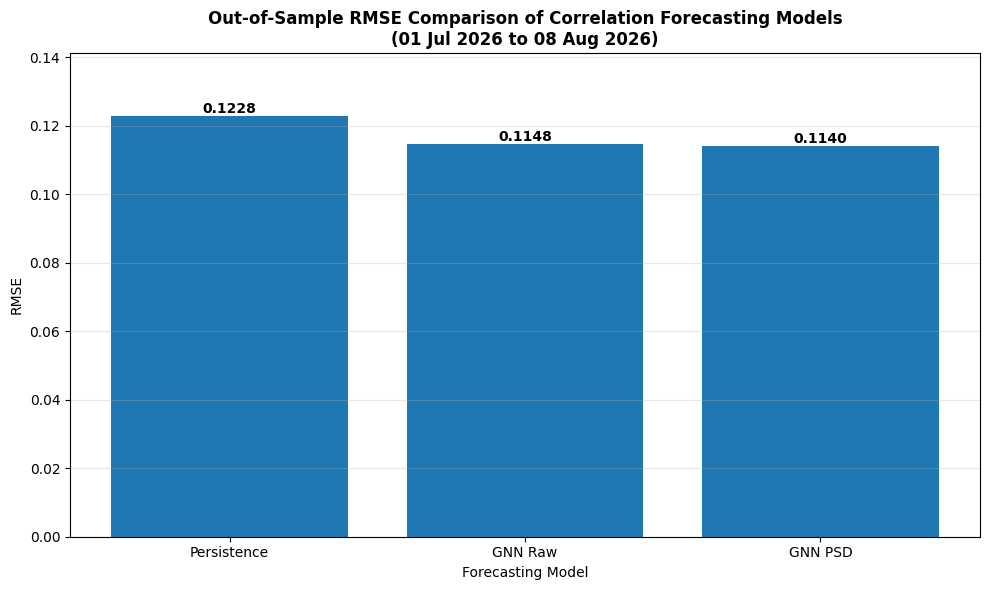

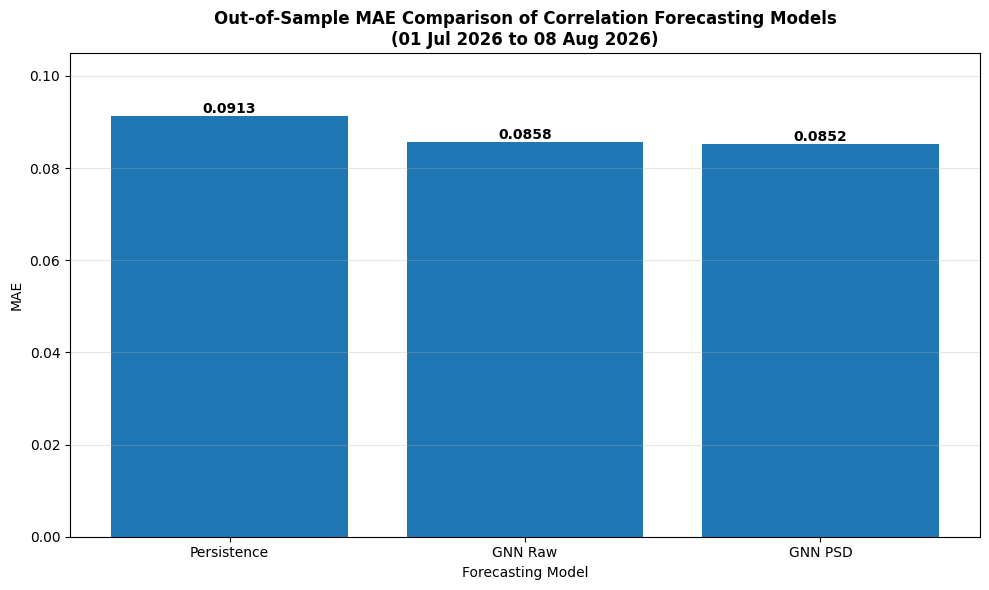

OOS GNN VS PERSISTENCE COMPARISON

Evaluation Period: 01 Jul 2026 to 08 Aug 2026

      Model     RMSE      MAE
Persistence 0.122808 0.091272
    GNN Raw 0.114782 0.085753
    GNN PSD 0.113980 0.085192


In [96]:
#====================================================
# COMPARE OOS GNN WITH PERSISTENCE BENCHMARK
#
# RMSE AND MAE COMPARISON
#====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#====================================================
# 1. CHECK REQUIRED OOS METRICS
#====================================================

required_objects = [

    "oos_persistence_metrics",

    "oos_raw_gnn_metrics",

    "oos_psd_gnn_metrics"

]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()

]


if missing_objects:

    raise NameError(

        "Missing required OOS metric objects:\n"

        +

        "\n".join(
            missing_objects
        )

        +

        "\n\nRun the OOS overall correlation "
        "forecast performance cell first."

    )


#====================================================
# 2. MODEL NAMES
#====================================================

comparison_models = [

    "Persistence",

    "GNN Raw",

    "GNN PSD"

]


#====================================================
# 3. RMSE VALUES
#====================================================

rmse_values = [

    oos_persistence_metrics[
        "RMSE"
    ],

    oos_raw_gnn_metrics[
        "RMSE"
    ],

    oos_psd_gnn_metrics[
        "RMSE"
    ]

]


#====================================================
# 4. MAE VALUES
#====================================================

mae_values = [

    oos_persistence_metrics[
        "MAE"
    ],

    oos_raw_gnn_metrics[
        "MAE"
    ],

    oos_psd_gnn_metrics[
        "MAE"
    ]

]


#====================================================
# 5. GET OOS EVALUATION PERIOD
#====================================================

if "oos_evaluation" in globals():

    oos_plot_df = (

        oos_evaluation

        .copy()

    )


    oos_plot_df[
        "Target_Date"
    ] = pd.to_datetime(

        oos_plot_df[
            "Target_Date"
        ]

    )


    evaluation_start = (

        oos_plot_df[
            "Target_Date"
        ]

        .min()

    )


    evaluation_end = (

        oos_plot_df[
            "Target_Date"
        ]

        .max()

    )


    period_text = (

        f"{evaluation_start.strftime('%d %b %Y')} "
        f"to "
        f"{evaluation_end.strftime('%d %b %Y')}"

    )


else:

    period_text = "OOS Evaluation Period"


#====================================================
# 6. RMSE COMPARISON
#====================================================

plt.figure(
    figsize=(10,6)
)


bars = plt.bar(

    comparison_models,

    rmse_values

)


#====================================================
# TITLE
#====================================================

plt.title(

    "Out-of-Sample RMSE Comparison of Correlation Forecasting Models\n"
    f"({period_text})",

    fontweight="bold"

)


plt.xlabel(
    "Forecasting Model"
)


plt.ylabel(
    "RMSE"
)


#====================================================
# ADD VALUES ABOVE BARS
#====================================================

for bar, value in zip(

    bars,

    rmse_values

):

    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height(),

        f"{value:.4f}",

        ha="center",

        va="bottom",

        fontweight="bold"

    )


#====================================================
# ADD SPACE ABOVE BARS
#====================================================

plt.ylim(

    0,

    max(rmse_values) * 1.15

)


plt.grid(

    axis="y",

    alpha=0.30

)


plt.tight_layout()

plt.show()


#====================================================
# 7. MAE COMPARISON
#====================================================

plt.figure(
    figsize=(10,6)
)


bars = plt.bar(

    comparison_models,

    mae_values

)


#====================================================
# TITLE
#====================================================

plt.title(

    "Out-of-Sample MAE Comparison of Correlation Forecasting Models\n"
    f"({period_text})",

    fontweight="bold"

)


plt.xlabel(
    "Forecasting Model"
)


plt.ylabel(
    "MAE"
)


#====================================================
# ADD VALUES ABOVE BARS
#====================================================

for bar, value in zip(

    bars,

    mae_values

):

    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height(),

        f"{value:.4f}",

        ha="center",

        va="bottom",

        fontweight="bold"

    )


#====================================================
# ADD SPACE ABOVE BARS
#====================================================

plt.ylim(

    0,

    max(mae_values) * 1.15

)


plt.grid(

    axis="y",

    alpha=0.30

)


plt.tight_layout()

plt.show()


#====================================================
# 8. PRINT VALUES
#====================================================

comparison_table = pd.DataFrame({

    "Model":

        comparison_models,

    "RMSE":

        rmse_values,

    "MAE":

        mae_values

})


print(
    "=" * 70
)

print(
    "OOS GNN VS PERSISTENCE COMPARISON"
)

print(
    "=" * 70
)


print(

    "\nEvaluation Period:",

    period_text

)


print(
    "\n"
    +
    comparison_table

    .round(6)

    .to_string(
        index=False
    )

)

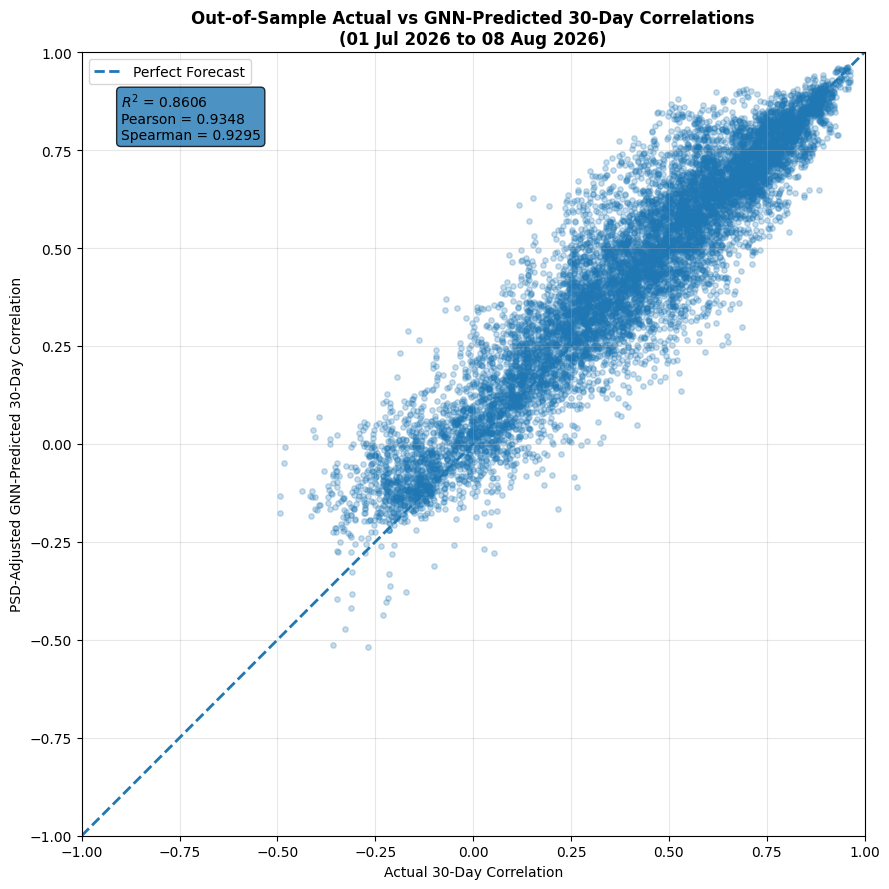

OOS ACTUAL VS PSD-ADJUSTED GNN CORRELATION

Evaluation Period: 2026-07-01 to 2026-08-08
Number of Pair Forecasts: 10764

R²       : 0.860558
Pearson  : 0.934824
Spearman : 0.929501


In [97]:
#====================================================
# OOS ACTUAL VS PSD-ADJUSTED GNN CORRELATION
#====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
from scipy.stats import pearsonr, spearmanr


#====================================================
# 1. CHECK OOS EVALUATION DATA
#====================================================

if "oos_evaluation" not in globals():

    raise NameError(

        "oos_evaluation does not exist. "
        "Run the OOS evaluation cell first."

    )


#====================================================
# 2. REQUIRED COLUMNS
#====================================================

required_columns = [

    "Target_Date",

    "Actual_Correlation",

    "PSD_Predicted_Correlation"

]


missing_columns = [

    column

    for column in required_columns

    if column not in oos_evaluation.columns

]


if missing_columns:

    raise ValueError(

        "Missing required columns in "
        "oos_evaluation:\n"

        +

        "\n".join(
            missing_columns
        )

    )


#====================================================
# 3. PREPARE PLOTTING DATA
#====================================================

oos_scatter_df = (

    oos_evaluation

    .copy()

)


oos_scatter_df[
    "Target_Date"
] = pd.to_datetime(

    oos_scatter_df[
        "Target_Date"
    ]

)


#====================================================
# REMOVE INVALID VALUES
#====================================================

oos_scatter_df = (

    oos_scatter_df

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .dropna(

        subset=[

            "Actual_Correlation",

            "PSD_Predicted_Correlation"

        ]

    )

    .copy()

)


if oos_scatter_df.empty:

    raise ValueError(

        "No valid OOS observations "
        "are available for plotting."

    )


#====================================================
# 4. EXTRACT VALUES
#====================================================

actual = (

    oos_scatter_df[
        "Actual_Correlation"
    ]

    .to_numpy(
        dtype=float
    )

)


psd_predicted = (

    oos_scatter_df[
        "PSD_Predicted_Correlation"
    ]

    .to_numpy(
        dtype=float
    )

)


#====================================================
# 5. CALCULATE PERFORMANCE STATISTICS
#====================================================

oos_r2 = r2_score(

    actual,

    psd_predicted

)


oos_pearson = pearsonr(

    actual,

    psd_predicted

)[0]


oos_spearman = spearmanr(

    actual,

    psd_predicted

)[0]


#====================================================
# 6. GET OOS EVALUATION PERIOD
#====================================================

evaluation_start = (

    oos_scatter_df[
        "Target_Date"
    ]

    .min()

)


evaluation_end = (

    oos_scatter_df[
        "Target_Date"
    ]

    .max()

)


period_text = (

    f"{evaluation_start.strftime('%d %b %Y')} "
    f"to "
    f"{evaluation_end.strftime('%d %b %Y')}"

)


#====================================================
# 7. CREATE SCATTER PLOT
#====================================================

plt.figure(
    figsize=(9,9)
)


plt.scatter(

    actual,

    psd_predicted,

    alpha=0.25,

    s=15

)


#====================================================
# 8. PERFECT FORECAST LINE
#
# y = x
#====================================================

plt.plot(

    [-1, 1],

    [-1, 1],

    linestyle="--",

    linewidth=2,

    label="Perfect Forecast"

)


#====================================================
# 9. ADD PERFORMANCE STATISTICS
#====================================================

statistics_text = (

    f"$R^2$ = {oos_r2:.4f}\n"
    f"Pearson = {oos_pearson:.4f}\n"
    f"Spearman = {oos_spearman:.4f}"

)


plt.text(

    0.05,

    0.95,

    statistics_text,

    transform=plt.gca().transAxes,

    verticalalignment="top",

    bbox=dict(
        boxstyle="round",
        alpha=0.80
    )

)


#====================================================
# 10. LABELS
#====================================================

plt.xlabel(
    "Actual 30-Day Correlation"
)


plt.ylabel(
    "PSD-Adjusted GNN-Predicted 30-Day Correlation"
)


plt.title(

    "Out-of-Sample Actual vs GNN-Predicted 30-Day Correlations\n"
    f"({period_text})",

    fontweight="bold"

)


#====================================================
# 11. AXIS LIMITS
#====================================================

plt.xlim(
    -1,
    1
)


plt.ylim(
    -1,
    1
)


#====================================================
# 12. GRID AND LEGEND
#====================================================

plt.grid(
    alpha=0.30
)


plt.legend()


plt.tight_layout()

plt.show()


#====================================================
# 13. PRINT FIGURE INFORMATION
#====================================================

print(
    "=" * 70
)

print(
    "OOS ACTUAL VS PSD-ADJUSTED GNN CORRELATION"
)

print(
    "=" * 70
)


print(

    "\nEvaluation Period:",

    evaluation_start.date(),

    "to",

    evaluation_end.date()

)


print(

    "Number of Pair Forecasts:",

    len(
        oos_scatter_df
    )

)


print(
    f"\nR²       : {oos_r2:.6f}"
)

print(
    f"Pearson  : {oos_pearson:.6f}"
)

print(
    f"Spearman : {oos_spearman:.6f}"
)

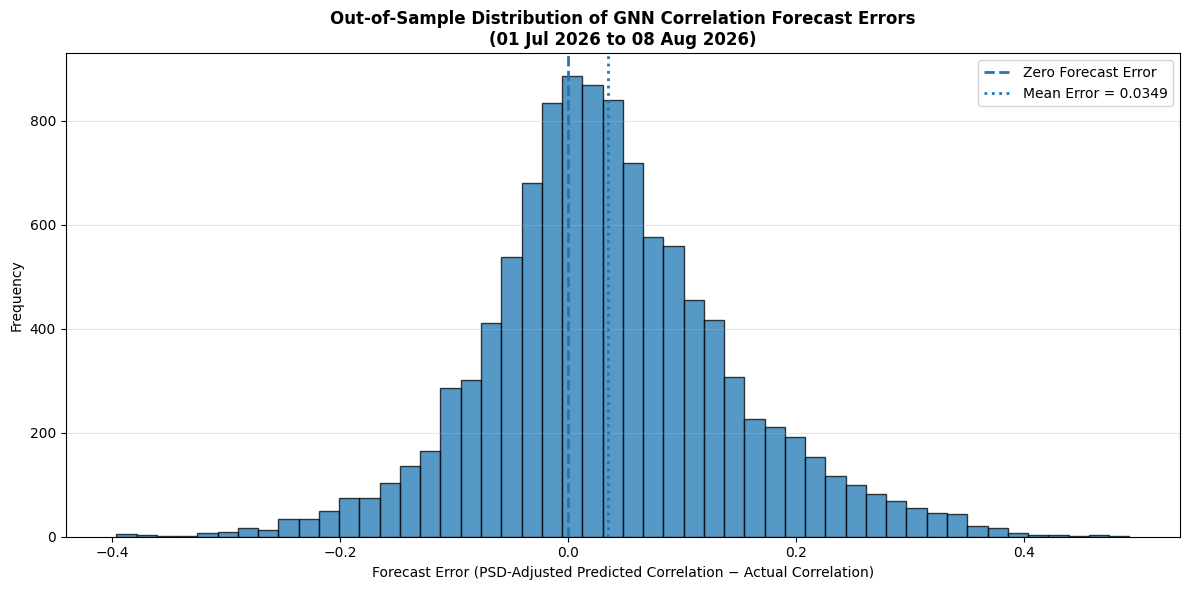

OOS GNN CORRELATION FORECAST ERROR DISTRIBUTION

Evaluation Period: 2026-07-01 to 2026-08-08
Number of Pair Forecasts: 10764

Mean Error   : 0.034914
Median Error : 0.026539
Std. Error   : 0.108506
Mean Bias    : Overprediction


In [98]:
#====================================================
# OOS GNN FORECAST ERROR DISTRIBUTION
#
# Forecast Error:
# Predicted Correlation - Actual Correlation
#
# Positive Error = Overprediction
# Negative Error = Underprediction
#====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#====================================================
# 1. CHECK OOS EVALUATION DATA
#====================================================

if "oos_evaluation" not in globals():

    raise NameError(

        "oos_evaluation does not exist. "
        "Run the OOS evaluation cell first."

    )


#====================================================
# 2. REQUIRED COLUMNS
#====================================================

required_columns = [

    "Target_Date",

    "Actual_Correlation",

    "PSD_Predicted_Correlation"

]


missing_columns = [

    column

    for column in required_columns

    if column not in oos_evaluation.columns

]


if missing_columns:

    raise ValueError(

        "Missing required columns in "
        "oos_evaluation:\n"

        +

        "\n".join(
            missing_columns
        )

    )


#====================================================
# 3. COPY OOS DATA
#====================================================

oos_error_df = (

    oos_evaluation

    .copy()

)


#====================================================
# DATE FORMAT
#====================================================

oos_error_df[
    "Target_Date"
] = pd.to_datetime(

    oos_error_df[
        "Target_Date"
    ]

)


#====================================================
# 4. REMOVE INVALID VALUES
#====================================================

oos_error_df = (

    oos_error_df

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .dropna(

        subset=[

            "Actual_Correlation",

            "PSD_Predicted_Correlation"

        ]

    )

    .copy()

)


if oos_error_df.empty:

    raise ValueError(

        "No valid OOS observations "
        "are available for error analysis."

    )


#====================================================
# 5. CALCULATE PSD GNN FORECAST ERROR
#
# Error = Predicted - Actual
#====================================================

oos_error_df[
    "PSD_Forecast_Error"
] = (

    oos_error_df[
        "PSD_Predicted_Correlation"
    ]

    -

    oos_error_df[
        "Actual_Correlation"
    ]

)


#====================================================
# OPTIONAL:
# ALSO STORE ERROR IN oos_evaluation
# FOR LATER FIGURES
#====================================================

oos_evaluation[
    "PSD_Forecast_Error"
] = (

    oos_evaluation[
        "PSD_Predicted_Correlation"
    ]

    -

    oos_evaluation[
        "Actual_Correlation"
    ]

)


#====================================================
# 6. CALCULATE ERROR STATISTICS
#====================================================

mean_error = (

    oos_error_df[
        "PSD_Forecast_Error"
    ]

    .mean()

)


median_error = (

    oos_error_df[
        "PSD_Forecast_Error"
    ]

    .median()

)


error_std = (

    oos_error_df[
        "PSD_Forecast_Error"
    ]

    .std()

)


#====================================================
# 7. GET OOS EVALUATION PERIOD
#====================================================

evaluation_start = (

    oos_error_df[
        "Target_Date"
    ]

    .min()

)


evaluation_end = (

    oos_error_df[
        "Target_Date"
    ]

    .max()

)


period_text = (

    f"{evaluation_start.strftime('%d %b %Y')} "
    f"to "
    f"{evaluation_end.strftime('%d %b %Y')}"

)


#====================================================
# 8. CREATE HISTOGRAM
#====================================================

plt.figure(
    figsize=(12,6)
)


plt.hist(

    oos_error_df[
        "PSD_Forecast_Error"
    ],

    bins=50,

    alpha=0.75,

    edgecolor="black"

)


#====================================================
# 9. ZERO ERROR LINE
#====================================================

plt.axvline(

    x=0,

    linestyle="--",

    linewidth=2,

    label="Zero Forecast Error"

)


#====================================================
# 10. MEAN ERROR LINE
#====================================================

plt.axvline(

    x=mean_error,

    linestyle=":",

    linewidth=2,

    label=(
        f"Mean Error = "
        f"{mean_error:.4f}"
    )

)


#====================================================
# 11. TITLE AND LABELS
#====================================================

plt.title(

    "Out-of-Sample Distribution of GNN Correlation Forecast Errors\n"
    f"({period_text})",

    fontweight="bold"

)


plt.xlabel(

    "Forecast Error "
    "(PSD-Adjusted Predicted Correlation − Actual Correlation)"

)


plt.ylabel(
    "Frequency"
)


#====================================================
# 12. GRID AND LEGEND
#====================================================

plt.grid(

    axis="y",

    alpha=0.30

)


plt.legend()


plt.tight_layout()

plt.show()


#====================================================
# 13. PRINT ERROR STATISTICS
#====================================================

print(
    "=" * 75
)

print(
    "OOS GNN CORRELATION FORECAST ERROR DISTRIBUTION"
)

print(
    "=" * 75
)


print(

    "\nEvaluation Period:",

    evaluation_start.date(),

    "to",

    evaluation_end.date()

)


print(

    "Number of Pair Forecasts:",

    len(
        oos_error_df
    )

)


print(
    f"\nMean Error   : {mean_error:.6f}"
)


print(
    f"Median Error : {median_error:.6f}"
)


print(
    f"Std. Error   : {error_std:.6f}"
)


#====================================================
# 14. INTERPRET MEAN ERROR DIRECTION
#====================================================

if mean_error > 0:

    print(
        "Mean Bias    : Overprediction"
    )

elif mean_error < 0:

    print(
        "Mean Bias    : Underprediction"
    )

else:

    print(
        "Mean Bias    : No average bias"
    )

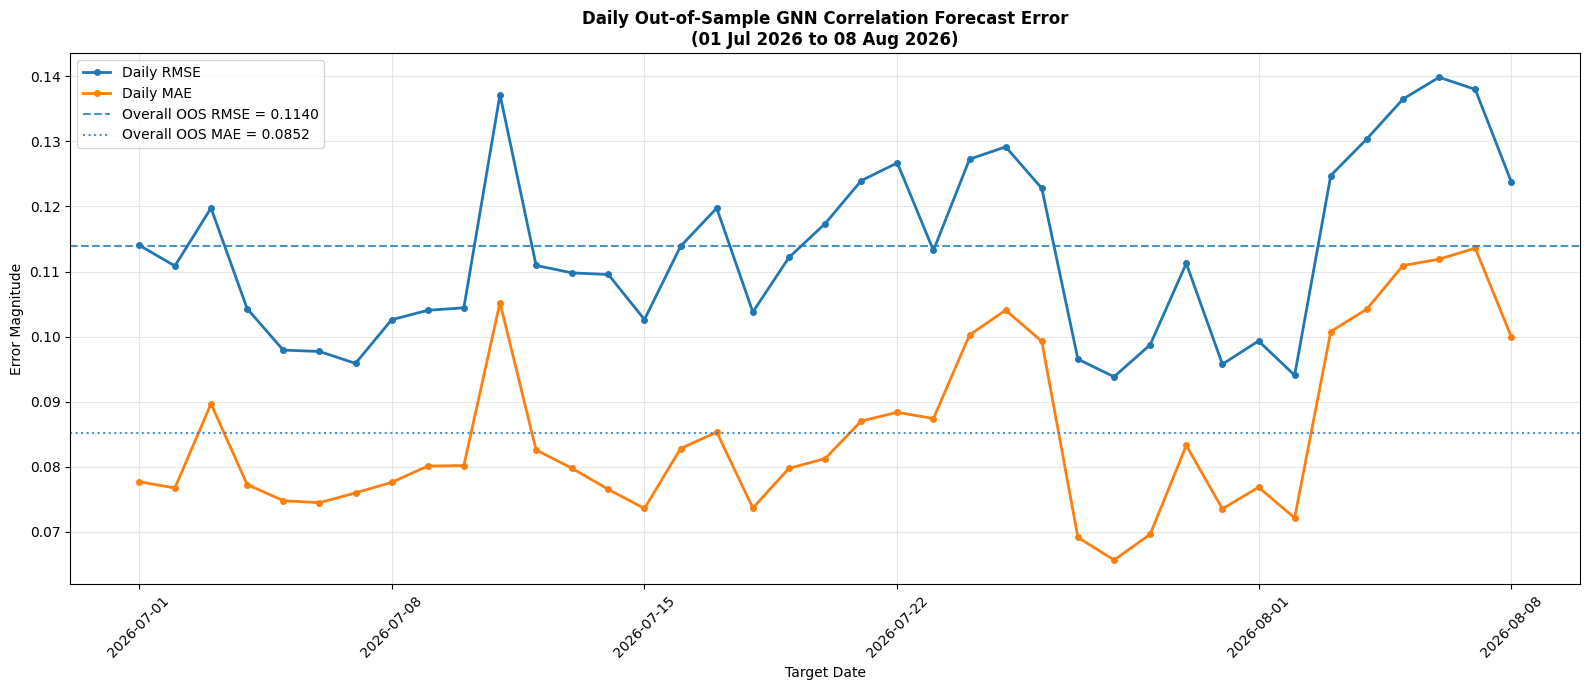

DAILY OOS GNN CORRELATION FORECAST ERROR

Evaluation Period: 2026-07-01 to 2026-08-08
Number of Evaluation Dates: 39
Expected Pairs per Date: 276
Total Pair Forecasts: 10764

Overall OOS RMSE: 0.113980
Overall OOS MAE : 0.085192

DAILY RMSE RANGE
Highest Daily RMSE: 2026-08-06 (0.139855)
Lowest Daily RMSE : 2026-07-28 (0.093818)

DAILY ERROR STATISTICS
Target_Date      MAE     RMSE  Mean_Error  Pair_Count
 2026-07-01 0.077699 0.114081   -0.013093         276
 2026-07-02 0.076718 0.110851   -0.008051         276
 2026-07-03 0.089670 0.119756   -0.037545         276
 2026-07-04 0.077256 0.104291   -0.038692         276
 2026-07-05 0.074775 0.097920    0.013045         276
 2026-07-06 0.074461 0.097710   -0.002994         276
 2026-07-07 0.075968 0.095876    0.008753         276
 2026-07-08 0.077589 0.102593    0.030903         276
 2026-07-09 0.080094 0.104032    0.017656         276
 2026-07-10 0.080174 0.104423    0.032955         276
 2026-07-11 0.105228 0.137202    0.076020         2

In [99]:
#====================================================
# DAILY OOS GNN FORECAST ERROR OVER TIME
#
# PSD-Adjusted GNN Correlation Forecasts
#
# Forecast Error:
# Predicted Correlation - Actual Correlation
#====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#====================================================
# 1. CHECK OOS EVALUATION DATA
#====================================================

if "oos_evaluation" not in globals():

    raise NameError(

        "oos_evaluation does not exist. "
        "Run the OOS evaluation cell first."

    )


#====================================================
# 2. REQUIRED COLUMNS
#====================================================

required_columns = [

    "Target_Date",

    "Actual_Correlation",

    "PSD_Predicted_Correlation"

]


missing_columns = [

    column

    for column in required_columns

    if column not in oos_evaluation.columns

]


if missing_columns:

    raise ValueError(

        "Missing required columns in "
        "oos_evaluation:\n"

        +

        "\n".join(
            missing_columns
        )

    )


#====================================================
# 3. COPY OOS EVALUATION DATA
#====================================================

oos_daily_df = (

    oos_evaluation

    .copy()

)


#====================================================
# CONVERT TARGET DATE
#====================================================

oos_daily_df[
    "Target_Date"
] = pd.to_datetime(

    oos_daily_df[
        "Target_Date"
    ]

)


#====================================================
# 4. REMOVE INVALID OBSERVATIONS
#====================================================

oos_daily_df = (

    oos_daily_df

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .dropna(

        subset=[

            "Target_Date",

            "Actual_Correlation",

            "PSD_Predicted_Correlation"

        ]

    )

    .copy()

)


if oos_daily_df.empty:

    raise ValueError(

        "No valid OOS observations are "
        "available for daily error analysis."

    )


#====================================================
# 5. CALCULATE PSD-ADJUSTED GNN FORECAST ERROR
#
# Error = Predicted - Actual
#
# Positive = Overprediction
# Negative = Underprediction
#====================================================

oos_daily_df[
    "PSD_Forecast_Error"
] = (

    oos_daily_df[
        "PSD_Predicted_Correlation"
    ]

    -

    oos_daily_df[
        "Actual_Correlation"
    ]

)


#====================================================
# 6. CALCULATE DAILY ERROR METRICS
#
# For each Target_Date:
#
# MAE  = Mean absolute error across 276 pairs
# RMSE = Root mean squared error across 276 pairs
#====================================================

oos_daily_error = (

    oos_daily_df

    .groupby(
        "Target_Date"
    )

    .agg(

        MAE=(

            "PSD_Forecast_Error",

            lambda x:
                np.mean(
                    np.abs(x)
                )

        ),

        RMSE=(

            "PSD_Forecast_Error",

            lambda x:
                np.sqrt(
                    np.mean(
                        np.square(x)
                    )
                )

        ),

        Mean_Error=(

            "PSD_Forecast_Error",

            "mean"

        ),

        Pair_Count=(

            "PSD_Forecast_Error",

            "count"

        )

    )

    .reset_index()

)


#====================================================
# 7. SORT BY TARGET DATE
#====================================================

oos_daily_error = (

    oos_daily_error

    .sort_values(
        "Target_Date"
    )

    .reset_index(
        drop=True
    )

)


#====================================================
# 8. CHECK NUMBER OF PAIRS PER DATE
#
# 24 cryptocurrencies:
#
# 24 × 23 / 2 = 276 unique pairs
#====================================================

expected_pairs = (

    len(GNN_TICKERS)

    *

    (
        len(GNN_TICKERS) - 1
    )

    //

    2

)


invalid_pair_dates = (

    oos_daily_error[

        oos_daily_error[
            "Pair_Count"
        ]

        !=

        expected_pairs

    ]

)


if not invalid_pair_dates.empty:

    print(

        "WARNING: Some OOS target dates "
        f"do not contain exactly "
        f"{expected_pairs} cryptocurrency pairs."

    )

    print(

        invalid_pair_dates[
            [
                "Target_Date",
                "Pair_Count"
            ]
        ]

    )


#====================================================
# 9. CALCULATE OVERALL OOS RMSE AND MAE
#
# Used as reference lines in the plot
#====================================================

overall_oos_rmse = np.sqrt(

    np.mean(

        np.square(

            oos_daily_df[
                "PSD_Forecast_Error"
            ]

        )

    )

)


overall_oos_mae = np.mean(

    np.abs(

        oos_daily_df[
            "PSD_Forecast_Error"
        ]

    )

)


#====================================================
# 10. GET OOS EVALUATION PERIOD
#====================================================

evaluation_start = (

    oos_daily_error[
        "Target_Date"
    ]

    .min()

)


evaluation_end = (

    oos_daily_error[
        "Target_Date"
    ]

    .max()

)


period_text = (

    f"{evaluation_start.strftime('%d %b %Y')} "
    f"to "
    f"{evaluation_end.strftime('%d %b %Y')}"

)


#====================================================
# 11. CREATE FIGURE
#====================================================

plt.figure(
    figsize=(16,7)
)


#====================================================
# DAILY RMSE
#====================================================

plt.plot(

    oos_daily_error[
        "Target_Date"
    ],

    oos_daily_error[
        "RMSE"
    ],

    linewidth=2,

    marker="o",

    markersize=4,

    label="Daily RMSE"

)


#====================================================
# DAILY MAE
#====================================================

plt.plot(

    oos_daily_error[
        "Target_Date"
    ],

    oos_daily_error[
        "MAE"
    ],

    linewidth=2,

    marker="o",

    markersize=4,

    label="Daily MAE"

)


#====================================================
# 12. OVERALL OOS RMSE REFERENCE LINE
#====================================================

plt.axhline(

    y=overall_oos_rmse,

    linestyle="--",

    linewidth=1.5,

    alpha=0.8,

    label=(
        f"Overall OOS RMSE = "
        f"{overall_oos_rmse:.4f}"
    )

)


#====================================================
# 13. OVERALL OOS MAE REFERENCE LINE
#====================================================

plt.axhline(

    y=overall_oos_mae,

    linestyle=":",

    linewidth=1.5,

    alpha=0.8,

    label=(
        f"Overall OOS MAE = "
        f"{overall_oos_mae:.4f}"
    )

)


#====================================================
# 14. TITLE AND AXIS LABELS
#====================================================

plt.title(

    "Daily Out-of-Sample GNN Correlation Forecast Error\n"
    f"({period_text})",

    fontweight="bold"

)


plt.xlabel(
    "Target Date"
)


plt.ylabel(
    "Error Magnitude"
)


#====================================================
# 15. GRID AND LEGEND
#====================================================

plt.grid(
    alpha=0.30
)


plt.legend()


#====================================================
# ROTATE DATE LABELS
#====================================================

plt.xticks(
    rotation=45
)


plt.tight_layout()

plt.show()


#====================================================
# 16. PRINT SUMMARY
#====================================================

print(
    "=" * 80
)

print(
    "DAILY OOS GNN CORRELATION FORECAST ERROR"
)

print(
    "=" * 80
)


print(

    "\nEvaluation Period:",

    evaluation_start.date(),

    "to",

    evaluation_end.date()

)


print(

    "Number of Evaluation Dates:",

    oos_daily_error[
        "Target_Date"
    ].nunique()

)


print(

    "Expected Pairs per Date:",

    expected_pairs

)


print(

    "Total Pair Forecasts:",

    len(
        oos_daily_df
    )

)


print(

    f"\nOverall OOS RMSE: "
    f"{overall_oos_rmse:.6f}"

)


print(

    f"Overall OOS MAE : "
    f"{overall_oos_mae:.6f}"

)


#====================================================
# 17. HIGHEST AND LOWEST DAILY RMSE
#====================================================

highest_rmse_row = (

    oos_daily_error

    .loc[

        oos_daily_error[
            "RMSE"
        ].idxmax()

    ]

)


lowest_rmse_row = (

    oos_daily_error

    .loc[

        oos_daily_error[
            "RMSE"
        ].idxmin()

    ]

)


print(
    "\n"
    +
    "=" * 80
)

print(
    "DAILY RMSE RANGE"
)

print(
    "=" * 80
)


print(

    "Highest Daily RMSE:",

    highest_rmse_row[
        "Target_Date"
    ].date(),

    f"({highest_rmse_row['RMSE']:.6f})"

)


print(

    "Lowest Daily RMSE :",

    lowest_rmse_row[
        "Target_Date"
    ].date(),

    f"({lowest_rmse_row['RMSE']:.6f})"

)


#====================================================
# 18. PRINT DAILY ERROR TABLE
#====================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "DAILY ERROR STATISTICS"
)

print(
    "=" * 80
)


print(

    oos_daily_error

    .round(6)

    .to_string(
        index=False
    )

)

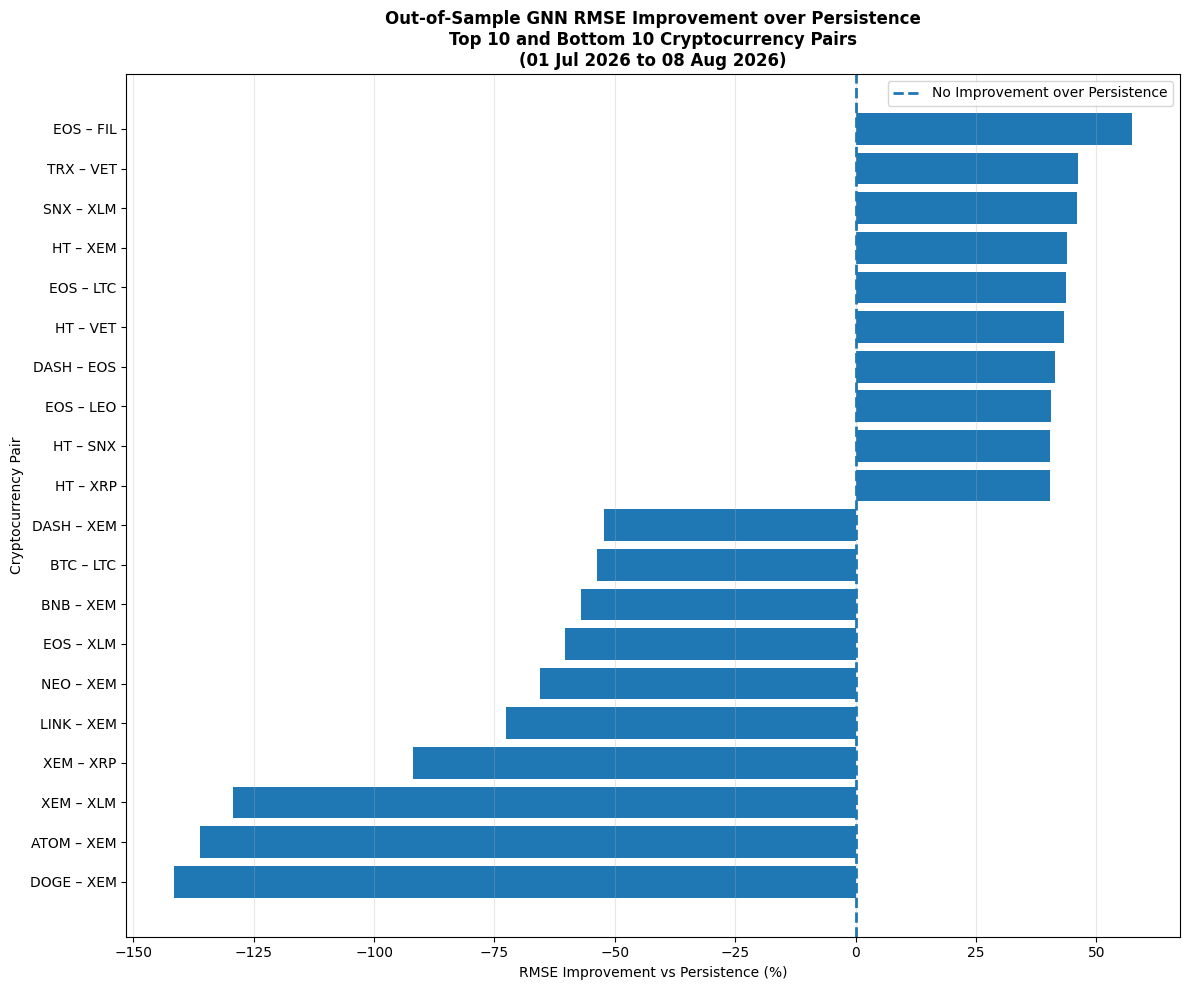

OOS PAIR-LEVEL GNN IMPROVEMENT VS PERSISTENCE

Evaluation Period: 01 Jul 2026 to 08 Aug 2026
Total Cryptocurrency Pairs: 276
GNN Better than Persistence: 183
GNN Worse than Persistence: 93
Equal Performance: 0
Percentage of Pairs Improved: 66.30%

TOP 10 PAIRS — LARGEST GNN RMSE IMPROVEMENT
      Pair  GNN_RMSE  Persistence_RMSE  RMSE_Improvement_vs_Persistence_%
 EOS – FIL  0.049009          0.115071                          57.409915
 TRX – VET  0.088267          0.164190                          46.240884
 SNX – XLM  0.065209          0.120699                          45.974154
  HT – XEM  0.081321          0.144806                          43.841548
 EOS – LTC  0.076403          0.135901                          43.780274
  HT – VET  0.073084          0.128956                          43.326504
DASH – EOS  0.089442          0.152794                          41.462224
 EOS – LEO  0.059094          0.099601                          40.669012
  HT – SNX  0.049851          0.083720    

In [100]:
#====================================================
# OOS PAIR-LEVEL GNN IMPROVEMENT VS PERSISTENCE
#
# Compare PSD-Adjusted GNN against Persistence
# using pair-level RMSE
#====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#====================================================
# 1. CHECK OOS PAIR-LEVEL RESULTS
#====================================================

if "oos_pair_metrics" not in globals():

    raise NameError(

        "oos_pair_metrics does not exist. "
        "Run the OOS pair-level evaluation cell first."

    )


#====================================================
# 2. REQUIRED COLUMNS
#====================================================

required_columns = [

    "Ticker_1",

    "Ticker_2",

    "GNN_RMSE",

    "Persistence_RMSE",

    "RMSE_Improvement_vs_Persistence_%"

]


missing_columns = [

    column

    for column in required_columns

    if column not in oos_pair_metrics.columns

]


if missing_columns:

    raise ValueError(

        "Missing required columns in "
        "oos_pair_metrics:\n"

        +

        "\n".join(
            missing_columns
        )

    )


#====================================================
# 3. COPY OOS PAIR METRICS
#====================================================

oos_pair_plot = (

    oos_pair_metrics

    .copy()

)


#====================================================
# 4. REMOVE INVALID VALUES
#====================================================

oos_pair_plot = (

    oos_pair_plot

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .dropna(

        subset=[

            "Ticker_1",

            "Ticker_2",

            "RMSE_Improvement_vs_Persistence_%"

        ]

    )

    .copy()

)


if oos_pair_plot.empty:

    raise ValueError(

        "No valid OOS pair-level results "
        "are available for plotting."

    )


#====================================================
# 5. CHECK FOR DUPLICATE PAIRS
#====================================================

duplicate_pairs = (

    oos_pair_plot

    .duplicated(

        subset=[
            "Ticker_1",
            "Ticker_2"
        ],

        keep=False

    )

)


if duplicate_pairs.any():

    raise ValueError(

        "Duplicate cryptocurrency pairs were "
        "found in oos_pair_metrics."

    )


#====================================================
# 6. CREATE CRYPTOCURRENCY PAIR LABEL
#====================================================

oos_pair_plot[
    "Pair"
] = (

    oos_pair_plot[
        "Ticker_1"
    ]

    .astype(str)

    .str.replace(
        "-USD",
        "",
        regex=False
    )

    +

    " – "

    +

    oos_pair_plot[
        "Ticker_2"
    ]

    .astype(str)

    .str.replace(
        "-USD",
        "",
        regex=False
    )

)


#====================================================
# 7. SORT BY RMSE IMPROVEMENT
#
# Positive:
# GNN RMSE < Persistence RMSE
#
# Negative:
# GNN RMSE > Persistence RMSE
#====================================================

oos_pair_plot = (

    oos_pair_plot

    .sort_values(

        "RMSE_Improvement_vs_Persistence_%",

        ascending=False

    )

    .reset_index(
        drop=True
    )

)


#====================================================
# 8. SELECT TOP 10 PAIRS
#
# Largest improvement over persistence
#====================================================

top_pairs = (

    oos_pair_plot

    .head(10)

    .copy()

)


#====================================================
# 9. SELECT BOTTOM 10 PAIRS
#
# Weakest performance relative to persistence
#====================================================

bottom_pairs = (

    oos_pair_plot

    .tail(10)

    .copy()

)


#====================================================
# 10. COMBINE TOP AND BOTTOM PAIRS
#====================================================

selected_pair_plot = pd.concat(

    [

        top_pairs,

        bottom_pairs

    ],

    ignore_index=True

)


#====================================================
# REMOVE DUPLICATES
#
# Protects against overlap if fewer than
# 20 pair observations are available.
#====================================================

selected_pair_plot = (

    selected_pair_plot

    .drop_duplicates(

        subset=[
            "Ticker_1",
            "Ticker_2"
        ]

    )

)


#====================================================
# 11. SORT FOR HORIZONTAL BAR CHART
#
# Lowest improvement appears at bottom,
# highest improvement appears at top.
#====================================================

selected_pair_plot = (

    selected_pair_plot

    .sort_values(

        "RMSE_Improvement_vs_Persistence_%",

        ascending=True

    )

    .reset_index(
        drop=True
    )

)


#====================================================
# 12. GET OOS EVALUATION PERIOD
#====================================================

if "oos_evaluation" in globals():

    oos_pair_dates = (

        oos_evaluation[
            "Target_Date"
        ]

        .pipe(
            pd.to_datetime
        )

    )


    evaluation_start = (

        oos_pair_dates

        .min()

    )


    evaluation_end = (

        oos_pair_dates

        .max()

    )


    period_text = (

        f"{evaluation_start.strftime('%d %b %Y')} "
        f"to "
        f"{evaluation_end.strftime('%d %b %Y')}"

    )


else:

    period_text = "OOS Evaluation Period"


#====================================================
# 13. VISUALIZE TOP AND BOTTOM 10 PAIRS
#====================================================

plt.figure(
    figsize=(12,10)
)


plt.barh(

    selected_pair_plot[
        "Pair"
    ],

    selected_pair_plot[
        "RMSE_Improvement_vs_Persistence_%"
    ]

)


#====================================================
# 14. ZERO IMPROVEMENT LINE
#
# Right of zero:
# GNN outperforms persistence
#
# Left of zero:
# Persistence outperforms GNN
#====================================================

plt.axvline(

    x=0,

    linestyle="--",

    linewidth=2,

    label="No Improvement over Persistence"

)


#====================================================
# 15. TITLE AND LABELS
#====================================================

plt.title(

    "Out-of-Sample GNN RMSE Improvement over Persistence\n"
    "Top 10 and Bottom 10 Cryptocurrency Pairs\n"
    f"({period_text})",

    fontweight="bold"

)


plt.xlabel(
    "RMSE Improvement vs Persistence (%)"
)


plt.ylabel(
    "Cryptocurrency Pair"
)


#====================================================
# 16. GRID AND LEGEND
#====================================================

plt.grid(

    axis="x",

    alpha=0.30

)


plt.legend()


plt.tight_layout()

plt.show()


#====================================================
# 17. OVERALL PAIR-LEVEL PERFORMANCE
#====================================================

total_pairs = len(
    oos_pair_plot
)


better_than_persistence = (

    oos_pair_plot[
        "RMSE_Improvement_vs_Persistence_%"
    ]

    > 0

).sum()


worse_than_persistence = (

    oos_pair_plot[
        "RMSE_Improvement_vs_Persistence_%"
    ]

    < 0

).sum()


equal_to_persistence = (

    oos_pair_plot[
        "RMSE_Improvement_vs_Persistence_%"
    ]

    == 0

).sum()


percentage_better = (

    100

    *

    better_than_persistence

    /

    total_pairs

)


#====================================================
# 18. PRINT SUMMARY
#====================================================

print(
    "=" * 80
)

print(
    "OOS PAIR-LEVEL GNN IMPROVEMENT VS PERSISTENCE"
)

print(
    "=" * 80
)


print(

    "\nEvaluation Period:",

    period_text

)


print(

    "Total Cryptocurrency Pairs:",

    total_pairs

)


print(

    "GNN Better than Persistence:",

    better_than_persistence

)


print(

    "GNN Worse than Persistence:",

    worse_than_persistence

)


print(

    "Equal Performance:",

    equal_to_persistence

)


print(

    f"Percentage of Pairs Improved: "
    f"{percentage_better:.2f}%"

)


#====================================================
# 19. PRINT TOP 10 PAIRS
#====================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "TOP 10 PAIRS — LARGEST GNN RMSE IMPROVEMENT"
)

print(
    "=" * 80
)


print(

    top_pairs[
        [
            "Pair",
            "GNN_RMSE",
            "Persistence_RMSE",
            "RMSE_Improvement_vs_Persistence_%"
        ]
    ]

    .round(6)

    .to_string(
        index=False
    )

)


#====================================================
# 20. PRINT BOTTOM 10 PAIRS
#====================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "BOTTOM 10 PAIRS — WEAKEST GNN PERFORMANCE"
)

print(
    "=" * 80
)


print(

    bottom_pairs[
        [
            "Pair",
            "GNN_RMSE",
            "Persistence_RMSE",
            "RMSE_Improvement_vs_Persistence_%"
        ]
    ]

    .sort_values(
        "RMSE_Improvement_vs_Persistence_%"
    )

    .round(6)

    .to_string(
        index=False
    )

)

OOS PAIR-LEVEL IMPROVEMENT HEATMAP

Number of Cryptocurrencies: 24
Expected Unique Pairs: 276
Available Pair Results: 276


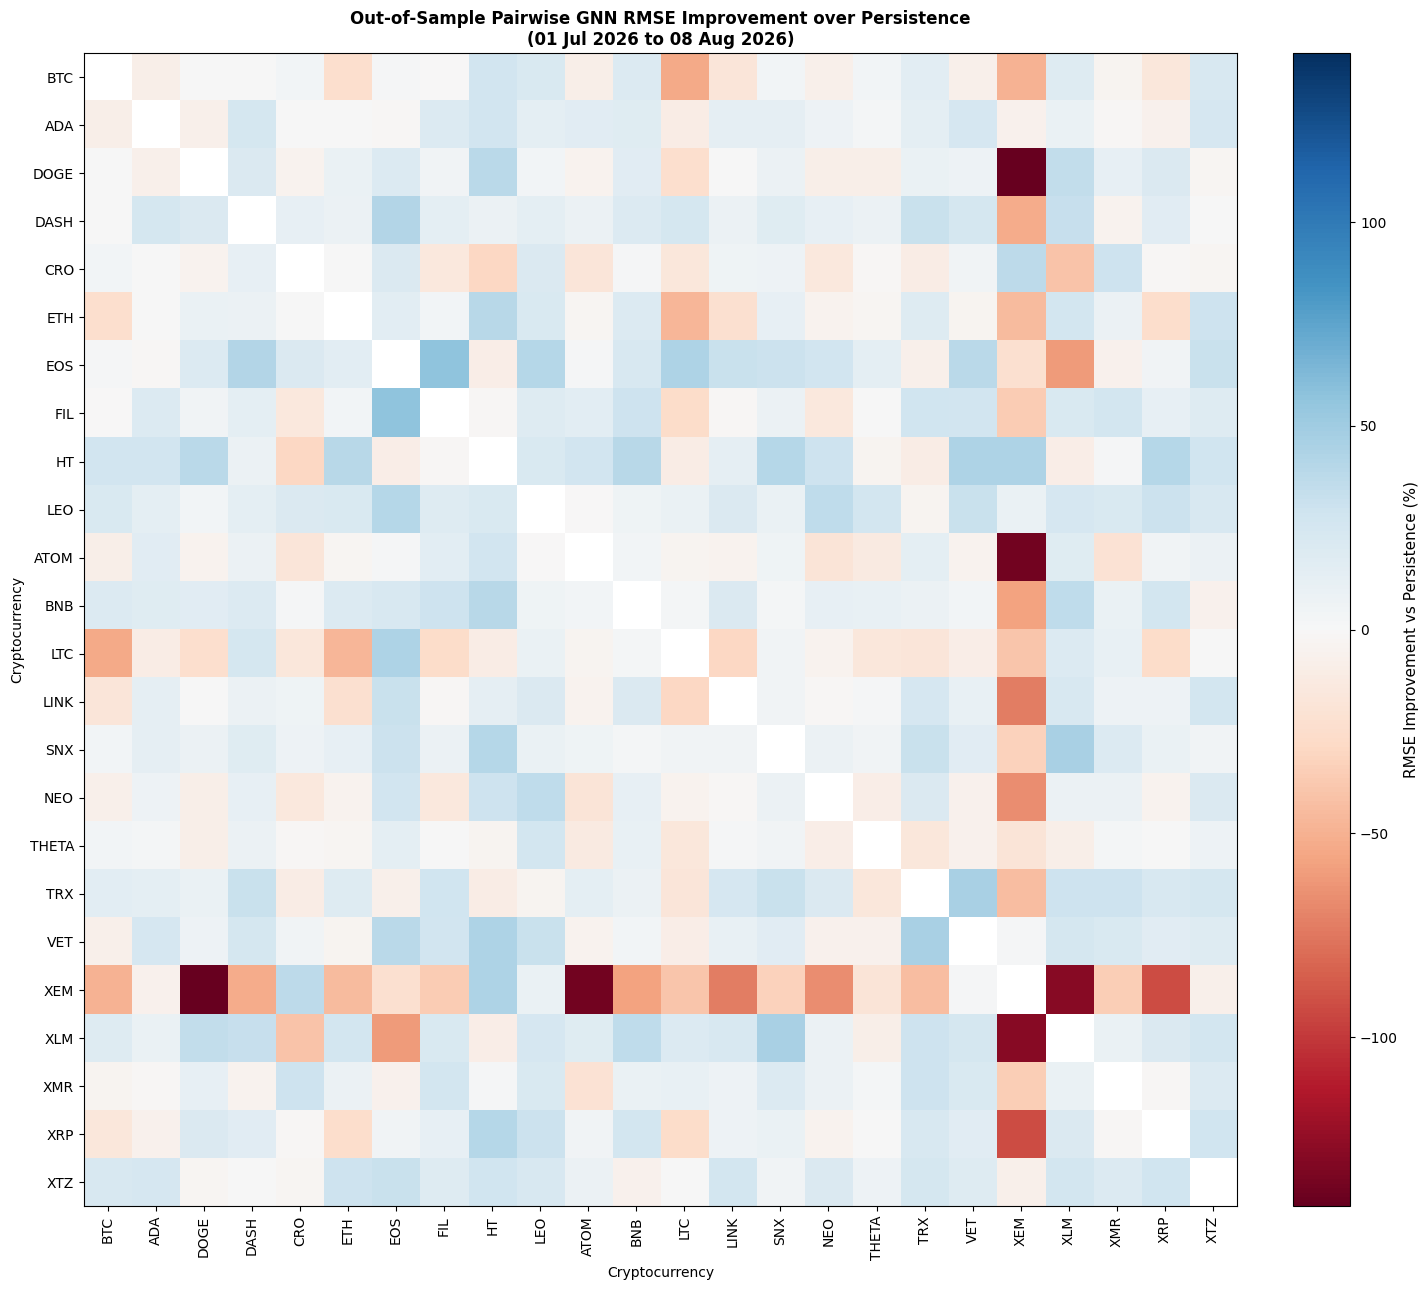


Evaluation Period: 01 Jul 2026 to 08 Aug 2026

Pairs where GNN improves on Persistence: 183
Pairs where GNN underperforms Persistence: 93
Pairs with equal performance: 0
Percentage of Pairs Improved: 66.30%

Mean RMSE Improvement: 4.4262%
Median RMSE Improvement: 7.7814%


In [101]:
#====================================================
# OOS HEATMAP OF PAIR-LEVEL GNN IMPROVEMENT
# VS PERSISTENCE
#
# Positive value:
# GNN RMSE < Persistence RMSE
#
# Negative value:
# GNN RMSE > Persistence RMSE
#====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#====================================================
# 1. CHECK REQUIRED OBJECTS
#====================================================

if "oos_pair_metrics" not in globals():

    raise NameError(

        "oos_pair_metrics does not exist. "
        "Run the OOS pair-level evaluation cell first."

    )


if "GNN_TICKERS" not in globals():

    raise NameError(

        "GNN_TICKERS does not exist."

    )


#====================================================
# 2. REQUIRED COLUMNS
#====================================================

required_columns = [

    "Ticker_1",

    "Ticker_2",

    "RMSE_Improvement_vs_Persistence_%"

]


missing_columns = [

    column

    for column in required_columns

    if column not in oos_pair_metrics.columns

]


if missing_columns:

    raise ValueError(

        "Missing required columns in "
        "oos_pair_metrics:\n"

        +

        "\n".join(
            missing_columns
        )

    )


#====================================================
# 3. COPY PAIR-LEVEL OOS RESULTS
#====================================================

oos_heatmap_df = (

    oos_pair_metrics

    .copy()

)


#====================================================
# REMOVE INVALID VALUES
#====================================================

oos_heatmap_df = (

    oos_heatmap_df

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .dropna(

        subset=[

            "Ticker_1",

            "Ticker_2",

            "RMSE_Improvement_vs_Persistence_%"

        ]

    )

    .copy()

)


#====================================================
# 4. CREATE EMPTY 24 × 24 MATRIX
#====================================================

improvement_matrix = pd.DataFrame(

    np.nan,

    index=GNN_TICKERS,

    columns=GNN_TICKERS,

    dtype=float

)


#====================================================
# 5. FILL SYMMETRIC MATRIX
#====================================================

for _, row in oos_heatmap_df.iterrows():

    coin1 = row[
        "Ticker_1"
    ]

    coin2 = row[
        "Ticker_2"
    ]

    value = row[
        "RMSE_Improvement_vs_Persistence_%"
    ]


    #================================================
    # CHECK TICKERS EXIST IN GNN UNIVERSE
    #================================================

    if (
        coin1 not in improvement_matrix.index
        or
        coin2 not in improvement_matrix.columns
    ):

        continue


    #================================================
    # UPPER TRIANGLE
    #================================================

    improvement_matrix.loc[
        coin1,
        coin2
    ] = value


    #================================================
    # LOWER TRIANGLE
    #================================================

    improvement_matrix.loc[
        coin2,
        coin1
    ] = value


#====================================================
# 6. KEEP DIAGONAL EMPTY
#
# Self-correlations are not pair forecasts.
#====================================================

matrix_values = (

    improvement_matrix

    .to_numpy(
        copy=True
    )

)


np.fill_diagonal(

    matrix_values,

    np.nan

)


#====================================================
# 7. CREATE DISPLAY LABELS
#====================================================

display_labels = [

    ticker.replace(
        "-USD",
        ""
    )

    for ticker in GNN_TICKERS

]


n_coins = len(
    GNN_TICKERS
)


#====================================================
# 8. CHECK MATRIX COVERAGE
#====================================================

expected_pairs = (

    n_coins

    *

    (
        n_coins - 1
    )

    //

    2

)


available_pairs = len(
    oos_heatmap_df
)


print(
    "=" * 75
)

print(
    "OOS PAIR-LEVEL IMPROVEMENT HEATMAP"
)

print(
    "=" * 75
)


print(

    "\nNumber of Cryptocurrencies:",

    n_coins

)


print(

    "Expected Unique Pairs:",

    expected_pairs

)


print(

    "Available Pair Results:",

    available_pairs

)


#====================================================
# 9. SET SYMMETRIC COLOUR SCALE AROUND ZERO
#
# This is important because:
#
# > 0 = GNN improvement
# < 0 = GNN deterioration
#====================================================

finite_values = (

    matrix_values[
        np.isfinite(
            matrix_values
        )
    ]

)


if len(finite_values) == 0:

    raise ValueError(

        "No finite pair-level improvement "
        "values are available for plotting."

    )


max_absolute_improvement = np.max(

    np.abs(
        finite_values
    )

)


if max_absolute_improvement == 0:

    max_absolute_improvement = 1.0


#====================================================
# 10. GET OOS EVALUATION PERIOD
#====================================================

if "oos_evaluation" in globals():

    oos_dates = pd.to_datetime(

        oos_evaluation[
            "Target_Date"
        ]

    )


    evaluation_start = (

        oos_dates

        .min()

    )


    evaluation_end = (

        oos_dates

        .max()

    )


    period_text = (

        f"{evaluation_start.strftime('%d %b %Y')} "
        f"to "
        f"{evaluation_end.strftime('%d %b %Y')}"

    )


else:

    period_text = "OOS Evaluation Period"


#====================================================
# 11. CREATE HEATMAP
#====================================================

plt.figure(
    figsize=(15,13)
)


image = plt.imshow(

    matrix_values,

    aspect="equal",

    cmap="RdBu",

    vmin=-max_absolute_improvement,

    vmax=max_absolute_improvement

)


#====================================================
# 12. COLORBAR
#====================================================

colorbar = plt.colorbar(

    image,

    fraction=0.046,

    pad=0.04

)


colorbar.set_label(

    "RMSE Improvement vs Persistence (%)",

    fontsize=11

)


#====================================================
# 13. AXIS LABELS
#====================================================

plt.xticks(

    np.arange(
        n_coins
    ),

    display_labels,

    rotation=90

)


plt.yticks(

    np.arange(
        n_coins
    ),

    display_labels

)


plt.xlabel(
    "Cryptocurrency"
)


plt.ylabel(
    "Cryptocurrency"
)


#====================================================
# 14. TITLE
#====================================================

plt.title(

    "Out-of-Sample Pairwise GNN RMSE Improvement over Persistence\n"
    f"({period_text})",

    fontweight="bold"

)


plt.tight_layout()

plt.show()


#====================================================
# 15. SUMMARY STATISTICS
#====================================================

positive_pairs = (

    oos_heatmap_df[
        "RMSE_Improvement_vs_Persistence_%"
    ]

    > 0

).sum()


negative_pairs = (

    oos_heatmap_df[
        "RMSE_Improvement_vs_Persistence_%"
    ]

    < 0

).sum()


zero_pairs = (

    oos_heatmap_df[
        "RMSE_Improvement_vs_Persistence_%"
    ]

    == 0

).sum()


percentage_improved = (

    100

    *

    positive_pairs

    /

    available_pairs

)


#====================================================
# 16. PRINT RESULTS
#====================================================

print(

    "\nEvaluation Period:",

    period_text

)


print(

    "\nPairs where GNN improves on Persistence:",

    positive_pairs

)


print(

    "Pairs where GNN underperforms Persistence:",

    negative_pairs

)


print(

    "Pairs with equal performance:",

    zero_pairs

)


print(

    f"Percentage of Pairs Improved: "
    f"{percentage_improved:.2f}%"

)


print(

    "\nMean RMSE Improvement: "
    f"{oos_heatmap_df['RMSE_Improvement_vs_Persistence_%'].mean():.4f}%"

)


print(

    "Median RMSE Improvement: "
    f"{oos_heatmap_df['RMSE_Improvement_vs_Persistence_%'].median():.4f}%"

)

In [102]:
#====================================================
# OOS ACTUAL VS PREDICTED CORRELATION MATRICES
#
# Compare:
# 1. Actual 30-Day Correlation Matrix
# 2. PSD-Adjusted GNN-Predicted 30-Day
#    Correlation Matrix
#
# Select the latest evaluable OOS Target Date
#====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#====================================================
# 1. CHECK REQUIRED OBJECTS
#====================================================

if "oos_evaluation" not in globals():

    raise NameError(

        "oos_evaluation does not exist. "
        "Run the OOS evaluation cell first."

    )


if "GNN_TICKERS" not in globals():

    raise NameError(

        "GNN_TICKERS does not exist."

    )


#====================================================
# 2. REQUIRED COLUMNS
#====================================================

required_columns = [

    "Target_Date",

    "Ticker_1",

    "Ticker_2",

    "Actual_Correlation",

    "PSD_Predicted_Correlation"

]


missing_columns = [

    column

    for column in required_columns

    if column not in oos_evaluation.columns

]


if missing_columns:

    raise ValueError(

        "Missing required columns in "
        "oos_evaluation:\n"

        +

        "\n".join(
            missing_columns
        )

    )


#====================================================
# 3. COPY OOS EVALUATION DATA
#====================================================

oos_matrix_df = (

    oos_evaluation

    .copy()

)


#====================================================
# CONVERT TARGET DATE
#====================================================

oos_matrix_df[
    "Target_Date"
] = pd.to_datetime(

    oos_matrix_df[
        "Target_Date"
    ]

)


#====================================================
# 4. REMOVE INVALID VALUES
#====================================================

oos_matrix_df = (

    oos_matrix_df

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .dropna(

        subset=[

            "Target_Date",

            "Ticker_1",

            "Ticker_2",

            "Actual_Correlation",

            "PSD_Predicted_Correlation"

        ]

    )

    .copy()

)


if oos_matrix_df.empty:

    raise ValueError(

        "No valid OOS observations are "
        "available for matrix comparison."

    )


#====================================================
# 5. NUMBER OF CRYPTOCURRENCIES AND PAIRS
#====================================================

N_COINS = len(
    GNN_TICKERS
)


expected_pairs = (

    N_COINS

    *

    (
        N_COINS - 1
    )

    //

    2

)


#====================================================
# 6. SELECT LATEST COMPLETE OOS TARGET DATE
#
# Only select dates containing all 276 pairs.
#====================================================

pair_counts_by_date = (

    oos_matrix_df

    .groupby(
        "Target_Date"
    )

    .size()

)


complete_dates = (

    pair_counts_by_date[

        pair_counts_by_date
        ==
        expected_pairs

    ]

    .index

)


if len(complete_dates) == 0:

    raise ValueError(

        "No OOS Target_Date contains all "
        f"{expected_pairs} cryptocurrency pairs."

    )


example_date = pd.Timestamp(

    max(
        complete_dates
    )

)


#====================================================
# 7. EXTRACT SELECTED DATE
#====================================================

day_prediction = (

    oos_matrix_df[

        oos_matrix_df[
            "Target_Date"
        ]

        ==

        example_date

    ]

    .copy()

)


#====================================================
# 8. CHECK FOR DUPLICATE PAIRS
#====================================================

duplicate_pairs = (

    day_prediction

    .duplicated(

        subset=[

            "Ticker_1",

            "Ticker_2"

        ],

        keep=False

    )

)


if duplicate_pairs.any():

    raise ValueError(

        "Duplicate cryptocurrency pairs were "
        f"found for {example_date.date()}."

    )


#====================================================
# 9. VERIFY NUMBER OF PAIRS
#====================================================

actual_pair_count = len(
    day_prediction
)


if actual_pair_count != expected_pairs:

    raise ValueError(

        f"Expected {expected_pairs} pairs for "
        f"{example_date.date()}, but found "
        f"{actual_pair_count}."

    )


#====================================================
# 10. CREATE ACTUAL CORRELATION MATRIX
#
# Diagonal = 1
#====================================================

actual_matrix = pd.DataFrame(

    np.eye(
        N_COINS
    ),

    index=GNN_TICKERS,

    columns=GNN_TICKERS,

    dtype=float

)


#====================================================
# 11. CREATE PSD-ADJUSTED GNN
# PREDICTED CORRELATION MATRIX
#
# Diagonal = 1
#====================================================

predicted_matrix = pd.DataFrame(

    np.eye(
        N_COINS
    ),

    index=GNN_TICKERS,

    columns=GNN_TICKERS,

    dtype=float

)


#====================================================
# 12. FILL ACTUAL AND PREDICTED MATRICES
#====================================================

for _, row in day_prediction.iterrows():

    coin1 = row[
        "Ticker_1"
    ]

    coin2 = row[
        "Ticker_2"
    ]


    #================================================
    # CHECK TICKERS
    #================================================

    if (
        coin1 not in GNN_TICKERS
        or
        coin2 not in GNN_TICKERS
    ):

        raise ValueError(

            f"Unknown cryptocurrency pair: "
            f"{coin1}, {coin2}"

        )


    #================================================
    # ACTUAL CORRELATION
    #================================================

    actual_value = float(

        row[
            "Actual_Correlation"
        ]

    )


    #================================================
    # PSD-ADJUSTED GNN PREDICTION
    #================================================

    predicted_value = float(

        row[
            "PSD_Predicted_Correlation"
        ]

    )


    #================================================
    # ACTUAL MATRIX
    #================================================

    actual_matrix.loc[
        coin1,
        coin2
    ] = actual_value


    actual_matrix.loc[
        coin2,
        coin1
    ] = actual_value


    #================================================
    # PREDICTED MATRIX
    #================================================

    predicted_matrix.loc[
        coin1,
        coin2
    ] = predicted_value


    predicted_matrix.loc[
        coin2,
        coin1
    ] = predicted_value


#====================================================
# 13. VERIFY DIAGONAL = 1
#
# Both matrices were initialized using np.eye(),
# therefore the diagonal already represents
# self-correlation and equals 1.
#====================================================

actual_diagonal = np.diag(

    actual_matrix.to_numpy()

)


predicted_diagonal = np.diag(

    predicted_matrix.to_numpy()

)


if not np.allclose(

    actual_diagonal,

    1.0,

    atol=1e-10

):

    raise ValueError(

        "Actual correlation matrix diagonal "
        "does not equal 1."

    )


if not np.allclose(

    predicted_diagonal,

    1.0,

    atol=1e-10

):

    raise ValueError(

        "Predicted correlation matrix diagonal "
        "does not equal 1."

    )


print(
    "Actual matrix diagonal = 1: True"
)

print(
    "Predicted matrix diagonal = 1: True"
)


#====================================================
# 14. CHECK MATRIX SYMMETRY
#====================================================

actual_symmetric = np.allclose(

    actual_matrix.values,

    actual_matrix.values.T,

    atol=1e-10

)


predicted_symmetric = np.allclose(

    predicted_matrix.values,

    predicted_matrix.values.T,

    atol=1e-10

)


#====================================================
# 15. CHECK PSD OF PREDICTED MATRIX
#====================================================

predicted_eigenvalues = np.linalg.eigvalsh(

    predicted_matrix.values

)


minimum_eigenvalue = (

    predicted_eigenvalues.min()

)


predicted_is_psd = (

    minimum_eigenvalue >= -1e-8

)


#====================================================
# 16. CREATE DISPLAY LABELS
#====================================================

display_labels = [

    ticker.replace(
        "-USD",
        ""
    )

    for ticker in GNN_TICKERS

]


#====================================================
# 17. PRINT MATRIX INFORMATION
#====================================================

print(
    "=" * 80
)

print(
    "OOS ACTUAL VS PSD-ADJUSTED GNN CORRELATION MATRICES"
)

print(
    "=" * 80
)


print(

    "\nSelected Target Date:",

    example_date.date()

)


print(

    "Number of Cryptocurrencies:",

    N_COINS

)


print(

    "Expected Unique Pairs:",

    expected_pairs

)


print(

    "Available Unique Pairs:",

    actual_pair_count

)


print(

    "\nActual Matrix Symmetric:",

    actual_symmetric

)


print(

    "Predicted Matrix Symmetric:",

    predicted_symmetric

)


print(

    "Predicted Matrix PSD:",

    predicted_is_psd

)


print(

    "Minimum Predicted Eigenvalue:",

    f"{minimum_eigenvalue:.10f}"

)

Actual matrix diagonal = 1: True
Predicted matrix diagonal = 1: True
OOS ACTUAL VS PSD-ADJUSTED GNN CORRELATION MATRICES

Selected Target Date: 2026-08-08
Number of Cryptocurrencies: 24
Expected Unique Pairs: 276
Available Unique Pairs: 276

Actual Matrix Symmetric: True
Predicted Matrix Symmetric: True
Predicted Matrix PSD: True
Minimum Predicted Eigenvalue: 0.0000000100


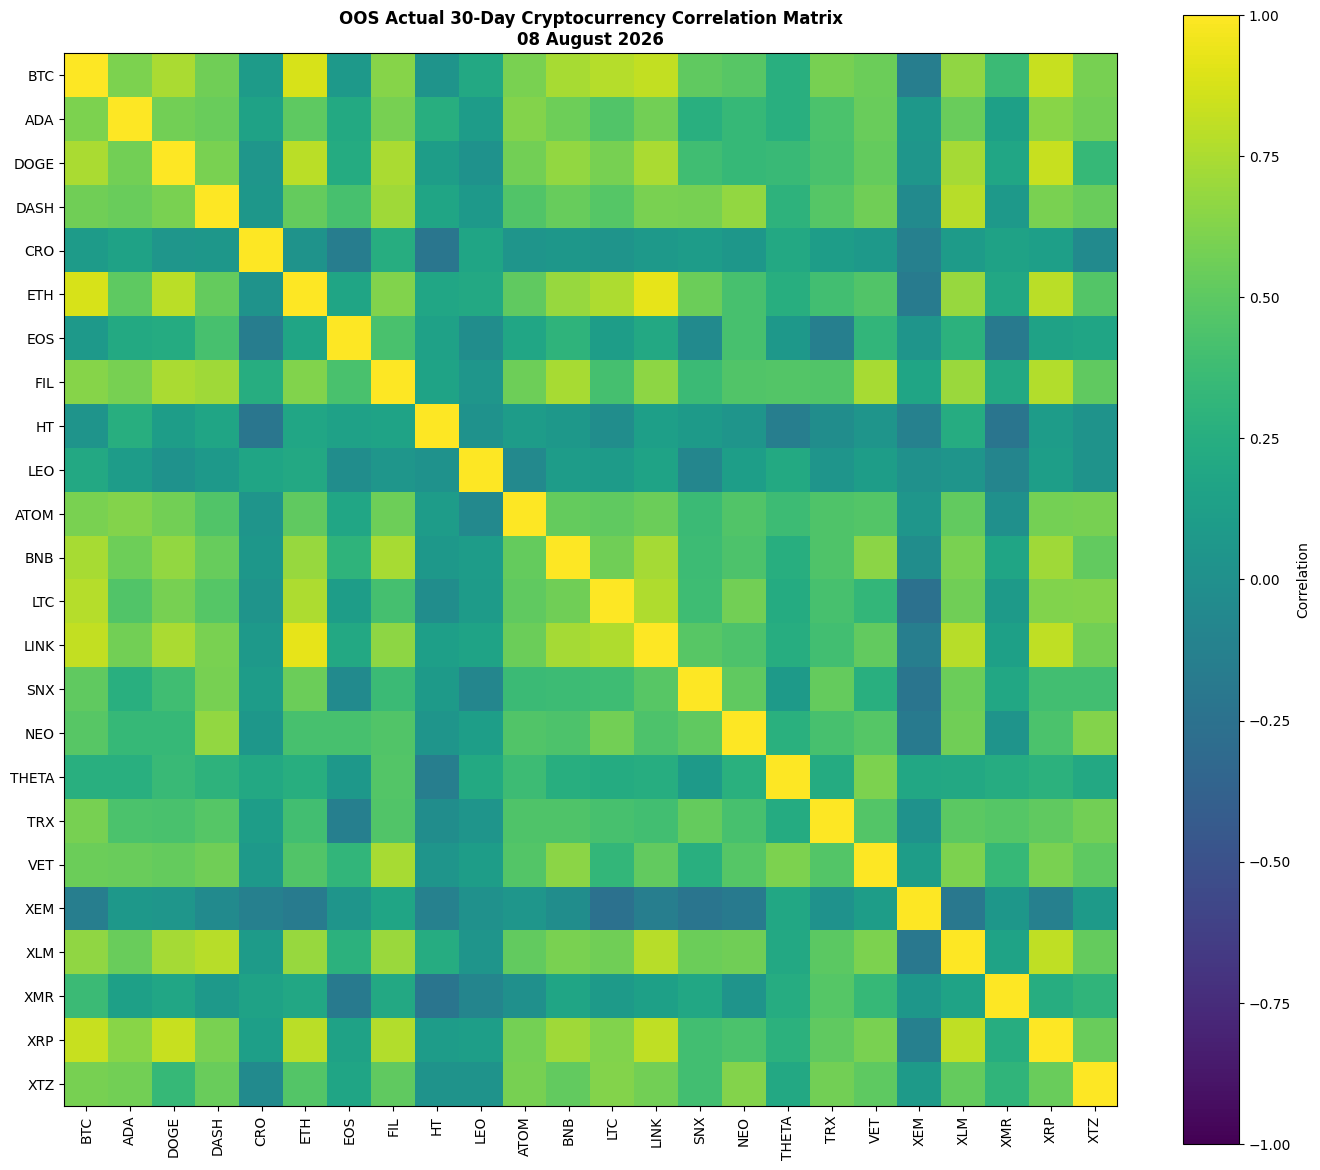

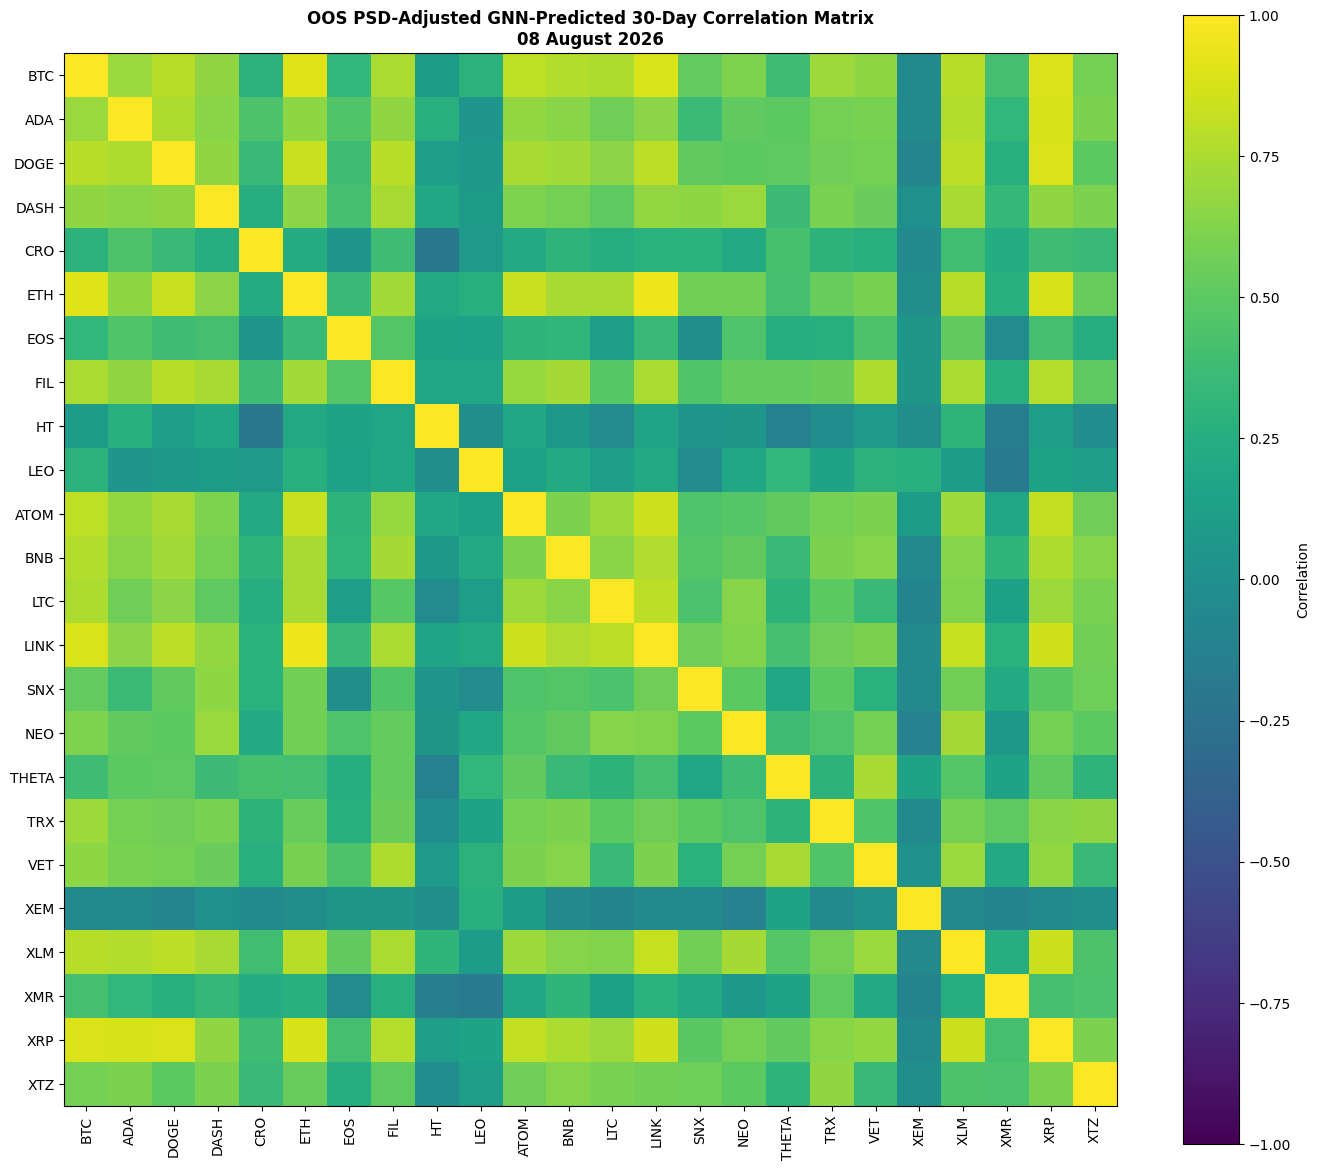

In [103]:
#====================================================
# OOS ACTUAL CORRELATION MATRIX
# LATEST COMPLETE EVALUABLE TARGET DATE
#====================================================

import numpy as np
import matplotlib.pyplot as plt

plt.figure(
    figsize=(14,12)
)

image = plt.imshow(
    actual_matrix.to_numpy(dtype=float, copy=True),
    vmin=-1,
    vmax=1,
    aspect="equal"
)

plt.colorbar(
    image,
    label="Correlation"
)

plt.xticks(
    np.arange(N_COINS),
    display_labels,
    rotation=90
)

plt.yticks(
    np.arange(N_COINS),
    display_labels
)

plt.title(
    "OOS Actual 30-Day Cryptocurrency Correlation Matrix\n"
    f"{example_date:%d %B %Y}",
    fontweight="bold"
)

plt.tight_layout()
plt.show()


#====================================================
# OOS PSD-ADJUSTED GNN-PREDICTED CORRELATION MATRIX
# SAME TARGET DATE AND SAME COLOUR SCALE
#====================================================

plt.figure(
    figsize=(14,12)
)

image = plt.imshow(
    predicted_matrix.to_numpy(dtype=float, copy=True),
    vmin=-1,
    vmax=1,
    aspect="equal"
)

plt.colorbar(
    image,
    label="Correlation"
)

plt.xticks(
    np.arange(N_COINS),
    display_labels,
    rotation=90
)

plt.yticks(
    np.arange(N_COINS),
    display_labels
)

plt.title(
    "OOS PSD-Adjusted GNN-Predicted 30-Day Correlation Matrix\n"
    f"{example_date:%d %B %Y}",
    fontweight="bold"
)

plt.tight_layout()
plt.show()


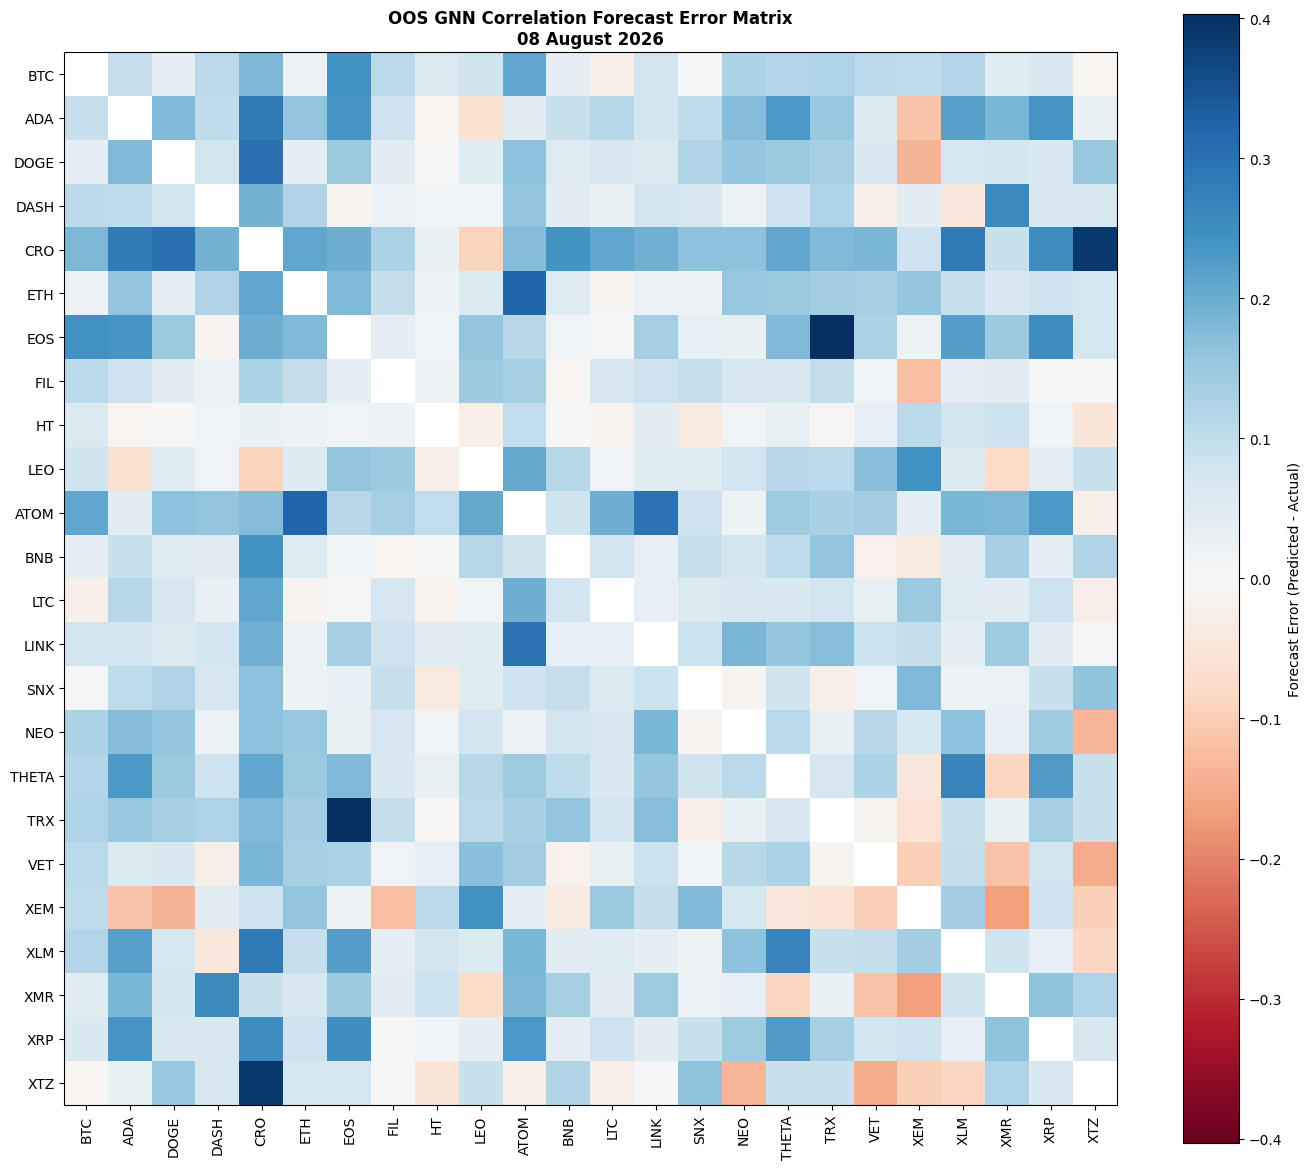

In [104]:
#====================================================
# OOS CORRELATION MATRIX FORECAST ERROR
#
# Error = Predicted - Actual
# Positive = Overprediction
# Negative = Underprediction
#====================================================

import numpy as np
import matplotlib.pyplot as plt

error_matrix = (
    predicted_matrix
    -
    actual_matrix
)

error_values = error_matrix.to_numpy(
    dtype=float,
    copy=True
)

# Self-correlations are not pair forecasts.
np.fill_diagonal(
    error_values,
    np.nan
)

finite_errors = error_values[
    np.isfinite(error_values)
]

if finite_errors.size == 0:
    raise ValueError(
        "No finite off-diagonal OOS matrix forecast errors are available."
    )

max_error = np.max(
    np.abs(finite_errors)
)

if max_error == 0:
    max_error = 1.0

plt.figure(
    figsize=(14,12)
)

image = plt.imshow(
    error_values,
    vmin=-max_error,
    vmax=max_error,
    aspect="equal",
    cmap="RdBu"
)

plt.colorbar(
    image,
    label="Forecast Error (Predicted - Actual)"
)

plt.xticks(
    np.arange(N_COINS),
    display_labels,
    rotation=90
)

plt.yticks(
    np.arange(N_COINS),
    display_labels
)

plt.title(
    "OOS GNN Correlation Forecast Error Matrix\n"
    f"{example_date:%d %B %Y}",
    fontweight="bold"
)

plt.tight_layout()
plt.show()


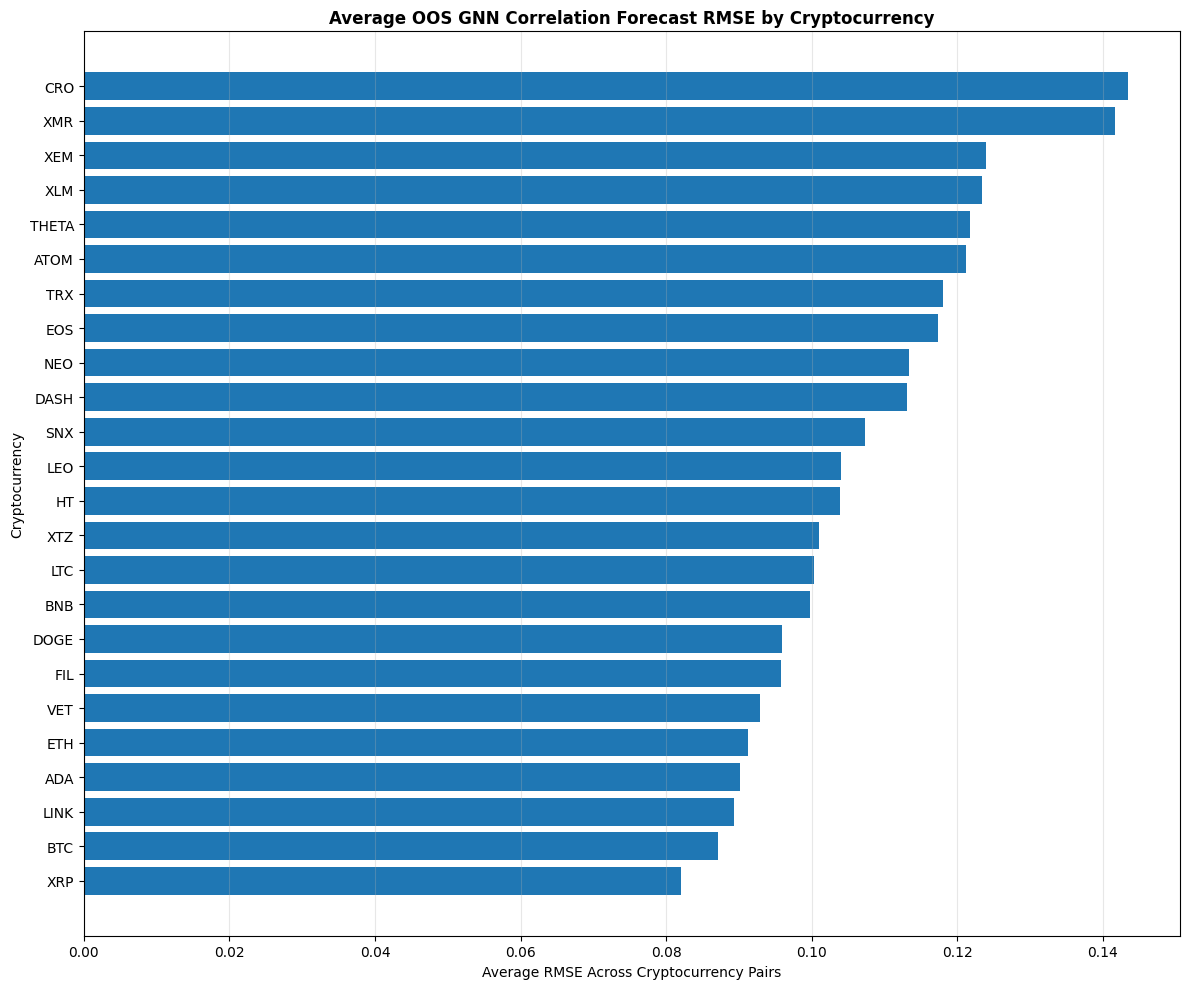

Ticker  Average_GNN_RMSE  Average_Persistence_RMSE
   XRP          0.082058                  0.089932
   BTC          0.087114                  0.088632
  LINK          0.089270                  0.096193
   ADA          0.090191                  0.098829
   ETH          0.091284                  0.098776
   VET          0.092867                  0.111920
   FIL          0.095831                  0.107703
  DOGE          0.095897                  0.098045
   BNB          0.099772                  0.114595
   LTC          0.100318                  0.097329
   XTZ          0.100942                  0.118587
    HT          0.103907                  0.124122
   LEO          0.103970                  0.126319
   SNX          0.107276                  0.122981
  DASH          0.113064                  0.132118
   NEO          0.113345                  0.115486
   EOS          0.117409                  0.139843
   TRX          0.118006                  0.135108
  ATOM          0.121158       

In [105]:
#====================================================
# SUPPLEMENTARY OOS DIAGNOSTIC
# AVERAGE GNN RMSE BY CRYPTOCURRENCY
#====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "oos_pair_metrics" not in globals():
    raise NameError(
        "oos_pair_metrics does not exist. "
        "Run the OOS pair-level evaluation cell first."
    )

required_columns = [
    "Ticker_1",
    "Ticker_2",
    "GNN_RMSE",
    "Persistence_RMSE"
]

missing_columns = [
    column
    for column in required_columns
    if column not in oos_pair_metrics.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns in oos_pair_metrics:\n"
        + "\n".join(missing_columns)
    )

coin_rmse_records = []

for ticker in GNN_TICKERS:

    relevant_pairs = oos_pair_metrics[
        (oos_pair_metrics["Ticker_1"] == ticker)
        |
        (oos_pair_metrics["Ticker_2"] == ticker)
    ]

    coin_rmse_records.append({
        "Ticker": ticker.replace("-USD", ""),
        "Average_GNN_RMSE": relevant_pairs["GNN_RMSE"].mean(),
        "Average_Persistence_RMSE": relevant_pairs["Persistence_RMSE"].mean()
    })

coin_rmse = pd.DataFrame(coin_rmse_records)

coin_rmse = (
    coin_rmse
    .sort_values("Average_GNN_RMSE")
    .reset_index(drop=True)
)

plt.figure(
    figsize=(12,10)
)

plt.barh(
    coin_rmse["Ticker"],
    coin_rmse["Average_GNN_RMSE"]
)

plt.title(
    "Average OOS GNN Correlation Forecast RMSE by Cryptocurrency",
    fontweight="bold"
)

plt.xlabel(
    "Average RMSE Across Cryptocurrency Pairs"
)

plt.ylabel(
    "Cryptocurrency"
)

plt.grid(
    axis="x",
    alpha=0.30
)

plt.tight_layout()
plt.show()

print(
    coin_rmse.round(6).to_string(index=False)
)


---
## I. Forward-Looking Covariance Construction and HRP Portfolio Backtest



ROLLING 7-DAY PORTFOLIO SCHEDULE
Forecast_Origin Target_Date Holding_Start Holding_End
     2026-06-24  2026-07-01    2026-07-01  2026-07-07
     2026-07-01  2026-07-08    2026-07-08  2026-07-14
     2026-07-08  2026-07-15    2026-07-15  2026-07-21
     2026-07-15  2026-07-22    2026-07-22  2026-07-28
     2026-07-22  2026-07-29    2026-07-29  2026-08-04
     2026-07-29  2026-08-05    2026-08-05  2026-08-11
     2026-08-05  2026-08-12    2026-08-12  2026-08-15

Number of GNN correlation matrices loaded: 137

Extending realised return data from 2026-08-08 to 2026-08-15

TEMPORAL AVAILABILITY AUDIT
Forecast_Origin Target_Date Holding_Start Holding_End  GARCH_Assets  LSTM_Assets  GNN_Available
     2026-06-24  2026-07-01    2026-07-01  2026-07-07            24           24           True
     2026-07-01  2026-07-08    2026-07-08  2026-07-14            24           24           True
     2026-07-08  2026-07-15    2026-07-15  2026-07-21            24           24           True
     2026-0

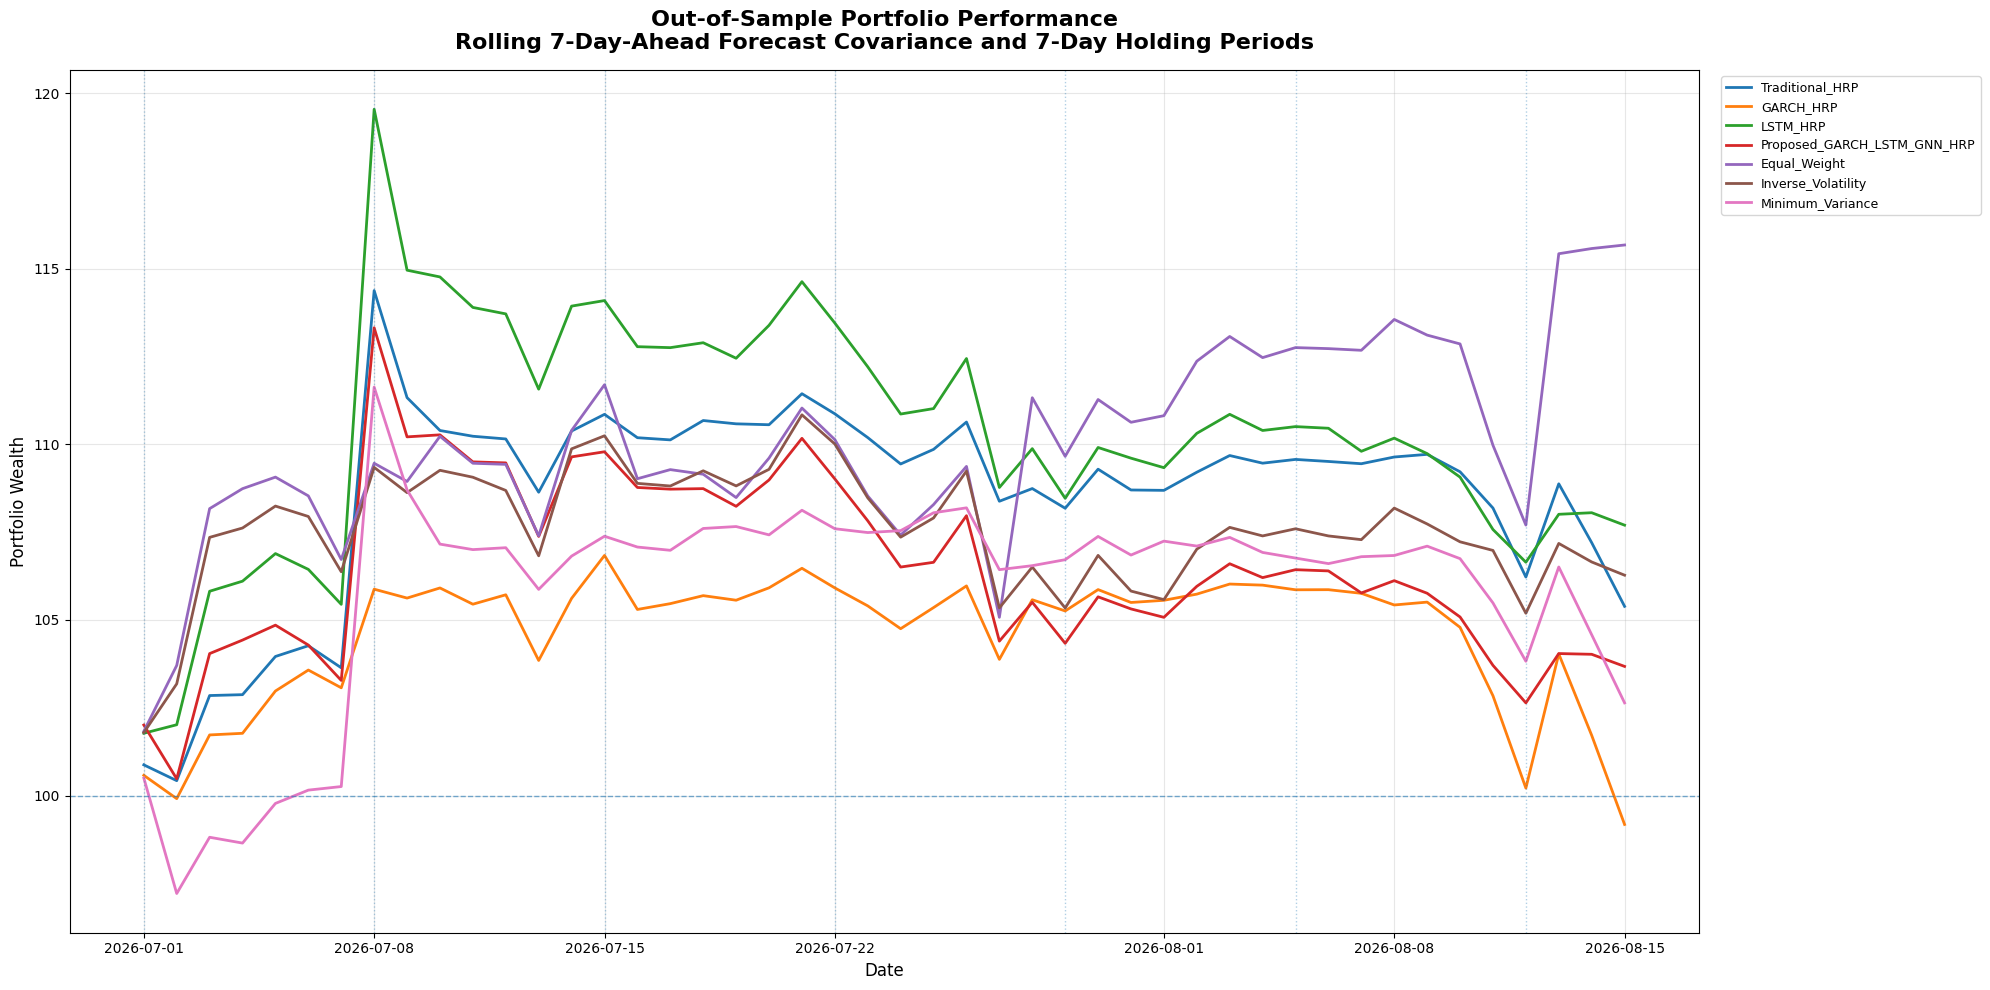

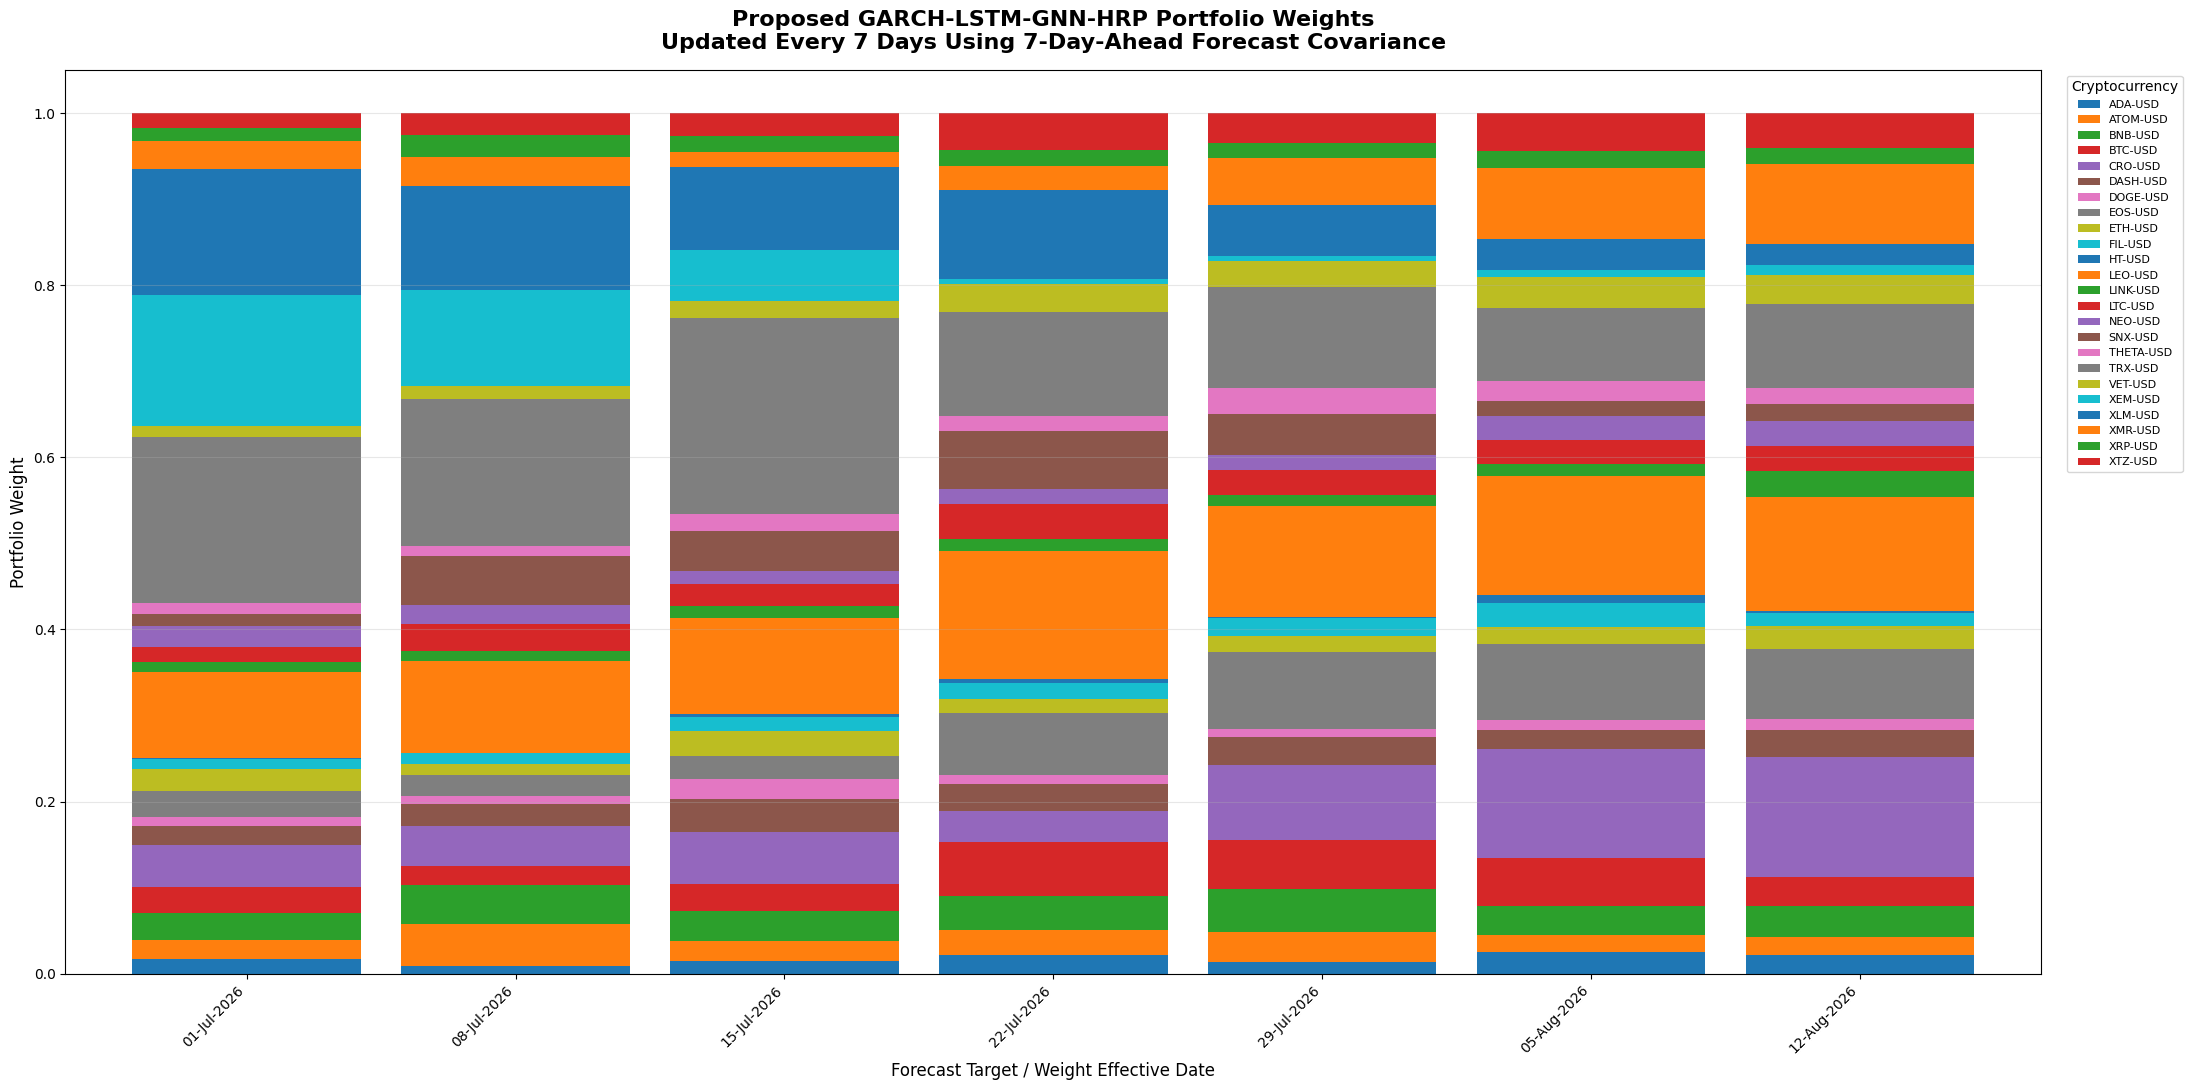


ROLLING 7-DAY BACKTEST COMPLETE

OOS period: 2026-07-01 to 2026-08-15
Forecast horizon: 7 calendar days
Holding interval: 7 calendar days
Number of 7-day portfolio blocks: 7

Proposed covariance at each target date:
Sigma_hat(t+7) = D(LSTM predicted RV30(t+7)) @ GNN predicted correlation(t+7) @ D(LSTM predicted RV30(t+7))

Historical benchmark inputs use only information available through forecast origin t.

Target/holding schedule:
Forecast_Origin Target_Date Holding_Start Holding_End
     2026-06-24  2026-07-01    2026-07-01  2026-07-07
     2026-07-01  2026-07-08    2026-07-08  2026-07-14
     2026-07-08  2026-07-15    2026-07-15  2026-07-21
     2026-07-15  2026-07-22    2026-07-22  2026-07-28
     2026-07-22  2026-07-29    2026-07-29  2026-08-04
     2026-07-29  2026-08-05    2026-08-05  2026-08-11
     2026-08-05  2026-08-12    2026-08-12  2026-08-15


In [106]:
# ============================================================
# ROLLING 7-DAY-AHEAD COVARIANCE -> HRP PORTFOLIO BACKTEST
# ============================================================
#
# Dissertation design:
#
# At forecast origin t:
#   1. GARCH predicts 7-day-ahead 30-day realized volatility.
#   2. LSTM predicts 7-day-ahead 30-day realized volatility.
#   3. GNN predicts 7-day-ahead 30-day correlation.
#   4. Forward-looking covariance is constructed:
#
#          Sigma_hat(t+7) = D(sigma_hat(t+7))
#                           R_hat(t+7)
#                           D(sigma_hat(t+7))
#
#   5. HRP converts covariance into portfolio weights.
#   6. Those weights are held for the next 7-calendar-day block.
#   7. The process is repeated every 7 calendar days.
#
# Formal OOS:
#   01 July 2026 -> 15 August 2026
#
# With horizon = 7 calendar days:
#
#   Origin       Target/effective date       Holding period
#   24-Jun       01-Jul                      01-Jul -> 07-Jul
#   01-Jul       08-Jul                      08-Jul -> 14-Jul
#   08-Jul       15-Jul                      15-Jul -> 21-Jul
#   15-Jul       22-Jul                      22-Jul -> 28-Jul
#   22-Jul       29-Jul                      29-Jul -> 04-Aug
#   29-Jul       05-Aug                      05-Aug -> 11-Aug
#   05-Aug       12-Aug                      12-Aug -> 15-Aug
#
# IMPORTANT:
# "7-day ahead" is implemented as:
#       Target_Date = Forecast_Origin + 7 calendar days
#
# Historical benchmarks use the SAME information cutoff t.
# Therefore no benchmark can use information between t and t+7.
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt.efficient_frontier import EfficientFrontier


# ============================================================
# 2. SETTINGS
# ============================================================

GARCH_FILE = "garch_forecast_window_173.csv"
LSTM_FILE = "LSTM_Predictions_30Day_Updated.csv"
GNN_FOLDER = "Predicted_Correlation_Matrices_Updated"

FORECAST_HORIZON = 7
HOLDING_DAYS = 7
HISTORICAL_WINDOW = 30

PORTFOLIO_START = pd.Timestamp("2026-07-01")
PORTFOLIO_END = pd.Timestamp("2026-08-15")

ANNUALIZATION_FACTOR = 365
RISK_FREE_RATE = 0.0
INITIAL_WEALTH = 100.0


# ============================================================
# 3. DEFINE 24-COIN UNIVERSE
# ============================================================

GNN_TICKERS = [
    "ADA-USD",
    "ATOM-USD",
    "BNB-USD",
    "BTC-USD",
    "CRO-USD",
    "DASH-USD",
    "DOGE-USD",
    "EOS-USD",
    "ETH-USD",
    "FIL-USD",
    "HT-USD",
    "LEO-USD",
    "LINK-USD",
    "LTC-USD",
    "NEO-USD",
    "SNX-USD",
    "THETA-USD",
    "TRX-USD",
    "VET-USD",
    "XEM-USD",
    "XLM-USD",
    "XMR-USD",
    "XRP-USD",
    "XTZ-USD",
]

N_COINS = len(GNN_TICKERS)

assert N_COINS == 24


# ============================================================
# 4. PORTFOLIO NAMES
# ============================================================

PORTFOLIO_NAMES = [
    "Traditional_HRP",
    "GARCH_HRP",
    "LSTM_HRP",
    "Proposed_GARCH_LSTM_GNN_HRP",
    "Equal_Weight",
    "Inverse_Volatility",
    "Minimum_Variance",
]


# ============================================================
# 5. CREATE 7-DAY TARGET / HOLDING SCHEDULE
# ============================================================
#
# First portfolio becomes effective on 01-Jul-2026.
# Subsequent target dates are every 7 calendar days.
#
# For each target T:
#       forecast origin = T - 7 days
#       hold from T through min(T + 6 days, OOS_END)
#
# This produces non-overlapping holding blocks.
# ============================================================

target_dates = pd.date_range(
    start=PORTFOLIO_START,
    end=PORTFOLIO_END,
    freq=f"{HOLDING_DAYS}D"
)

schedule_records = []

for target_date in target_dates:

    target_date = pd.Timestamp(target_date)

    forecast_origin = (
        target_date
        - pd.Timedelta(days=FORECAST_HORIZON)
    )

    holding_start = target_date

    holding_end = min(
        target_date
        + pd.Timedelta(days=HOLDING_DAYS - 1),
        PORTFOLIO_END
    )

    schedule_records.append(
        {
            "Forecast_Origin": forecast_origin,
            "Target_Date": target_date,
            "Holding_Start": holding_start,
            "Holding_End": holding_end,
        }
    )

schedule_df = pd.DataFrame(schedule_records)

print("\n" + "=" * 120)
print("ROLLING 7-DAY PORTFOLIO SCHEDULE")
print("=" * 120)

print(
    schedule_df.to_string(
        index=False
    )
)


# ============================================================
# 6. LOAD GARCH FORECASTS
# ============================================================
#
# Assumption established in your pipeline:
#   GARCH Date = forecast origin
#   GARCH forecasts 7-day-ahead RV30
#
# Therefore:
#   Target_Date = Date + 7 calendar days
# ============================================================

if not os.path.exists(GARCH_FILE):
    raise FileNotFoundError(
        f"GARCH file not found: {GARCH_FILE}"
    )

garch_df = pd.read_csv(GARCH_FILE)

required_garch_columns = [
    "Ticker",
    "Date",
    "GARCH_Vol",
]

missing = [
    c
    for c in required_garch_columns
    if c not in garch_df.columns
]

if missing:
    raise KeyError(
        f"GARCH file missing columns: {missing}"
    )

garch_df["Date"] = pd.to_datetime(
    garch_df["Date"]
)

garch_df["GARCH_Vol"] = pd.to_numeric(
    garch_df["GARCH_Vol"],
    errors="coerce"
)

garch_df["Forecast_Origin"] = (
    garch_df["Date"]
)

garch_df["Target_Date"] = (
    garch_df["Forecast_Origin"]
    + pd.Timedelta(days=FORECAST_HORIZON)
)

garch_df = (
    garch_df[
        garch_df["Ticker"].isin(GNN_TICKERS)
    ]
    .dropna(
        subset=["GARCH_Vol"]
    )
    .drop_duplicates(
        subset=[
            "Ticker",
            "Target_Date",
        ],
        keep="last"
    )
    .sort_values(
        [
            "Target_Date",
            "Ticker",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 7. LOAD LSTM FORECASTS
# ============================================================
#
# Current saved LSTM file convention:
#   LSTM Date = forecast TARGET date
#
# Therefore DO NOT add another 7 days.
#
# Derived origin:
#   Forecast_Origin = Target_Date - 7 days
# ============================================================

if not os.path.exists(LSTM_FILE):
    raise FileNotFoundError(
        f"LSTM file not found: {LSTM_FILE}"
    )

lstm_df = pd.read_csv(LSTM_FILE)

required_lstm_columns = [
    "Ticker",
    "Date",
    "Predicted_RV30",
]

missing = [
    c
    for c in required_lstm_columns
    if c not in lstm_df.columns
]

if missing:
    raise KeyError(
        f"LSTM file missing columns: {missing}"
    )

lstm_df["Date"] = pd.to_datetime(
    lstm_df["Date"]
)

lstm_df["Predicted_RV30"] = pd.to_numeric(
    lstm_df["Predicted_RV30"],
    errors="coerce"
)

if "Actual_RV30" in lstm_df.columns:

    lstm_df["Actual_RV30"] = pd.to_numeric(
        lstm_df["Actual_RV30"],
        errors="coerce"
    )

lstm_df["Target_Date"] = (
    lstm_df["Date"]
)

lstm_df["Forecast_Origin"] = (
    lstm_df["Target_Date"]
    - pd.Timedelta(days=FORECAST_HORIZON)
)

lstm_df = (
    lstm_df[
        lstm_df["Ticker"].isin(GNN_TICKERS)
    ]
    .dropna(
        subset=["Predicted_RV30"]
    )
    .drop_duplicates(
        subset=[
            "Ticker",
            "Target_Date",
        ],
        keep="last"
    )
    .sort_values(
        [
            "Target_Date",
            "Ticker",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 8. LOAD GNN PREDICTED CORRELATION MATRICES
# ============================================================
#
# GNN matrix filename convention:
#   YYYY-MM-DD.csv = TARGET date
# ============================================================

if not os.path.isdir(GNN_FOLDER):
    raise FileNotFoundError(
        f"GNN folder not found: {GNN_FOLDER}"
    )

gnn_correlation_matrices = {}

for filename in sorted(
    os.listdir(GNN_FOLDER)
):

    if not filename.lower().endswith(".csv"):
        continue

    date_text = os.path.splitext(
        filename
    )[0]

    try:
        matrix_date = pd.Timestamp(
            date_text
        )
    except Exception:
        continue

    matrix = pd.read_csv(
        os.path.join(
            GNN_FOLDER,
            filename
        ),
        index_col=0
    )

    matrix.index = (
        matrix.index.astype(str)
    )

    matrix.columns = (
        matrix.columns.astype(str)
    )

    matrix = matrix.reindex(
        index=GNN_TICKERS,
        columns=GNN_TICKERS
    )

    if matrix.isna().any().any():
        raise ValueError(
            f"GNN matrix {filename} contains "
            "missing values after ticker alignment."
        )

    array = matrix.to_numpy(
        dtype=float,
        copy=True
    )

    # Numerical cleanup.
    array = (
        array
        + array.T
    ) / 2.0

    array = np.clip(
        array,
        -1.0,
        1.0
    )

    np.fill_diagonal(
        array,
        1.0
    )

    gnn_correlation_matrices[
        matrix_date
    ] = pd.DataFrame(
        array,
        index=GNN_TICKERS,
        columns=GNN_TICKERS
    )

print(
    "\nNumber of GNN correlation matrices loaded:",
    len(gnn_correlation_matrices)
)


# ============================================================
# 9. PREPARE RETURN DATA
# ============================================================
#
# IMPORTANT RETURN CONVENTION:
#
# 1. LOG RETURNS are used for ALL risk estimation:
#    - historical volatility
#    - historical correlation
#    - covariance inputs
#    This is consistent with the GNN correlation target and
#    the RV30/GARCH/LSTM volatility modelling framework.
#
# 2. SIMPLE RETURNS are used ONLY for realised portfolio
#    accounting because portfolio simple return is w'R.
# ============================================================

if "gnn_df" not in globals():
    raise NameError(
        "gnn_df is not available. "
        "Run the preceding GNN/data-preparation cells first."
    )

return_source = gnn_df.copy()
return_source["Date"] = pd.to_datetime(return_source["Date"])

return_source = (
    return_source[return_source["Ticker"].isin(GNN_TICKERS)]
    .sort_values(["Ticker", "Date"])
    .drop_duplicates(subset=["Ticker", "Date"], keep="last")
    .copy()
)

if "Close" not in return_source.columns:
    raise KeyError(
        "Close is required so simple and log returns can be "
        "constructed from exactly the same price series."
    )

return_source["Close"] = pd.to_numeric(
    return_source["Close"], errors="coerce"
)

# Recalculate both return conventions from the SAME Close data.
# This avoids ambiguity over whether an existing Return column
# contains arithmetic or logarithmic returns.
return_source["Simple_Return"] = (
    return_source.groupby("Ticker")["Close"]
    .pct_change(fill_method=None)
)

return_source["Risk_Log_Return"] = (
    return_source.groupby("Ticker")["Close"]
    .transform(lambda x: np.log(x / x.shift(1)))
)

# Realised portfolio accounting matrix: SIMPLE returns only.
actual_returns = (
    return_source
    .pivot(index="Date", columns="Ticker", values="Simple_Return")
    .sort_index()
    .reindex(columns=GNN_TICKERS)
)

# Historical risk-estimation matrix: LOG returns only.
risk_log_returns = (
    return_source
    .pivot(index="Date", columns="Ticker", values="Risk_Log_Return")
    .sort_index()
    .reindex(columns=GNN_TICKERS)
)

actual_returns.index = pd.to_datetime(actual_returns.index)
risk_log_returns.index = pd.to_datetime(risk_log_returns.index)


# ============================================================
# 10. EXTEND RETURN DATA IF NECESSARY
# ============================================================
#
# If extension is required, both SIMPLE and LOG returns are
# reconstructed from the same combined Close-price panel.
# ============================================================

existing_end = actual_returns.index.max()

if existing_end < PORTFOLIO_END:

    print(
        "\nExtending realised return data from",
        existing_end.date(),
        "to",
        PORTFOLIO_END.date()
    )

    downloaded_list = []
    download_start = existing_end
    download_end = PORTFOLIO_END + pd.Timedelta(days=1)

    for ticker in GNN_TICKERS:

        data = yf.download(
            ticker,
            start=download_start.strftime("%Y-%m-%d"),
            end=download_end.strftime("%Y-%m-%d"),
            interval="1d",
            auto_adjust=False,
            progress=False
        )

        if data.empty:
            raise ValueError(
                f"No downloaded price data for {ticker}."
            )

        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        data = data.reset_index()
        data["Date"] = pd.to_datetime(data["Date"])
        data["Ticker"] = ticker

        downloaded_list.append(
            data[["Date", "Ticker", "Close"]]
        )

    downloaded_prices = pd.concat(
        downloaded_list, ignore_index=True
    )

    existing_prices = return_source[[
        "Date", "Ticker", "Close"
    ]].copy()

    combined_prices = pd.concat(
        [existing_prices, downloaded_prices],
        ignore_index=True
    )

    combined_prices = (
        combined_prices
        .sort_values(["Ticker", "Date"])
        .drop_duplicates(
            subset=["Ticker", "Date"],
            keep="last"
        )
    )

    combined_prices["Simple_Return"] = (
        combined_prices.groupby("Ticker")["Close"]
        .pct_change(fill_method=None)
    )

    combined_prices["Risk_Log_Return"] = (
        combined_prices.groupby("Ticker")["Close"]
        .transform(lambda x: np.log(x / x.shift(1)))
    )

    actual_returns = (
        combined_prices
        .pivot(index="Date", columns="Ticker", values="Simple_Return")
        .sort_index()
        .reindex(columns=GNN_TICKERS)
    )

    risk_log_returns = (
        combined_prices
        .pivot(index="Date", columns="Ticker", values="Risk_Log_Return")
        .sort_index()
        .reindex(columns=GNN_TICKERS)
    )


# ============================================================
# 11. VALIDATE OOS SIMPLE RETURNS
# ============================================================

oos_returns = actual_returns.loc[
    PORTFOLIO_START:PORTFOLIO_END
].copy()

if oos_returns.empty:
    raise ValueError("OOS simple-return matrix is empty.")

if oos_returns.index.min() > PORTFOLIO_START:
    raise ValueError(
        "OOS simple returns do not start on 01-Jul-2026."
    )

if oos_returns.index.max() < PORTFOLIO_END:
    raise ValueError(
        "OOS simple returns do not extend to 15-Aug-2026."
    )

if oos_returns.isna().any().any():
    print("\nMissing OOS simple returns by ticker:")
    print(oos_returns.isna().sum())
    raise ValueError(
        "OOS simple-return matrix contains missing values."
    )


# ============================================================
# 12. HISTORICAL LOG-RETURN WINDOW FOR RISK ESTIMATION
# ============================================================
#
# The GNN correlation target is based on log returns.
# Historical volatility and historical correlation therefore
# use log returns as well. This keeps every covariance input
# in the same return domain.
# ============================================================

def get_historical_returns(
    forecast_origin,
    window=HISTORICAL_WINDOW
):

    forecast_origin = pd.Timestamp(forecast_origin)

    historical = (
        risk_log_returns
        .loc[risk_log_returns.index <= forecast_origin]
        .dropna(how="any")
        .tail(window)
        .copy()
    )

    if len(historical) < window:
        raise ValueError(
            f"Only {len(historical)} complete log-return "
            f"observations available through "
            f"{forecast_origin.date()}; {window} required."
        )

    return historical


# ============================================================
# 13. HISTORICAL VOLATILITY
# ============================================================

def get_historical_volatility(
    forecast_origin
):

    historical = get_historical_returns(
        forecast_origin
    )

    volatility = (
        historical
        .std(ddof=1)
        .reindex(GNN_TICKERS)
        .astype(float)
    )

    if volatility.isna().any():
        raise ValueError(
            "Historical volatility contains NaN."
        )

    if (volatility <= 0).any():
        raise ValueError(
            "Historical volatility contains "
            "non-positive values."
        )

    return volatility


# ============================================================
# 14. HISTORICAL CORRELATION
# ============================================================

def get_historical_correlation(
    forecast_origin
):

    historical = get_historical_returns(
        forecast_origin
    )

    correlation = (
        historical
        .corr()
        .reindex(
            index=GNN_TICKERS,
            columns=GNN_TICKERS
        )
    )

    if correlation.isna().any().any():
        raise ValueError(
            "Historical correlation contains NaN."
        )

    array = correlation.to_numpy(
        dtype=float,
        copy=True
    )

    array = (
        array
        + array.T
    ) / 2.0

    np.fill_diagonal(
        array,
        1.0
    )

    return pd.DataFrame(
        array,
        index=GNN_TICKERS,
        columns=GNN_TICKERS
    )


# ============================================================
# 15. GET GARCH 7-DAY-AHEAD RV30
# ============================================================

def get_garch_volatility(
    target_date,
    expected_origin
):

    target_date = pd.Timestamp(
        target_date
    )

    expected_origin = pd.Timestamp(
        expected_origin
    )

    selected = (
        garch_df[
            garch_df["Target_Date"]
            == target_date
        ]
        .copy()
    )

    if selected.empty:
        raise ValueError(
            f"No GARCH forecast for target "
            f"{target_date.date()}."
        )

    # Check origin alignment.
    origins = (
        selected["Forecast_Origin"]
        .drop_duplicates()
    )

    if (
        len(origins) != 1
        or pd.Timestamp(origins.iloc[0])
        != expected_origin
    ):
        raise ValueError(
            f"GARCH temporal mismatch for "
            f"{target_date.date()}. "
            f"Expected origin: {expected_origin.date()}."
        )

    available = set(
        selected["Ticker"].unique()
    )

    missing = [
        ticker
        for ticker in GNN_TICKERS
        if ticker not in available
    ]

    if missing:
        raise ValueError(
            f"GARCH missing assets for "
            f"{target_date.date()}: {missing}"
        )

    volatility = (
        selected
        .set_index("Ticker")[
            "GARCH_Vol"
        ]
        .reindex(GNN_TICKERS)
        .astype(float)
    )

    if volatility.isna().any():
        raise ValueError(
            "GARCH volatility contains NaN."
        )

    if (volatility <= 0).any():
        raise ValueError(
            "GARCH volatility contains "
            "non-positive values."
        )

    return volatility


# ============================================================
# 16. GET LSTM 7-DAY-AHEAD RV30
# ============================================================

def get_lstm_volatility(
    target_date,
    expected_origin
):

    target_date = pd.Timestamp(
        target_date
    )

    expected_origin = pd.Timestamp(
        expected_origin
    )

    selected = (
        lstm_df[
            lstm_df["Target_Date"]
            == target_date
        ]
        .copy()
    )

    if selected.empty:
        raise ValueError(
            f"No LSTM forecast for target "
            f"{target_date.date()}."
        )

    origins = (
        selected["Forecast_Origin"]
        .drop_duplicates()
    )

    if (
        len(origins) != 1
        or pd.Timestamp(origins.iloc[0])
        != expected_origin
    ):
        raise ValueError(
            f"LSTM temporal mismatch for "
            f"{target_date.date()}. "
            f"Expected origin: {expected_origin.date()}."
        )

    available = set(
        selected["Ticker"].unique()
    )

    missing = [
        ticker
        for ticker in GNN_TICKERS
        if ticker not in available
    ]

    if missing:
        raise ValueError(
            f"LSTM missing assets for "
            f"{target_date.date()}: {missing}"
        )

    volatility = (
        selected
        .set_index("Ticker")[
            "Predicted_RV30"
        ]
        .reindex(GNN_TICKERS)
        .astype(float)
    )

    if volatility.isna().any():
        raise ValueError(
            "LSTM volatility contains NaN."
        )

    if (volatility <= 0).any():
        raise ValueError(
            "LSTM volatility contains "
            "non-positive values."
        )

    return volatility


# ============================================================
# 17. GET GNN 7-DAY-AHEAD CORRELATION
# ============================================================

def get_gnn_correlation(
    target_date
):

    target_date = pd.Timestamp(
        target_date
    )

    if (
        target_date
        not in gnn_correlation_matrices
    ):
        raise ValueError(
            f"No GNN correlation matrix for target "
            f"{target_date.date()}."
        )

    return (
        gnn_correlation_matrices[
            target_date
        ]
        .copy()
    )


# ============================================================
# 18. BUILD COVARIANCE MATRIX
# ============================================================
#
#       Sigma = D(sigma) R D(sigma)
#
# The volatility scale and correlation matrix must refer
# to the same target date for the proposed model.
# ============================================================

def build_covariance(
    volatility,
    correlation
):

    volatility = (
        pd.Series(volatility)
        .reindex(GNN_TICKERS)
        .astype(float)
    )

    correlation = (
        correlation
        .reindex(
            index=GNN_TICKERS,
            columns=GNN_TICKERS
        )
        .astype(float)
    )

    if volatility.isna().any():
        raise ValueError(
            "Volatility vector contains NaN."
        )

    if correlation.isna().any().any():
        raise ValueError(
            "Correlation matrix contains NaN."
        )

    D = np.diag(
        volatility.to_numpy(
            dtype=float
        )
    )

    covariance = (
        D
        @ correlation.to_numpy(
            dtype=float
        )
        @ D
    )

    covariance = (
        covariance
        + covariance.T
    ) / 2.0

    return pd.DataFrame(
        covariance,
        index=GNN_TICKERS,
        columns=GNN_TICKERS
    )


# ============================================================
# 19. HRP WEIGHTS
# ============================================================

def get_hrp_weights(
    covariance
):

    covariance = (
        covariance
        .reindex(
            index=GNN_TICKERS,
            columns=GNN_TICKERS
        )
    )

    hrp = HRPOpt(
        cov_matrix=covariance
    )

    weights = hrp.optimize()

    weights = pd.Series(
        weights,
        dtype=float
    )

    weights = (
        weights
        .reindex(GNN_TICKERS)
        .fillna(0.0)
    )

    total = weights.sum()

    if total <= 0:
        raise ValueError(
            "HRP weight sum is non-positive."
        )

    return (
        weights
        / total
    )


# ============================================================
# 20. EQUAL WEIGHT
# ============================================================

def get_equal_weights():

    return pd.Series(
        1.0 / N_COINS,
        index=GNN_TICKERS,
        dtype=float
    )


# ============================================================
# 21. INVERSE VOLATILITY
# ============================================================

def get_inverse_volatility_weights(
    volatility
):

    volatility = (
        pd.Series(volatility)
        .reindex(GNN_TICKERS)
        .astype(float)
    )

    inverse_volatility = (
        1.0 / volatility
    )

    return (
        inverse_volatility
        / inverse_volatility.sum()
    )


# ============================================================
# 22. MINIMUM VARIANCE
# ============================================================

def get_minimum_variance_weights(
    covariance
):

    covariance = (
        covariance
        .reindex(
            index=GNN_TICKERS,
            columns=GNN_TICKERS
        )
    )

    ef = EfficientFrontier(
        expected_returns=None,
        cov_matrix=(
            covariance
            * ANNUALIZATION_FACTOR
        ),
        weight_bounds=(0, 1)
    )

    weights = ef.min_volatility()

    weights = pd.Series(
        weights,
        dtype=float
    )

    weights = (
        weights
        .reindex(GNN_TICKERS)
        .fillna(0.0)
    )

    return (
        weights
        / weights.sum()
    )


# ============================================================
# 23. TEMPORAL AVAILABILITY AUDIT
# ============================================================

audit_records = []

for _, row in schedule_df.iterrows():

    forecast_origin = pd.Timestamp(
        row["Forecast_Origin"]
    )

    target_date = pd.Timestamp(
        row["Target_Date"]
    )

    garch_selected = (
        garch_df[
            garch_df["Target_Date"]
            == target_date
        ]
    )

    lstm_selected = (
        lstm_df[
            lstm_df["Target_Date"]
            == target_date
        ]
    )

    garch_assets = (
        garch_selected[
            "Ticker"
        ].nunique()
    )

    lstm_assets = (
        lstm_selected[
            "Ticker"
        ].nunique()
    )

    gnn_available = (
        target_date
        in gnn_correlation_matrices
    )

    audit_records.append(
        {
            "Forecast_Origin":
                forecast_origin,

            "Target_Date":
                target_date,

            "Holding_Start":
                row["Holding_Start"],

            "Holding_End":
                row["Holding_End"],

            "GARCH_Assets":
                garch_assets,

            "LSTM_Assets":
                lstm_assets,

            "GNN_Available":
                gnn_available,
        }
    )

audit_df = pd.DataFrame(
    audit_records
)

print("\n" + "=" * 140)
print("TEMPORAL AVAILABILITY AUDIT")
print("=" * 140)

print(
    audit_df.to_string(
        index=False
    )
)

bad_garch = (
    audit_df[
        "GARCH_Assets"
    ]
    != N_COINS
)

bad_lstm = (
    audit_df[
        "LSTM_Assets"
    ]
    != N_COINS
)

bad_gnn = (
    ~audit_df[
        "GNN_Available"
    ]
)

if bad_garch.any():

    raise ValueError(
        "GARCH forecast is missing for one or more "
        "7-day target dates."
    )

if bad_lstm.any():

    raise ValueError(
        "LSTM forecast is missing for one or more "
        "7-day target dates."
    )

if bad_gnn.any():

    raise ValueError(
        "GNN correlation forecast is missing for "
        "one or more 7-day target dates."
    )


# ============================================================
# 24. ROLLING 7-DAY PORTFOLIO CONSTRUCTION
# ============================================================
#
# At each origin t:
#
# Traditional HRP:
#   historical vol(t) + historical corr(t)
#
# GARCH-HRP:
#   GARCH predicted RV30(t+7) + historical corr(t)
#
# LSTM-HRP:
#   LSTM predicted RV30(t+7) + historical corr(t)
#
# Proposed:
#   LSTM predicted RV30(t+7) + GNN predicted corr(t+7)
#
# Equal Weight:
#   1/N
#
# Inverse Volatility:
#   historical vol(t)
#
# Minimum Variance:
#   historical covariance(t)
#
# Each resulting weight vector is held only for its
# corresponding 7-day block.
# ============================================================

portfolio_returns_df = pd.DataFrame(
    index=oos_returns.index,
    columns=PORTFOLIO_NAMES,
    dtype=float
)

weight_records = []

covariance_records = []

for block_number, row in schedule_df.iterrows():

    forecast_origin = pd.Timestamp(
        row["Forecast_Origin"]
    )

    target_date = pd.Timestamp(
        row["Target_Date"]
    )

    holding_start = pd.Timestamp(
        row["Holding_Start"]
    )

    holding_end = pd.Timestamp(
        row["Holding_End"]
    )

    print("\n" + "=" * 140)

    print(
        f"BLOCK {block_number + 1}"
    )

    print(
        "Forecast origin:",
        forecast_origin.date()
    )

    print(
        "Forecast target / weight effective date:",
        target_date.date()
    )

    print(
        "Holding period:",
        holding_start.date(),
        "to",
        holding_end.date()
    )

    print("=" * 140)

    # --------------------------------------------------------
    # 24.1 Historical inputs available at forecast origin
    # --------------------------------------------------------

    historical_vol = (
        get_historical_volatility(
            forecast_origin
        )
    )

    historical_corr = (
        get_historical_correlation(
            forecast_origin
        )
    )

    # --------------------------------------------------------
    # 24.2 7-day-ahead forecasts
    # --------------------------------------------------------

    garch_vol = (
        get_garch_volatility(
            target_date=target_date,
            expected_origin=forecast_origin
        )
    )

    lstm_vol = (
        get_lstm_volatility(
            target_date=target_date,
            expected_origin=forecast_origin
        )
    )

    gnn_corr = (
        get_gnn_correlation(
            target_date
        )
    )

    # --------------------------------------------------------
    # 24.3 Covariance matrices
    # --------------------------------------------------------

    traditional_cov = build_covariance(
        historical_vol,
        historical_corr
    )

    garch_cov = build_covariance(
        garch_vol,
        historical_corr
    )

    lstm_cov = build_covariance(
        lstm_vol,
        historical_corr
    )

    proposed_cov = build_covariance(
        lstm_vol,
        gnn_corr
    )

    # Save proposed covariance for audit.
    proposed_cov.to_csv(
        f"Proposed_Forecast_Covariance_"
        f"{target_date.strftime('%Y-%m-%d')}.csv"
    )

    # Optional long-form covariance summary.
    covariance_records.append(
        {
            "Forecast_Origin":
                forecast_origin,

            "Target_Date":
                target_date,

            "Mean_LSTM_Volatility":
                lstm_vol.mean(),

            "Mean_GARCH_Volatility":
                garch_vol.mean(),

            "Mean_GNN_Correlation":
                (
                    gnn_corr
                    .where(
                        ~np.eye(
                            N_COINS,
                            dtype=bool
                        )
                    )
                    .stack()
                    .mean()
                ),
        }
    )

    # --------------------------------------------------------
    # 24.4 Calculate weights
    # --------------------------------------------------------

    weights = {}

    weights[
        "Traditional_HRP"
    ] = get_hrp_weights(
        traditional_cov
    )

    weights[
        "GARCH_HRP"
    ] = get_hrp_weights(
        garch_cov
    )

    weights[
        "LSTM_HRP"
    ] = get_hrp_weights(
        lstm_cov
    )

    weights[
        "Proposed_GARCH_LSTM_GNN_HRP"
    ] = get_hrp_weights(
        proposed_cov
    )

    weights[
        "Equal_Weight"
    ] = get_equal_weights()

    weights[
        "Inverse_Volatility"
    ] = get_inverse_volatility_weights(
        historical_vol
    )

    weights[
        "Minimum_Variance"
    ] = get_minimum_variance_weights(
        traditional_cov
    )

    # --------------------------------------------------------
    # 24.5 Validate and save weights
    # --------------------------------------------------------

    for portfolio_name in PORTFOLIO_NAMES:

        w = (
            weights[
                portfolio_name
            ]
            .reindex(GNN_TICKERS)
            .astype(float)
        )

        if w.isna().any():
            raise ValueError(
                f"{portfolio_name} contains NaN weights "
                f"for target {target_date.date()}."
            )

        if not np.isclose(
            w.sum(),
            1.0,
            atol=1e-6
        ):
            raise ValueError(
                f"{portfolio_name} weights do not sum "
                f"to one for {target_date.date()}."
            )

        for ticker in GNN_TICKERS:

            weight_records.append(
                {
                    "Block":
                        block_number + 1,

                    "Forecast_Origin":
                        forecast_origin,

                    "Target_Date":
                        target_date,

                    "Holding_Start":
                        holding_start,

                    "Holding_End":
                        holding_end,

                    "Portfolio":
                        portfolio_name,

                    "Ticker":
                        ticker,

                    "Weight":
                        w.loc[ticker],
                }
            )

    # --------------------------------------------------------
    # 24.6 Apply weights only to this 7-day holding block
    # --------------------------------------------------------

    holding_returns = (
        actual_returns
        .loc[
            holding_start:
            holding_end,
            GNN_TICKERS
        ]
        .copy()
    )

    if holding_returns.empty:
        raise ValueError(
            f"No realized returns for holding block "
            f"{holding_start.date()} -> {holding_end.date()}."
        )

    if holding_returns.isna().any().any():

        print(
            holding_returns
            .isna()
            .sum()
        )

        raise ValueError(
            f"Missing realized returns in holding block "
            f"{holding_start.date()} -> {holding_end.date()}."
        )

    for portfolio_name in PORTFOLIO_NAMES:

        block_returns = (
            holding_returns
            @ weights[
                portfolio_name
            ]
        )

        portfolio_returns_df.loc[
            block_returns.index,
            portfolio_name
        ] = block_returns


# ============================================================
# 25. FINAL WEIGHT TABLE
# ============================================================

weights_df = pd.DataFrame(
    weight_records
)

weights_df.to_csv(
    "Rolling_7Day_Portfolio_Weights.csv",
    index=False
)

print("\n" + "=" * 160)
print("ROLLING 7-DAY PORTFOLIO WEIGHTS")
print("=" * 160)

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.width",
    300,
    "display.float_format",
    "{:.6f}".format
):
    print(
        weights_df.to_string(
            index=False
        )
    )


# ============================================================
# 26. VALIDATE COMPLETE OOS RETURN COVERAGE
# ============================================================

portfolio_returns_df = (
    portfolio_returns_df
    .loc[
        PORTFOLIO_START:
        PORTFOLIO_END
    ]
)

if portfolio_returns_df.isna().any().any():

    print(
        "\nMissing portfolio returns:"
    )

    print(
        portfolio_returns_df
        .isna()
        .sum()
    )

    raise ValueError(
        "Portfolio-return series contains gaps. "
        "Check holding-block boundaries."
    )

portfolio_returns_df.to_csv(
    "Rolling_7Day_Portfolio_Daily_Returns.csv"
)


# ============================================================
# 27. CUMULATIVE WEALTH
# ============================================================

cumulative_wealth = (
    INITIAL_WEALTH
    *
    (
        1
        + portfolio_returns_df
    ).cumprod()
)

cumulative_wealth.to_csv(
    "Rolling_7Day_Portfolio_Cumulative_Wealth.csv"
)


# ============================================================
# 28. PERFORMANCE METRICS
# ============================================================

performance_records = []

for portfolio_name in PORTFOLIO_NAMES:

    returns = (
        portfolio_returns_df[
            portfolio_name
        ]
        .dropna()
    )

    n = len(returns)

    if n == 0:
        raise ValueError(
            f"No returns for {portfolio_name}."
        )

    # --------------------------------------------------------
    # Total Return
    # --------------------------------------------------------

    total_return = (
        (
            1
            + returns
        ).prod()
        - 1
    )

    # --------------------------------------------------------
    # Annualized Return
    # --------------------------------------------------------

    annualized_return = (
        (
            1
            + total_return
        )
        **
        (
            ANNUALIZATION_FACTOR
            / n
        )
        - 1
    )

    # --------------------------------------------------------
    # Annualized Volatility
    # --------------------------------------------------------

    annualized_volatility = (
        returns.std(ddof=1)
        *
        np.sqrt(
            ANNUALIZATION_FACTOR
        )
    )

    # --------------------------------------------------------
    # Sharpe Ratio
    # --------------------------------------------------------

    if annualized_volatility > 0:

        sharpe_ratio = (
            (
                returns.mean()
                *
                ANNUALIZATION_FACTOR
            )
            -
            RISK_FREE_RATE
        ) / annualized_volatility

    else:

        sharpe_ratio = np.nan

    # --------------------------------------------------------
    # Sortino Ratio
    # --------------------------------------------------------

    downside_returns = np.minimum(
        returns.to_numpy(
            dtype=float
        ),
        0.0
    )

    downside_deviation = (
        np.sqrt(
            np.mean(
                downside_returns ** 2
            )
        )
        *
        np.sqrt(
            ANNUALIZATION_FACTOR
        )
    )

    if downside_deviation > 0:

        sortino_ratio = (
            (
                returns.mean()
                *
                ANNUALIZATION_FACTOR
            )
            -
            RISK_FREE_RATE
        ) / downside_deviation

    else:

        sortino_ratio = np.nan

    # --------------------------------------------------------
    # Maximum Drawdown
    # --------------------------------------------------------

    wealth = (
        1
        + returns
    ).cumprod()

    running_peak = (
        wealth.cummax()
    )

    drawdown = (
        wealth
        / running_peak
        - 1
    )

    maximum_drawdown = (
        drawdown.min()
    )

    # --------------------------------------------------------
    # Calmar Ratio
    # --------------------------------------------------------

    if maximum_drawdown < 0:

        calmar_ratio = (
            annualized_return
            /
            abs(
                maximum_drawdown
            )
        )

    else:

        calmar_ratio = np.nan

    # --------------------------------------------------------
    # Final Wealth
    # --------------------------------------------------------

    final_wealth = (
        INITIAL_WEALTH
        *
        wealth.iloc[-1]
    )

    performance_records.append(
        {
            "Portfolio":
                portfolio_name,

            "Total_Return":
                total_return,

            "Annualized_Return":
                annualized_return,

            "Annualized_Volatility":
                annualized_volatility,

            "Sharpe_Ratio":
                sharpe_ratio,

            "Sortino_Ratio":
                sortino_ratio,

            "Maximum_Drawdown":
                maximum_drawdown,

            "Calmar_Ratio":
                calmar_ratio,

            "Final_Wealth":
                final_wealth,
        }
    )

performance_df = (
    pd.DataFrame(
        performance_records
    )
    .set_index(
        "Portfolio"
    )
)

performance_df.to_csv(
    "Rolling_7Day_Portfolio_Performance.csv"
)


# ============================================================
# 29. TURNOVER BETWEEN 7-DAY WEIGHT UPDATES
# ============================================================
#
# Turnover_t = 0.5 * sum_i |w_i,t - w_i,t-1|
#
# The first target date has no previous OOS portfolio,
# therefore turnover is NaN.
# ============================================================

turnover_records = []

for portfolio_name in PORTFOLIO_NAMES:

    portfolio_weight_history = (
        weights_df[
            weights_df["Portfolio"]
            == portfolio_name
        ]
        .pivot(
            index="Target_Date",
            columns="Ticker",
            values="Weight"
        )
        .reindex(
            columns=GNN_TICKERS
        )
        .sort_index()
    )

    previous_weights = None

    for target_date, current_weights in (
        portfolio_weight_history.iterrows()
    ):

        if previous_weights is None:

            turnover = np.nan

        else:

            turnover = (
                0.5
                *
                np.abs(
                    current_weights
                    - previous_weights
                ).sum()
            )

        turnover_records.append(
            {
                "Portfolio":
                    portfolio_name,

                "Target_Date":
                    pd.Timestamp(
                        target_date
                    ),

                "Turnover":
                    turnover,
            }
        )

        previous_weights = (
            current_weights.copy()
        )

turnover_df = pd.DataFrame(
    turnover_records
)

turnover_df.to_csv(
    "Rolling_7Day_Portfolio_Turnover.csv",
    index=False
)


# ============================================================
# 30. COVARIANCE FORECAST SUMMARY
# ============================================================

covariance_summary_df = pd.DataFrame(
    covariance_records
)

covariance_summary_df.to_csv(
    "Rolling_7Day_Forecast_Covariance_Summary.csv",
    index=False
)


# ============================================================
# 31. DISPLAY PERFORMANCE
# ============================================================

print("\n" + "=" * 160)

print(
    "OUT-OF-SAMPLE ROLLING 7-DAY PORTFOLIO PERFORMANCE"
)

print(
    "PERIOD:",
    PORTFOLIO_START.strftime(
        "%d %B %Y"
    ),
    "TO",
    PORTFOLIO_END.strftime(
        "%d %B %Y"
    )
)

print(
    "FORECAST HORIZON:",
    FORECAST_HORIZON,
    "CALENDAR DAYS"
)

print(
    "PORTFOLIO WEIGHT UPDATE FREQUENCY:",
    HOLDING_DAYS,
    "CALENDAR DAYS"
)

print("=" * 160)

with pd.option_context(
    "display.max_columns",
    None,
    "display.width",
    300,
    "display.float_format",
    "{:.6f}".format
):
    print(
        performance_df
    )


# ============================================================
# 32. DISPLAY TURNOVER
# ============================================================

turnover_table = (
    turnover_df
    .pivot(
        index="Target_Date",
        columns="Portfolio",
        values="Turnover"
    )
    .sort_index()
)

print("\n" + "=" * 160)
print("7-DAY PORTFOLIO TURNOVER")
print("=" * 160)

with pd.option_context(
    "display.max_columns",
    None,
    "display.width",
    300,
    "display.float_format",
    "{:.6f}".format
):
    print(
        turnover_table
    )


# ============================================================
# 33. DISPLAY PROPOSED WEIGHTS BY TARGET DATE
# ============================================================

proposed_weight_table = (
    weights_df[
        weights_df["Portfolio"]
        ==
        "Proposed_GARCH_LSTM_GNN_HRP"
    ]
    .pivot(
        index="Target_Date",
        columns="Ticker",
        values="Weight"
    )
    .reindex(
        columns=GNN_TICKERS
    )
    .sort_index()
)

print("\n" + "=" * 160)

print(
    "PROPOSED GARCH-LSTM-GNN-HRP "
    "WEIGHTS BY 7-DAY TARGET DATE"
)

print("=" * 160)

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.width",
    350,
    "display.float_format",
    "{:.6f}".format
):
    print(
        proposed_weight_table
    )


# ============================================================
# 34. PLOT CUMULATIVE WEALTH
# ============================================================

fig, ax = plt.subplots(
    figsize=(20, 10)
)

for portfolio_name in PORTFOLIO_NAMES:

    ax.plot(
        cumulative_wealth.index,
        cumulative_wealth[
            portfolio_name
        ],
        linewidth=2,
        label=portfolio_name
    )

ax.axhline(
    y=INITIAL_WEALTH,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

# Show 7-day weight-update boundaries.
for target_date in target_dates:

    ax.axvline(
        x=target_date,
        linestyle=":",
        linewidth=1,
        alpha=0.35
    )

ax.set_title(
    "Out-of-Sample Portfolio Performance\n"
    "Rolling 7-Day-Ahead Forecast Covariance and "
    "7-Day Holding Periods",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Date",
    fontsize=12
)

ax.set_ylabel(
    "Portfolio Wealth",
    fontsize=12
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    fontsize=9
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 35. PLOT PROPOSED WEIGHT EVOLUTION
# ============================================================

# Convert the regular DatetimeIndex to categorical labels.
# This avoids pandas PeriodConverter errors for bar plots.
proposed_weight_table_plot = proposed_weight_table.copy()
proposed_weight_table_plot.index = pd.Index(
    pd.to_datetime(proposed_weight_table_plot.index)
    .strftime("%d-%b-%Y"),
    dtype="object"
)

fig, ax = plt.subplots(
    figsize=(22, 11)
)

proposed_weight_table_plot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.85
)

ax.set_title(
    "Proposed GARCH-LSTM-GNN-HRP Portfolio Weights\n"
    "Updated Every 7 Days Using 7-Day-Ahead Forecast Covariance",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Forecast Target / Weight Effective Date",
    fontsize=12
)

ax.set_ylabel(
    "Portfolio Weight",
    fontsize=12
)

ax.legend(
    title="Cryptocurrency",
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    fontsize=8
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 36. FINAL TEMPORAL SUMMARY
# ============================================================

print("\n" + "=" * 160)
print("ROLLING 7-DAY BACKTEST COMPLETE")
print("=" * 160)

print(
    "\nOOS period:",
    PORTFOLIO_START.date(),
    "to",
    PORTFOLIO_END.date()
)

print(
    "Forecast horizon:",
    FORECAST_HORIZON,
    "calendar days"
)

print(
    "Holding interval:",
    HOLDING_DAYS,
    "calendar days"
)

print(
    "Number of 7-day portfolio blocks:",
    len(schedule_df)
)

print(
    "\nProposed covariance at each target date:"
)

print(
    "Sigma_hat(t+7) = "
    "D(LSTM predicted RV30(t+7)) "
    "@ GNN predicted correlation(t+7) "
    "@ D(LSTM predicted RV30(t+7))"
)

print(
    "\nHistorical benchmark inputs use only "
    "information available through forecast origin t."
)

print(
    "\nTarget/holding schedule:"
)

print(
    schedule_df.to_string(
        index=False
    )
)


**EDA**

In [107]:
#====================================================
# CORRELATION EDA
#
# IN-SAMPLE / MODEL-DEVELOPMENT PERIOD:
# 01 JANUARY 2021 - 30 JUNE 2026
#
# OOS PERIOD:
# 01 JULY 2026 - 15 AUGUST 2026
# IS EXCLUDED
#====================================================

EDA_START_DATE = pd.Timestamp(
    "2021-01-01"
)

EDA_END_DATE = pd.Timestamp(
    "2026-06-30"
)


#====================================================
# CREATE EDA RETURN MATRIX
#====================================================

eda_returns = (

    returns_wide

    .loc[
        EDA_START_DATE:
        EDA_END_DATE
    ]

    .copy()

)


#====================================================
# CHECK DATA
#====================================================

print(
    "=" * 70
)

print(
    "CORRELATION EDA DATA"
)

print(
    "=" * 70
)

print(
    "Date Range:",
    eda_returns.index.min(),
    "to",
    eda_returns.index.max()
)

print(
    "Number of Cryptocurrencies:",
    eda_returns.shape[1]
)

print(
    "Number of Daily Observations:",
    eda_returns.shape[0]
)

print(
    "Missing Values:",
    eda_returns.isna().sum().sum()
)

CORRELATION EDA DATA
Date Range: 2021-02-22 00:00:00 to 2026-06-30 00:00:00
Number of Cryptocurrencies: 24
Number of Daily Observations: 1955
Missing Values: 0


In [108]:
#====================================================
# CORRELATION EDA 1
# FULL-PERIOD CORRELATION MATRIX
#====================================================

average_corr_matrix = (

    eda_returns

    .corr()

    .reindex(
        index=GNN_TICKERS,
        columns=GNN_TICKERS
    )

)


#====================================================
# PRINT MATRIX
#====================================================

print(
    "\nFull-Period Correlation Matrix:"
)

print(
    average_corr_matrix.round(3)
)


#====================================================
# AVERAGE OFF-DIAGONAL CORRELATION
#====================================================

upper_triangle = np.triu_indices(
    len(GNN_TICKERS),
    k=1
)


average_pairwise_corr = (

    average_corr_matrix

    .to_numpy()[
        upper_triangle
    ]

    .mean()

)


print(
    "\nAverage Pairwise Correlation:",
    round(
        average_pairwise_corr,
        4
    )
)


Full-Period Correlation Matrix:
Ticker     ADA-USD  ATOM-USD  BNB-USD  BTC-USD  CRO-USD  DASH-USD  DOGE-USD  \
Ticker                                                                        
ADA-USD      1.000     0.687    0.651    0.714    0.602     0.608     0.620   
ATOM-USD     0.687     1.000    0.650    0.644    0.586     0.577     0.545   
BNB-USD      0.651     0.650    1.000    0.725    0.581     0.601     0.543   
BTC-USD      0.714     0.644    0.725    1.000    0.666     0.621     0.635   
CRO-USD      0.602     0.586    0.581    0.666    1.000     0.502     0.525   
DASH-USD     0.608     0.577    0.601    0.621    0.502     1.000     0.538   
DOGE-USD     0.620     0.545    0.543    0.635    0.525     0.538     1.000   
EOS-USD      0.692     0.669    0.645    0.662    0.580     0.662     0.602   
ETH-USD      0.736     0.687    0.751    0.835    0.640     0.652     0.645   
FIL-USD      0.659     0.622    0.602    0.638    0.521     0.590     0.560   
HT-USD      -0.081 

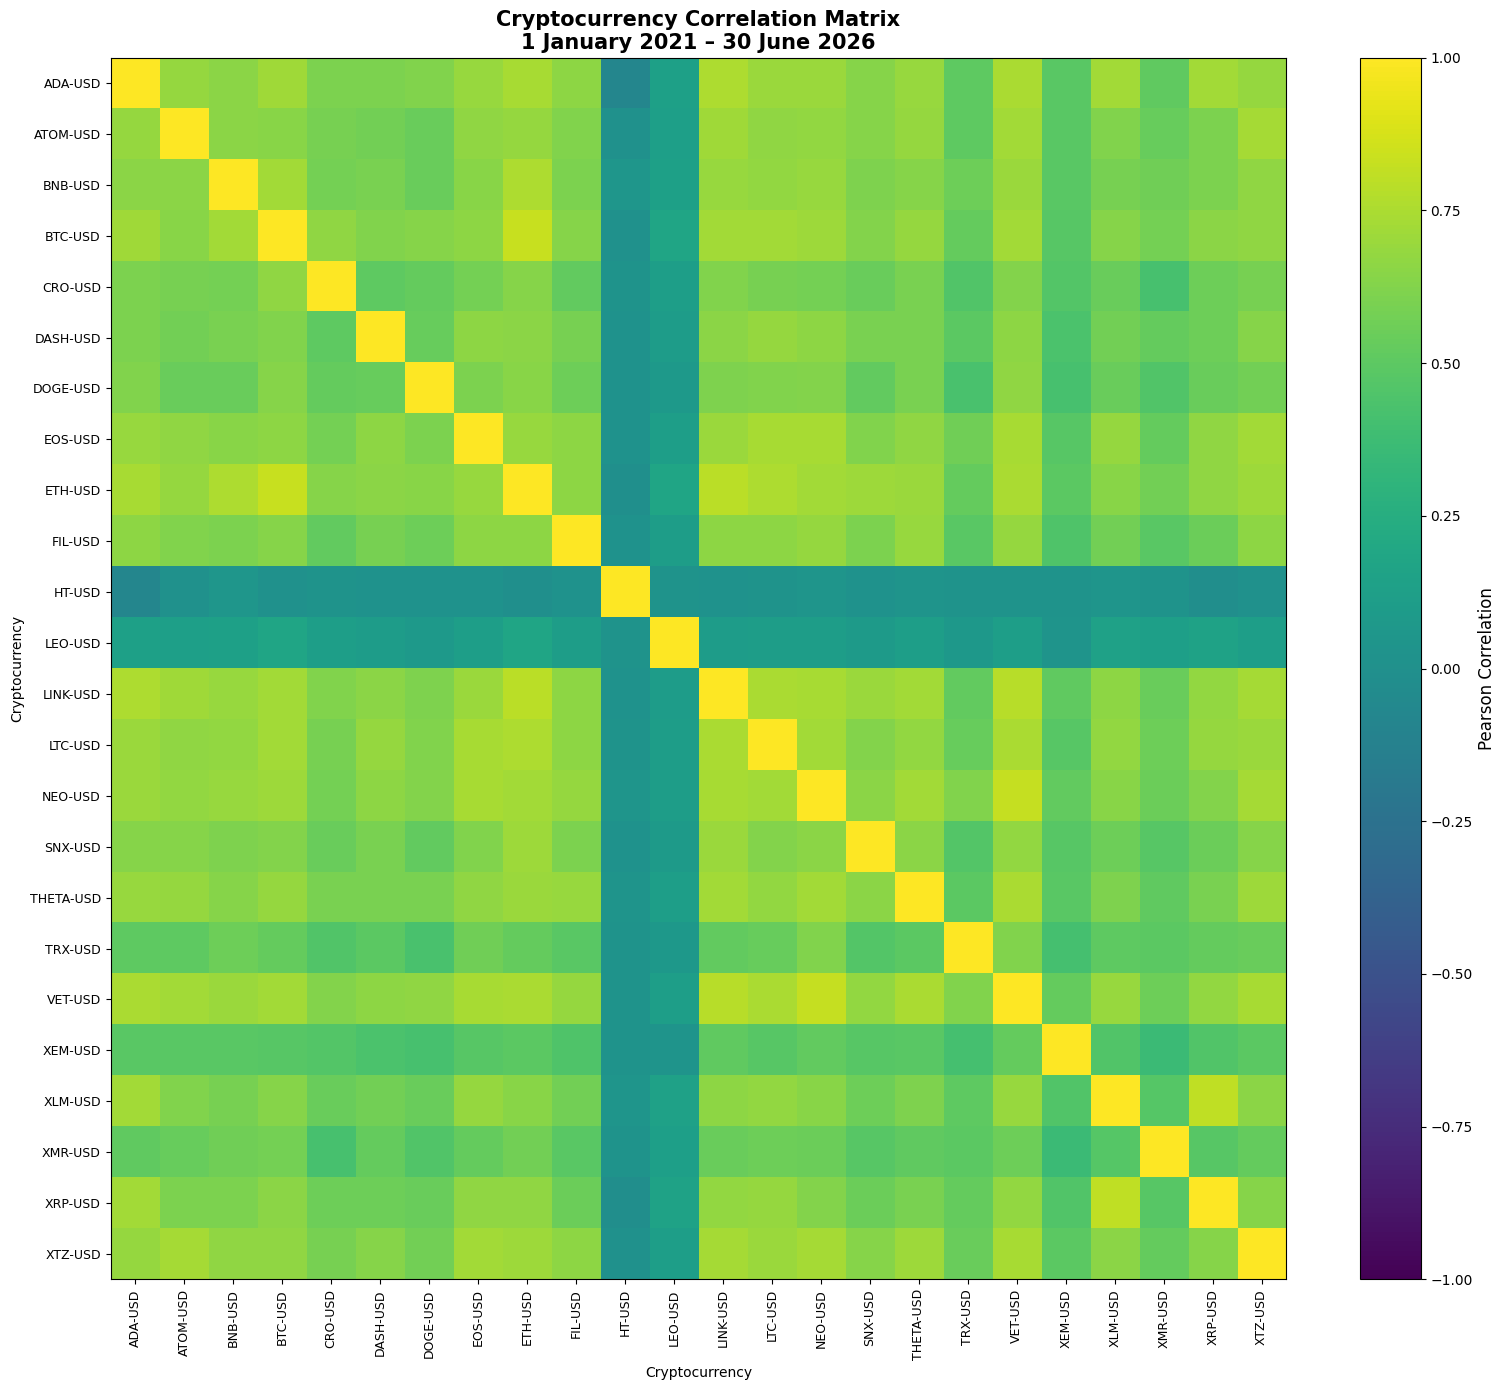

In [109]:
#====================================================
# CORRELATION EDA 2
# FULL-PERIOD CORRELATION HEATMAP
#====================================================

import matplotlib.pyplot as plt


plt.figure(
    figsize=(16, 14)
)


image = plt.imshow(

    average_corr_matrix,

    vmin=-1,

    vmax=1,

    aspect="auto",

    interpolation="nearest"

)


#====================================================
# COLOR BAR
#====================================================

colorbar = plt.colorbar(
    image
)

colorbar.set_label(
    "Pearson Correlation",
    fontsize=12
)


#====================================================
# AXES
#====================================================

plt.xticks(

    range(
        len(GNN_TICKERS)
    ),

    GNN_TICKERS,

    rotation=90,

    fontsize=9
)


plt.yticks(

    range(
        len(GNN_TICKERS)
    ),

    GNN_TICKERS,

    fontsize=9
)


#====================================================
# TITLE
#====================================================

plt.title(

    "Cryptocurrency Correlation Matrix\n"
    "1 January 2021 – 30 June 2026",

    fontsize=15,

    fontweight="bold"

)


plt.xlabel(
    "Cryptocurrency"
)

plt.ylabel(
    "Cryptocurrency"
)


plt.tight_layout()

plt.show()

In [110]:
#====================================================
# CORRELATION EDA 3
# 30-DAY ROLLING AVERAGE PAIRWISE CORRELATION
#
# For each date:
#
# 1. Calculate 24 × 24 correlation matrix
# 2. Extract 276 unique cryptocurrency pairs
# 3. Calculate their average correlation
#====================================================

ROLLING_CORR_WINDOW = 30


rolling_average_correlation = []


#====================================================
# LOOP THROUGH DATES
#====================================================

for end_position in range(

    ROLLING_CORR_WINDOW - 1,

    len(eda_returns)

):


    #================================================
    # 30-DAY WINDOW
    #================================================

    rolling_window = (

        eda_returns

        .iloc[
            end_position
            -
            ROLLING_CORR_WINDOW
            +
            1
            :
            end_position
            +
            1
        ]

    )


    #================================================
    # SKIP INCOMPLETE WINDOWS
    #================================================

    if rolling_window.isna().any().any():

        continue


    #================================================
    # CORRELATION MATRIX
    #================================================

    rolling_corr = (

        rolling_window

        .corr()

        .reindex(
            index=GNN_TICKERS,
            columns=GNN_TICKERS
        )

    )


    #================================================
    # EXTRACT UNIQUE PAIRS
    #
    # 24 × 23 / 2 = 276
    #================================================

    pairwise_values = (

        rolling_corr

        .to_numpy()[
            upper_triangle
        ]

    )


    #================================================
    # STORE DAILY AVERAGE
    #================================================

    rolling_average_correlation.append(

        {

            "Date":
                eda_returns.index[
                    end_position
                ],

            "Average_Correlation":
                np.mean(
                    pairwise_values
                )

        }

    )


#====================================================
# CREATE DATAFRAME
#====================================================

rolling_average_corr_df = pd.DataFrame(

    rolling_average_correlation

)


print(
    rolling_average_corr_df.head()
)


print(
    "\nMinimum Rolling Average Correlation:",
    rolling_average_corr_df[
        "Average_Correlation"
    ].min()
)


print(
    "Maximum Rolling Average Correlation:",
    rolling_average_corr_df[
        "Average_Correlation"
    ].max()
)


print(
    "Mean Rolling Average Correlation:",
    rolling_average_corr_df[
        "Average_Correlation"
    ].mean()
)

        Date  Average_Correlation
0 2021-03-23             0.455442
1 2021-03-24             0.482886
2 2021-03-25             0.433502
3 2021-03-26             0.463090
4 2021-03-27             0.437741

Minimum Rolling Average Correlation: 0.24071375486398516
Maximum Rolling Average Correlation: 0.834379620911594
Mean Rolling Average Correlation: 0.5848445379463052


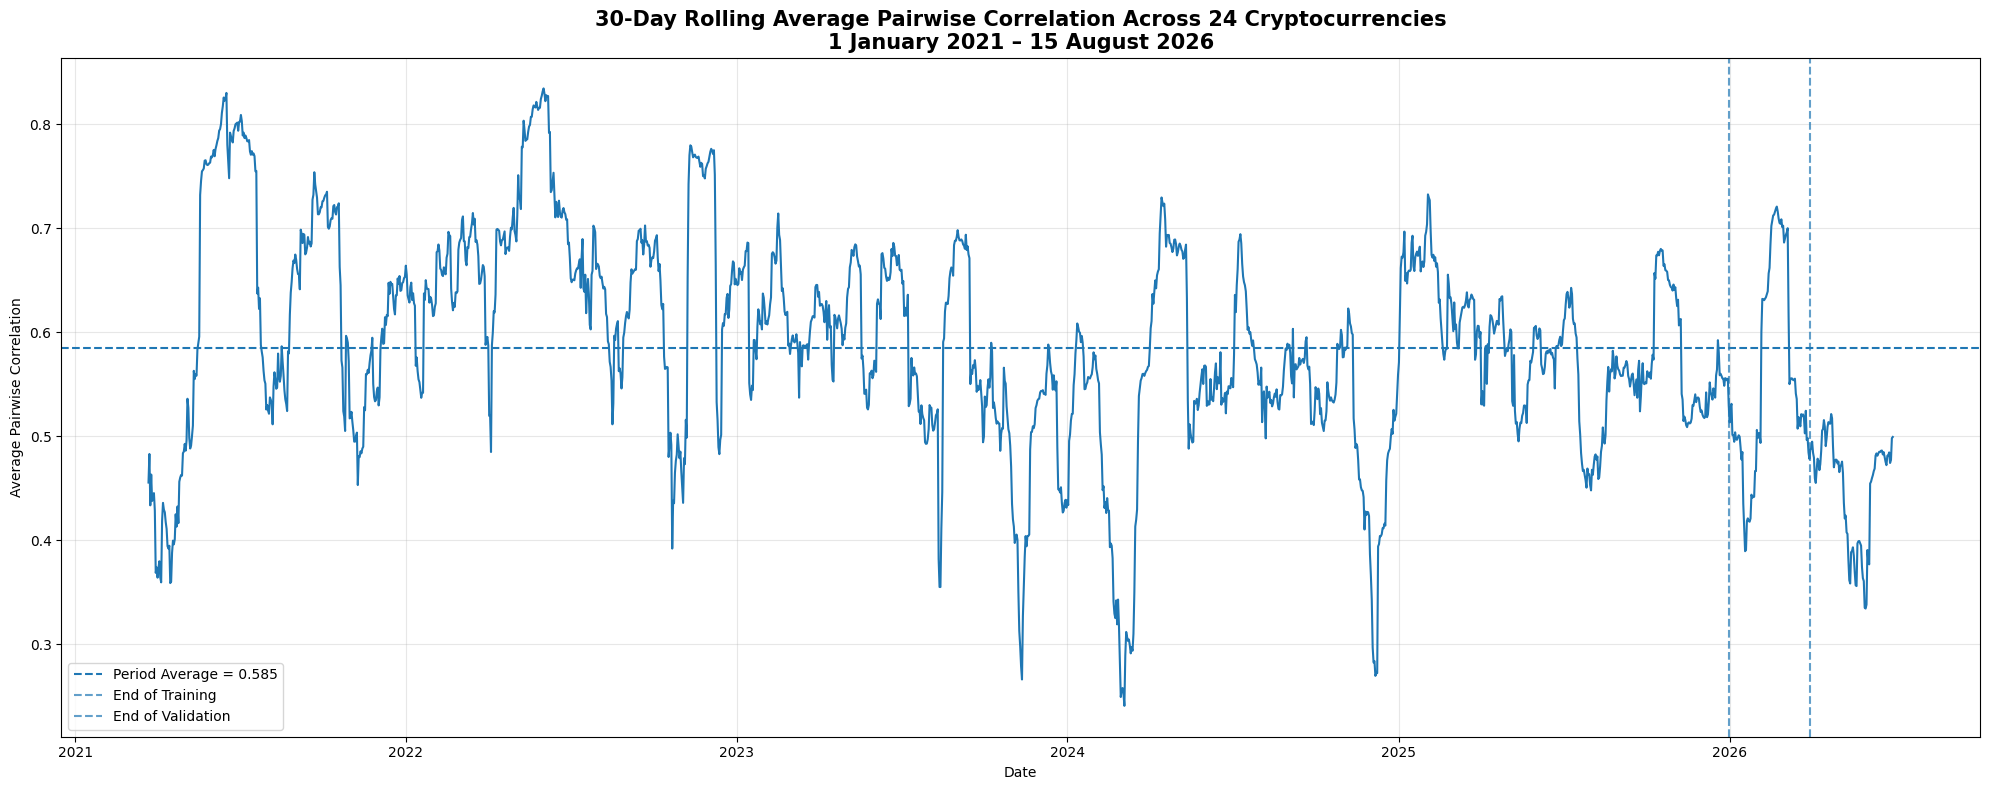

In [111]:
#====================================================
# VISUALIZE
# 30-DAY ROLLING AVERAGE PAIRWISE CORRELATION
#====================================================

plt.figure(
    figsize=(20, 8)
)


plt.plot(

    rolling_average_corr_df[
        "Date"
    ],

    rolling_average_corr_df[
        "Average_Correlation"
    ],

    linewidth=1.5

)


#====================================================
# LONG-RUN AVERAGE
#====================================================

long_run_corr = (

    rolling_average_corr_df[
        "Average_Correlation"
    ]

    .mean()

)


plt.axhline(

    y=long_run_corr,

    linestyle="--",

    linewidth=1.5,

    label=(
        "Period Average = "
        f"{long_run_corr:.3f}"
    )

)


#====================================================
# TRAIN / VALIDATION / TEST BOUNDARIES
#====================================================

plt.axvline(

    pd.Timestamp(
        "2025-12-31"
    ),

    linestyle="--",

    alpha=0.7,

    label="End of Training"
)


plt.axvline(

    pd.Timestamp(
        "2026-03-31"
    ),

    linestyle="--",

    alpha=0.7,

    label="End of Validation"
)


#====================================================
# TITLE
#====================================================

plt.title(

    "30-Day Rolling Average Pairwise Correlation "
    "Across 24 Cryptocurrencies\n"
    "1 January 2021 – 15 August 2026",

    fontsize=15,

    fontweight="bold"

)


plt.xlabel(
    "Date"
)

plt.ylabel(
    "Average Pairwise Correlation"
)


plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [112]:
#====================================================
# CORRELATION EDA 4
# ROLLING PAIRWISE CORRELATION DISTRIBUTION
#
# Shows:
# Mean
# 25th percentile
# 75th percentile
#====================================================

rolling_corr_distribution = []


for end_position in range(

    ROLLING_CORR_WINDOW - 1,

    len(eda_returns)

):


    rolling_window = (

        eda_returns

        .iloc[
            end_position
            -
            ROLLING_CORR_WINDOW
            +
            1
            :
            end_position
            +
            1
        ]

    )


    if rolling_window.isna().any().any():

        continue


    rolling_corr = (

        rolling_window

        .corr()

        .reindex(
            index=GNN_TICKERS,
            columns=GNN_TICKERS
        )

        .to_numpy()

    )


    pair_values = rolling_corr[
        upper_triangle
    ]


    rolling_corr_distribution.append(

        {

            "Date":
                eda_returns.index[
                    end_position
                ],

            "Mean":
                np.mean(
                    pair_values
                ),

            "Q25":
                np.quantile(
                    pair_values,
                    0.25
                ),

            "Median":
                np.median(
                    pair_values
                ),

            "Q75":
                np.quantile(
                    pair_values,
                    0.75
                )

        }

    )


rolling_corr_distribution_df = pd.DataFrame(

    rolling_corr_distribution

)

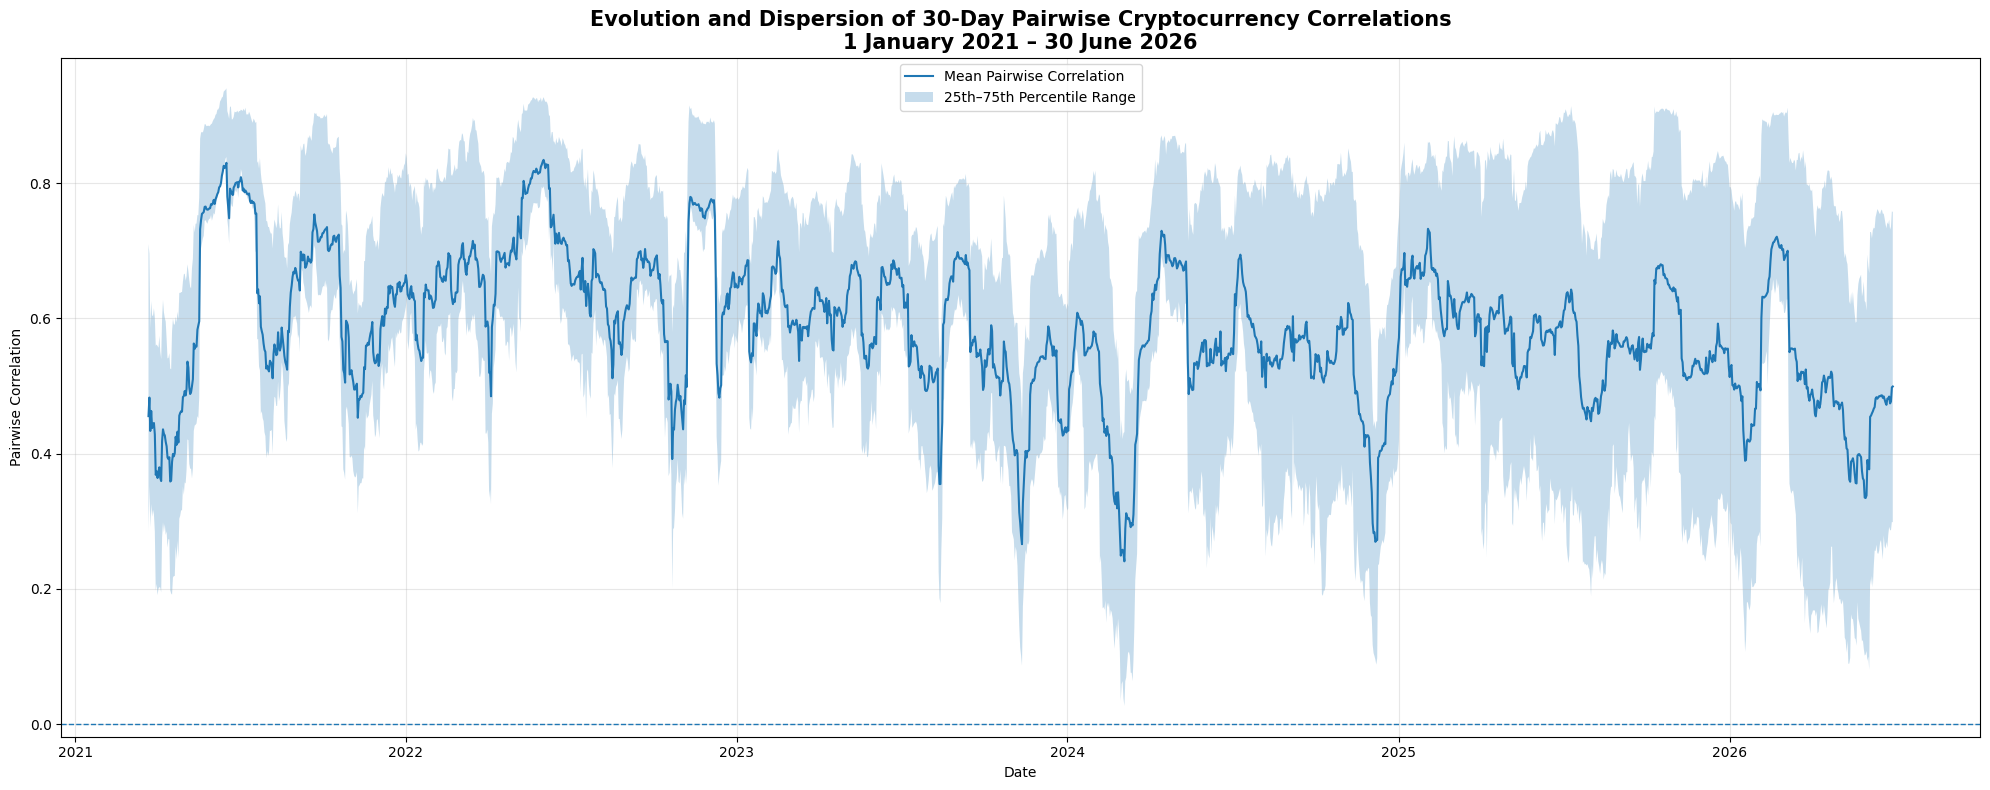

In [113]:
#====================================================
# VISUALIZE CORRELATION DISPERSION
#====================================================

plt.figure(
    figsize=(20, 8)
)


plt.plot(

    rolling_corr_distribution_df[
        "Date"
    ],

    rolling_corr_distribution_df[
        "Mean"
    ],

    linewidth=1.5,

    label="Mean Pairwise Correlation"

)


plt.fill_between(

    rolling_corr_distribution_df[
        "Date"
    ],

    rolling_corr_distribution_df[
        "Q25"
    ],

    rolling_corr_distribution_df[
        "Q75"
    ],

    alpha=0.25,

    label="25th–75th Percentile Range"

)


plt.title(

    "Evolution and Dispersion of 30-Day "
    "Pairwise Cryptocurrency Correlations\n"
    "1 January 2021 – 30 June 2026",

    fontsize=15,

    fontweight="bold"

)


plt.xlabel(
    "Date"
)

plt.ylabel(
    "Pairwise Correlation"
)


plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)


plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [114]:
#====================================================
# CORRELATION EDA 5
# STRESSED VS TRANQUIL MARKET CORRELATIONS
#
# Stress:
# Top 25% of 30-day market volatility
#
# Tranquil:
# Bottom 25% of 30-day market volatility
#====================================================


#====================================================
# EQUAL-WEIGHT MARKET LOG RETURN
#====================================================

market_log_return = (

    eda_returns

    .mean(
        axis=1
    )

)


#====================================================
# 30-DAY MARKET REALIZED VOLATILITY
#
# Annualised using 365 days because
# cryptocurrency markets trade every day.
#====================================================

market_rv_30 = (

    market_log_return

    .rolling(
        window=30
    )

    .std()

    *

    np.sqrt(365)

)


#====================================================
# DEFINE VOLATILITY THRESHOLDS
#====================================================

low_vol_threshold = (

    market_rv_30

    .quantile(
        0.25
    )

)


high_vol_threshold = (

    market_rv_30

    .quantile(
        0.75
    )

)


print(
    "Tranquil Threshold:",
    low_vol_threshold
)

print(
    "Stress Threshold:",
    high_vol_threshold
)


#====================================================
# IDENTIFY REGIMES
#====================================================

tranquil_dates = (

    market_rv_30[
        market_rv_30
        <=
        low_vol_threshold
    ]

    .index

)


stress_dates = (

    market_rv_30[
        market_rv_30
        >=
        high_vol_threshold
    ]

    .index

)


#====================================================
# CORRELATION MATRICES
#====================================================

tranquil_corr_matrix = (

    eda_returns

    .loc[
        tranquil_dates
    ]

    .corr()

    .reindex(
        index=GNN_TICKERS,
        columns=GNN_TICKERS
    )

)


stress_corr_matrix = (

    eda_returns

    .loc[
        stress_dates
    ]

    .corr()

    .reindex(
        index=GNN_TICKERS,
        columns=GNN_TICKERS
    )

)


#====================================================
# AVERAGE OFF-DIAGONAL CORRELATION
#====================================================

tranquil_average_corr = (

    tranquil_corr_matrix

    .to_numpy()[
        upper_triangle
    ]

    .mean()

)


stress_average_corr = (

    stress_corr_matrix

    .to_numpy()[
        upper_triangle
    ]

    .mean()

)


print(
    "\nAverage Pairwise Correlation"
)

print(
    "Tranquil Market:",
    round(
        tranquil_average_corr,
        4
    )
)

print(
    "Stressed Market:",
    round(
        stress_average_corr,
        4
    )
)

print(
    "Difference:",
    round(
        stress_average_corr
        -
        tranquil_average_corr,
        4
    )
)

Tranquil Threshold: 0.48425994140067374
Stress Threshold: 0.7831194960229059

Average Pairwise Correlation
Tranquil Market: 0.4084
Stressed Market: 0.6153
Difference: 0.2068


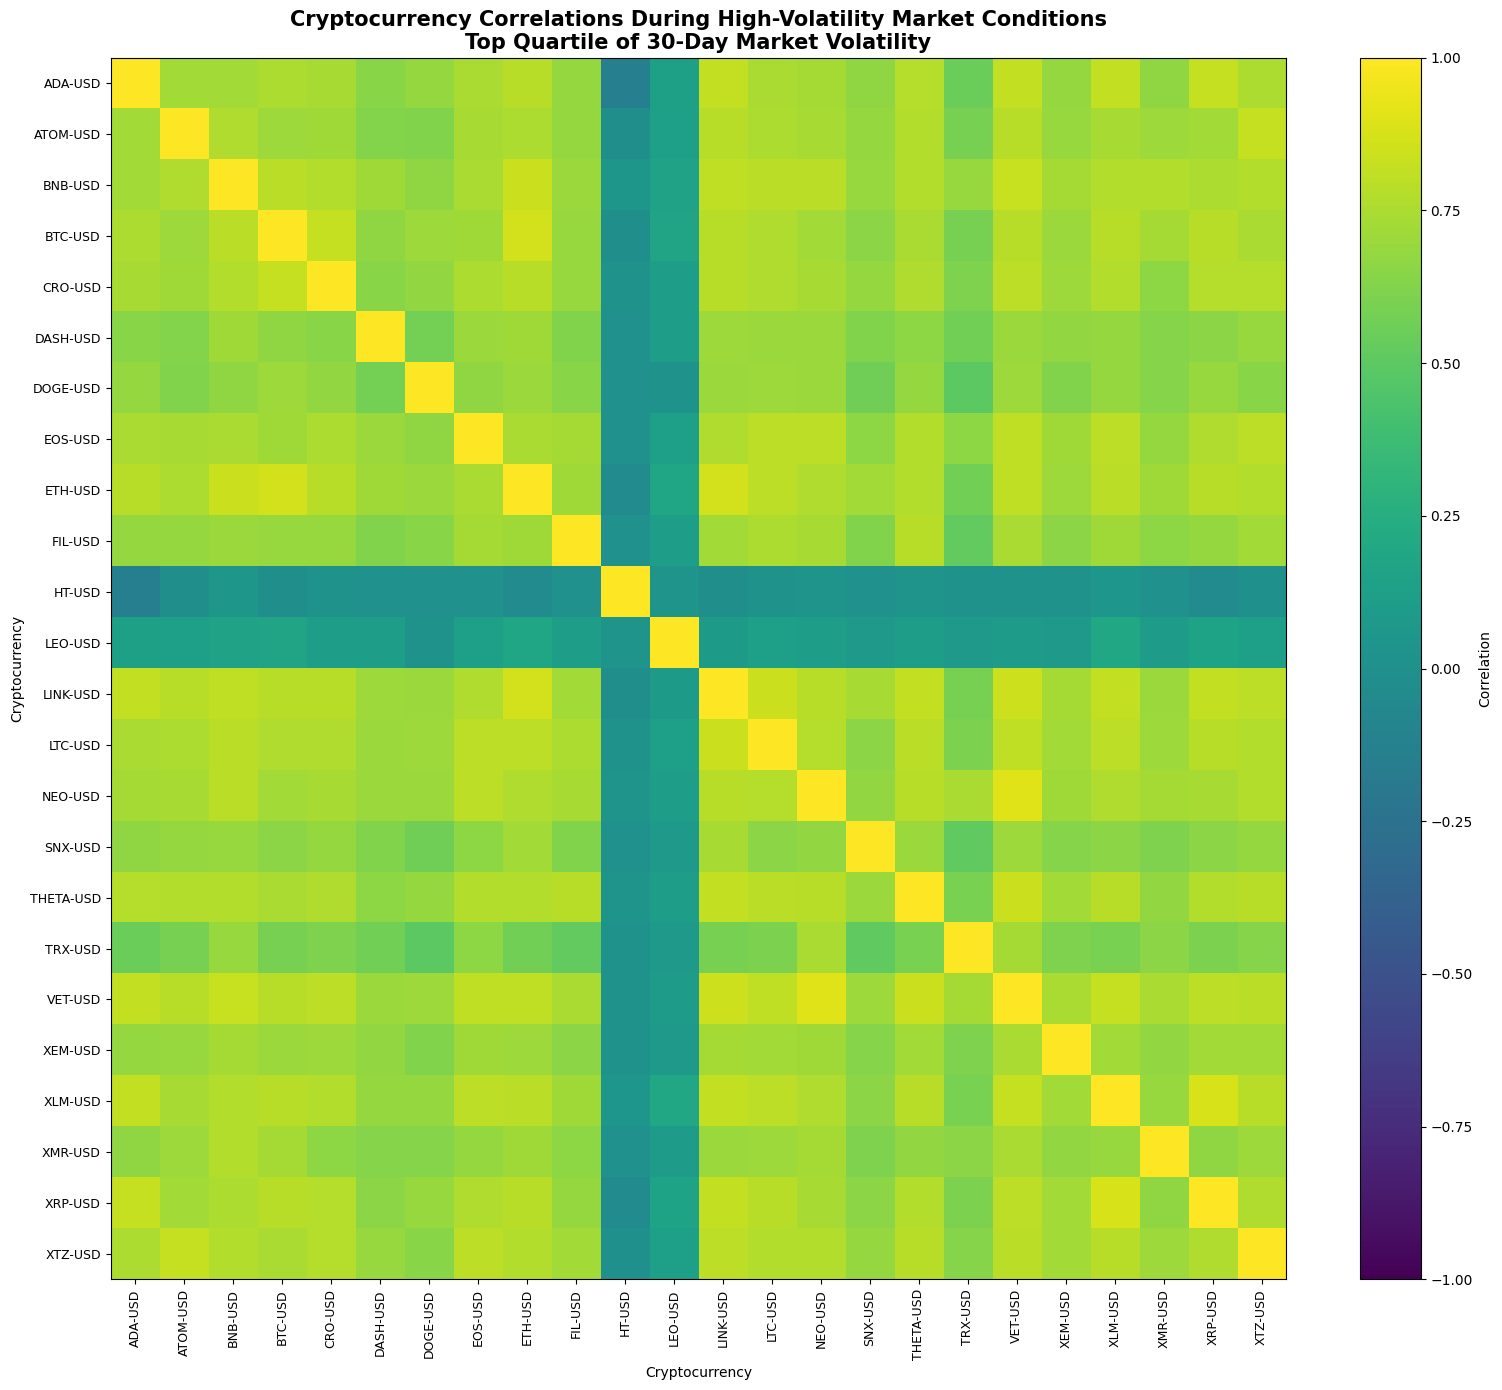

In [115]:
#====================================================
# STRESSED MARKET CORRELATION HEATMAP
#====================================================

plt.figure(
    figsize=(16, 14)
)


image = plt.imshow(

    stress_corr_matrix,

    vmin=-1,

    vmax=1,

    aspect="auto",

    interpolation="nearest"

)


plt.colorbar(
    image,
    label="Correlation"
)


plt.xticks(

    range(
        len(GNN_TICKERS)
    ),

    GNN_TICKERS,

    rotation=90,

    fontsize=9
)


plt.yticks(

    range(
        len(GNN_TICKERS)
    ),

    GNN_TICKERS,

    fontsize=9
)


plt.title(

    "Cryptocurrency Correlations During "
    "High-Volatility Market Conditions\n"
    "Top Quartile of 30-Day Market Volatility",

    fontsize=15,

    fontweight="bold"
)


plt.xlabel(
    "Cryptocurrency"
)

plt.ylabel(
    "Cryptocurrency"
)


plt.tight_layout()

plt.show()